# Notebook 01 — Preparación de las fuentes geoespaciales

## Análisis geoespacial integrado de la calidad del aire en Barcelona (2018–2024)

Este notebook constituye la primera etapa del bloque de **análisis geoespacial** del proyecto. Su objetivo es preparar, homogeneizar y validar las distintas fuentes de información territorial que posteriormente se integrarán en un único dataset destinado al análisis estadístico y a la modelización espacial de la calidad del aire.

Las fuentes consideradas caracterizan diferentes dimensiones del entorno urbano:

- **Contaminación atmosférica**, representada mediante concentraciones anuales por tramo viario.
- **Características socioeconómicas y demográficas** del territorio.
- **Topografía**, derivada del Modelo Digital del Terreno (MDT).
- **Movilidad viaria**, mediante datos georreferenciados de intensidad de tráfico (IMD).
- **Usos del suelo**, como aproximación a la estructura funcional del entorno urbano.

Durante esta fase se revisan la estructura y calidad de cada fuente, se homogeneizan los sistemas de referencia espacial y las unidades de análisis, y se generan las variables necesarias para su posterior integración.

Las capas resultantes se almacenan en el directorio `PREINTEGRACION`, de forma que el siguiente notebook pueda construir el dataset geoespacial integrado sin necesidad de repetir los procesos de preparación de las fuentes.

> **Flujo de trabajo:** fuentes geoespaciales → preparación y validación → `PREINTEGRACION` → integración → modelización geoespacial

## 1 . CONTAMIANCIÓN ATMODFÉRICA POR TRAMO VIARIO

**Fuente:** Open Data BCN — Ajuntament de Barcelona  
**Dataset:** *Mapas de inmisión de la calidad del aire de la ciudad de Barcelona*  
**Enlace:** https://opendata-ajuntament.barcelona.cat/data/es/dataset/mapes-immissio-qualitat-aire

La información espacial de contaminación atmosférica procede del portal **Open Data BCN del Ayuntamiento de Barcelona**, concretamente del conjunto de datos *Mapas de inmisión de la calidad del aire de la ciudad de Barcelona*, elaborado conjuntamente por el Ayuntamiento de Barcelona y la Agència de Salut Pública de Barcelona (ASPB).

Los mapas proporcionan información sobre la distribución espacial de distintos contaminantes atmosféricos en la ciudad y se actualizan con periodicidad anual. Para este análisis se consideran **NO₂, PM10 y PM2.5**, disponibles a escala de tramo viario.

El objetivo de esta etapa es revisar la estructura y cobertura de los archivos disponibles, homogeneizar la información correspondiente al periodo **2018–2024** y generar una capa multianual preparada para su posterior integración con las restantes variables geoespaciales.

In [ ]:
# ============================================================
# 1.1. Carga e inspección inicial de los datos
# ============================================================

import os
import pandas as pd
import geopandas as gpd

from google.colab import drive
drive.mount('/content/drive')

# Rutas de trabajo
ruta_base = (
    '/content/drive/MyDrive/TFM/'
    '06_Contaminacion_Atmosferica/MAPAS_ANUALES_CONTAMINACION'
)

ruta_bc2023 = os.path.join(ruta_base, 'BC 2023')

# ------------------------------------------------------------
# Archivos CSV disponibles para 2023
# ------------------------------------------------------------

print("ARCHIVOS DISPONIBLES EN BC 2023")

if os.path.exists(ruta_bc2023):

    archivos_csv = sorted([
        f for f in os.listdir(ruta_bc2023)
        if f.lower().endswith('.csv')
    ])

    for csv_file in archivos_csv:

        path_completo = os.path.join(ruta_bc2023, csv_file)
        df = pd.read_csv(path_completo)

        print(f"\n📄 {csv_file}")
        print(f"Dimensiones: {df.shape}")
        print(f"Columnas: {list(df.columns)}")

        display(df.head(3))

else:
    print(f"❌ No se encuentra la ruta: {ruta_bc2023}")


# ------------------------------------------------------------
# GeoPackage de NO₂ correspondiente a 2024
# ------------------------------------------------------------

ruta_gpkg = os.path.join(
    ruta_base,
    '2024_tramer_no2_mapa_qualitat_aire_bcn.gpkg'
)

if os.path.exists(ruta_gpkg):

    gdf_no2 = gpd.read_file(ruta_gpkg)

    print(f"\n🗺️ {os.path.basename(ruta_gpkg)}")
    print(f"Dimensiones: {gdf_no2.shape}")
    print(f"CRS: {gdf_no2.crs}")
    print(f"Geometrías: {gdf_no2.geom_type.value_counts().to_dict()}")

    display(gdf_no2.head(3))

else:
    print(f"❌ No se encuentra el archivo: {ruta_gpkg}")

Mounted at /content/drive
ARCHIVOS DISPONIBLES EN BC 2023

📄 2023_tramer_no2_mapa_qualitat_aire_bcn.csv
Dimensiones: (15041, 3)
Columnas: ['TRAM', 'Rang', 'GEOM_WKT']


,TRAM,Rang,GEOM_WKT
0,T04719W,20-30 µg/m³,MultiLineString ((430229.78859372 4586585.1990...
1,T19941Z,20-30 µg/m³,MultiLineString ((432928.8982969 4584019.98762...
2,T18111R,20-30 µg/m³,MultiLineString ((429953.2631029 4588161.44067...



📄 2023_tramer_pm10_mapa_qualitat_aire_bcn.csv
Dimensiones: (15041, 3)
Columnas: ['TRAM', 'Rang', 'GEOM_WKT']


,TRAM,Rang,GEOM_WKT
0,T04719W,20-25 µg/m³,MultiLineString ((430229.78859372 4586585.1990...
1,T19941Z,20-25 µg/m³,MultiLineString ((432928.8982969 4584019.98762...
2,T18111R,20-25 µg/m³,MultiLineString ((429953.2631029 4588161.44067...



📄 2023_tramer_pm2-5_mapa_qualitat_aire_bcn.csv
Dimensiones: (15041, 3)
Columnas: ['TRAM', 'Rang', 'GEOM_WKT']


,TRAM,Rang,GEOM_WKT
0,T04719W,10-15 µg/m³,MultiLineString ((430229.78859372 4586585.1990...
1,T19941Z,15-20 µg/m³,MultiLineString ((432928.8982969 4584019.98762...
2,T18111R,10-15 µg/m³,MultiLineString ((429953.2631029 4588161.44067...


/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in '2024_tramer_no2_mapa_qualitat_aire_bcn.gpkg': '2024_Tramer_NO2_Mapa_Qualitat_Aire_BCN' (default), 'layer_styles'. Specify layer parameter to avoid this warning.
  result = read_func(



🗺️ 2024_tramer_no2_mapa_qualitat_aire_bcn.gpkg
Dimensiones: (15041, 3)
CRS: EPSG:25831
Geometrías: {'MultiLineString': 15041}


,TRAM,Rang,geometry
0,T04719W,20-30 µg/m³,"MULTILINESTRING ((430229.789 4586585.199, 4301..."
1,T19941Z,20-30 µg/m³,"MULTILINESTRING ((432928.898 4584019.988, 4329..."
2,T18111R,10-20 µg/m³,"MULTILINESTRING ((429953.263 4588161.441, 4299..."


### Resultado de la inspección inicial

La revisión de los archivos confirma una estructura espacial homogénea de la información de calidad del aire. Los ficheros correspondientes a **NO₂, PM10 y PM2.5 de 2023 contienen 15.041 tramos viarios**, identificados mediante el campo `TRAM`, junto con el intervalo de concentración (`Rang`) y su geometría (`GEOM_WKT`).

La inspección del GeoPackage de **NO₂ de 2024** confirma igualmente la presencia de **15.041 tramos**, representados mediante geometrías `MultiLineString` y referenciados en el sistema **ETRS89 / UTM zona 31N (EPSG:25831)**.

Esta correspondencia inicial sugiere una estructura territorial consistente entre contaminantes y años, que se verificará durante el proceso de homogeneización multianual.

### 1.2. Inventario y cobertura temporal de las fuentes

Antes de iniciar la integración multianual se realiza un inventario sistemático de los archivos disponibles para el periodo **2018–2024**.

Esta comprobación permite verificar la existencia de información para cada año, identificar los archivos correspondientes a **NO₂, PM10 y PM2.5** y detectar posibles diferencias en su disponibilidad o nomenclatura antes de proceder a su lectura y homogeneización.

Además del resumen anual, se genera un inventario detallado con una fila por archivo, conservando el año, nombre del fichero y contaminante asociado. Esta estructura servirá como referencia para automatizar posteriormente la lectura de la serie completa.

Las capas procesadas se almacenarán en el directorio `PREINTEGRACION`, manteniendo separadas las fuentes originales de los datos preparados para su posterior integración geoespacial.

In [ ]:
# ============================================================
# 1.2. INVENTARIO Y COBERTURA TEMPORAL DE LAS FUENTES
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# Definición de rutas
# ------------------------------------------------------------

RUTA_BASE = Path(
    "/content/drive/MyDrive/TFM/"
    "06_Contaminacion_Atmosferica/"
    "MAPAS_ANUALES_CONTAMINACION"
)

RUTA_PREINTEGRACION = Path(
    "/content/drive/MyDrive/TFM/"
    "10_Machine_Learning_Geoespacial/"
    "PREINTEGRACION"
)

RUTA_PREINTEGRACION.mkdir(
    parents=True,
    exist_ok=True
)

# Comprobación de la ruta de origen
if not RUTA_BASE.exists():
    raise FileNotFoundError(
        f"No existe la carpeta base:\n{RUTA_BASE}"
    )

print(f"Ruta de origen: {RUTA_BASE}")
print(f"Ruta de preintegración: {RUTA_PREINTEGRACION}")


# ------------------------------------------------------------
# Inventario de archivos disponibles
# ------------------------------------------------------------

anios_esperados = range(2018, 2025)

inventario = []
archivos = []

for anio in anios_esperados:

    carpeta_anio = RUTA_BASE / f"BC {anio}"

    # Si no existe la carpeta anual
    if not carpeta_anio.exists():

        inventario.append({
            "AÑO": anio,
            "CARPETA_EXISTE": False,
            "NUM_CSV": 0,
            "ARCHIVOS": ""
        })

        continue

    # Archivos CSV disponibles
    archivos_csv = sorted(
        carpeta_anio.glob("*.csv")
    )

    # Resumen anual
    inventario.append({
        "AÑO": anio,
        "CARPETA_EXISTE": True,
        "NUM_CSV": len(archivos_csv),
        "ARCHIVOS": " | ".join(
            archivo.name
            for archivo in archivos_csv
        )
    })

    # Inventario detallado
    for archivo in archivos_csv:

        nombre = archivo.name.lower()

        if "no2" in nombre:
            contaminante = "NO2"

        elif "pm10" in nombre:
            contaminante = "PM10"

        elif (
            "pm2-5" in nombre
            or "pm2_5" in nombre
            or "pm25" in nombre
        ):
            contaminante = "PM2.5"

        else:
            contaminante = "DESCONOCIDO"

        archivos.append({
            "AÑO": anio,
            "ARCHIVO": archivo.name,
            "CONTAMINANTE": contaminante
        })


# ------------------------------------------------------------
# DataFrames de inventario
# ------------------------------------------------------------

df_inventario = pd.DataFrame(inventario)

df_archivos = pd.DataFrame(archivos)


# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------

print("\nINVENTARIO GENERAL")
display(df_inventario)

print("\nINVENTARIO DETALLADO")
display(df_archivos)

print(f"\nArchivos identificados: {len(df_archivos)}")

print(
    "Contaminantes identificados:",
    sorted(df_archivos["CONTAMINANTE"].unique())
)

Ruta de origen: /content/drive/MyDrive/TFM/06_Contaminacion_Atmosferica/MAPAS_ANUALES_CONTAMINACION
Ruta de preintegración: /content/drive/MyDrive/TFM/10_Machine_Learning_Geoespacial/PREINTEGRACION

INVENTARIO GENERAL


,AÑO,CARPETA_EXISTE,NUM_CSV,ARCHIVOS
0,2018,True,3,2018_tramer_no2_mapa_qualitat_aire_bcn.csv | 2...
1,2019,True,3,2019_tramer_no2_mapa_qualitat_aire_bcn.csv | 2...
2,2020,True,3,2020_tramer_no2_mapa_qualitat_aire_bcn.csv | 2...
3,2021,True,3,2021_tramer_no2_mapa_qualitat_aire_bcn.csv | 2...
4,2022,True,3,2022_tramer_no2_mapa_qualitat_aire_bcn.csv | 2...
5,2023,True,3,2023_tramer_no2_mapa_qualitat_aire_bcn.csv | 2...
6,2024,True,3,2024_tramer_no2_mapa_qualitat_aire_bcn.csv | 2...



INVENTARIO DETALLADO


,AÑO,ARCHIVO,CONTAMINANTE
0,2018,2018_tramer_no2_mapa_qualitat_aire_bcn.csv,NO2
1,2018,2018_tramer_pm10_mapa_qualitat_aire_bcn.csv,PM10
2,2018,2018_tramer_pm2-5_mapa_qualitat_aire_bcn.csv,PM2.5
3,2019,2019_tramer_no2_mapa_qualitat_aire_bcn.csv,NO2
4,2019,2019_tramer_pm10_mapa_qualitat_aire_bcn.csv,PM10
5,2019,2019_tramer_pm2-5_mapa_qualitat_aire_bcn.csv,PM2.5
6,2020,2020_tramer_no2_mapa_qualitat_aire_bcn.csv,NO2
7,2020,2020_tramer_pm10_mapa_qualitat_aire_bcn.csv,PM10
8,2020,2020_tramer_pm2-5_mapa_qualitat_aire_bcn.csv,PM2.5
9,2021,2021_tramer_no2_mapa_qualitat_aire_bcn.csv,NO2



Archivos identificados: 21
Contaminantes identificados: ['NO2', 'PM10', 'PM2.5']


### Resultado del inventario y cobertura temporal

El inventario confirma una cobertura completa y homogénea para el periodo **2018–2024**.

Se han identificado **21 archivos CSV**, correspondientes a los **7 años de estudio** y a los tres contaminantes considerados: **NO₂, PM10 y PM2.5**. Cada año dispone de un archivo específico para cada contaminante, sin detectarse ausencias ni ficheros con clasificación desconocida.

La estructura resultante permite automatizar la lectura y consolidación de la serie multianual manteniendo la trazabilidad de cada archivo por año y contaminante.

### 1.3. Lectura y consolidación de la serie multianual

Una vez verificada la disponibilidad de las fuentes, se procede a la lectura sistemática de los **21 archivos correspondientes a los siete años de estudio y los tres contaminantes analizados**.

Durante la carga se conserva la trazabilidad de cada registro mediante la incorporación del año, contaminante y archivo de procedencia. Posteriormente, todos los ficheros se concatenan en una única base de trabajo sobre la que se comprobarán la cobertura espacial, la consistencia de los identificadores de tramo y la calidad de las geometrías.

In [ ]:
# ============================================================
# 1.3. LECTURA Y CONSOLIDACIÓN DE LA SERIE MULTIANUAL
# ============================================================

dataframes = []
errores_lectura = []

for _, fila in df_archivos.iterrows():

    anio = int(fila["AÑO"])
    nombre_archivo = fila["ARCHIVO"]
    contaminante = fila["CONTAMINANTE"]

    ruta_archivo = (
        RUTA_BASE
        / f"BC {anio}"
        / nombre_archivo
    )

    try:
        df = pd.read_csv(
            ruta_archivo,
            encoding="utf-8"
        )

    except UnicodeDecodeError:
        df = pd.read_csv(
            ruta_archivo,
            encoding="latin1"
        )

    except Exception as error:
        errores_lectura.append({
            "AÑO": anio,
            "ARCHIVO": nombre_archivo,
            "ERROR": str(error)
        })
        continue

    # Metadatos de procedencia
    df["AÑO"] = anio
    df["CONTAMINANTE"] = contaminante
    df["ARCHIVO_ORIGEN"] = nombre_archivo

    dataframes.append(df)


# ------------------------------------------------------------
# Consolidación
# ------------------------------------------------------------

if not dataframes:
    raise ValueError(
        "No se ha podido leer ningún archivo CSV."
    )

df_bruto = pd.concat(
    dataframes,
    ignore_index=True
)


# ------------------------------------------------------------
# Resumen general
# ------------------------------------------------------------

print(f"Archivos esperados : {len(df_archivos)}")
print(f"Archivos leídos    : {len(dataframes)}")
print(f"Errores de lectura : {len(errores_lectura)}")
print(f"Filas totales      : {len(df_bruto):,}")
print(f"Columnas totales   : {len(df_bruto.columns)}")

if errores_lectura:
    print("\nArchivos con error:")
    display(pd.DataFrame(errores_lectura))
else:
    print("\nTodos los archivos se han leído correctamente.")


# ------------------------------------------------------------
# Cobertura por año y contaminante
# ------------------------------------------------------------

resumen_lectura = (
    df_bruto
    .groupby(
        ["AÑO", "CONTAMINANTE"],
        as_index=False
    )
    .agg(
        REGISTROS=("TRAM", "size"),
        TRAMOS_UNICOS=("TRAM", "nunique"),
        RANGOS_UNICOS=("Rang", "nunique"),
        GEOMETRIAS_NULAS=(
            "GEOM_WKT",
            lambda serie: int(serie.isna().sum())
        )
    )
    .sort_values(["AÑO", "CONTAMINANTE"])
)

display(resumen_lectura)

print("\nMuestra de la base consolidada:")
display(df_bruto.head())

Archivos esperados : 21
Archivos leídos    : 21
Errores de lectura : 0
Filas totales      : 315,861
Columnas totales   : 7

Todos los archivos se han leído correctamente.


,AÑO,CONTAMINANTE,REGISTROS,TRAMOS_UNICOS,RANGOS_UNICOS,GEOMETRIAS_NULAS
0,2018,NO2,15041,15041,7,0
1,2018,PM10,15041,15041,4,0
2,2018,PM2.5,15041,15041,4,0
3,2019,NO2,15041,15041,7,0
4,2019,PM10,15041,15041,4,0
5,2019,PM2.5,15041,15041,4,0
6,2020,NO2,15041,15041,7,0
7,2020,PM10,15041,15041,4,0
8,2020,PM2.5,15041,15041,5,0
9,2021,NO2,15041,15041,7,0



Muestra de la base consolidada:


,TRAM,Rang,GEOM_WKT,AÑO,CONTAMINANTE,ARCHIVO_ORIGEN,fid
0,T04719W,30 - 40 µg/m³,MULTILINESTRING ((430229.788593716 4586585.199...,2018,NO2,2018_tramer_no2_mapa_qualitat_aire_bcn.csv,NaN
1,T19941Z,30 - 40 µg/m³,MULTILINESTRING ((432928.898296899 4584019.987...,2018,NO2,2018_tramer_no2_mapa_qualitat_aire_bcn.csv,NaN
2,T18111R,30 - 40 µg/m³,MULTILINESTRING ((429953.263102905 4588161.440...,2018,NO2,2018_tramer_no2_mapa_qualitat_aire_bcn.csv,NaN
3,T03222Y,30 - 40 µg/m³,MULTILINESTRING ((427949.038250661 4580946.042...,2018,NO2,2018_tramer_no2_mapa_qualitat_aire_bcn.csv,NaN
4,T17625I,40 - 50 µg/m³,MULTILINESTRING ((433950.188943519 4585741.213...,2018,NO2,2018_tramer_no2_mapa_qualitat_aire_bcn.csv,NaN


### Resultado de la consolidación multianual

La lectura y consolidación de las fuentes se completa correctamente para los **21 archivos disponibles**, sin registrarse errores de carga.

La base consolidada contiene **315.861 registros**, correspondientes a las combinaciones de **7 años × 3 contaminantes × 15.041 tramos viarios**.

Para todas las combinaciones de año y contaminante se mantienen **15.041 registros y 15.041 identificadores de tramo únicos**, sin geometrías nulas. Esto confirma una cobertura espacial completa y consistente a lo largo de todo el periodo **2018–2024**.

Se observan variaciones en el número de intervalos de concentración (`Rang`) disponibles entre años y contaminantes, aspecto que se analizará posteriormente durante la transformación de estas categorías en variables numéricas comparables.

### 1.4. Conversión y validación de las geometrías

Los archivos CSV almacenan la geometría de cada tramo viario mediante cadenas **WKT (Well-Known Text)**. Para poder realizar operaciones espaciales, estas geometrías se convierten a objetos Shapely y se construye un `GeoDataFrame`.

De acuerdo con la cartografía original, se asigna el sistema de referencia **ETRS89 / UTM zona 31N (EPSG:25831)**. Posteriormente se comprueba la integridad de las geometrías, su tipología y extensión espacial antes de continuar con la homogeneización de los atributos.

In [ ]:
# ============================================================
# 1.4. CONVERSIÓN Y VALIDACIÓN DE LAS GEOMETRÍAS
# ============================================================

from shapely import wkt

df_geo = df_bruto.copy()

# ------------------------------------------------------------
# Eliminación de campos sin utilidad
# ------------------------------------------------------------

columnas_eliminar = [
    columna
    for columna in ["fid"]
    if columna in df_geo.columns
]

if columnas_eliminar:
    df_geo = df_geo.drop(columns=columnas_eliminar)

print("Columnas eliminadas:", columnas_eliminar)


# ------------------------------------------------------------
# Conversión WKT → geometría Shapely
# ------------------------------------------------------------

def convertir_wkt(valor):
    """Convierte una cadena WKT en una geometría Shapely."""

    if pd.isna(valor):
        return None

    try:
        return wkt.loads(valor)
    except Exception:
        return None


df_geo["geometry"] = df_geo["GEOM_WKT"].apply(convertir_wkt)


# ------------------------------------------------------------
# Creación del GeoDataFrame
# ------------------------------------------------------------

gdf_bruto = gpd.GeoDataFrame(
    df_geo,
    geometry="geometry",
    crs="EPSG:25831"
)


# ------------------------------------------------------------
# Validación de geometrías
# ------------------------------------------------------------

geom_nula = gdf_bruto.geometry.isna()
geom_vacia = (~geom_nula) & gdf_bruto.geometry.is_empty
geom_valida = (~geom_nula) & (~geom_vacia) & gdf_bruto.geometry.is_valid
geom_invalida = (~geom_nula) & (~geom_vacia) & (~gdf_bruto.geometry.is_valid)

resumen_geometrias = pd.DataFrame({
    "Indicador": [
        "Registros totales",
        "Geometrías nulas",
        "Geometrías vacías",
        "Geometrías inválidas",
        "Geometrías válidas"
    ],
    "Valor": [
        len(gdf_bruto),
        int(geom_nula.sum()),
        int(geom_vacia.sum()),
        int(geom_invalida.sum()),
        int(geom_valida.sum())
    ]
})

display(resumen_geometrias)


# ------------------------------------------------------------
# Tipos de geometría
# ------------------------------------------------------------

print("\nTipos de geometría:")

display(
    gdf_bruto.geometry
    .geom_type
    .value_counts(dropna=False)
    .rename_axis("TIPO_GEOMETRIA")
    .reset_index(name="REGISTROS")
)


# ------------------------------------------------------------
# Sistema de referencia y extensión espacial
# ------------------------------------------------------------

print("\nCRS:")
print(gdf_bruto.crs)

print("\nBounding box:")
print(gdf_bruto.total_bounds)


# ------------------------------------------------------------
# Muestra
# ------------------------------------------------------------

display(
    gdf_bruto[
        [
            "TRAM",
            "Rang",
            "AÑO",
            "CONTAMINANTE",
            "geometry"
        ]
    ].head()
)

Columnas eliminadas: ['fid']


,Indicador,Valor
0,Registros totales,315861
1,Geometrías nulas,0
2,Geometrías vacías,0
3,Geometrías inválidas,0
4,Geometrías válidas,315861



Tipos de geometría:


,TIPO_GEOMETRIA,REGISTROS
0,MultiLineString,315861



CRS:
EPSG:25831

Bounding box:
[ 421364.69074511 4574934.61324795  435002.22300797 4591063.62179738]


,TRAM,Rang,AÑO,CONTAMINANTE,geometry
0,T04719W,30 - 40 µg/m³,2018,NO2,"MULTILINESTRING ((430229.789 4586585.199, 4301..."
1,T19941Z,30 - 40 µg/m³,2018,NO2,"MULTILINESTRING ((432928.898 4584019.988, 4329..."
2,T18111R,30 - 40 µg/m³,2018,NO2,"MULTILINESTRING ((429953.263 4588161.441, 4299..."
3,T03222Y,30 - 40 µg/m³,2018,NO2,"MULTILINESTRING ((427949.038 4580946.043, 4279..."
4,T17625I,40 - 50 µg/m³,2018,NO2,"MULTILINESTRING ((433950.189 4585741.214, 4338..."


### Resultado de la validación geométrica

La conversión de las geometrías WKT se completa correctamente para los **315.861 registros** de la base consolidada.

No se detectan geometrías nulas, vacías ni inválidas, por lo que la totalidad de los registros puede incorporarse al análisis geoespacial sin necesidad de aplicar procesos adicionales de reparación geométrica.

Todas las entidades presentan geometría de tipo `MultiLineString` y se encuentran referenciadas en el sistema **ETRS89 / UTM zona 31N (EPSG:25831)**, que se adopta como sistema de referencia común para las siguientes etapas de integración espacial.

### 1.5. Transformación de los rangos de concentración

Los valores de contaminación se encuentran expresados mediante intervalos categóricos de concentración (`Rang`). Para facilitar su posterior análisis estadístico y modelización, estos intervalos se transforman en variables numéricas que representan sus límites inferior y superior, así como un valor central cuando este puede estimarse de forma directa.

En los intervalos cerrados se utiliza el punto medio como valor representativo. Para los intervalos abiertos inferiores se adopta igualmente el punto medio entre cero y el límite superior. En cambio, los intervalos abiertos superiores se mantienen inicialmente sin valor central estimado, evitando introducir una aproximación arbitraria antes de analizar su distribución y frecuencia.

In [ ]:
# ============================================================
# 1.5. TRANSFORMACIÓN DE LOS RANGOS DE CONCENTRACIÓN
# ============================================================

import re
import numpy as np

gdf_rangos = gdf_bruto.copy()

# ------------------------------------------------------------
# Inspección de los rangos originales
# ------------------------------------------------------------

tabla_rangos = (
    gdf_rangos[
        ["CONTAMINANTE", "Rang"]
    ]
    .drop_duplicates()
    .sort_values(
        ["CONTAMINANTE", "Rang"]
    )
    .reset_index(drop=True)
)

display(tabla_rangos)


# ------------------------------------------------------------
# Función de interpretación de intervalos
# ------------------------------------------------------------

def extraer_intervalo(valor):
    """
    Convierte el rango textual de concentración en variables numéricas.
    """

    columnas = [
        "CONC_MIN",
        "CONC_MAX",
        "CONC_MEDIA",
        "TIPO_INTERVALO"
    ]

    if pd.isna(valor):
        return pd.Series(
            [np.nan, np.nan, np.nan, "SIN_DATO"],
            index=columnas
        )

    texto = str(valor).strip()

    numeros = re.findall(
        r"\d+(?:[.,]\d+)?",
        texto
    )

    numeros = [
        float(x.replace(",", "."))
        for x in numeros
    ]

    # Intervalo cerrado
    if len(numeros) >= 2:

        minimo = numeros[0]
        maximo = numeros[1]
        media = (minimo + maximo) / 2
        tipo = "CERRADO"

    # Intervalo abierto inferior
    elif len(numeros) == 1 and (
        "<" in texto or "≤" in texto
    ):

        minimo = 0
        maximo = numeros[0]
        media = maximo / 2
        tipo = "INFERIOR_ABIERTO"

    # Intervalo abierto superior
    elif len(numeros) == 1 and (
        ">" in texto or "≥" in texto
    ):

        minimo = numeros[0]
        maximo = np.nan
        media = np.nan
        tipo = "SUPERIOR_ABIERTO"

    # Valor puntual
    elif len(numeros) == 1:

        minimo = numeros[0]
        maximo = numeros[0]
        media = numeros[0]
        tipo = "PUNTUAL"

    # Valor no interpretable
    else:

        minimo = np.nan
        maximo = np.nan
        media = np.nan
        tipo = "NO_INTERPRETABLE"

    return pd.Series(
        [
            minimo,
            maximo,
            media,
            tipo
        ],
        index=columnas
    )


# ------------------------------------------------------------
# Conversión
# ------------------------------------------------------------

intervalos = gdf_rangos["Rang"].apply(
    extraer_intervalo
)

gdf_rangos = pd.concat(
    [
        gdf_rangos,
        intervalos
    ],
    axis=1
)


# ------------------------------------------------------------
# Validación de la conversión
# ------------------------------------------------------------

resumen_conversion = (
    gdf_rangos
    .groupby(
        ["CONTAMINANTE", "Rang"],
        as_index=False
    )
    .agg(
        CONC_MIN=("CONC_MIN", "first"),
        CONC_MAX=("CONC_MAX", "first"),
        CONC_MEDIA=("CONC_MEDIA", "first"),
        TIPO_INTERVALO=("TIPO_INTERVALO", "first"),
        REGISTROS=("TRAM", "size")
    )
    .sort_values(
        ["CONTAMINANTE", "CONC_MIN"],
        na_position="last"
    )
)

display(resumen_conversion)


# ------------------------------------------------------------
# Comprobación de nulos
# ------------------------------------------------------------

display(
    gdf_rangos[
        [
            "CONC_MIN",
            "CONC_MAX",
            "CONC_MEDIA"
        ]
    ]
    .isna()
    .sum()
    .to_frame("NULOS")
)


# ------------------------------------------------------------
# Muestra final
# ------------------------------------------------------------

display(
    gdf_rangos[
        [
            "TRAM",
            "AÑO",
            "CONTAMINANTE",
            "Rang",
            "CONC_MIN",
            "CONC_MAX",
            "CONC_MEDIA",
            "TIPO_INTERVALO",
            "geometry"
        ]
    ].head(10)
)

,CONTAMINANTE,Rang
0,NO2,10-20 µg/m³
1,NO2,20 - 30 µg/m³
2,NO2,20-30 µg/m³
3,NO2,30 - 40 µg/m³
4,NO2,30-40 µg/m³
5,NO2,40 - 50 µg/m³
6,NO2,40-50 µg/m³
7,NO2,50 - 60 µg/m³
8,NO2,50-60 µg/m³
9,NO2,60 - 70 µg/m³


,CONTAMINANTE,Rang,CONC_MIN,CONC_MAX,CONC_MEDIA,TIPO_INTERVALO,REGISTROS
11,NO2,<= 20 µg/m³,0.0,20.0,10.0,INFERIOR_ABIERTO,1275
0,NO2,10-20 µg/m³,10.0,20.0,15.0,CERRADO,9405
1,NO2,20 - 30 µg/m³,20.0,30.0,25.0,CERRADO,15995
2,NO2,20-30 µg/m³,20.0,30.0,25.0,CERRADO,37648
3,NO2,30 - 40 µg/m³,30.0,40.0,35.0,CERRADO,19654
4,NO2,30-40 µg/m³,30.0,40.0,35.0,CERRADO,10554
5,NO2,40 - 50 µg/m³,40.0,50.0,45.0,CERRADO,6204
6,NO2,40-50 µg/m³,40.0,50.0,45.0,CERRADO,1924
7,NO2,50 - 60 µg/m³,50.0,60.0,55.0,CERRADO,1457
8,NO2,50-60 µg/m³,50.0,60.0,55.0,CERRADO,504


,NULOS
CONC_MIN,0
CONC_MAX,967
CONC_MEDIA,967


,TRAM,AÑO,CONTAMINANTE,Rang,CONC_MIN,CONC_MAX,CONC_MEDIA,TIPO_INTERVALO,geometry
0,T04719W,2018,NO2,30 - 40 µg/m³,30.0,40.0,35.0,CERRADO,"MULTILINESTRING ((430229.789 4586585.199, 4301..."
1,T19941Z,2018,NO2,30 - 40 µg/m³,30.0,40.0,35.0,CERRADO,"MULTILINESTRING ((432928.898 4584019.988, 4329..."
2,T18111R,2018,NO2,30 - 40 µg/m³,30.0,40.0,35.0,CERRADO,"MULTILINESTRING ((429953.263 4588161.441, 4299..."
3,T03222Y,2018,NO2,30 - 40 µg/m³,30.0,40.0,35.0,CERRADO,"MULTILINESTRING ((427949.038 4580946.043, 4279..."
4,T17625I,2018,NO2,40 - 50 µg/m³,40.0,50.0,45.0,CERRADO,"MULTILINESTRING ((433950.189 4585741.214, 4338..."
5,T05360P,2018,NO2,20 - 30 µg/m³,20.0,30.0,25.0,CERRADO,"MULTILINESTRING ((429464.339 4587309.389, 4295..."
6,T08863T,2018,NO2,30 - 40 µg/m³,30.0,40.0,35.0,CERRADO,"MULTILINESTRING ((431912.281 4585068.507, 4318..."
7,T00236S,2018,NO2,40 - 50 µg/m³,40.0,50.0,45.0,CERRADO,"MULTILINESTRING ((432088.266 4581318.697, 4321..."
8,T13009A,2018,NO2,30 - 40 µg/m³,30.0,40.0,35.0,CERRADO,"MULTILINESTRING ((431196.393 4590356.601, 4312..."
9,T11921P,2018,NO2,30 - 40 µg/m³,30.0,40.0,35.0,CERRADO,"MULTILINESTRING ((431707.97 4588314.797, 43165..."


### Resultado de la transformación de los intervalos

La transformación permite homogeneizar las distintas formas de representación utilizadas en los archivos originales y convertir los rangos de concentración en variables numéricas comparables.

Se detectan pequeñas variaciones de formato entre años —por ejemplo, `20-30` y `20 - 30 µg/m³`— que no afectan al resultado de la conversión. Los intervalos cerrados se representan mediante su punto medio y los intervalos inferiores abiertos mediante el punto medio entre cero y su límite superior.

Los únicos valores sin `CONC_MAX` y `CONC_MEDIA` corresponden a **967 registros clasificados en intervalos superiores abiertos**: 176 registros de NO₂ (`>70 µg/m³`), 591 de PM10 (`>40 µg/m³`) y 200 de PM2.5 (`>25 µg/m³`). Estos valores no constituyen datos ausentes en la fuente, sino concentraciones cuya magnitud exacta no puede determinarse a partir del intervalo publicado.

Por este motivo, los intervalos superiores abiertos se conservan explícitamente y su tratamiento numérico se realizará de forma controlada en la etapa de preparación de las variables destinadas al análisis y modelización.

### 1.6. Integración de los contaminantes por tramo y año

Una vez homogeneizadas las concentraciones, la información se reorganiza desde un formato longitudinal —una fila por tramo, año y contaminante— hacia una estructura integrada con **una única fila por combinación de tramo viario y año**.

Para cada unidad espacial se conservan, de forma independiente para **NO₂, PM10 y PM2.5**, el rango original, los límites del intervalo, el valor representativo y el tipo de intervalo.

Antes de realizar la integración se comprueba la unicidad de cada combinación `TRAM-AÑO-CONTAMINANTE` y la consistencia de la geometría asociada a cada tramo entre contaminantes. Las posibles discrepancias geométricas se identifican y cuantifican antes de seleccionar una geometría de referencia.

In [ ]:
# ============================================================
# 1.6. INTEGRACIÓN DE LOS CONTAMINANTES POR TRAMO Y AÑO
# ============================================================

df_pivot = gdf_rangos[
    [
        "TRAM",
        "AÑO",
        "CONTAMINANTE",
        "Rang",
        "CONC_MIN",
        "CONC_MAX",
        "CONC_MEDIA",
        "TIPO_INTERVALO",
        "geometry"
    ]
].copy()


# ------------------------------------------------------------
# 1. Comprobación de unicidad por TRAM-AÑO-CONTAMINANTE
# ------------------------------------------------------------

duplicados = (
    df_pivot
    .groupby(["TRAM", "AÑO", "CONTAMINANTE"])
    .size()
)

n_duplicados = int(
    (duplicados > 1).sum()
)

print(
    "Combinaciones TRAM-AÑO-CONTAMINANTE duplicadas:",
    n_duplicados
)

if n_duplicados > 0:
    raise ValueError(
        "Se han detectado duplicados antes de la integración."
    )


# ------------------------------------------------------------
# 2. Comprobación de consistencia geométrica
# ------------------------------------------------------------

df_pivot["GEOM_WKB"] = (
    df_pivot.geometry.apply(lambda g: g.wkb)
)

geometrias_por_tramo = (
    df_pivot
    .groupby(["TRAM", "AÑO"])["GEOM_WKB"]
    .nunique()
)

n_geometrias_inconsistentes = int(
    (geometrias_por_tramo > 1).sum()
)

print(
    "TRAM-AÑO con geometrías diferentes entre contaminantes:",
    n_geometrias_inconsistentes
)


# ------------------------------------------------------------
# 3. Inspección de discrepancias geométricas
# ------------------------------------------------------------

if n_geometrias_inconsistentes > 0:

    inconsistentes = (
        geometrias_por_tramo[
            geometrias_por_tramo > 1
        ]
        .reset_index()
        .rename(
            columns={
                "GEOM_WKB": "N_GEOMETRIAS"
            }
        )
    )

    detalle_inconsistencias = (
        df_pivot
        .merge(
            inconsistentes[
                ["TRAM", "AÑO"]
            ],
            on=["TRAM", "AÑO"],
            how="inner"
        )
        [
            [
                "TRAM",
                "AÑO",
                "CONTAMINANTE",
                "geometry"
            ]
        ]
        .sort_values(
            ["AÑO", "TRAM", "CONTAMINANTE"]
        )
        .copy()
    )

    detalle_inconsistencias["LONGITUD_M"] = (
        detalle_inconsistencias.geometry.length
    )

    print(
        "\nDetalle de las discrepancias geométricas:"
    )

    display(
        detalle_inconsistencias[
            [
                "TRAM",
                "AÑO",
                "CONTAMINANTE",
                "LONGITUD_M"
            ]
        ]
    )

else:

    print(
        "\nNo se detectan discrepancias geométricas."
    )


# ------------------------------------------------------------
# 4. Función auxiliar para pivotar variables
# ------------------------------------------------------------

def pivotar_variable(df, variable, sufijo):

    tabla = df.pivot(
        index=["TRAM", "AÑO"],
        columns="CONTAMINANTE",
        values=variable
    )

    tabla.columns = [
        f"{contaminante}_{sufijo}"
        for contaminante in tabla.columns
    ]

    return tabla


# ------------------------------------------------------------
# 5. Pivotado de las variables de contaminación
# ------------------------------------------------------------

rangos = pivotar_variable(
    df_pivot,
    "Rang",
    "RANGO"
)

medias = pivotar_variable(
    df_pivot,
    "CONC_MEDIA",
    "VALOR"
)

minimos = pivotar_variable(
    df_pivot,
    "CONC_MIN",
    "MIN"
)

maximos = pivotar_variable(
    df_pivot,
    "CONC_MAX",
    "MAX"
)

tipos = pivotar_variable(
    df_pivot,
    "TIPO_INTERVALO",
    "TIPO_INTERVALO"
)


# ------------------------------------------------------------
# 6. Selección de una geometría de referencia
# ------------------------------------------------------------

# La validación previa ha mostrado que las discrepancias detectadas
# corresponden a diferencias menores de representación geométrica,
# sin cambios relevantes en la longitud de los tramos.
#
# Se conserva una única geometría por combinación TRAM-AÑO.

geometria = (
    df_pivot
    .sort_values(
        ["TRAM", "AÑO", "CONTAMINANTE"]
    )
    [
        [
            "TRAM",
            "AÑO",
            "geometry"
        ]
    ]
    .drop_duplicates(
        subset=["TRAM", "AÑO"]
    )
    .set_index(
        ["TRAM", "AÑO"]
    )
)


# ------------------------------------------------------------
# 7. Integración de contaminantes
# ------------------------------------------------------------

gdf_contaminacion = pd.concat(
    [
        geometria,
        rangos,
        medias,
        minimos,
        maximos,
        tipos
    ],
    axis=1
).reset_index()

gdf_contaminacion = gpd.GeoDataFrame(
    gdf_contaminacion,
    geometry="geometry",
    crs=gdf_rangos.crs
)


# ------------------------------------------------------------
# 8. Validación de la estructura resultante
# ------------------------------------------------------------

registros_esperados = (
    gdf_contaminacion["TRAM"].nunique()
    * gdf_contaminacion["AÑO"].nunique()
)

print(
    "\nRegistros esperados:",
    registros_esperados
)

print(
    "Registros obtenidos:",
    len(gdf_contaminacion)
)

if len(gdf_contaminacion) != registros_esperados:
    raise ValueError(
        "El número de registros obtenido no coincide "
        "con el esperado."
    )


# ------------------------------------------------------------
# 9. Resumen final
# ------------------------------------------------------------

resumen_integracion = pd.DataFrame({
    "Indicador": [
        "Número de registros",
        "Número de columnas",
        "Años",
        "Tramos únicos",
        "Discrepancias geométricas detectadas",
        "CRS"
    ],
    "Valor": [
        len(gdf_contaminacion),
        len(gdf_contaminacion.columns),
        gdf_contaminacion["AÑO"].nunique(),
        gdf_contaminacion["TRAM"].nunique(),
        n_geometrias_inconsistentes,
        str(gdf_contaminacion.crs)
    ]
})

display(resumen_integracion)


print("\nColumnas disponibles:")

display(
    pd.DataFrame(
        gdf_contaminacion.columns,
        columns=["COLUMNAS"]
    )
)


print("\nMuestra de la base integrada:")

display(
    gdf_contaminacion.head()
)

Combinaciones TRAM-AÑO-CONTAMINANTE duplicadas: 0
TRAM-AÑO con geometrías diferentes entre contaminantes: 20

Detalle de las discrepancias geométricas:


,TRAM,AÑO,CONTAMINANTE,LONGITUD_M
5,NS0017Q,2018,NO2,243.653983
15,NS0017Q,2018,PM10,243.653983
25,NS0017Q,2018,PM2.5,243.653983
9,RD0136F,2018,NO2,111.217512
19,RD0136F,2018,PM10,111.217512
29,RD0136F,2018,PM2.5,111.217512
2,RL0017Q,2018,NO2,1699.466210
12,RL0017Q,2018,PM10,1699.466210
22,RL0017Q,2018,PM2.5,1699.466210
4,T11593T,2018,NO2,167.733975



Registros esperados: 105287
Registros obtenidos: 105287


,Indicador,Valor
0,Número de registros,105287
1,Número de columnas,18
2,Años,7
3,Tramos únicos,15041
4,Discrepancias geométricas detectadas,20
5,CRS,EPSG:25831



Columnas disponibles:


,COLUMNAS
0,TRAM
1,AÑO
2,geometry
3,NO2_RANGO
4,PM10_RANGO
5,PM2.5_RANGO
6,NO2_VALOR
7,PM10_VALOR
8,PM2.5_VALOR
9,NO2_MIN



Muestra de la base integrada:


,TRAM,AÑO,geometry,NO2_RANGO,PM10_RANGO,PM2.5_RANGO,NO2_VALOR,PM10_VALOR,PM2.5_VALOR,NO2_MIN,PM10_MIN,PM2.5_MIN,NO2_MAX,PM10_MAX,PM2.5_MAX,NO2_TIPO_INTERVALO,PM10_TIPO_INTERVALO,PM2.5_TIPO_INTERVALO
0,LRD0001,2018,"MULTILINESTRING ((432320.693 4588706.712, 4323...",50 - 60 µg/m³,30 - 40 µg/m³,20 - 25 µg/m³,55.0,35.0,22.5,50.0,30.0,20.0,60.0,40.0,25.0,CERRADO,CERRADO,CERRADO
1,LRD0001,2019,"MULTILINESTRING ((432320.693 4588706.712, 4323...",40 - 50 µg/m³,30 - 40 µg/m³,20 - 25 µg/m³,45.0,35.0,22.5,40.0,30.0,20.0,50.0,40.0,25.0,CERRADO,CERRADO,CERRADO
2,LRD0001,2020,"MULTILINESTRING ((432320.693 4588706.712, 4323...",30 - 40 µg/m³,30 - 40 µg/m³,15 - 20 µg/m³,35.0,35.0,17.5,30.0,30.0,15.0,40.0,40.0,20.0,CERRADO,CERRADO,CERRADO
3,LRD0001,2021,"MULTILINESTRING ((432320.693 4588706.712, 4323...",30-40 µg/m³,30-40 µg/m³,15-20 µg/m³,35.0,35.0,17.5,30.0,30.0,15.0,40.0,40.0,20.0,CERRADO,CERRADO,CERRADO
4,LRD0001,2022,"MULTILINESTRING ((432320.693 4588706.712, 4323...",30-40 µg/m³,30-35 µg/m³,15-20 µg/m³,35.0,32.5,17.5,30.0,30.0,15.0,40.0,35.0,20.0,CERRADO,CERRADO,CERRADO


### Resultado de la integración por tramo y año

La integración genera una base espacial de **105.287 registros**, correspondientes a **15.041 tramos viarios observados durante los siete años del periodo 2018–2024**. No se detectan duplicados en las combinaciones `TRAM-AÑO-CONTAMINANTE` y el número final de registros coincide exactamente con el esperado.

Durante la validación se identifican **20 combinaciones `TRAM-AÑO` con pequeñas discrepancias geométricas entre contaminantes**, concentradas en diez tramos de 2018 y 2019. La comparación de sus longitudes muestra valores coincidentes o diferencias numéricas despreciables, por lo que se interpretan como variaciones menores de representación de la cartografía de origen y no como modificaciones sustanciales de los tramos.

Se conserva una única geometría de referencia para cada combinación `TRAM-AÑO`, mientras que para cada contaminante se mantienen el rango original, el valor representativo, los límites inferior y superior y el tipo de intervalo.

La capa resultante contiene **18 variables** y mantiene el sistema de referencia **ETRS89 / UTM zona 31N (EPSG:25831)**, quedando preparada para su posterior enriquecimiento e integración con las restantes variables geoespaciales.

### 1.7. Auditoría de unicidad y cobertura de la capa integrada

Una vez integrada la información de los tres contaminantes, se realiza una validación final de la estructura de la capa resultante.

Se comprueba que cada combinación `TRAM-AÑO` constituye una observación única y que el número de tramos se mantiene constante durante todo el periodo de estudio. Esta auditoría permite garantizar que el proceso de reorganización no ha introducido duplicidades ni pérdidas de unidades espaciales.

In [ ]:
# ============================================================
# 1.7. AUDITORÍA DE UNICIDAD Y COBERTURA
# ============================================================

# ------------------------------------------------------------
# 1. Comprobación de duplicados TRAM-AÑO
# ------------------------------------------------------------

duplicados = (
    gdf_contaminacion
    .groupby(["AÑO", "TRAM"])
    .size()
    .reset_index(name="N")
)

duplicados = duplicados[
    duplicados["N"] > 1
]

print(
    "Número de combinaciones TRAM-AÑO duplicadas:",
    len(duplicados)
)

if len(duplicados) > 0:
    display(duplicados.head(20))


# ------------------------------------------------------------
# 2. Cobertura de tramos por año
# ------------------------------------------------------------

cobertura_anual = (
    gdf_contaminacion
    .groupby("AÑO")
    .agg(
        REGISTROS=("TRAM", "size"),
        TRAMOS_UNICOS=("TRAM", "nunique")
    )
    .reset_index()
)

print("\nCobertura anual:")
display(cobertura_anual)


# ------------------------------------------------------------
# 3. Validación global
# ------------------------------------------------------------

n_tramos_esperados = (
    gdf_contaminacion["TRAM"].nunique()
)

cobertura_completa = (
    cobertura_anual["TRAMOS_UNICOS"]
    == n_tramos_esperados
).all()

print(
    f"\nTramos esperados por año: {n_tramos_esperados:,}"
)

print(
    "Cobertura completa en todos los años:",
    cobertura_completa
)


# ------------------------------------------------------------
# 4. Resultado de la auditoría
# ------------------------------------------------------------

if len(duplicados) == 0 and cobertura_completa:
    print(
        "\n✓ Auditoría superada: "
        "clave TRAM-AÑO única y cobertura espacial completa."
    )
else:
    print(
        "\n⚠ Revisar la estructura de la capa integrada."
    )

Número de combinaciones TRAM-AÑO duplicadas: 0

Cobertura anual:


,AÑO,REGISTROS,TRAMOS_UNICOS
0,2018,15041,15041
1,2019,15041,15041
2,2020,15041,15041
3,2021,15041,15041
4,2022,15041,15041
5,2023,15041,15041
6,2024,15041,15041



Tramos esperados por año: 15,041
Cobertura completa en todos los años: True

✓ Auditoría superada: clave TRAM-AÑO única y cobertura espacial completa.


### Resultado de la auditoría de unicidad y cobertura

La auditoría final confirma que la clave compuesta `TRAM-AÑO` es única en toda la base integrada, sin detectarse combinaciones duplicadas.

La cobertura espacial se mantiene constante durante todo el periodo **2018–2024**, con **15.041 tramos viarios por año** y sin pérdidas de unidades espaciales durante los procesos de consolidación y reorganización.

La estructura resultante supera, por tanto, las comprobaciones de unicidad y cobertura necesarias para continuar con la preparación de la capa de contaminación destinada a la preintegración geoespacial.

### 1.8. Estadísticas descriptivas de las concentraciones

Como primera aproximación a la distribución temporal de la contaminación espacial, se calculan estadísticos descriptivos anuales para los valores representativos de **NO₂, PM10 y PM2.5**.

Para cada contaminante se obtiene el número de observaciones disponibles, media, mediana, desviación estándar y valores mínimo y máximo. Este análisis permite identificar cambios generales entre años, diferencias en la dispersión espacial y posibles efectos asociados a periodos singulares, como los años afectados por las restricciones de movilidad derivadas de la COVID-19.

Los valores utilizados corresponden a los puntos medios de los intervalos cerrados e inferiores abiertos. Los intervalos superiores abiertos se mantienen como valores no determinados y, por tanto, no intervienen en el cálculo de estos estadísticos.

In [ ]:
# ============================================================
# 1.8. ESTADÍSTICAS DESCRIPTIVAS DE LAS CONCENTRACIONES
# ============================================================

variables = [
    "NO2_VALOR",
    "PM10_VALOR",
    "PM2.5_VALOR"
]

# ------------------------------------------------------------
# Estadísticos descriptivos por año
# ------------------------------------------------------------

estadisticas = (
    gdf_contaminacion
    .groupby("AÑO")[variables]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .round(2)
)

display(estadisticas)


# ------------------------------------------------------------
# Número de valores no determinados por intervalos superiores
# ------------------------------------------------------------

nulos_anuales = (
    gdf_contaminacion
    .groupby("AÑO")[variables]
    .apply(lambda df: df.isna().sum())
)

print("\nValores no determinados por año:")
display(nulos_anuales)

NO2_VALOR                                 PM10_VALOR                      \
         count   mean median   std   min   max      count   mean median   std   
AÑO                                                                             
2018     14965  37.49   35.0  8.69  10.0  65.0      14908  24.45   25.0  3.84   
2019     14995  35.78   35.0  7.87  10.0  65.0      14788  25.10   25.0  3.94   
2020     15037  25.87   25.0  6.08  10.0  65.0      15013  19.63   25.0  7.50   
2021     15026  25.88   25.0  7.26  15.0  65.0      15013  22.19   25.0  4.50   
2022     15023  29.24   25.0  7.76  15.0  65.0      14937  25.04   27.5  3.25   
2023     15031  25.11   25.0  7.04  15.0  65.0      15015  23.11   22.5  3.52   
2024     15034  24.31   25.0  6.38  15.0  65.0      15022  21.90   22.5  3.24   

                 PM2.5_VALOR                                  
       min   max       count   mean median   std   min   max  
AÑO                                                           
2018  10.0  35.0       14987  15.39   17.5  2.79  12.5  22.5  
2019  10.0  35.0       14939  15.69   17.5  3.25  12.5  22.5  
2020  10.0  35.0       15029  12.58   12.5  2.14   5.0  22.5  
2021   7.5  35.0       15041  12.53   12.5  1.53   7.5  22.5  
2022  17.5  37.5       15025  13.93   12.5  2.38   7.5  22.5  
2023   7.5  37.5       15041  13.52   12.5  2.13   7.5  27.5  
2024   7.5  37.5       15025  13.45   12.5  2.08   7.5  22.5


Valores no determinados por año:


,NO2_VALOR,PM10_VALOR,PM2.5_VALOR
AÑO,,,
2018,76,133,54
2019,46,253,102
2020,4,28,12
2021,15,28,0
2022,18,104,16
2023,10,26,0
2024,7,19,16


### Resultado del análisis descriptivo

Las estadísticas descriptivas muestran una evolución temporal diferenciada de los tres contaminantes y permiten identificar una reducción especialmente marcada de las concentraciones de **NO₂** durante el periodo asociado a las restricciones de movilidad.

La concentración media representativa de NO₂ desciende desde **37,49 µg/m³ en 2018** y **35,78 µg/m³ en 2019** hasta aproximadamente **25,9 µg/m³ en 2020–2021**. En 2022 se observa una recuperación parcial (29,24 µg/m³), seguida de un nuevo descenso hasta **24,31 µg/m³ en 2024**.

El **PM10** presenta igualmente una reducción en 2020, mientras que el **PM2.5** pasa de valores medios próximos a 15–16 µg/m³ antes de 2020 a aproximadamente 12,5 µg/m³ durante 2020–2021, manteniéndose posteriormente en torno a 13–14 µg/m³.

Los valores no determinados corresponden exclusivamente a intervalos superiores abiertos de la fuente original y representan una fracción reducida de las observaciones. Su distribución se conserva explícitamente para evitar interpretar estos casos como datos ausentes.

Estos resultados constituyen una primera aproximación descriptiva. La atribución de los cambios observados a factores como las restricciones de movilidad, el tráfico o las condiciones meteorológicas se abordará posteriormente mediante el análisis temporal integrado y la modelización.

### 1.9. Control visual de la distribución espacial del NO₂

Como comprobación visual de la información procesada, se representa la distribución espacial del **NO₂** en tres años representativos del periodo de estudio: **2019, 2020 y 2024**.

La selección permite comparar una situación previa a las restricciones de movilidad, el año de mayor alteración de los patrones habituales de desplazamiento y el último año disponible.

Para garantizar la comparabilidad entre mapas se utiliza una **escala cromática común**, de modo que un mismo color represente el mismo nivel de concentración en los tres años. Esta visualización tiene carácter exploratorio y permite identificar cambios generales en la intensidad y distribución espacial del contaminante antes de abordar análisis espaciales más específicos.

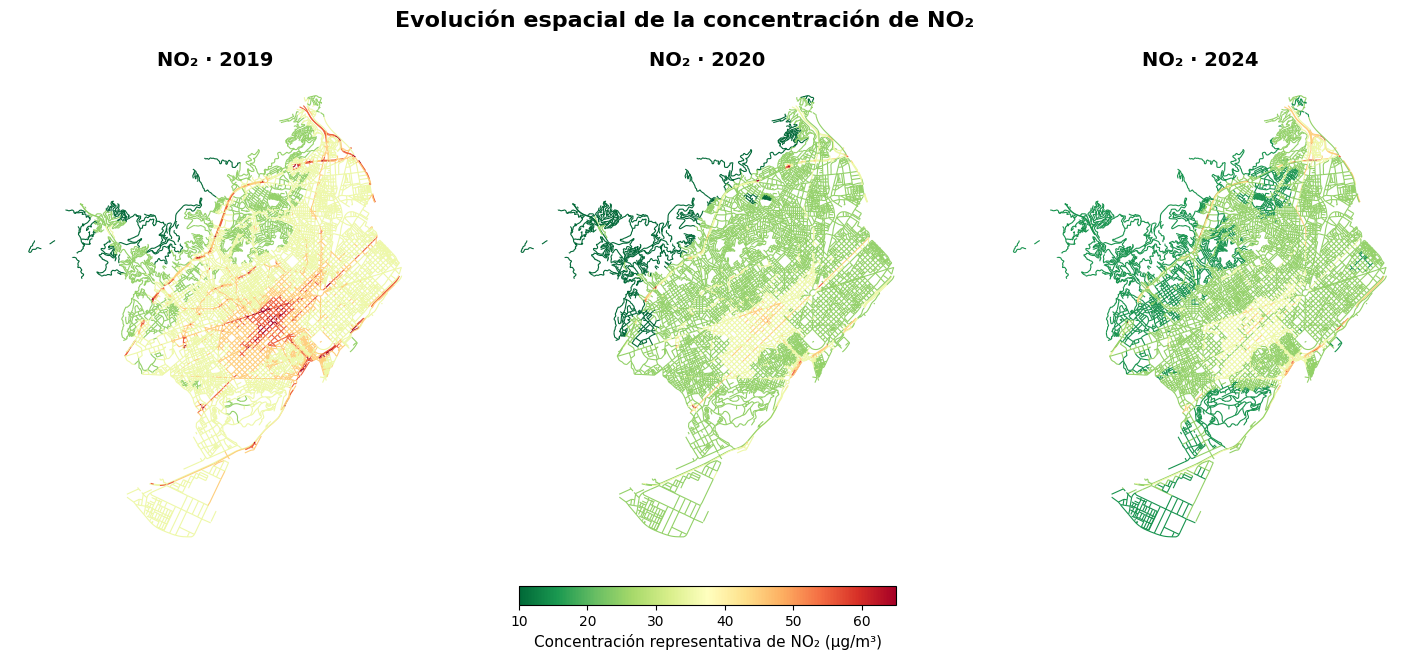

In [ ]:
# ============================================================
# 1.9. CONTROL VISUAL DE LA DISTRIBUCIÓN ESPACIAL DEL NO2
# ============================================================

import matplotlib.pyplot as plt
import matplotlib as mpl

anios_mapa = [2019, 2020, 2024]

datos_mapa = gdf_contaminacion[
    gdf_contaminacion["AÑO"].isin(anios_mapa)
].copy()


# ------------------------------------------------------------
# Escala cromática común
# ------------------------------------------------------------

vmin = datos_mapa["NO2_VALOR"].min()
vmax = datos_mapa["NO2_VALOR"].max()

cmap = "RdYlGn_r"


# ------------------------------------------------------------
# Representación
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 7)
)

for ax, anio in zip(axes, anios_mapa):

    datos = datos_mapa[
        datos_mapa["AÑO"] == anio
    ]

    datos.plot(
        column="NO2_VALOR",
        cmap=cmap,
        linewidth=0.8,
        vmin=vmin,
        vmax=vmax,
        ax=ax
    )

    ax.set_title(
        f"NO₂ · {anio}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_axis_off()


# ------------------------------------------------------------
# Leyenda común
# ------------------------------------------------------------

norm = mpl.colors.Normalize(
    vmin=vmin,
    vmax=vmax
)

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="horizontal",
    fraction=0.035,
    pad=0.05
)

cbar.set_label(
    "Concentración representativa de NO₂ (µg/m³)",
    fontsize=11
)


# ------------------------------------------------------------
# Título general
# ------------------------------------------------------------

fig.suptitle(
    "Evolución espacial de la concentración de NO₂",
    fontsize=16,
    fontweight="bold",
    y=0.96
)

plt.show()

### Resultado del control espacial del NO₂

La comparación cartográfica muestra una modificación clara de la distribución espacial del NO₂ durante el periodo analizado.

En **2019** se observa una mayor presencia de concentraciones elevadas en el tejido urbano central y en determinados ejes viarios principales. En **2020** se produce una reducción generalizada de la intensidad, especialmente visible en las áreas que presentaban mayores concentraciones durante el periodo previo.

En **2024** se mantiene, en términos generales, un patrón de concentraciones inferior al observado en 2019, aunque persisten determinados corredores viarios con valores relativamente elevados. Este comportamiento es coherente con el descenso observado en las estadísticas descriptivas anuales.

La persistencia de contrastes espaciales entre distintos sectores de la ciudad indica que la evolución de la contaminación no es territorialmente homogénea y justifica la posterior incorporación de variables relacionadas con movilidad, morfología urbana, usos del suelo y características socioespaciales.

La comparación tiene carácter descriptivo y no implica por sí misma una relación causal entre las variaciones observadas y los cambios en la movilidad.

# 2 . INFORMACIÓN SOCIOECONÓMICA: DENSIDAD DE POBLACIÓN Y RENTA

La caracterización geoespacial se complementa con variables destinadas a representar el **contexto demográfico y socioeconómico** del entorno urbano.

Se incorporan dos indicadores: la **densidad de población** y la **renta disponible de los hogares por persona**. Ambas variables presentan diferente resolución territorial: la densidad se encuentra disponible a escala de **barrio**, mientras que la renta se proporciona a escala de **sección censal**.

Dado que no se dispone de información homogénea y actualizada para cada uno de los años del periodo de estudio (2018–2024), ambas variables se incorporarán al modelo como **covariables espaciales estáticas**. Por tanto, a cada unidad territorial se le asignará el valor correspondiente al año de referencia disponible y este se mantendrá constante durante todo el periodo analizado.

Esta decisión permite incorporar al modelo la **heterogeneidad socioespacial de la ciudad** sin introducir una variabilidad temporal artificial no respaldada por los datos disponibles. En consecuencia, los resultados asociados a estas variables se interpretarán como efectos vinculados a las diferencias espaciales entre áreas y no como cambios temporales de la población o de la renta.

La espacialización de estos indicadores se realizará mediante la cartografía oficial de unidades administrativas de Barcelona, cuya preparación y validación se desarrolla de forma independiente en el **apartado 3**.

---

## 2.1. Fuentes de información

Las fuentes socioeconómicas utilizadas proceden del portal **Open Data BCN del Ayuntamiento de Barcelona**.

### Densidad de población

- **Recurso:** `2021_densitat.csv`
- **Año de referencia:** 2021
- **Indicador:** densidad de población.
- **Unidad territorial:** barrio.
- **Unidad de medida:** habitantes por hectárea (hab/ha).
- **Tratamiento temporal:** covariable espacial estática durante 2018–2024.

Esta variable permite representar la intensidad de ocupación residencial del territorio y diferenciar áreas urbanas con distinta concentración de población.

**Fuente oficial:**  
https://opendata-ajuntament.barcelona.cat/data/es/dataset/est-densitat/resource/540e48d8-c432-43df-b3ba-a0cf009b90ef

### Renta disponible

- **Recurso:** `2023_renda_disponible_llars_per_persona.csv`
- **Año de referencia:** 2023
- **Indicador:** estimación de la renta disponible de los hogares por persona.
- **Unidad territorial:** sección censal.
- **Unidad de medida:** euros por persona.
- **Tratamiento temporal:** covariable espacial estática durante 2018–2024.

La renta permite incorporar al análisis una medida del **contexto socioeconómico** de las diferentes áreas de la ciudad.

**Fuente oficial:**  
https://opendata-ajuntament.barcelona.cat/data/es/dataset/renda-disponible-llars-bcn/resource/f18e28ed-dcee-4904-b350-52088201a7a0

---

La densidad y la renta se mantendrán inicialmente en sus respectivas unidades territoriales. Las diferencias de resolución espacial se conservarán explícitamente durante el preprocesamiento y su asignación a la red viaria se realizará posteriormente durante la fase de integración geoespacial.

### Enlaces a las fuentes oficiales

- **Densidad de población (2021):**  
  https://opendata-ajuntament.barcelona.cat/data/es/dataset/est-densitat/resource/540e48d8-c432-43df-b3ba-a0cf009b90ef

- **Renta disponible de los hogares por persona (2023):**  
  https://opendata-ajuntament.barcelona.cat/data/es/dataset/renda-disponible-llars-bcn/resource/f18e28ed-dcee-4904-b350-52088201a7a0


In [ ]:
# ============================================================
# 2.1. LOCALIZACIÓN E INVENTARIO DE LOS DATOS SOCIOECONÓMICOS
# ============================================================

RUTA_SOCIOECONOMICOS = Path(
    "/content/drive/MyDrive/TFM/"
    "09_Indicadores_Socioeconomicos"
)

# ------------------------------------------------------------
# 1. Comprobación de la ruta
# ------------------------------------------------------------

if not RUTA_SOCIOECONOMICOS.exists():
    raise FileNotFoundError(
        f"No existe la carpeta:\n{RUTA_SOCIOECONOMICOS}"
    )

print(f"Ruta de origen: {RUTA_SOCIOECONOMICOS}")


# ------------------------------------------------------------
# 2. Inventario de archivos disponibles
# ------------------------------------------------------------

archivos_socioeconomicos = sorted(
    archivo
    for archivo in RUTA_SOCIOECONOMICOS.rglob("*")
    if archivo.is_file()
)

df_inventario_socio = pd.DataFrame({
    "ARCHIVO": [
        archivo.name
        for archivo in archivos_socioeconomicos
    ],
    "EXTENSION": [
        archivo.suffix.lower()
        for archivo in archivos_socioeconomicos
    ],
    "RUTA_RELATIVA": [
        str(
            archivo.relative_to(RUTA_SOCIOECONOMICOS)
        )
        for archivo in archivos_socioeconomicos
    ]
})

# ------------------------------------------------------------
# 3. Resumen
# ------------------------------------------------------------

print("=" * 100)
print("INVENTARIO DE DATOS SOCIOECONÓMICOS")
print("=" * 100)

print(f"Archivos identificados: {len(df_inventario_socio)}")

display(df_inventario_socio)

Ruta de origen: /content/drive/MyDrive/TFM/09_Indicadores_Socioeconomicos
INVENTARIO DE DATOS SOCIOECONÓMICOS
Archivos identificados: 131


,ARCHIVO,EXTENSION,RUTA_RELATIVA
0,2021_densitat.csv,.csv,2021_densitat.csv
1,2023_renda_disponible_llars_per_persona.csv,.csv,2023_renda_disponible_llars_per_persona.csv
2,0301040100_AEB_UNITATS_ADM.dbf,.dbf,BCN_UNITATS_ADM /0301040100_AEB_UNITATS_ADM.dbf
3,0301040100_AEB_UNITATS_ADM.prj,.prj,BCN_UNITATS_ADM /0301040100_AEB_UNITATS_ADM.prj
4,0301040100_AEB_UNITATS_ADM.shp,.shp,BCN_UNITATS_ADM /0301040100_AEB_UNITATS_ADM.shp
...,...,...,...
126,0301040100_ZUA_UNITATS_ADM.prj,.prj,UNI/BCN_UNITATS_ADM (1)/0301040100_ZUA_UNITATS...
127,0301040100_ZUA_UNITATS_ADM.shp,.shp,UNI/BCN_UNITATS_ADM (1)/0301040100_ZUA_UNITATS...
128,0301040100_ZUA_UNITATS_ADM.shx,.shx,UNI/BCN_UNITATS_ADM (1)/0301040100_ZUA_UNITATS...
129,UNITATS_ADM_CATALEG.mdb,.mdb,UNI/BCN_UNITATS_ADM (1)/UNITATS_ADM_CATALEG.mdb


### Resultado del inventario de fuentes socioeconómicas

El inventario confirma la disponibilidad de las principales fuentes necesarias para la caracterización socioeconómica:

- `2021_densitat.csv`, correspondiente a la densidad de población.
- `2023_renda_disponible_llars_per_persona.csv`, correspondiente a la renta disponible por persona.
- Diversas capas de la cartografía oficial de unidades administrativas de Barcelona, disponibles en formato Shapefile.

La carpeta contiene además archivos auxiliares y copias de distintas unidades administrativas. Por este motivo, en las siguientes etapas se seleccionarán únicamente las capas territoriales necesarias para relacionar los indicadores socioeconómicos con su geometría correspondiente.

La densidad de población y la renta se mantendrán como **covariables espaciales estáticas** durante el periodo 2018–2024, dado que no se dispone de observaciones homogéneas actualizadas para cada año.

## 2.2. Lectura e inspección de las fuentes socioeconómicas

Una vez localizados los recursos disponibles, se procede a la lectura de los dos indicadores socioeconómicos y de la cartografía de secciones censales utilizada para su espacialización.

En esta etapa se revisan la estructura de los archivos, los campos disponibles y la compatibilidad de las claves territoriales antes de realizar cualquier unión entre atributos y geometrías.

In [ ]:
# ============================================================
# 2.2. LECTURA E INSPECCIÓN DE LAS FUENTES SOCIOECONÓMICAS
# ============================================================

# ------------------------------------------------------------
# 1. Rutas de los archivos
# ------------------------------------------------------------

ruta_renta = (
    RUTA_SOCIOECONOMICOS
    / "2023_renda_disponible_llars_per_persona.csv"
)

ruta_densidad = (
    RUTA_SOCIOECONOMICOS
    / "2021_densitat.csv"
)

ruta_secciones = (
    RUTA_SOCIOECONOMICOS
    / "BCN_UNITATS_ADM "
    / "0301040100_SecCens_UNITATS_ADM.shp"
)


# ------------------------------------------------------------
# 2. Comprobación de existencia
# ------------------------------------------------------------

for ruta in [
    ruta_renta,
    ruta_densidad,
    ruta_secciones
]:
    print(
        f"{ruta.name}: "
        f"{'OK' if ruta.exists() else 'NO ENCONTRADO'}"
    )


# ------------------------------------------------------------
# 3. Lectura
# ------------------------------------------------------------

df_renta = pd.read_csv(
    ruta_renta,
    sep=None,
    engine="python"
)

df_densidad = pd.read_csv(
    ruta_densidad,
    sep=None,
    engine="python"
)

gdf_secciones = gpd.read_file(
    ruta_secciones
)


# ------------------------------------------------------------
# 4. Inspección inicial
# ------------------------------------------------------------

print("\nRENTA")
print(f"Dimensiones: {df_renta.shape}")
print(f"Columnas: {df_renta.columns.tolist()}")
display(df_renta.head())

print("\nDENSIDAD")
print(f"Dimensiones: {df_densidad.shape}")
print(f"Columnas: {df_densidad.columns.tolist()}")
display(df_densidad.head())

print("\nSECCIONES CENSALES")
print(f"Dimensiones: {gdf_secciones.shape}")
print(f"CRS: {gdf_secciones.crs}")
print(f"Columnas: {gdf_secciones.columns.tolist()}")
display(gdf_secciones.head())

2023_renda_disponible_llars_per_persona.csv: OK
2021_densitat.csv: OK
0301040100_SecCens_UNITATS_ADM.shp: OK

RENTA
Dimensiones: (1068, 7)
Columnas: ['Any', 'Codi_Districte', 'Nom_Districte', 'Codi_Barri', 'Nom_Barri', 'Seccio_Censal', 'Import_Euros']


,Any,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,Seccio_Censal,Import_Euros
0,2023,1,Ciutat Vella,1,el Raval,1,17508
1,2023,1,Ciutat Vella,1,el Raval,2,15133
2,2023,1,Ciutat Vella,1,el Raval,3,14713
3,2023,1,Ciutat Vella,1,el Raval,4,17916
4,2023,1,Ciutat Vella,1,el Raval,5,15527



DENSIDAD
Dimensiones: (73, 10)
Columnas: ['Any', 'Codi_Districte', 'Nom_Districte', 'Codi_Barri', 'Nom_Barri', 'Població', 'Superfície (ha)', 'Superfície Residencial (ha)', 'Densitat (hab/ha)', 'Densitat neta (hab/ha)']


,Any,Codi_Districte,Nom_Districte,Codi_Barri,Nom_Barri,Població,Superfície (ha),Superfície Residencial (ha),Densitat (hab/ha),Densitat neta (hab/ha)
0,2021,1,Ciutat Vella,1,el Raval,47228,110.0,49.6,429,952
1,2021,1,Ciutat Vella,2,el Barri Gòtic,21827,81.6,34.1,268,639
2,2021,1,Ciutat Vella,3,la Barceloneta,14643,117.9,13.5,124,1081
3,2021,1,Ciutat Vella,4,"Sant Pere, Santa Caterina i la Ribera",22131,111.0,32.4,199,683
4,2021,2,Eixample,5,el Fort Pienc,31262,92.9,33.6,336,930



SECCIONES CENSALES
Dimensiones: (1068, 47)
CRS: EPSG:25831
Columnas: ['ID_ANNEX', 'ANNEXDESCR', 'ID_TEMA', 'TEMA_DESCR', 'ID_CONJUNT', 'CONJ_DESCR', 'ID_SUBCONJ', 'SCONJ_DESC', 'ID_ELEMENT', 'ELEM_DESCR', 'NIVELL', 'NDESCR_CA', 'NDESCR_ES', 'NDESCR_EN', 'TERME', 'DISTRICTE', 'BARRI', 'AEB', 'SEC_CENS', 'GRANBARRI', 'ZUA', 'AREA_I', 'LITERAL', 'PERIMETRE', 'AREA', 'ORD_REPRES', 'CODI_UA', 'TIPUS_UA', 'NOM', 'WEB1', 'WEB2', 'WEB3', 'DOCUMENTA', 'RANGESCALA', 'TIPUS_POL', 'GRUIX_ID', 'GRUIXDIMEN', 'ESTIL_ID', 'ESTIL_QGIS', 'VALOR1QGIS', 'VALOR2QGIS', 'COL_FARCIT', 'FCOL_DESCR', 'FHEX_COLOR', 'COL_DESCR', 'HEX_COLOR7', 'geometry']


,ID_ANNEX,ANNEXDESCR,ID_TEMA,TEMA_DESCR,ID_CONJUNT,CONJ_DESCR,ID_SUBCONJ,SCONJ_DESC,ID_ELEMENT,ELEM_DESCR,...,ESTIL_ID,ESTIL_QGIS,VALOR1QGIS,VALOR2QGIS,COL_FARCIT,FCOL_DESCR,FHEX_COLOR,COL_DESCR,HEX_COLOR7,geometry
0,01,Grup - I,0104,Unitats Administratives,010415,SecciÃ³ censal,01041501,SecciÃ³ censal,0104150101,LÃ­mit de la secciÃ³ censal,...,0,SÃ²lid,0,0,18,NULL,#FFA800,?????,#CC6804,"POLYGON ((430905.031 4581350.072, 430938.474 4..."
1,01,Grup - I,0104,Unitats Administratives,010415,SecciÃ³ censal,01041501,SecciÃ³ censal,0104150101,LÃ­mit de la secciÃ³ censal,...,0,SÃ²lid,0,0,18,NULL,#FFA800,?????,#CC6804,"POLYGON ((430874.963 4581396.928, 430870.976 4..."
2,01,Grup - I,0104,Unitats Administratives,010415,SecciÃ³ censal,01041501,SecciÃ³ censal,0104150101,LÃ­mit de la secciÃ³ censal,...,0,SÃ²lid,0,0,18,NULL,#FFA800,?????,#CC6804,"POLYGON ((430614.207 4581309.336, 430622.668 4..."
3,01,Grup - I,0104,Unitats Administratives,010415,SecciÃ³ censal,01041501,SecciÃ³ censal,0104150101,LÃ­mit de la secciÃ³ censal,...,0,SÃ²lid,0,0,18,NULL,#FFA800,?????,#CC6804,"POLYGON ((430564.164 4581104.412, 430550.048 4..."
4,01,Grup - I,0104,Unitats Administratives,010415,SecciÃ³ censal,01041501,SecciÃ³ censal,0104150101,LÃ­mit de la secciÃ³ censal,...,0,SÃ²lid,0,0,18,NULL,#FFA800,?????,#CC6804,"POLYGON ((430275.27 4581082.53, 430331.87 4581..."


### Resultado de la inspección inicial

La lectura de las fuentes socioeconómicas se ha realizado correctamente.

La base de **renta disponible** contiene **1.068 registros** y proporciona información a escala de **sección censal**, incluyendo los códigos de distrito, barrio y sección censal junto con el importe de renta disponible por persona.

La base de **densidad de población** contiene **73 registros**, correspondientes a los **73 barrios de Barcelona**, e incluye información sobre población, superficie total, superficie residencial, densidad bruta y densidad neta.

La cartografía de **secciones censales** contiene igualmente **1.068 geometrías** y se encuentra proyectada en el sistema de referencia **ETRS89 / UTM zona 31N (EPSG:25831)**, compatible con el sistema utilizado en el resto del análisis geoespacial.

Las fuentes presentan, por tanto, diferente resolución espacial:

- **Renta disponible:** sección censal.
- **Densidad de población:** barrio.
- **Cartografía cargada:** sección censal.

Esta diferencia de escala se conservará durante el preprocesamiento. La renta se asociará directamente a las geometrías de las secciones censales, mientras que la densidad de barrio podrá propagarse posteriormente a las secciones censales pertenecientes a cada barrio mediante su código territorial.

Ambas variables se tratarán como **covariables espaciales estáticas** durante el periodo 2018–2024.

## 2.3. Normalización de claves e integración socioeconómica

Las fuentes de renta, densidad y cartografía administrativa presentan diferentes niveles de resolución territorial y utilizan campos de identificación propios.

La **renta disponible** se encuentra definida a escala de sección censal, mientras que la **densidad de población** está disponible a escala de barrio. Para integrar ambas variables con la cartografía se normalizan previamente los códigos de distrito, barrio y sección censal, evitando realizar uniones basadas en el orden de los registros.

La renta se asocia directamente a las geometrías de las secciones censales mediante sus claves territoriales. Posteriormente, el valor de densidad correspondiente a cada barrio se incorpora a todas las secciones censales pertenecientes a dicho barrio.

Este procedimiento preserva la resolución espacial original de cada indicador y garantiza una integración territorial reproducible.

In [ ]:
# ============================================================
# 2.3. NORMALIZACIÓN DE CLAVES E INTEGRACIÓN SOCIOECONÓMICA
# ============================================================

# ------------------------------------------------------------
# 1. Copias de trabajo
# ------------------------------------------------------------

renta = df_renta.copy()
densidad = df_densidad.copy()
secciones = gdf_secciones.copy()


# ------------------------------------------------------------
# 2. Normalización de claves territoriales
# ------------------------------------------------------------

# Renta
renta["DISTRICTE_KEY"] = (
    renta["Codi_Districte"]
    .astype(int)
    .astype(str)
    .str.zfill(2)
)

renta["BARRI_KEY"] = (
    renta["Codi_Barri"]
    .astype(int)
    .astype(str)
    .str.zfill(2)
)

renta["SECCIO_KEY"] = (
    renta["Seccio_Censal"]
    .astype(int)
    .astype(str)
    .str.zfill(3)
)

# Densidad
densidad["BARRI_KEY"] = (
    densidad["Codi_Barri"]
    .astype(int)
    .astype(str)
    .str.zfill(2)
)

# Cartografía
secciones["DISTRICTE_KEY"] = (
    secciones["DISTRICTE"]
    .astype(str)
    .str.strip()
    .str.zfill(2)
)

secciones["BARRI_KEY"] = (
    secciones["BARRI"]
    .astype(str)
    .str.strip()
    .str.zfill(2)
)

secciones["SECCIO_KEY"] = (
    secciones["SEC_CENS"]
    .astype(str)
    .str.strip()
    .str.zfill(3)
)


# ------------------------------------------------------------
# 3. Comprobación de unicidad de las claves
# ------------------------------------------------------------

clave = [
    "DISTRICTE_KEY",
    "BARRI_KEY",
    "SECCIO_KEY"
]

duplicados_renta = renta.duplicated(
    subset=clave,
    keep=False
).sum()

duplicados_shape = secciones.duplicated(
    subset=clave,
    keep=False
).sum()

print(
    "Filas implicadas en claves duplicadas - renta:",
    duplicados_renta
)

print(
    "Filas implicadas en claves duplicadas - cartografía:",
    duplicados_shape
)


# ------------------------------------------------------------
# 4. Selección de variables de renta
# ------------------------------------------------------------

renta_merge = renta[
    [
        "DISTRICTE_KEY",
        "BARRI_KEY",
        "SECCIO_KEY",
        "Import_Euros"
    ]
].copy()


# ------------------------------------------------------------
# 5. Integración renta + secciones censales
# ------------------------------------------------------------

gdf_socio = secciones.merge(
    renta_merge,
    on=[
        "DISTRICTE_KEY",
        "BARRI_KEY",
        "SECCIO_KEY"
    ],
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 6. Preparación de la densidad por barrio
# ------------------------------------------------------------

densidad_merge = (
    densidad[
        [
            "BARRI_KEY",
            "Població",
            "Superfície (ha)",
            "Superfície Residencial (ha)",
            "Densitat (hab/ha)",
            "Densitat neta (hab/ha)"
        ]
    ]
    .drop_duplicates(
        subset=["BARRI_KEY"]
    )
)


# ------------------------------------------------------------
# 7. Incorporación de densidad a cada sección censal
# ------------------------------------------------------------

gdf_socio = gdf_socio.merge(
    densidad_merge,
    on="BARRI_KEY",
    how="left",
    validate="many_to_one"
)

gdf_socio = gpd.GeoDataFrame(
    gdf_socio,
    geometry="geometry",
    crs=gdf_secciones.crs
)


# ------------------------------------------------------------
# 8. Validación de la integración
# ------------------------------------------------------------

resumen_socio = pd.DataFrame({
    "Indicador": [
        "Secciones censales",
        "Renta sin asignar",
        "Densidad sin asignar",
        "Barrios representados",
        "CRS"
    ],
    "Valor": [
        len(gdf_socio),
        int(gdf_socio["Import_Euros"].isna().sum()),
        int(gdf_socio["Densitat (hab/ha)"].isna().sum()),
        gdf_socio["BARRI_KEY"].nunique(),
        str(gdf_socio.crs)
    ]
})

display(resumen_socio)

print("\nMuestra de la capa integrada:")

display(
    gdf_socio[
        [
            "DISTRICTE_KEY",
            "BARRI_KEY",
            "SECCIO_KEY",
            "Import_Euros",
            "Densitat (hab/ha)",
            "Densitat neta (hab/ha)",
            "geometry"
        ]
    ].head()
)

Filas implicadas en claves duplicadas - renta: 0
Filas implicadas en claves duplicadas - cartografía: 0


,Indicador,Valor
0,Secciones censales,1068
1,Renta sin asignar,0
2,Densidad sin asignar,0
3,Barrios representados,73
4,CRS,EPSG:25831



Muestra de la capa integrada:


,DISTRICTE_KEY,BARRI_KEY,SECCIO_KEY,Import_Euros,Densitat (hab/ha),Densitat neta (hab/ha),geometry
0,01,01,005,15527,429,952,"POLYGON ((430905.031 4581350.072, 430938.474 4..."
1,01,01,006,16651,429,952,"POLYGON ((430874.963 4581396.928, 430870.976 4..."
2,01,01,007,15263,429,952,"POLYGON ((430614.207 4581309.336, 430622.668 4..."
3,01,01,008,12048,429,952,"POLYGON ((430564.164 4581104.412, 430550.048 4..."
4,01,01,009,15764,429,952,"POLYGON ((430275.27 4581082.53, 430331.87 4581..."


### Resultado de la integración socioeconómica

La normalización de las claves territoriales permite integrar correctamente las tres fuentes socioeconómicas.

No se detectan claves duplicadas ni en la base de renta ni en la cartografía de secciones censales. La unión genera una capa de **1.068 secciones censales**, todas ellas con información de renta disponible y densidad de población asignada.

La renta se mantiene a su resolución original de sección censal, mientras que la densidad —disponible para los **73 barrios de Barcelona**— se propaga a las secciones censales pertenecientes a cada barrio mediante su código territorial.

No se registran valores sin asignar en ninguna de las dos variables y la capa resultante conserva el sistema de referencia **ETRS89 / UTM zona 31N (EPSG:25831)**.

La integración socioeconómica queda, por tanto, validada y preparada para su posterior incorporación al conjunto de datos geoespacial.

## 2.4. Análisis descriptivo y control cartográfico de los indicadores socioeconómicos

Como comprobación final de la preparación de las variables socioeconómicas, se analiza su distribución espacial mediante la representación cartográfica de la **renta disponible por persona** y la **densidad de población**.

La renta se representa a escala de **sección censal**, correspondiente a su resolución espacial original. La densidad, disponible a escala de **barrio**, mantiene un mismo valor para todas las secciones censales pertenecientes a cada barrio.

Estas visualizaciones permiten comprobar la coherencia espacial de las variables, identificar contrastes territoriales y disponer de una primera aproximación a la heterogeneidad socioeconómica de Barcelona antes de su integración con las variables ambientales y urbanas.

In [ ]:
# ============================================================
# 2.4.1. ESTADÍSTICAS DESCRIPTIVAS SOCIOECONÓMICAS
# ============================================================

variables_socio = [
    "Import_Euros",
    "Densitat (hab/ha)",
    "Densitat neta (hab/ha)"
]

estadisticas_socio = (
    gdf_socio[variables_socio]
    .describe()
    .T
    [
        [
            "count",
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max"
        ]
    ]
    .round(2)
)

display(estadisticas_socio)

,count,mean,std,min,25%,50%,75%,max
Import_Euros,1068.0,26319.27,7803.68,11097.0,21346.75,24926.0,28946.75,54089.0
Densitat (hab/ha),1068.0,309.46,136.90,1.0,211.00,322.0,426.00,593.0
Densitat neta (hab/ha),1068.0,756.57,234.63,19.0,627.00,758.0,921.00,1368.0


### Resultado del análisis descriptivo socioeconómico

Las variables socioeconómicas presentan cobertura completa en las **1.068 secciones censales** utilizadas en la capa integrada.

La **renta disponible por persona** alcanza un valor medio de **26.319 €**, con una mediana de **24.926 €** y valores comprendidos entre **11.097 € y 54.089 €**, evidenciando una notable heterogeneidad socioeconómica entre las distintas áreas de la ciudad.

La **densidad de población** presenta una media de **309 hab/ha**, mientras que la densidad neta, calculada respecto a la superficie residencial, alcanza una media de aproximadamente **757 hab/ha**. La amplitud de los rangos observados pone de manifiesto importantes diferencias en la intensidad de ocupación urbana entre los barrios de Barcelona.

Estas variables permiten incorporar al análisis dimensiones complementarias del contexto urbano —nivel socioeconómico e intensidad residencial— que podrán relacionarse posteriormente con los patrones espaciales de contaminación.

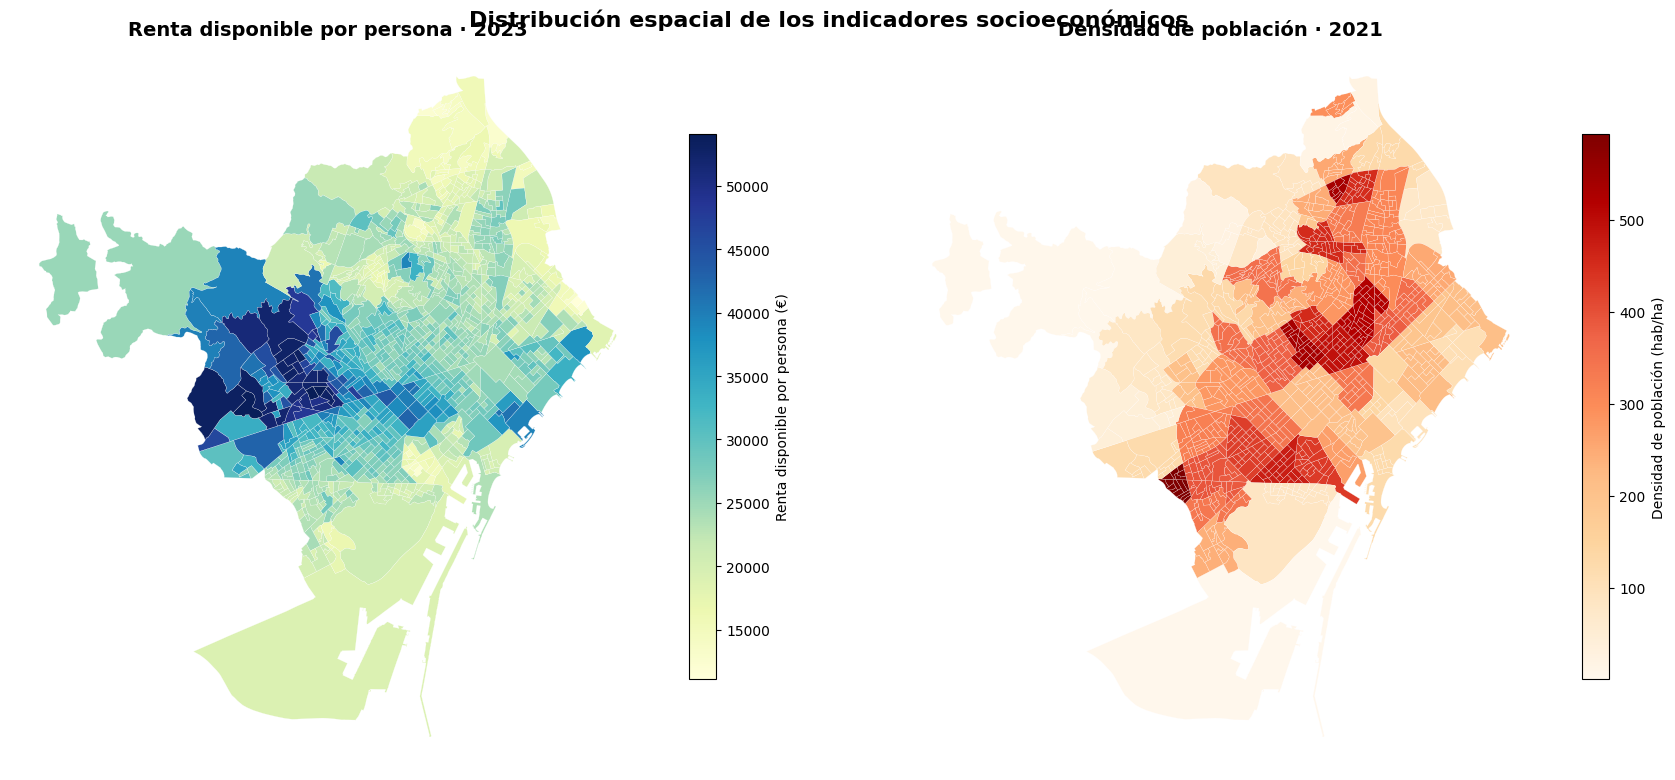

In [ ]:
# ============================================================
# 2.4.2. DISTRIBUCIÓN ESPACIAL DE RENTA Y DENSIDAD
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8)
)

# ------------------------------------------------------------
# Renta disponible
# ------------------------------------------------------------

gdf_socio.plot(
    column="Import_Euros",
    cmap="YlGnBu",
    linewidth=0.15,
    edgecolor="white",
    legend=True,
    ax=axes[0],
    legend_kwds={
        "label": "Renta disponible por persona (€)",
        "shrink": 0.75
    }
)

axes[0].set_title(
    "Renta disponible por persona · 2023",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_axis_off()


# ------------------------------------------------------------
# Densidad de población
# ------------------------------------------------------------

gdf_socio.plot(
    column="Densitat (hab/ha)",
    cmap="OrRd",
    linewidth=0.15,
    edgecolor="white",
    legend=True,
    ax=axes[1],
    legend_kwds={
        "label": "Densidad de población (hab/ha)",
        "shrink": 0.75
    }
)

axes[1].set_title(
    "Densidad de población · 2021",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_axis_off()


# ------------------------------------------------------------
# Título general
# ------------------------------------------------------------

fig.suptitle(
    "Distribución espacial de los indicadores socioeconómicos",
    fontsize=16,
    fontweight="bold",
    y=0.97
)

plt.tight_layout()

plt.show()

### Resultado del control cartográfico

La representación de los indicadores socioeconómicos evidencia una marcada heterogeneidad espacial en Barcelona.

La **renta disponible por persona** presenta diferencias territoriales importantes, con agrupaciones de secciones censales de renta elevada y otras áreas con valores sensiblemente inferiores. La resolución a escala de sección censal permite identificar variaciones socioeconómicas incluso dentro de un mismo barrio.

La **densidad de población** muestra un patrón espacial diferente y más agregado, coherente con su resolución original a escala de barrio. Las mayores densidades se concentran principalmente en determinadas áreas del tejido urbano consolidado, mientras que las zonas periféricas, grandes espacios no residenciales y sectores de menor intensidad urbana presentan valores inferiores.

La comparación confirma que ambas variables aportan información complementaria sobre la estructura urbana: la renta caracteriza las diferencias socioeconómicas a escala censal, mientras que la densidad representa la intensidad residencial del territorio.

Estas variables se incorporarán posteriormente como **covariables espaciales estáticas**, por lo que su utilización en el modelo permitirá analizar diferencias territoriales, pero no interpretar cambios temporales de renta o población durante el periodo 2018–2024.

# 3 . UNIDADES ADMINISTRATIVAS DE BARCELONA

La estructura administrativa de Barcelona se incorpora al análisis como **referencia territorial para la caracterización geoespacial de la ciudad** y para la posterior integración de las diferentes variables explicativas con la red viaria.

La cartografía oficial permite representar la organización jerárquica del territorio en **distritos, barrios y secciones censales**, proporcionando identificadores espaciales comunes para relacionar información procedente de distintas fuentes y escalas territoriales.

En este bloque se realizará la inspección y validación de la cartografía administrativa, comprobando la estructura de las unidades territoriales, la integridad de las geometrías, el sistema de referencia espacial y la cobertura del ámbito de estudio.

Estas unidades se utilizarán posteriormente como soporte para la **asignación espacial de variables socioeconómicas, urbanas y ambientales a los tramos viarios**, manteniendo la trazabilidad de la unidad territorial de procedencia de cada indicador.

## 3.1. Fuente de información

La cartografía procede del portal **Open Data BCN del Ayuntamiento de Barcelona**.

- **Recurso:** `Unitats_Administratives_BCN.shp`
- **Contenido:** unidades administrativas de la ciudad de Barcelona.
- **Niveles territoriales disponibles:** distritos, barrios, áreas estadísticas básicas (AEB) y secciones censales.
- **Uso en el análisis:** estructuración territorial e integración geoespacial de las diferentes fuentes de información.

**Fuente oficial:**  
https://opendata-ajuntament.barcelona.cat/data/es/dataset/20170706-districtes-barris/resource/11851135-6919-4dcb-91ed-821e5e87a428

In [ ]:
# ============================================================
# 3.1. CARGA E INVENTARIO DE LAS UNIDADES ADMINISTRATIVAS
# ============================================================

print("=" * 100)
print("UNIDADES ADMINISTRATIVAS DE BARCELONA")
print("=" * 100)

# ------------------------------------------------------------
# 1. Localización de las capas administrativas disponibles
# ------------------------------------------------------------

shapefiles_admin = sorted(
    RUTA_SOCIOECONOMICOS.rglob("*UNITATS_ADM.shp")
)

if not shapefiles_admin:
    raise FileNotFoundError(
        "No se han localizado capas administrativas en "
        f"{RUTA_SOCIOECONOMICOS}"
    )

df_capas_admin = pd.DataFrame({
    "ARCHIVO": [
        archivo.name
        for archivo in shapefiles_admin
    ],
    "RUTA_RELATIVA": [
        str(archivo.relative_to(RUTA_SOCIOECONOMICOS))
        for archivo in shapefiles_admin
    ]
})

print(f"\nShapefiles administrativos localizados: {len(df_capas_admin)}")
display(df_capas_admin)


# ------------------------------------------------------------
# 2. Identificación de las principales escalas territoriales
# ------------------------------------------------------------

patrones = {
    "DISTRITOS": "Distr",
    "BARRIOS": "Barri",
    "AEB": "AEB",
    "SECCIONES_CENSALES": "SecCens"
}

capas_seleccionadas = {}

for nivel, patron in patrones.items():

    candidatos = [
        archivo
        for archivo in shapefiles_admin
        if patron.lower() in archivo.name.lower()
    ]

    if candidatos:
        capas_seleccionadas[nivel] = candidatos[0]


print("\nCapas territoriales identificadas:")

for nivel, ruta in capas_seleccionadas.items():
    print(f"{nivel:20s}: {ruta.name}")


# ------------------------------------------------------------
# 3. Lectura de las capas seleccionadas
# ------------------------------------------------------------

gdfs_admin = {}

for nivel, ruta in capas_seleccionadas.items():

    gdf_nivel = gpd.read_file(ruta)

    gdfs_admin[nivel] = gdf_nivel

    print(
        f"\n{nivel}: "
        f"{len(gdf_nivel):,} registros | "
        f"CRS: {gdf_nivel.crs}"
    )


# ------------------------------------------------------------
# 4. Resumen general
# ------------------------------------------------------------

resumen_capas_admin = pd.DataFrame([
    {
        "NIVEL": nivel,
        "REGISTROS": len(gdf_nivel),
        "TIPO_GEOMETRIA": ", ".join(
            sorted(
                gdf_nivel.geometry
                .geom_type
                .dropna()
                .unique()
            )
        ),
        "CRS": str(gdf_nivel.crs),
        "GEOMETRIAS_NULAS": int(
            gdf_nivel.geometry.isna().sum()
        ),
        "GEOMETRIAS_INVALIDAS": int(
            (~gdf_nivel.geometry.is_valid).sum()
        )
    }
    for nivel, gdf_nivel in gdfs_admin.items()
])

print("\n" + "=" * 100)
print("RESUMEN DE CAPAS ADMINISTRATIVAS")
print("=" * 100)

display(resumen_capas_admin)

UNIDADES ADMINISTRATIVAS DE BARCELONA

Shapefiles administrativos localizados: 24


,ARCHIVO,RUTA_RELATIVA
0,0301040100_AEB_UNITATS_ADM.shp,BCN_UNITATS_ADM /0301040100_AEB_UNITATS_ADM.shp
1,0301040100_Àrea_I_UNITATS_ADM.shp,BCN_UNITATS_ADM /0301040100_Àrea_I_UNITATS_AD...
2,0301040100_Barris_UNITATS_ADM.shp,BCN_UNITATS_ADM /0301040100_Barris_UNITATS_ADM...
3,0301040100_Districtes_UNITATS_ADM.shp,BCN_UNITATS_ADM /0301040100_Districtes_UNITATS...
4,0301040100_GranBarri_UNITATS_ADM.shp,BCN_UNITATS_ADM /0301040100_GranBarri_UNITATS_...
5,0301040100_SecCens_UNITATS_ADM.shp,BCN_UNITATS_ADM /0301040100_SecCens_UNITATS_AD...
6,0301040100_TermeMunicipal_UNITATS_ADM.shp,BCN_UNITATS_ADM /0301040100_TermeMunicipal_UNI...
7,0301040100_ZUA_UNITATS_ADM.shp,BCN_UNITATS_ADM /0301040100_ZUA_UNITATS_ADM.shp
8,0301040100_AEB_UNITATS_ADM.shp,UNI/0301040100_AEB_UNITATS_ADM.shp
9,0301040100_Àrea_I_UNITATS_ADM.shp,UNI/0301040100_Àrea_I_UNITATS_ADM.shp



Capas territoriales identificadas:
DISTRITOS           : 0301040100_Districtes_UNITATS_ADM.shp
BARRIOS             : 0301040100_Barris_UNITATS_ADM.shp
AEB                 : 0301040100_AEB_UNITATS_ADM.shp
SECCIONES_CENSALES  : 0301040100_SecCens_UNITATS_ADM.shp

DISTRITOS: 10 registros | CRS: EPSG:25831

BARRIOS: 73 registros | CRS: EPSG:25831

AEB: 233 registros | CRS: EPSG:25831

SECCIONES_CENSALES: 1,068 registros | CRS: EPSG:25831

RESUMEN DE CAPAS ADMINISTRATIVAS


,NIVEL,REGISTROS,TIPO_GEOMETRIA,CRS,GEOMETRIAS_NULAS,GEOMETRIAS_INVALIDAS
0,DISTRITOS,10,"MultiPolygon, Polygon",EPSG:25831,0,0
1,BARRIOS,73,"MultiPolygon, Polygon",EPSG:25831,0,0
2,AEB,233,"MultiPolygon, Polygon",EPSG:25831,0,0
3,SECCIONES_CENSALES,1068,"MultiPolygon, Polygon",EPSG:25831,0,0


### Resultado del inventario y validación de las unidades administrativas

El inventario identifica las diferentes capas territoriales disponibles y permite seleccionar los cuatro niveles administrativos de interés para el análisis: **distritos, barrios, áreas estadísticas básicas (AEB) y secciones censales**.

La estructura territorial resultante está formada por:

- **10 distritos**.
- **73 barrios**.
- **233 áreas estadísticas básicas (AEB)**.
- **1.068 secciones censales**.

Todas las capas se encuentran proyectadas en el sistema de referencia **ETRS89 / UTM zona 31N (EPSG:25831)**, garantizando su compatibilidad con el resto de la información utilizada en el análisis geoespacial.

La auditoría geométrica no detecta geometrías nulas ni inválidas en ninguno de los cuatro niveles territoriales. Las entidades están representadas mediante geometrías de tipo `Polygon` y `MultiPolygon`.

La cartografía administrativa queda, por tanto, validada como referencia territorial para las posteriores operaciones de integración espacial.

## 3.2. Inspección de la estructura de atributos

Una vez identificadas y validadas las principales capas administrativas, se analiza la estructura de sus atributos con el objetivo de determinar los campos disponibles para establecer relaciones entre los distintos niveles territoriales.

La inspección se centra en **distritos, barrios, áreas estadísticas básicas (AEB) y secciones censales**, revisando sus identificadores administrativos, número de valores únicos y correspondencia con el número de entidades de cada capa.

Este análisis permite seleccionar posteriormente las claves territoriales necesarias para mantener la relación jerárquica entre las diferentes escalas espaciales.

In [ ]:
# ============================================================
# 3.2. INSPECCIÓN DE LA ESTRUCTURA DE ATRIBUTOS
# ============================================================

print("=" * 100)
print("ESTRUCTURA DE ATRIBUTOS DE LAS UNIDADES ADMINISTRATIVAS")
print("=" * 100)

resumen_atributos = []

for nivel, gdf_nivel in gdfs_admin.items():

    print("\n" + "=" * 100)
    print(nivel)
    print("=" * 100)

    print(f"Registros : {len(gdf_nivel):,}")
    print(f"Columnas  : {len(gdf_nivel.columns)}")
    print(f"CRS       : {gdf_nivel.crs}")

    # --------------------------------------------------------
    # Columnas disponibles
    # --------------------------------------------------------

    print("\nColumnas disponibles:")
    print(gdf_nivel.columns.tolist())

    # --------------------------------------------------------
    # Valores únicos por atributo
    # --------------------------------------------------------

    columnas_atributos = [
        col
        for col in gdf_nivel.columns
        if col != "geometry"
    ]

    for columna in columnas_atributos:

        resumen_atributos.append({
            "NIVEL": nivel,
            "ATRIBUTO": columna,
            "TIPO": str(gdf_nivel[columna].dtype),
            "VALORES_UNICOS": gdf_nivel[columna].nunique(dropna=True),
            "NULOS": int(gdf_nivel[columna].isna().sum())
        })

    # --------------------------------------------------------
    # Muestra
    # --------------------------------------------------------

    display(
        gdf_nivel
        .drop(columns="geometry")
        .head(3)
    )


# ------------------------------------------------------------
# Resumen conjunto
# ------------------------------------------------------------

df_atributos_admin = pd.DataFrame(
    resumen_atributos
)

print("\n" + "=" * 100)
print("RESUMEN DE ATRIBUTOS")
print("=" * 100)

display(df_atributos_admin)

ESTRUCTURA DE ATRIBUTOS DE LAS UNIDADES ADMINISTRATIVAS

DISTRITOS
Registros : 10
Columnas  : 47
CRS       : EPSG:25831

Columnas disponibles:
['ID_ANNEX', 'ANNEXDESCR', 'ID_TEMA', 'TEMA_DESCR', 'ID_CONJUNT', 'CONJ_DESCR', 'ID_SUBCONJ', 'SCONJ_DESC', 'ID_ELEMENT', 'ELEM_DESCR', 'NIVELL', 'NDESCR_CA', 'NDESCR_ES', 'NDESCR_EN', 'TERME', 'DISTRICTE', 'BARRI', 'AEB', 'SEC_CENS', 'GRANBARRI', 'ZUA', 'AREA_I', 'LITERAL', 'PERIMETRE', 'AREA', 'ORD_REPRES', 'CODI_UA', 'TIPUS_UA', 'NOM', 'WEB1', 'WEB2', 'WEB3', 'DOCUMENTA', 'RANGESCALA', 'TIPUS_POL', 'GRUIX_ID', 'GRUIXDIMEN', 'ESTIL_ID', 'ESTIL_QGIS', 'VALOR1QGIS', 'VALOR2QGIS', 'COL_FARCIT', 'FCOL_DESCR', 'FHEX_COLOR', 'COL_DESCR', 'HEX_COLOR7', 'geometry']


,ID_ANNEX,ANNEXDESCR,ID_TEMA,TEMA_DESCR,ID_CONJUNT,CONJ_DESCR,ID_SUBCONJ,SCONJ_DESC,ID_ELEMENT,ELEM_DESCR,...,GRUIXDIMEN,ESTIL_ID,ESTIL_QGIS,VALOR1QGIS,VALOR2QGIS,COL_FARCIT,FCOL_DESCR,FHEX_COLOR,COL_DESCR,HEX_COLOR7
0,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,LÃ­mit de districte,...,70.0,0,SÃ²lid,0,0,1,Negre,#000000,Negre,#000000
1,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,LÃ­mit de districte,...,70.0,0,SÃ²lid,0,0,1,Negre,#000000,Negre,#000000
2,01,Grup - I,0104,Unitats Administratives,010412,Districtes,01041201,Districte,0104120101,LÃ­mit de districte,...,70.0,0,SÃ²lid,0,0,1,Negre,#000000,Negre,#000000



BARRIOS
Registros : 73
Columnas  : 47
CRS       : EPSG:25831

Columnas disponibles:
['ID_ANNEX', 'ANNEXDESCR', 'ID_TEMA', 'TEMA_DESCR', 'ID_CONJUNT', 'CONJ_DESCR', 'ID_SUBCONJ', 'SCONJ_DESC', 'ID_ELEMENT', 'ELEM_DESCR', 'NIVELL', 'NDESCR_CA', 'NDESCR_ES', 'NDESCR_EN', 'TERME', 'DISTRICTE', 'BARRI', 'AEB', 'SEC_CENS', 'GRANBARRI', 'ZUA', 'AREA_I', 'LITERAL', 'PERIMETRE', 'AREA', 'ORD_REPRES', 'CODI_UA', 'TIPUS_UA', 'NOM', 'WEB1', 'WEB2', 'WEB3', 'DOCUMENTA', 'RANGESCALA', 'TIPUS_POL', 'GRUIX_ID', 'GRUIXDIMEN', 'ESTIL_ID', 'ESTIL_QGIS', 'VALOR1QGIS', 'VALOR2QGIS', 'COL_FARCIT', 'FCOL_DESCR', 'FHEX_COLOR', 'COL_DESCR', 'HEX_COLOR7', 'geometry']


,ID_ANNEX,ANNEXDESCR,ID_TEMA,TEMA_DESCR,ID_CONJUNT,CONJ_DESCR,ID_SUBCONJ,SCONJ_DESC,ID_ELEMENT,ELEM_DESCR,...,GRUIXDIMEN,ESTIL_ID,ESTIL_QGIS,VALOR1QGIS,VALOR2QGIS,COL_FARCIT,FCOL_DESCR,FHEX_COLOR,COL_DESCR,HEX_COLOR7
0,01,Grup - I,0104,Unitats Administratives,010413,Barris,01041301,Barri,0104130101,LÃ­mit de barri,...,70.0,0,SÃ²lid,0,0,41,NULL,#E66900,NULL,#73A88F
1,01,Grup - I,0104,Unitats Administratives,010413,Barris,01041301,Barri,0104130101,LÃ­mit de barri,...,70.0,0,SÃ²lid,0,0,41,NULL,#E66900,NULL,#73A88F
2,01,Grup - I,0104,Unitats Administratives,010413,Barris,01041301,Barri,0104130101,LÃ­mit de barri,...,70.0,0,SÃ²lid,0,0,41,NULL,#E66900,NULL,#73A88F



AEB
Registros : 233
Columnas  : 47
CRS       : EPSG:25831

Columnas disponibles:
['ID_ANNEX', 'ANNEXDESCR', 'ID_TEMA', 'TEMA_DESCR', 'ID_CONJUNT', 'CONJ_DESCR', 'ID_SUBCONJ', 'SCONJ_DESC', 'ID_ELEMENT', 'ELEM_DESCR', 'NIVELL', 'NDESCR_CA', 'NDESCR_ES', 'NDESCR_EN', 'TERME', 'DISTRICTE', 'BARRI', 'AEB', 'SEC_CENS', 'GRANBARRI', 'ZUA', 'AREA_I', 'LITERAL', 'PERIMETRE', 'AREA', 'ORD_REPRES', 'CODI_UA', 'TIPUS_UA', 'NOM', 'WEB1', 'WEB2', 'WEB3', 'DOCUMENTA', 'RANGESCALA', 'TIPUS_POL', 'GRUIX_ID', 'GRUIXDIMEN', 'ESTIL_ID', 'ESTIL_QGIS', 'VALOR1QGIS', 'VALOR2QGIS', 'COL_FARCIT', 'FCOL_DESCR', 'FHEX_COLOR', 'COL_DESCR', 'HEX_COLOR7', 'geometry']


,ID_ANNEX,ANNEXDESCR,ID_TEMA,TEMA_DESCR,ID_CONJUNT,CONJ_DESCR,ID_SUBCONJ,SCONJ_DESC,ID_ELEMENT,ELEM_DESCR,...,GRUIXDIMEN,ESTIL_ID,ESTIL_QGIS,VALOR1QGIS,VALOR2QGIS,COL_FARCIT,FCOL_DESCR,FHEX_COLOR,COL_DESCR,HEX_COLOR7
0,01,Grup - I,0104,Unitats Administratives,010414,Ãrea estadÃ­stica bÃ sica,01041401,Ãrea estadÃ­stica bÃ sica,0104140101,LÃ­mit Ã rea estadÃ­stica bÃ sica,...,40.0,0,SÃ²lid,0,0,18,NULL,#FFA800,?????,#CC6804
1,01,Grup - I,0104,Unitats Administratives,010414,Ãrea estadÃ­stica bÃ sica,01041401,Ãrea estadÃ­stica bÃ sica,0104140101,LÃ­mit Ã rea estadÃ­stica bÃ sica,...,40.0,0,SÃ²lid,0,0,18,NULL,#FFA800,?????,#CC6804
2,01,Grup - I,0104,Unitats Administratives,010414,Ãrea estadÃ­stica bÃ sica,01041401,Ãrea estadÃ­stica bÃ sica,0104140101,LÃ­mit Ã rea estadÃ­stica bÃ sica,...,40.0,0,SÃ²lid,0,0,18,NULL,#FFA800,?????,#CC6804



SECCIONES_CENSALES
Registros : 1,068
Columnas  : 47
CRS       : EPSG:25831

Columnas disponibles:
['ID_ANNEX', 'ANNEXDESCR', 'ID_TEMA', 'TEMA_DESCR', 'ID_CONJUNT', 'CONJ_DESCR', 'ID_SUBCONJ', 'SCONJ_DESC', 'ID_ELEMENT', 'ELEM_DESCR', 'NIVELL', 'NDESCR_CA', 'NDESCR_ES', 'NDESCR_EN', 'TERME', 'DISTRICTE', 'BARRI', 'AEB', 'SEC_CENS', 'GRANBARRI', 'ZUA', 'AREA_I', 'LITERAL', 'PERIMETRE', 'AREA', 'ORD_REPRES', 'CODI_UA', 'TIPUS_UA', 'NOM', 'WEB1', 'WEB2', 'WEB3', 'DOCUMENTA', 'RANGESCALA', 'TIPUS_POL', 'GRUIX_ID', 'GRUIXDIMEN', 'ESTIL_ID', 'ESTIL_QGIS', 'VALOR1QGIS', 'VALOR2QGIS', 'COL_FARCIT', 'FCOL_DESCR', 'FHEX_COLOR', 'COL_DESCR', 'HEX_COLOR7', 'geometry']


,ID_ANNEX,ANNEXDESCR,ID_TEMA,TEMA_DESCR,ID_CONJUNT,CONJ_DESCR,ID_SUBCONJ,SCONJ_DESC,ID_ELEMENT,ELEM_DESCR,...,GRUIXDIMEN,ESTIL_ID,ESTIL_QGIS,VALOR1QGIS,VALOR2QGIS,COL_FARCIT,FCOL_DESCR,FHEX_COLOR,COL_DESCR,HEX_COLOR7
0,01,Grup - I,0104,Unitats Administratives,010415,SecciÃ³ censal,01041501,SecciÃ³ censal,0104150101,LÃ­mit de la secciÃ³ censal,...,10.0,0,SÃ²lid,0,0,18,NULL,#FFA800,?????,#CC6804
1,01,Grup - I,0104,Unitats Administratives,010415,SecciÃ³ censal,01041501,SecciÃ³ censal,0104150101,LÃ­mit de la secciÃ³ censal,...,10.0,0,SÃ²lid,0,0,18,NULL,#FFA800,?????,#CC6804
2,01,Grup - I,0104,Unitats Administratives,010415,SecciÃ³ censal,01041501,SecciÃ³ censal,0104150101,LÃ­mit de la secciÃ³ censal,...,10.0,0,SÃ²lid,0,0,18,NULL,#FFA800,?????,#CC6804



RESUMEN DE ATRIBUTOS


,NIVEL,ATRIBUTO,TIPO,VALORES_UNICOS,NULOS
0,DISTRITOS,ID_ANNEX,object,1,0
1,DISTRITOS,ANNEXDESCR,object,1,0
2,DISTRITOS,ID_TEMA,object,1,0
3,DISTRITOS,TEMA_DESCR,object,1,0
4,DISTRITOS,ID_CONJUNT,object,1,0
...,...,...,...,...,...
179,SECCIONES_CENSALES,COL_FARCIT,object,1,0
180,SECCIONES_CENSALES,FCOL_DESCR,object,1,0
181,SECCIONES_CENSALES,FHEX_COLOR,object,1,0
182,SECCIONES_CENSALES,COL_DESCR,object,1,0


### Resultado de la inspección de atributos

Las cuatro capas administrativas presentan una **estructura de atributos homogénea**, con 47 columnas y un sistema de referencia común **EPSG:25831**.

Entre los campos disponibles se encuentran los identificadores correspondientes a `DISTRICTE`, `BARRI`, `AEB` y `SEC_CENS`, junto con otros atributos de identificación como `CODI_UA`, `TIPUS_UA` y `NOM`.

Esta estructura permite conservar explícitamente la jerarquía territorial y establecer relaciones entre los diferentes niveles administrativos sin recurrir inicialmente a operaciones espaciales.

La presencia de identificadores territoriales comunes resulta especialmente relevante para las posteriores operaciones de integración, ya que permitirá relacionar las variables disponibles a diferentes escalas territoriales y mantener la trazabilidad de la unidad administrativa de procedencia.

Una parte importante de los atributos restantes corresponde a metadatos, propiedades de representación cartográfica y campos auxiliares de la fuente original, por lo que no será necesario conservarlos en las capas finales destinadas al modelado.

## 3.3. Validación de la jerarquía territorial

La estructura administrativa presenta identificadores específicos para los diferentes niveles territoriales. Algunos de estos códigos, como el número de sección censal, no constituyen por sí solos identificadores únicos para el conjunto de Barcelona, ya que pueden repetirse en diferentes ámbitos administrativos.

Por este motivo, la validación de la jerarquía territorial se realiza mediante **claves territoriales compuestas**, incorporando los niveles administrativos superiores necesarios para identificar de forma inequívoca cada unidad.

Se comprueba la coherencia de las relaciones **Distrito → Barrio → AEB → Sección censal**, así como la ausencia de valores nulos y duplicidades en las claves territoriales construidas.

In [ ]:
# ============================================================
# 3.3. VALIDACIÓN DE LA JERARQUÍA TERRITORIAL
# ============================================================

print("=" * 100)
print("VALIDACIÓN DE LA JERARQUÍA TERRITORIAL")
print("=" * 100)

# ------------------------------------------------------------
# 1. Selección de la capa de mayor resolución
# ------------------------------------------------------------

gdf_secciones = gdfs_admin["SECCIONES_CENSALES"].copy()


# ------------------------------------------------------------
# 2. Normalización de identificadores
# ------------------------------------------------------------

for columna in ["DISTRICTE", "BARRI", "AEB", "SEC_CENS"]:

    gdf_secciones[columna] = (
        gdf_secciones[columna]
        .astype(str)
        .str.strip()
    )


# ------------------------------------------------------------
# 3. Construcción de claves territoriales compuestas
# ------------------------------------------------------------

gdf_secciones["CLAVE_BARRIO"] = (
    gdf_secciones["DISTRICTE"]
    + "_"
    + gdf_secciones["BARRI"]
)

gdf_secciones["CLAVE_AEB"] = (
    gdf_secciones["DISTRICTE"]
    + "_"
    + gdf_secciones["BARRI"]
    + "_"
    + gdf_secciones["AEB"]
)

gdf_secciones["CLAVE_SECCION"] = (
    gdf_secciones["DISTRICTE"]
    + "_"
    + gdf_secciones["BARRI"]
    + "_"
    + gdf_secciones["SEC_CENS"]
)


# ------------------------------------------------------------
# 4. Comprobación de valores nulos originales
# ------------------------------------------------------------

columnas_jerarquia = [
    "DISTRICTE",
    "BARRI",
    "AEB",
    "SEC_CENS"
]

nulos_jerarquia = (
    gdf_secciones[columnas_jerarquia]
    .replace("nan", pd.NA)
    .isna()
    .sum()
    .rename("NULOS")
    .reset_index()
    .rename(columns={"index": "CAMPO"})
)

print("\nValores nulos en los identificadores territoriales:")
display(nulos_jerarquia)


# ------------------------------------------------------------
# 5. Número real de unidades territoriales
# ------------------------------------------------------------

resumen_jerarquia = pd.DataFrame({
    "NIVEL": [
        "Distritos",
        "Barrios",
        "AEB",
        "Secciones censales"
    ],
    "UNIDADES": [
        gdf_secciones["DISTRICTE"].nunique(),
        gdf_secciones["CLAVE_BARRIO"].nunique(),
        gdf_secciones["CLAVE_AEB"].nunique(),
        gdf_secciones["CLAVE_SECCION"].nunique()
    ]
})

print("\nUnidades territoriales representadas:")
display(resumen_jerarquia)


# ------------------------------------------------------------
# 6. Validación de las relaciones jerárquicas
# ------------------------------------------------------------

# Cada barrio pertenece a un único distrito
control_barrios = (
    gdf_secciones
    .groupby("CLAVE_BARRIO")["DISTRICTE"]
    .nunique()
)

barrios_inconsistentes = control_barrios[
    control_barrios > 1
]


# Cada AEB pertenece a un único barrio
control_aeb = (
    gdf_secciones
    .groupby("CLAVE_AEB")["CLAVE_BARRIO"]
    .nunique()
)

aeb_inconsistentes = control_aeb[
    control_aeb > 1
]


# Cada sección pertenece a una única AEB
control_secciones = (
    gdf_secciones
    .groupby("CLAVE_SECCION")["CLAVE_AEB"]
    .nunique()
)

secciones_inconsistentes = control_secciones[
    control_secciones > 1
]


# ------------------------------------------------------------
# 7. Unicidad de la clave censal
# ------------------------------------------------------------

duplicados_seccion = (
    gdf_secciones
    .duplicated(
        subset=["CLAVE_SECCION"],
        keep=False
    )
    .sum()
)


# ------------------------------------------------------------
# 8. Resumen de coherencia
# ------------------------------------------------------------

control_jerarquia = pd.DataFrame({
    "COMPROBACION": [
        "Barrios asociados a más de un distrito",
        "AEB asociadas a más de un barrio",
        "Secciones asociadas a más de una AEB",
        "Filas con clave censal duplicada"
    ],
    "INCONSISTENCIAS": [
        len(barrios_inconsistentes),
        len(aeb_inconsistentes),
        len(secciones_inconsistentes),
        duplicados_seccion
    ]
})

print("\n" + "=" * 100)
print("CONTROL DE COHERENCIA")
print("=" * 100)

display(control_jerarquia)


# ------------------------------------------------------------
# 9. Resultado global
# ------------------------------------------------------------

total_inconsistencias = (
    len(barrios_inconsistentes)
    + len(aeb_inconsistentes)
    + len(secciones_inconsistentes)
    + duplicados_seccion
)

if total_inconsistencias == 0:

    print(
        "\n✓ Jerarquía territorial validada correctamente: "
        "Distrito → Barrio → AEB → Sección censal."
    )

else:

    print(
        f"\n⚠ Se han detectado {total_inconsistencias} "
        "inconsistencias. Revisar antes de continuar."
    )

VALIDACIÓN DE LA JERARQUÍA TERRITORIAL

Valores nulos en los identificadores territoriales:


,CAMPO,NULOS
0,DISTRICTE,0
1,BARRI,0
2,AEB,0
3,SEC_CENS,0



Unidades territoriales representadas:


,NIVEL,UNIDADES
0,Distritos,10
1,Barrios,73
2,AEB,233
3,Secciones censales,1068



CONTROL DE COHERENCIA


,COMPROBACION,INCONSISTENCIAS
0,Barrios asociados a más de un distrito,0
1,AEB asociadas a más de un barrio,0
2,Secciones asociadas a más de una AEB,0
3,Filas con clave censal duplicada,0



✓ Jerarquía territorial validada correctamente: Distrito → Barrio → AEB → Sección censal.


### Resultado de la validación de la jerarquía territorial

La construcción de claves territoriales compuestas permite identificar de forma inequívoca las unidades administrativas y reproducir correctamente la estructura jerárquica de Barcelona.

La cartografía contiene **10 distritos, 73 barrios, 233 áreas estadísticas básicas (AEB) y 1.068 secciones censales**. No se detectan valores nulos en los identificadores utilizados.

Las comprobaciones realizadas confirman que cada barrio se encuentra asociado a un único distrito, cada AEB a un único barrio y cada sección censal a una única AEB. Asimismo, las **1.068 secciones censales presentan una clave territorial única**, sin duplicidades.

La jerarquía **Distrito → Barrio → AEB → Sección censal** queda, por tanto, validada y puede utilizarse de forma segura en las posteriores operaciones de integración geoespacial.

## 3.4. Preparación de las capas administrativas finales

Una vez comprobadas la integridad geométrica, la estructura de atributos y la coherencia jerárquica de las unidades administrativas, se preparan las capas que serán utilizadas en las posteriores operaciones de integración geoespacial.

La fuente original contiene numerosos atributos auxiliares asociados a representación cartográfica y metadatos que no son necesarios para el análisis. Por ello, se generan versiones simplificadas de las capas de **distritos, barrios, AEB y secciones censales**, conservando únicamente los identificadores territoriales, las denominaciones disponibles y la geometría.

Asimismo, se incorporan claves territoriales normalizadas que permiten identificar inequívocamente cada unidad y mantener las relaciones jerárquicas entre las diferentes escalas espaciales.

Estas capas constituirán la referencia administrativa utilizada posteriormente para la asignación y agregación de variables geoespaciales.

In [ ]:
# ============================================================
# 3.4. PREPARACIÓN DE LAS CAPAS ADMINISTRATIVAS FINALES
# ============================================================

print("=" * 100)
print("PREPARACIÓN DE CAPAS ADMINISTRATIVAS")
print("=" * 100)

capas_admin_finales = {}

# ------------------------------------------------------------
# 1. Función auxiliar para normalizar identificadores
# ------------------------------------------------------------

def normalizar_codigo(serie):
    return (
        serie
        .astype(str)
        .str.strip()
        .replace("nan", pd.NA)
    )


# ------------------------------------------------------------
# 2. DISTRITOS
# ------------------------------------------------------------

gdf_distritos = gdfs_admin["DISTRITOS"].copy()

gdf_distritos["DISTRICTE"] = normalizar_codigo(
    gdf_distritos["DISTRICTE"]
)

columnas_distritos = [
    col for col in [
        "DISTRICTE",
        "CODI_UA",
        "TIPUS_UA",
        "NOM",
        "geometry"
    ]
    if col in gdf_distritos.columns
]

gdf_distritos = (
    gdf_distritos[columnas_distritos]
    .copy()
    .reset_index(drop=True)
)

capas_admin_finales["DISTRITOS"] = gdf_distritos


# ------------------------------------------------------------
# 3. BARRIOS
# ------------------------------------------------------------

gdf_barrios = gdfs_admin["BARRIOS"].copy()

for col in ["DISTRICTE", "BARRI"]:
    gdf_barrios[col] = normalizar_codigo(
        gdf_barrios[col]
    )

gdf_barrios["CLAVE_BARRIO"] = (
    gdf_barrios["DISTRICTE"]
    + "_"
    + gdf_barrios["BARRI"]
)

columnas_barrios = [
    col for col in [
        "DISTRICTE",
        "BARRI",
        "CLAVE_BARRIO",
        "CODI_UA",
        "TIPUS_UA",
        "NOM",
        "geometry"
    ]
    if col in gdf_barrios.columns
]

gdf_barrios = (
    gdf_barrios[columnas_barrios]
    .copy()
    .reset_index(drop=True)
)

capas_admin_finales["BARRIOS"] = gdf_barrios


# ------------------------------------------------------------
# 4. ÁREAS ESTADÍSTICAS BÁSICAS
# ------------------------------------------------------------

gdf_aeb = gdfs_admin["AEB"].copy()

for col in ["DISTRICTE", "BARRI", "AEB"]:
    gdf_aeb[col] = normalizar_codigo(
        gdf_aeb[col]
    )

gdf_aeb["CLAVE_BARRIO"] = (
    gdf_aeb["DISTRICTE"]
    + "_"
    + gdf_aeb["BARRI"]
)

gdf_aeb["CLAVE_AEB"] = (
    gdf_aeb["DISTRICTE"]
    + "_"
    + gdf_aeb["BARRI"]
    + "_"
    + gdf_aeb["AEB"]
)

columnas_aeb = [
    col for col in [
        "DISTRICTE",
        "BARRI",
        "AEB",
        "CLAVE_BARRIO",
        "CLAVE_AEB",
        "CODI_UA",
        "TIPUS_UA",
        "NOM",
        "geometry"
    ]
    if col in gdf_aeb.columns
]

gdf_aeb = (
    gdf_aeb[columnas_aeb]
    .copy()
    .reset_index(drop=True)
)

capas_admin_finales["AEB"] = gdf_aeb


# ------------------------------------------------------------
# 5. SECCIONES CENSALES
# ------------------------------------------------------------

gdf_secciones_final = gdfs_admin[
    "SECCIONES_CENSALES"
].copy()

for col in [
    "DISTRICTE",
    "BARRI",
    "AEB",
    "SEC_CENS"
]:
    gdf_secciones_final[col] = normalizar_codigo(
        gdf_secciones_final[col]
    )

gdf_secciones_final["CLAVE_BARRIO"] = (
    gdf_secciones_final["DISTRICTE"]
    + "_"
    + gdf_secciones_final["BARRI"]
)

gdf_secciones_final["CLAVE_AEB"] = (
    gdf_secciones_final["DISTRICTE"]
    + "_"
    + gdf_secciones_final["BARRI"]
    + "_"
    + gdf_secciones_final["AEB"]
)

gdf_secciones_final["CLAVE_SECCION"] = (
    gdf_secciones_final["DISTRICTE"]
    + "_"
    + gdf_secciones_final["BARRI"]
    + "_"
    + gdf_secciones_final["SEC_CENS"]
)

columnas_secciones = [
    col for col in [
        "DISTRICTE",
        "BARRI",
        "AEB",
        "SEC_CENS",
        "CLAVE_BARRIO",
        "CLAVE_AEB",
        "CLAVE_SECCION",
        "CODI_UA",
        "TIPUS_UA",
        "NOM",
        "geometry"
    ]
    if col in gdf_secciones_final.columns
]

gdf_secciones_final = (
    gdf_secciones_final[columnas_secciones]
    .copy()
    .reset_index(drop=True)
)

capas_admin_finales[
    "SECCIONES_CENSALES"
] = gdf_secciones_final


# ------------------------------------------------------------
# 6. Resumen de las capas finales
# ------------------------------------------------------------

resumen_capas_finales = pd.DataFrame([
    {
        "CAPA": nombre,
        "REGISTROS": len(gdf),
        "COLUMNAS": len(gdf.columns),
        "CRS": str(gdf.crs),
        "GEOMETRIAS_NULAS": int(
            gdf.geometry.isna().sum()
        ),
        "GEOMETRIAS_INVALIDAS": int(
            (~gdf.geometry.is_valid).sum()
        )
    }
    for nombre, gdf in capas_admin_finales.items()
])

print("\nCapas administrativas preparadas:\n")

display(resumen_capas_finales)


# ------------------------------------------------------------
# 7. Comprobación de dimensiones esperadas
# ------------------------------------------------------------

esperados = {
    "DISTRITOS": 10,
    "BARRIOS": 73,
    "AEB": 233,
    "SECCIONES_CENSALES": 1068
}

print("\nControl de registros:")

for nombre, n_esperado in esperados.items():

    n_obtenido = len(
        capas_admin_finales[nombre]
    )

    estado = (
        "✓"
        if n_obtenido == n_esperado
        else "⚠"
    )

    print(
        f"{estado} {nombre:20s} "
        f"{n_obtenido:,} / {n_esperado:,}"
    )

PREPARACIÓN DE CAPAS ADMINISTRATIVAS

Capas administrativas preparadas:



,CAPA,REGISTROS,COLUMNAS,CRS,GEOMETRIAS_NULAS,GEOMETRIAS_INVALIDAS
0,DISTRITOS,10,5,EPSG:25831,0,0
1,BARRIOS,73,7,EPSG:25831,0,0
2,AEB,233,9,EPSG:25831,0,0
3,SECCIONES_CENSALES,1068,11,EPSG:25831,0,0



Control de registros:
✓ DISTRITOS            10 / 10
✓ BARRIOS              73 / 73
✓ AEB                  233 / 233
✓ SECCIONES_CENSALES   1,068 / 1,068


### Resultado de la preparación de las capas administrativas

La simplificación de las capas administrativas genera versiones finales destinadas específicamente a las posteriores operaciones de integración geoespacial.

Se conservan los identificadores territoriales, las claves jerárquicas, los campos descriptivos esenciales y la geometría, eliminándose los atributos auxiliares y de representación cartográfica que no aportan información al análisis.

Las capas resultantes mantienen exactamente la estructura territorial validada:

- **10 distritos**.
- **73 barrios**.
- **233 áreas estadísticas básicas (AEB)**.
- **1.068 secciones censales**.

Todas las capas conservan el sistema de referencia **ETRS89 / UTM zona 31N (EPSG:25831)** y no presentan geometrías nulas ni inválidas.

Las versiones simplificadas quedan preparadas para su utilización como referencia territorial en las posteriores operaciones de asignación, agregación e integración de variables geoespaciales.

## 3.5. Control cartográfico de las unidades administrativas

Como comprobación final de la preparación de la cartografía administrativa, se representa conjuntamente la estructura territorial de Barcelona en sus diferentes niveles de agregación.

La visualización permite verificar la cobertura espacial, la continuidad de las geometrías y el progresivo aumento de resolución territorial desde los distritos hasta las secciones censales.

Este control tiene carácter exploratorio y de validación visual y complementa las comprobaciones geométricas y jerárquicas realizadas previamente.

CONTROL CARTOGRÁFICO DE LAS UNIDADES ADMINISTRATIVAS


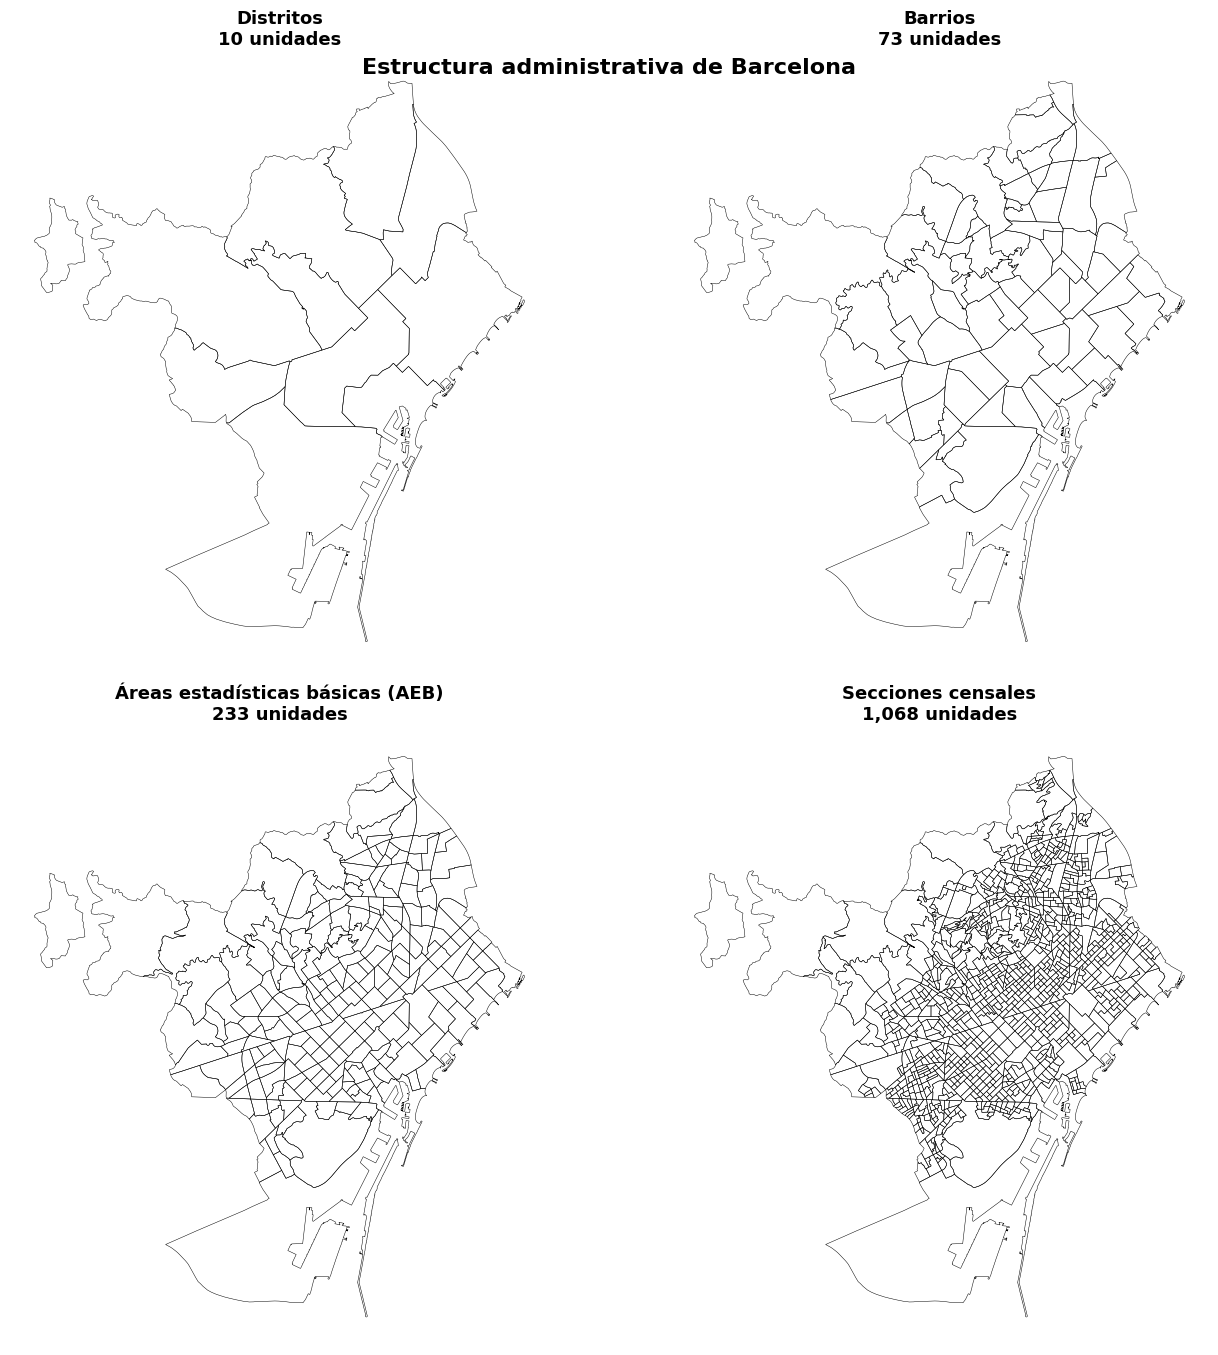

In [ ]:
# ============================================================
# 3.5. CONTROL CARTOGRÁFICO DE LAS UNIDADES ADMINISTRATIVAS
# ============================================================

import matplotlib.pyplot as plt

print("=" * 100)
print("CONTROL CARTOGRÁFICO DE LAS UNIDADES ADMINISTRATIVAS")
print("=" * 100)

# ------------------------------------------------------------
# 1. Configuración
# ------------------------------------------------------------

orden_capas = [
    ("DISTRITOS", "Distritos"),
    ("BARRIOS", "Barrios"),
    ("AEB", "Áreas estadísticas básicas (AEB)"),
    ("SECCIONES_CENSALES", "Secciones censales")
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 14)
)

axes = axes.ravel()


# ------------------------------------------------------------
# 2. Representación
# ------------------------------------------------------------

for ax, (clave, titulo) in zip(
    axes,
    orden_capas
):

    gdf = capas_admin_finales[clave]

    gdf.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=0.35
    )

    ax.set_title(
        f"{titulo}\n{len(gdf):,} unidades",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_axis_off()


# ------------------------------------------------------------
# 3. Título general
# ------------------------------------------------------------

fig.suptitle(
    "Estructura administrativa de Barcelona",
    fontsize=16,
    fontweight="bold",
    y=0.93
)

plt.tight_layout()

plt.show()

### Resultado del control cartográfico

La representación conjunta de las unidades administrativas confirma visualmente la correcta cobertura territorial de las cuatro escalas espaciales consideradas.

Se observa el incremento progresivo de resolución desde los **10 distritos** y **73 barrios** hasta las **233 áreas estadísticas básicas (AEB)** y las **1.068 secciones censales**, manteniéndose una cobertura espacial coherente del término municipal.

Este control visual, junto con las comprobaciones geométricas y jerárquicas realizadas previamente, permite considerar las capas administrativas preparadas para su utilización en las posteriores operaciones de integración geoespacial.

## 3.6. Exportación de las capas administrativas

Una vez completadas las comprobaciones geométricas, jerárquicas y cartográficas, las capas administrativas procesadas se exportan al directorio de **preintegración geoespacial**.

Se utiliza el formato **GeoPackage (GPKG)**, que permite almacenar conjuntamente las diferentes escalas territoriales en un único archivo, conservando los atributos, las geometrías y el sistema de referencia espacial.

El archivo generado contiene las capas de **distritos, barrios, áreas estadísticas básicas (AEB) y secciones censales**, que actuarán como cartografía administrativa de referencia durante las posteriores operaciones de integración espacial.

Como control adicional se genera una tabla resumen con el número de registros, campos, sistema de referencia y estado de las geometrías de cada capa.

In [ ]:
# ============================================================
# 3.6. EXPORTACIÓN DE LAS CAPAS ADMINISTRATIVAS
# ============================================================

from pathlib import Path
import pandas as pd

print("=" * 100)
print("EXPORTACIÓN DE LAS CAPAS ADMINISTRATIVAS")
print("=" * 100)

# ------------------------------------------------------------
# 1. Directorio único de PREINTEGRACIÓN
# ------------------------------------------------------------

RUTA_PREINTEGRACION = Path(
    "/content/drive/MyDrive/TFM/"
    "10_Machine_Learning_Geoespacial/"
    "PREINTEGRACION"
)

RUTA_PREINTEGRACION.mkdir(
    parents=True,
    exist_ok=True
)

print("\nDirectorio de salida:")
print(RUTA_PREINTEGRACION)


# ------------------------------------------------------------
# 2. Archivo GeoPackage de salida
# ------------------------------------------------------------

ruta_gpkg = (
    RUTA_PREINTEGRACION
    / "unidades_administrativas_barcelona.gpkg"
)

# Si existe una versión anterior, se elimina para evitar
# conservar capas obsoletas de ejecuciones previas.

if ruta_gpkg.exists():
    ruta_gpkg.unlink()


# ------------------------------------------------------------
# 3. Correspondencia entre objetos y capas del GeoPackage
# ------------------------------------------------------------

nombres_salida = {
    "DISTRITOS": "distritos",
    "BARRIOS": "barrios",
    "AEB": "aeb",
    "SECCIONES_CENSALES": "secciones_censales"
}


# ------------------------------------------------------------
# 4. Exportación de las cuatro capas
# ------------------------------------------------------------

for clave, nombre_capa in nombres_salida.items():

    gdf_salida = capas_admin_finales[clave].copy()

    gdf_salida.to_file(
        ruta_gpkg,
        layer=nombre_capa,
        driver="GPKG"
    )

    print(
        f"✓ {nombre_capa:20s} "
        f"{len(gdf_salida):,} registros"
    )


# ------------------------------------------------------------
# 5. Creación de tabla de control
# ------------------------------------------------------------

resumen_exportacion = pd.DataFrame([
    {
        "CAPA": nombre_capa,
        "REGISTROS": len(capas_admin_finales[clave]),
        "COLUMNAS": len(capas_admin_finales[clave].columns),
        "CRS": str(capas_admin_finales[clave].crs),
        "GEOMETRIAS_NULAS": int(
            capas_admin_finales[clave]
            .geometry
            .isna()
            .sum()
        ),
        "GEOMETRIAS_INVALIDAS": int(
            (~capas_admin_finales[clave]
             .geometry
             .is_valid)
            .sum()
        )
    }
    for clave, nombre_capa
    in nombres_salida.items()
])


# ------------------------------------------------------------
# 6. Exportación de la tabla de control
# ------------------------------------------------------------

ruta_control = (
    RUTA_PREINTEGRACION
    / "control_unidades_administrativas.csv"
)

resumen_exportacion.to_csv(
    ruta_control,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 7. Verificación física de los archivos
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("CONTROL DE EXPORTACIÓN")
print("=" * 100)

display(resumen_exportacion)

print("\nArchivos generados:")

print(
    f"✓ GeoPackage : {ruta_gpkg.name}"
    if ruta_gpkg.exists()
    else "✗ GeoPackage no encontrado"
)

print(
    f"✓ Control CSV: {ruta_control.name}"
    if ruta_control.exists()
    else "✗ CSV de control no encontrado"
)


# ------------------------------------------------------------
# 8. Verificación mediante relectura del GeoPackage
# ------------------------------------------------------------

print("\nVerificación de las capas exportadas:")

control_relectura = []

for clave, nombre_capa in nombres_salida.items():

    gdf_check = gpd.read_file(
        ruta_gpkg,
        layer=nombre_capa
    )

    control_relectura.append({
        "CAPA": nombre_capa,
        "REGISTROS_EXPORTADOS": len(gdf_check),
        "REGISTROS_ESPERADOS": len(
            capas_admin_finales[clave]
        ),
        "CRS": str(gdf_check.crs),
        "CORRECTO": (
            len(gdf_check)
            == len(capas_admin_finales[clave])
        )
    })

control_relectura = pd.DataFrame(
    control_relectura
)

display(control_relectura)


# ------------------------------------------------------------
# 9. Resultado final
# ------------------------------------------------------------

if (
    ruta_gpkg.exists()
    and ruta_control.exists()
    and control_relectura["CORRECTO"].all()
):

    print(
        "\n✓ Exportación completada y validada correctamente."
    )

    print(
        "✓ Las capas administrativas quedan disponibles "
        "en PREINTEGRACION."
    )

else:

    print(
        "\n⚠ Se ha detectado algún problema "
        "durante la exportación."
    )

EXPORTACIÓN DE LAS CAPAS ADMINISTRATIVAS

Directorio de salida:
/content/drive/MyDrive/TFM/10_Machine_Learning_Geoespacial/PREINTEGRACION
✓ distritos            10 registros
✓ barrios              73 registros
✓ aeb                  233 registros
✓ secciones_censales   1,068 registros

CONTROL DE EXPORTACIÓN


,CAPA,REGISTROS,COLUMNAS,CRS,GEOMETRIAS_NULAS,GEOMETRIAS_INVALIDAS
0,distritos,10,5,EPSG:25831,0,0
1,barrios,73,7,EPSG:25831,0,0
2,aeb,233,9,EPSG:25831,0,0
3,secciones_censales,1068,11,EPSG:25831,0,0



Archivos generados:
✓ GeoPackage : unidades_administrativas_barcelona.gpkg
✓ Control CSV: control_unidades_administrativas.csv

Verificación de las capas exportadas:


,CAPA,REGISTROS_EXPORTADOS,REGISTROS_ESPERADOS,CRS,CORRECTO
0,distritos,10,10,EPSG:25831,True
1,barrios,73,73,EPSG:25831,True
2,aeb,233,233,EPSG:25831,True
3,secciones_censales,1068,1068,EPSG:25831,True



✓ Exportación completada y validada correctamente.
✓ Las capas administrativas quedan disponibles en PREINTEGRACION.


### Resultado de la exportación

La exportación de las unidades administrativas se completa correctamente en el directorio de `PREINTEGRACION`.

Se genera un archivo GeoPackage, `unidades_administrativas_barcelona.gpkg`, que contiene las cuatro capas territoriales preparadas:

- **distritos:** 10 unidades.
- **barrios:** 73 unidades.
- **AEB:** 233 unidades.
- **secciones censales:** 1.068 unidades.

Todas las capas mantienen el sistema de referencia **ETRS89 / UTM zona 31N (EPSG:25831)** y no presentan geometrías nulas ni inválidas.

Como control adicional se genera `control_unidades_administrativas.csv`, con el resumen estructural de las capas exportadas.

La relectura posterior del GeoPackage confirma que el número de registros exportados coincide exactamente con el esperado en las cuatro escalas territoriales, por lo que la cartografía administrativa queda validada y disponible para las posteriores operaciones de integración geoespacial.

# 4 . AFOROS DE TRÁFICO RODADO

El tráfico rodado constituye una de las principales variables de movilidad consideradas en el estudio debido a su relación potencial con la distribución espacial y temporal de determinados contaminantes atmosféricos, especialmente aquellos asociados a las emisiones procedentes del transporte urbano.

Para representar esta componente se utilizan los datos de **aforos de tráfico de Barcelona correspondientes al periodo 2018–2024**. La información original proporciona valores de **Intensidad Media Diaria (IMD)** asociados a diferentes puntos de aforo de la red viaria.

Los datos de tráfico habían sido previamente tratados dentro del bloque de **Machine Learning Temporal**, donde se realizó la homogeneización de los archivos anuales, la construcción de la serie diaria y el tratamiento de los valores ausentes. Asimismo, se desarrolló una preintegración espacial destinada a relacionar los puntos de aforo con las estaciones de contaminación atmosférica.

En este bloque no se repite dicho preprocesamiento. Se recuperan los productos previamente generados y se realiza una nueva auditoría orientada específicamente a comprobar su idoneidad para la posterior integración geoespacial.

El objetivo es disponer de variables capaces de caracterizar la **intensidad del tráfico existente en el entorno de cada estación de calidad del aire**, manteniendo simultáneamente la dimensión temporal diaria del análisis.

## 4.1. Recuperación y auditoría de los datos previamente procesados

Los datos utilizados en este bloque proceden del procesamiento realizado previamente en el notebook correspondiente al **Machine Learning Temporal**.

Los archivos de partida están constituidos por los registros anuales de aforos de tráfico correspondientes a **2018–2024**. Estos archivos fueron homogeneizados y combinados para construir una base diaria común, conservando como variable principal el valor de **Intensidad Media Diaria (IMD)** asociado a cada punto de aforo.

Como resultado de dicho procesamiento se generaron dos productos intermedios principales:

- `df_aforos_2018_2024_Diario_Limpio.csv`: base temporal diaria de los puntos de aforo, resultante de la integración y limpieza de los archivos anuales.
- `df_trafico_rodado_preintegrado.csv`: base derivada de la integración espacial de los aforos con las estaciones de contaminación atmosférica.

La segunda base incorpora diferentes métricas destinadas a representar el tráfico existente alrededor de cada estación. Para ello se utilizaron áreas de influencia de **500, 750 y 1.000 m**, calculándose para cada radio variables relacionadas con el número de aforos disponibles, intensidad media y acumulada del tráfico, distancia al punto de aforo más próximo, cobertura de observaciones y una estimación ponderada espacialmente mediante **distancia inversa (IDW)**.

Esta estructura permite conservar diferentes escalas de influencia espacial y evaluar posteriormente cuál de ellas proporciona una representación más adecuada de la exposición de cada estación al tráfico rodado.

En esta fase se recuperan ambos productos sin modificar sus valores y se realiza una auditoría de su estructura, cobertura temporal, presencia de valores ausentes y consistencia de las variables generadas.

In [ ]:
# ============================================================
# 4.1. CARGA Y AUDITORÍA DE LOS DATOS DE AFOROS PREINTEGRADOS
# ============================================================

from pathlib import Path
import pandas as pd

print("=" * 100)
print("CARGA Y AUDITORÍA DE LOS DATOS DE AFOROS PREINTEGRADOS")
print("=" * 100)

# ------------------------------------------------------------
# 1. Ruta real del bloque ya preparado en el pipeline temporal
# ------------------------------------------------------------

RUTA_AFOROS = Path(
    "/content/drive/MyDrive/TFM/"
    "11_Machine_Learning_Temporal/"
    "PREINTEGRACION/"
    "02_Trafico_Rodado_y_Aforos"
)

if not RUTA_AFOROS.exists():
    raise FileNotFoundError(
        f"No se encuentra el directorio:\n{RUTA_AFOROS}"
    )

print("\nDirectorio localizado:")
print(RUTA_AFOROS)


# ------------------------------------------------------------
# 2. Archivos principales
# ------------------------------------------------------------

ruta_preintegrado = (
    RUTA_AFOROS /
    "df_trafico_rodado_preintegrado.csv"
)

ruta_diario = (
    RUTA_AFOROS /
    "df_aforos_2018_2024_Diario_Limpio.csv"
)

for ruta in [ruta_preintegrado, ruta_diario]:

    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encuentra el archivo:\n{ruta}"
        )


# ------------------------------------------------------------
# 3. Carga
# ------------------------------------------------------------

df_trafico_preintegrado = pd.read_csv(
    ruta_preintegrado,
    low_memory=False
)

df_aforos_diario = pd.read_csv(
    ruta_diario,
    low_memory=False
)


# ------------------------------------------------------------
# 4. Resumen estructural
# ------------------------------------------------------------

resumen_aforos = pd.DataFrame({
    "DATASET": [
        "TRAFICO_PREINTEGRADO",
        "AFOROS_DIARIO_LIMPIO"
    ],
    "REGISTROS": [
        len(df_trafico_preintegrado),
        len(df_aforos_diario)
    ],
    "COLUMNAS": [
        len(df_trafico_preintegrado.columns),
        len(df_aforos_diario.columns)
    ],
    "DUPLICADOS_EXACTOS": [
        int(df_trafico_preintegrado.duplicated().sum()),
        int(df_aforos_diario.duplicated().sum())
    ]
})

display(resumen_aforos)


# ------------------------------------------------------------
# 5. Columnas disponibles
# ------------------------------------------------------------

print("\nColumnas — tráfico preintegrado:")
display(
    pd.DataFrame(
        df_trafico_preintegrado.columns,
        columns=["COLUMNAS"]
    )
)

print("\nColumnas — aforos diarios limpios:")
display(
    pd.DataFrame(
        df_aforos_diario.columns,
        columns=["COLUMNAS"]
    )
)


# ------------------------------------------------------------
# 6. Nulos
# ------------------------------------------------------------

for nombre, df in [
    ("TRAFICO_PREINTEGRADO", df_trafico_preintegrado),
    ("AFOROS_DIARIO_LIMPIO", df_aforos_diario)
]:

    nulos = (
        df.isna()
        .sum()
        .to_frame("NULOS")
    )

    nulos["PORCENTAJE"] = (
        nulos["NULOS"]
        / len(df)
        * 100
    ).round(2)

    print(f"\nNulos — {nombre}:")
    display(
        nulos[nulos["NULOS"] > 0]
    )


# ------------------------------------------------------------
# 7. Cobertura temporal
# ------------------------------------------------------------

for nombre, df in [
    ("TRAFICO_PREINTEGRADO", df_trafico_preintegrado),
    ("AFOROS_DIARIO_LIMPIO", df_aforos_diario)
]:

    columnas_anio = [
        c for c in df.columns
        if c.upper() in ["AÑO", "ANY", "YEAR"]
    ]

    print(f"\nCobertura temporal — {nombre}:")

    if columnas_anio:

        col_anio = columnas_anio[0]

        display(
            df[col_anio]
            .value_counts()
            .sort_index()
            .rename("REGISTROS")
            .to_frame()
        )

    else:
        print(
            "No se ha identificado automáticamente "
            "una columna de año."
        )


# ------------------------------------------------------------
# 8. Muestras
# ------------------------------------------------------------

print("\nMuestra — tráfico preintegrado:")
display(df_trafico_preintegrado.head())

print("\nMuestra — aforos diarios limpios:")
display(df_aforos_diario.head())

print("\n✓ Auditoría inicial completada.")

CARGA Y AUDITORÍA DE LOS DATOS DE AFOROS PREINTEGRADOS

Directorio localizado:
/content/drive/MyDrive/TFM/11_Machine_Learning_Temporal/PREINTEGRACION/02_Trafico_Rodado_y_Aforos


,DATASET,REGISTROS,COLUMNAS,DUPLICADOS_EXACTOS
0,TRAFICO_PREINTEGRADO,20456,28,0
1,AFOROS_DIARIO_LIMPIO,1910502,9,0



Columnas — tráfico preintegrado:


,COLUMNAS
0,fecha
1,estacion_geo
2,n_aforos_total_500m
3,trafico_media_500m
4,trafico_suma_500m
5,n_aforos_obs_500m
6,dist_aforo_min_500m
7,trafico_idw_500m
8,n_aforos_total_750m
9,trafico_media_750m



Columnas — aforos diarios limpios:


...


Muestra — tráfico preintegrado:


,fecha,estacion_geo,n_aforos_total_500m,trafico_media_500m,trafico_suma_500m,n_aforos_obs_500m,dist_aforo_min_500m,trafico_idw_500m,n_aforos_total_750m,trafico_media_750m,...,dist_aforo_min_1000m,trafico_idw_1000m,anio,n_aforos_disponibles_500m,n_aforos_disponibles_750m,n_aforos_disponibles_1000m,cobertura_aforos_500m,cobertura_aforos_750m,cobertura_aforos_1000m,dist_aforo_min_m
0,2018-01-01,Ciutadella,12.0,13951.909091,153471.0,11.0,335.522721,14268.121254,34.0,12820.896552,...,335.522721,11940.712779,2018,13.0,37.0,45,0.846154,0.783784,0.800000,335.522721
1,2018-01-01,Eixample,11.0,20903.363636,229937.0,11.0,151.143897,20252.303462,37.0,16299.818182,...,151.143897,16512.196280,2018,14.0,41.0,79,0.785714,0.804878,0.772152,151.143897
2,2018-01-01,Gràcia,6.0,14698.400000,73492.0,5.0,111.348261,13493.561235,20.0,12925.062500,...,111.348261,12766.684955,2018,11.0,26.0,52,0.454545,0.615385,0.673077,111.348261
3,2018-01-01,Observatori Fabra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,896.472751,65980.000000,2018,NaN,NaN,2,NaN,NaN,1.000000,896.472751
4,2018-01-01,Palau Reial,9.0,17763.250000,71053.0,4.0,228.360102,22816.967118,18.0,31795.750000,...,228.360102,23417.898406,2018,11.0,22.0,32,0.363636,0.545455,0.656250,228.360102



Muestra — aforos diarios limpios:


,Fecha,Any,Mes,Id_aforament,Codi_tipus_dia,Desc_tipus_dia,Valor_IMD_original,Valor_IMD,IMD_imputado
0,2018-01-01,2018,1,10-SMD-1,1,lunes,76505.0,76505.0,0
1,2018-01-01,2018,1,10-SMD-2,1,lunes,69354.0,69354.0,0
2,2018-01-01,2018,1,10001,1,lunes,8625.0,8625.0,0
3,2018-01-01,2018,1,10002,1,lunes,13777.0,13777.0,0
4,2018-01-01,2018,1,10005,1,lunes,14675.0,14675.0,0



✓ Auditoría inicial completada.


### Resultado de la carga y auditoría inicial

La recuperación de los datos previamente procesados se realiza correctamente.

La base diaria limpia, `df_aforos_2018_2024_Diario_Limpio.csv`, contiene **1.910.502 registros y 9 variables**, correspondientes a las observaciones diarias de los diferentes puntos de aforo durante el periodo de estudio. No se detectan registros completamente duplicados.

La base `df_trafico_rodado_preintegrado.csv` contiene **20.456 registros y 28 variables** y constituye el producto preparado previamente para relacionar el tráfico rodado con las estaciones de contaminación atmosférica.

Esta segunda base mantiene una estructura **fecha–estación** e incorpora, para radios de **500, 750 y 1.000 m**, diferentes indicadores de intensidad y disponibilidad del tráfico: número de aforos, tráfico medio, tráfico acumulado, número de observaciones disponibles, distancia al aforo más próximo, cobertura de los puntos de medida y estimaciones ponderadas mediante distancia inversa (IDW).

La auditoría detecta diferencias de cobertura entre las distintas escalas espaciales. Las variables correspondientes a los radios de **500 y 750 m presentan un 12,50 % de valores ausentes**, mientras que en el radio de **1.000 m esta proporción disminuye hasta aproximadamente el 0,88 %** para las principales variables de intensidad de tráfico.

Estas ausencias no se corrigen en esta fase, ya que reflejan diferencias reales en la disponibilidad y proximidad de los puntos de aforo respecto a las estaciones de contaminación. Su tratamiento se realizará posteriormente teniendo en cuenta la cobertura de cada escala espacial y las necesidades del modelo.

Por tanto, los datos de tráfico previamente procesados se consideran adecuados para continuar con el análisis de su **cobertura temporal y espacial**, evitando repetir operaciones de limpieza e integración ya realizadas en el pipeline temporal.

## 4.2. Recuperación de la información espacial de los puntos de aforo

La incorporación del tráfico rodado al análisis geoespacial requiere disponer, además de las series temporales de intensidad, de la **localización de los puntos de aforo** utilizados para caracterizar la movilidad viaria.

Durante el preprocesamiento realizado previamente en el pipeline temporal se generaron archivos específicos de geolocalización destinados a asociar los identificadores de aforo con sus coordenadas y atributos espaciales.

En esta fase se recuperan e inventarían dichos productos antes de realizar nuevas transformaciones. Este procedimiento permite reutilizar la georreferenciación previamente construida, evitar duplicidades de procesamiento y mantener la trazabilidad entre los pipelines temporal y geoespacial.

Las nuevas capas o tablas que se generen posteriormente para el análisis geoespacial se almacenarán en el directorio específico de `PREINTEGRACION` del bloque de Machine Learning Geoespacial.

In [ ]:
# ============================================================
# 4.2. RECUPERACIÓN DE LA GEOLOCALIZACIÓN DE LOS AFOROS
# ============================================================

from pathlib import Path
import pandas as pd

print("=" * 100)
print("RECUPERACIÓN DE LA GEOLOCALIZACIÓN DE LOS AFOROS")
print("=" * 100)

# ------------------------------------------------------------
# 1. Ruta de origen
# ------------------------------------------------------------

RUTA_GEO_AFOROS = (
    RUTA_AFOROS /
    "GEOLOCALIZACION_AFOROS"
)

if not RUTA_GEO_AFOROS.exists():
    raise FileNotFoundError(
        f"No se encuentra la carpeta:\n{RUTA_GEO_AFOROS}"
    )

print("\nDirectorio de origen:")
print(RUTA_GEO_AFOROS)


# ------------------------------------------------------------
# 2. Ruta de salida del pipeline geoespacial
# ------------------------------------------------------------

RUTA_SALIDA_AFOROS = Path(
    "/content/drive/MyDrive/TFM/"
    "10_Machine_Learning_Geoespacial/"
    "PREINTEGRACION/"
    "02_Trafico_Rodado_y_Aforos"
)

RUTA_SALIDA_AFOROS.mkdir(
    parents=True,
    exist_ok=True
)

print("\nDirectorio de futuras salidas:")
print(RUTA_SALIDA_AFOROS)


# ------------------------------------------------------------
# 3. Inventario completo de archivos de geolocalización
# ------------------------------------------------------------

archivos_geo = sorted(
    [
        archivo
        for archivo in RUTA_GEO_AFOROS.rglob("*")
        if archivo.is_file()
    ]
)

inventario_geo = pd.DataFrame({
    "ARCHIVO": [
        archivo.name
        for archivo in archivos_geo
    ],
    "EXTENSION": [
        archivo.suffix.lower()
        for archivo in archivos_geo
    ],
    "TAMAÑO_MB": [
        round(
            archivo.stat().st_size / (1024 ** 2),
            3
        )
        for archivo in archivos_geo
    ],
    "RUTA_RELATIVA": [
        str(
            archivo.relative_to(RUTA_GEO_AFOROS)
        )
        for archivo in archivos_geo
    ]
})

print(
    f"\nArchivos localizados: "
    f"{len(inventario_geo)}\n"
)

display(inventario_geo)


# ------------------------------------------------------------
# 4. Resumen por extensión
# ------------------------------------------------------------

if len(inventario_geo) > 0:

    resumen_extensiones = (
        inventario_geo
        .groupby("EXTENSION", dropna=False)
        .agg(
            ARCHIVOS=("ARCHIVO", "size"),
            TAMAÑO_TOTAL_MB=("TAMAÑO_MB", "sum")
        )
        .round(3)
        .reset_index()
        .sort_values(
            "ARCHIVOS",
            ascending=False
        )
    )

    print("\nResumen por tipo de archivo:\n")

    display(resumen_extensiones)

else:

    print(
        "\nLa carpeta existe, pero no contiene archivos."
    )


# ------------------------------------------------------------
# 5. Identificar archivos potencialmente utilizables
# ------------------------------------------------------------

extensiones_interes = [
    ".csv",
    ".gpkg",
    ".geojson",
    ".shp",
    ".parquet"
]

archivos_utiles = inventario_geo[
    inventario_geo["EXTENSION"].isin(
        extensiones_interes
    )
].copy()

print("\nArchivos potencialmente utilizables:\n")

display(archivos_utiles)


print("\n✓ Inventario de geolocalización completado.")
print("✓ No se ha modificado ni exportado ningún dato.")

RECUPERACIÓN DE LA GEOLOCALIZACIÓN DE LOS AFOROS

Directorio de origen:
/content/drive/MyDrive/TFM/11_Machine_Learning_Temporal/PREINTEGRACION/02_Trafico_Rodado_y_Aforos/GEOLOCALIZACION_AFOROS

Directorio de futuras salidas:
/content/drive/MyDrive/TFM/10_Machine_Learning_Geoespacial/PREINTEGRACION/02_Trafico_Rodado_y_Aforos

Archivos localizados: 8



,ARCHIVO,EXTENSION,TAMAÑO_MB,RUTA_RELATIVA
0,2018_aforament_descripcio.csv,.csv,0.080,2018_aforament_descripcio.csv
1,2019_aforament_descripcio.csv,.csv,0.086,2019_aforament_descripcio.csv
2,2020_aforament_descripcio.csv,.csv,0.097,2020_aforament_descripcio.csv
3,2021_aforament_descripcio.csv,.csv,0.098,2021_aforament_descripcio.csv
4,2022_aforament_descripcio.csv,.csv,0.110,2022_aforament_descripcio.csv
5,2023_aforament_descripcio.csv,.csv,0.111,2023_aforament_descripcio.csv
6,2024_aforament_descripcio.csv,.csv,0.112,2024_aforament_descripcio.csv
7,catalogo_espacial_aforos_2018_2024.csv,.csv,1.512,catalogo_espacial_aforos_2018_2024.csv



Resumen por tipo de archivo:



,EXTENSION,ARCHIVOS,TAMAÑO_TOTAL_MB
0,.csv,8,2.206



Archivos potencialmente utilizables:



,ARCHIVO,EXTENSION,TAMAÑO_MB,RUTA_RELATIVA
0,2018_aforament_descripcio.csv,.csv,0.080,2018_aforament_descripcio.csv
1,2019_aforament_descripcio.csv,.csv,0.086,2019_aforament_descripcio.csv
2,2020_aforament_descripcio.csv,.csv,0.097,2020_aforament_descripcio.csv
3,2021_aforament_descripcio.csv,.csv,0.098,2021_aforament_descripcio.csv
4,2022_aforament_descripcio.csv,.csv,0.110,2022_aforament_descripcio.csv
5,2023_aforament_descripcio.csv,.csv,0.111,2023_aforament_descripcio.csv
6,2024_aforament_descripcio.csv,.csv,0.112,2024_aforament_descripcio.csv
7,catalogo_espacial_aforos_2018_2024.csv,.csv,1.512,catalogo_espacial_aforos_2018_2024.csv



✓ Inventario de geolocalización completado.
✓ No se ha modificado ni exportado ningún dato.


### Resultado de la recuperación de la información espacial

La recuperación de los productos de geolocalización previamente generados identifica **ocho archivos** asociados a la localización y caracterización de los puntos de aforo.

Se dispone de siete archivos anuales de descripción de los aforos, correspondientes al periodo **2018–2024**, así como de un catálogo espacial consolidado, `catalogo_espacial_aforos_2018_2024.csv`.

Este último constituye el principal candidato para la construcción de la capa geoespacial de tráfico, al integrar en un único producto la información espacial previamente preparada para el conjunto del periodo de estudio.

Los archivos originales se mantienen sin modificaciones en el pipeline temporal. Cualquier nuevo producto generado específicamente para el análisis geoespacial será almacenado en el directorio `10_Machine_Learning_Geoespacial/PREINTEGRACION/02_Trafico_Rodado_y_Aforos`.

In [ ]:
# ============================================================
# 4.2.1. INSPECCIÓN DEL CATÁLOGO ESPACIAL DE AFOROS
# ============================================================

import pandas as pd

print("=" * 100)
print("INSPECCIÓN DEL CATÁLOGO ESPACIAL DE AFOROS")
print("=" * 100)

# ------------------------------------------------------------
# 1. Ruta del catálogo consolidado
# ------------------------------------------------------------

RUTA_CATALOGO_AFOROS = (
    RUTA_GEO_AFOROS /
    "catalogo_espacial_aforos_2018_2024.csv"
)

if not RUTA_CATALOGO_AFOROS.exists():
    raise FileNotFoundError(
        f"No se encuentra el archivo:\n{RUTA_CATALOGO_AFOROS}"
    )


# ------------------------------------------------------------
# 2. Lectura
# ------------------------------------------------------------

df_catalogo_aforos = pd.read_csv(
    RUTA_CATALOGO_AFOROS,
    dtype={
        "Id_aforament": "string"
    },
    low_memory=False
)

print("\nCatálogo cargado correctamente.")

print(f"\nRegistros : {len(df_catalogo_aforos):,}")
print(f"Columnas  : {len(df_catalogo_aforos.columns)}")


# ------------------------------------------------------------
# 3. Variables disponibles
# ------------------------------------------------------------

print("\nVariables disponibles:\n")

display(
    pd.DataFrame({
        "VARIABLE": df_catalogo_aforos.columns,
        "TIPO": [
            str(df_catalogo_aforos[c].dtype)
            for c in df_catalogo_aforos.columns
        ]
    })
)


# ------------------------------------------------------------
# 4. Primeros registros
# ------------------------------------------------------------

print("\nPrimeros registros:\n")

display(
    df_catalogo_aforos.head()
)


# ------------------------------------------------------------
# 5. Nulos por variable
# ------------------------------------------------------------

nulos_catalogo = (
    df_catalogo_aforos
    .isna()
    .sum()
    .to_frame("NULOS")
)

nulos_catalogo["PORCENTAJE"] = (
    nulos_catalogo["NULOS"]
    / len(df_catalogo_aforos)
    * 100
).round(2)

print("\nValores nulos:\n")

display(
    nulos_catalogo[
        nulos_catalogo["NULOS"] > 0
    ]
)


# ------------------------------------------------------------
# 6. Duplicados exactos
# ------------------------------------------------------------

duplicados_exactos = (
    df_catalogo_aforos
    .duplicated()
    .sum()
)

print(
    "\nDuplicados exactos:",
    f"{duplicados_exactos:,}"
)


# ------------------------------------------------------------
# 7. Identificación de variables espaciales
# ------------------------------------------------------------

columnas_espaciales = [
    c for c in df_catalogo_aforos.columns
    if any(
        termino in c.lower()
        for termino in [
            "x_",
            "y_",
            "lat",
            "lon",
            "coord",
            "georef",
            "distr",
            "barri"
        ]
    )
]

print("\nVariables potencialmente espaciales:\n")

display(
    pd.DataFrame(
        columnas_espaciales,
        columns=["VARIABLE"]
    )
)


print("\n✓ Inspección del catálogo espacial completada.")

INSPECCIÓN DEL CATÁLOGO ESPACIAL DE AFOROS

Catálogo cargado correctamente.

Registros : 5,308
Columnas  : 26

Variables disponibles:



,VARIABLE,TIPO
0,anio_catalogo,int64
1,Id_aforament,string
2,Desc_aforament,object
3,Codi_tipus_aforament,int64
4,Desc_tipus_aforament,object
5,Num_carrils,int64
6,Codi_districte,float64
7,Codi_barri,float64
8,Codi_tipus_equip_mesura,float64
9,Desc_tipus_equip_mesura,object



Primeros registros:



,anio_catalogo,Id_aforament,Desc_aforament,Codi_tipus_aforament,Desc_tipus_aforament,Num_carrils,Codi_districte,Codi_barri,Codi_tipus_equip_mesura,Desc_tipus_equip_mesura,...,X_ETRS89_original,Y_ETRS89_original,wgs84_valida,etrs89_original_valida,X_ETRS89_recalculada,Y_ETRS89_recalculada,diferencia_etrs_m,X_ETRS89_validada,Y_ETRS89_validada,fuente_coordenada
0,2018,10-SMD-1,RONDA DE DALT - MONTBAU (Llobregat),3,Rondes,3,0.0,0.0,1.0,Espira,...,428614.63,4587061.57,True,True,428614.632961,4.587062e+06,0.002999,428614.63,4587061.57,ETRS89_original
1,2018,10-SMD-2,RONDA DE DALT - MONTBAU (Trinitat),3,Rondes,3,0.0,0.0,1.0,Espira,...,428584.55,4586946.75,True,True,428584.549620,4.586947e+06,0.003537,428584.55,4586946.75,ETRS89_original
2,2018,10001,ARAGÓ - NAVAS (Llobregat),1,Trànsit,2,10.0,65.0,1.0,Espira,...,432364.55,4584775.02,True,True,432364.559264,4.584775e+06,0.011386,432364.55,4584775.02,ETRS89_original
3,2018,10002,BAC DE RODA - BOLIVIA (Pujada),1,Trànsit,3,10.0,71.0,1.0,Espira,...,433053.50,4584730.52,True,True,433053.503752,4.584731e+06,0.003827,433053.50,4584730.52,ETRS89_original
4,2018,10005,ARAGÓ - BILBAO (Besòs),1,Trànsit,2,10.0,65.0,1.0,Espira,...,432461.33,4584841.41,True,True,432461.329896,4.584841e+06,0.003050,432461.33,4584841.41,ETRS89_original



Valores nulos:



,NULOS,PORCENTAJE
Codi_districte,2,0.04
Codi_barri,2,0.04
Codi_tipus_equip_mesura,4,0.08
Desc_tipus_equip_mesura,4,0.08



Duplicados exactos: 0

Variables potencialmente espaciales:



,VARIABLE
0,Codi_districte
1,Codi_barri
2,Longitud
3,Latitud
4,X_ETRS89
5,Y_ETRS89
6,Longitud_original
7,Latitud_original
8,X_ETRS89_original
9,Y_ETRS89_original



✓ Inspección del catálogo espacial completada.


### Resultado de la inspección del catálogo espacial

El catálogo espacial consolidado contiene **5.308 registros y 26 variables** correspondientes a los puntos de aforo disponibles entre 2018 y 2024. No se detectan registros completamente duplicados.

El archivo conserva la información descriptiva de cada punto de medida —identificador, tipología del aforo, número de carriles, distrito, barrio y tipo de equipo— junto con diferentes versiones de sus coordenadas espaciales.

Durante el procesamiento previo se verificó la coherencia entre las coordenadas geográficas WGS84 y las coordenadas proyectadas ETRS89. Como resultado de este proceso se generaron las variables `X_ETRS89_validada` y `Y_ETRS89_validada`, que serán utilizadas para construir la geometría definitiva de los puntos de aforo.

La cobertura de atributos es elevada. Únicamente se observan ausencias puntuales en los códigos de distrito y barrio y en la información relativa al equipo de medida, sin afectar a la disponibilidad de las coordenadas necesarias para la construcción de la capa espacial.

En consecuencia, el catálogo consolidado se adopta como **fuente espacial de referencia de los puntos de aforo**, evitando repetir el proceso de georreferenciación realizado previamente.

## 4.3. Selección de aforos motorizados y construcción de la capa espacial

El catálogo espacial contiene diferentes tipologías de puntos de aforo. Dado que el objetivo del estudio es caracterizar la influencia potencial del **tráfico rodado motorizado sobre la contaminación atmosférica**, se seleccionan exclusivamente los puntos clasificados como **`Trànsit`** y **`Rondes`**, excluyendo otras tipologías no directamente representativas del tráfico motorizado considerado en el modelo.

Para la construcción de la geometría se utilizan las coordenadas **ETRS89 previamente validadas** (`X_ETRS89_validada` y `Y_ETRS89_validada`). Estas coordenadas proceden del proceso de control desarrollado durante la preparación de los datos, en el que se contrastaron las coordenadas originales con las obtenidas mediante transformación desde WGS84 y se determinó la fuente de coordenadas considerada válida para cada registro.

A partir de estas coordenadas se construye una capa puntual en el sistema de referencia **ETRS89 / UTM zona 31N (EPSG:25831)**, coincidente con el CRS utilizado en el resto de las capas geoespaciales del proyecto.

Antes de continuar se comprueba la validez de las coordenadas, la ausencia de geometrías nulas o vacías, la unicidad de la combinación **año–punto de aforo** y la cobertura espacial disponible para cada año del periodo 2018–2024.

Esta capa constituye la representación espacial de la red de aforos motorizados y servirá posteriormente para incorporar las intensidades de tráfico y analizar su relación espacial con las unidades de observación del modelo.

In [ ]:
# ============================================================
# 4.3. SELECCIÓN DE AFOROS MOTORIZADOS Y CONSTRUCCIÓN
#      DE LA CAPA ESPACIAL
# ============================================================

import geopandas as gpd
import pandas as pd
import numpy as np

print("=" * 100)
print("SELECCIÓN Y CONSTRUCCIÓN DE LA CAPA ESPACIAL DE AFOROS")
print("=" * 100)

# ------------------------------------------------------------
# 1. Copia de trabajo
# ------------------------------------------------------------

df_geo_aforos = df_catalogo_aforos.copy()

# Normalizar identificador
df_geo_aforos["Id_aforament"] = (
    df_geo_aforos["Id_aforament"]
    .astype("string")
    .str.strip()
)

# Normalizar tipología
df_geo_aforos["Desc_tipus_aforament"] = (
    df_geo_aforos["Desc_tipus_aforament"]
    .astype("string")
    .str.strip()
)


# ------------------------------------------------------------
# 2. Seleccionar tráfico motorizado
# ------------------------------------------------------------

tipos_motorizados = [
    "Trànsit",
    "Rondes"
]

df_geo_motor = (
    df_geo_aforos[
        df_geo_aforos["Desc_tipus_aforament"]
        .isin(tipos_motorizados)
    ]
    .copy()
)

print("\nTipologías seleccionadas:")

display(
    df_geo_motor["Desc_tipus_aforament"]
    .value_counts(dropna=False)
    .rename_axis("TIPO_AFORO")
    .reset_index(name="REGISTROS")
)


# ------------------------------------------------------------
# 3. Validar coordenadas definitivas
# ------------------------------------------------------------

df_geo_motor["COORDENADAS_VALIDAS"] = (
    df_geo_motor["X_ETRS89_validada"].notna()
    & df_geo_motor["Y_ETRS89_validada"].notna()
    & np.isfinite(df_geo_motor["X_ETRS89_validada"])
    & np.isfinite(df_geo_motor["Y_ETRS89_validada"])
)

registros_antes = len(df_geo_motor)

df_geo_motor = (
    df_geo_motor[
        df_geo_motor["COORDENADAS_VALIDAS"]
    ]
    .copy()
)

registros_despues = len(df_geo_motor)


# ------------------------------------------------------------
# 4. Crear GeoDataFrame
# ------------------------------------------------------------

gdf_aforos_motor = gpd.GeoDataFrame(
    df_geo_motor,
    geometry=gpd.points_from_xy(
        df_geo_motor["X_ETRS89_validada"],
        df_geo_motor["Y_ETRS89_validada"]
    ),
    crs="EPSG:25831"
)


# ------------------------------------------------------------
# 5. Validaciones
# ------------------------------------------------------------

duplicados_anio_aforo = (
    gdf_aforos_motor
    .duplicated(
        subset=[
            "anio_catalogo",
            "Id_aforament"
        ]
    )
    .sum()
)

resumen_motor = pd.DataFrame({
    "INDICADOR": [
        "Registros catálogo original",
        "Registros motorizados antes de validar coordenadas",
        "Registros eliminados por coordenadas",
        "Registros motorizados finales",
        "Aforos motorizados únicos",
        "Años disponibles",
        "Duplicados año-aforo",
        "Geometrías nulas",
        "Geometrías vacías",
        "CRS"
    ],
    "VALOR": [
        len(df_catalogo_aforos),
        registros_antes,
        registros_antes - registros_despues,
        registros_despues,
        gdf_aforos_motor["Id_aforament"].nunique(),
        gdf_aforos_motor["anio_catalogo"].nunique(),
        int(duplicados_anio_aforo),
        int(gdf_aforos_motor.geometry.isna().sum()),
        int(gdf_aforos_motor.geometry.is_empty.sum()),
        str(gdf_aforos_motor.crs)
    ]
})

print("\nResumen de la capa espacial:")

display(resumen_motor)


# ------------------------------------------------------------
# 6. Cobertura por año
# ------------------------------------------------------------

cobertura_anual_geo = (
    gdf_aforos_motor
    .groupby("anio_catalogo")
    .agg(
        REGISTROS=("Id_aforament", "size"),
        AFOROS_UNICOS=("Id_aforament", "nunique")
    )
    .reset_index()
)

print("\nCobertura espacial por año:")

display(cobertura_anual_geo)


# ------------------------------------------------------------
# 7. Fuente de las coordenadas
# ------------------------------------------------------------

print("\nProcedencia de las coordenadas utilizadas:")

display(
    gdf_aforos_motor["fuente_coordenada"]
    .value_counts(dropna=False)
    .rename_axis("FUENTE_COORDENADA")
    .reset_index(name="REGISTROS")
)

print("\n✓ Capa espacial de aforos motorizados construida.")

SELECCIÓN Y CONSTRUCCIÓN DE LA CAPA ESPACIAL DE AFOROS

Tipologías seleccionadas:


,TIPO_AFORO,REGISTROS
0,Trànsit,2834
1,Rondes,438



Resumen de la capa espacial:


,INDICADOR,VALOR
0,Registros catálogo original,5308
1,Registros motorizados antes de validar coorden...,3272
2,Registros eliminados por coordenadas,0
3,Registros motorizados finales,3272
4,Aforos motorizados únicos,516
5,Años disponibles,7
6,Duplicados año-aforo,0
7,Geometrías nulas,0
8,Geometrías vacías,0
9,CRS,EPSG:25831



Cobertura espacial por año:


,anio_catalogo,REGISTROS,AFOROS_UNICOS
0,2018,488,488
1,2019,459,459
2,2020,472,472
3,2021,463,463
4,2022,472,472
5,2023,461,461
6,2024,457,457



Procedencia de las coordenadas utilizadas:


,FUENTE_COORDENADA,REGISTROS
0,ETRS89_original,3272



✓ Capa espacial de aforos motorizados construida.


### Resultado de la selección y construcción de la capa espacial

La selección de los puntos correspondientes al tráfico rodado motorizado identifica **3.272 registros**, de los cuales **2.834 corresponden a la categoría `Trànsit` y 438 a `Rondes`**. Estos registros representan **516 puntos de aforo diferentes** distribuidos a lo largo de los siete años del periodo 2018–2024.

La validación espacial no requiere eliminar ningún registro por ausencia o invalidez de las coordenadas. Asimismo, no se detectan duplicados para la combinación **año–punto de aforo**, ni geometrías nulas o vacías.

La capa resultante se construye en el sistema de referencia **ETRS89 / UTM zona 31N (EPSG:25831)**, garantizando su compatibilidad con las restantes capas geoespaciales empleadas en el proyecto.

La cobertura de la red presenta ligeras variaciones interanuales, con entre **457 y 488 puntos de aforo disponibles por año**. Esta variabilidad se conservará explícitamente durante el análisis, evitando asumir una red de observación espacial constante a lo largo de todo el periodo.

Para la totalidad de los registros motorizados seleccionados, las coordenadas validadas proceden directamente de las coordenadas **ETRS89 originales**, por lo que no ha sido necesario utilizar posiciones reconstruidas mediante transformación desde otros sistemas de referencia.

En consecuencia, la capa obtenida se considera espacialmente consistente y adecuada para incorporar posteriormente la información temporal de Intensidad Media Diaria (IMD).

## 4.4. Integración temporal y espacial de los aforos de tráfico

Una vez validada la localización de los puntos de aforo motorizado, se integra la componente espacial con la serie temporal diaria de **Intensidad Media Diaria (IMD)** preparada previamente.

La unión se realiza mediante el identificador del punto de aforo (`Id_aforament`) y el año de observación. La incorporación explícita del año permite respetar las variaciones existentes en la composición de la red de aforos durante el periodo 2018–2024 y evita asumir que todos los puntos permanecen disponibles de forma constante durante toda la serie temporal.

La geometría se obtiene del catálogo espacial previamente validado, mientras que los valores diarios de tráfico proceden de la base temporal limpia. De esta forma se construye una estructura conjunta **fecha–aforo–IMD–geometría**, que conserva simultáneamente la resolución temporal diaria y la localización espacial de cada punto de medida.

Antes de generar la capa definitiva se comprueba la cobertura de la unión, la existencia de registros sin correspondencia espacial, la presencia de valores ausentes de IMD y la unicidad de la combinación fecha–punto de aforo.

Esta base constituirá el nivel de información de tráfico de mayor resolución utilizado en las posteriores operaciones de agregación e integración geoespacial.

In [ ]:
# ============================================================
# 4.4. INTEGRACIÓN TEMPORAL Y ESPACIAL DE LOS AFOROS
# ============================================================

import pandas as pd
import geopandas as gpd
import numpy as np

print("=" * 100)
print("INTEGRACIÓN TEMPORAL Y ESPACIAL DE LOS AFOROS")
print("=" * 100)

# ------------------------------------------------------------
# 1. Preparar la base temporal
# ------------------------------------------------------------

df_temporal = df_aforos_diario.copy()

# Identificador
df_temporal["Id_aforament"] = (
    df_temporal["Id_aforament"]
    .astype("string")
    .str.strip()
)

# Fecha
df_temporal["Fecha"] = pd.to_datetime(
    df_temporal["Fecha"],
    errors="coerce"
)

# Año
df_temporal["Any"] = pd.to_numeric(
    df_temporal["Any"],
    errors="coerce"
).astype("Int64")

# IMD
df_temporal["Valor_IMD"] = pd.to_numeric(
    df_temporal["Valor_IMD"],
    errors="coerce"
)


# ------------------------------------------------------------
# 2. Preparar el catálogo espacial motorizado
# ------------------------------------------------------------

columnas_geo = [
    "anio_catalogo",
    "Id_aforament",
    "Desc_aforament",
    "Desc_tipus_aforament",
    "Num_carrils",
    "Codi_districte",
    "Codi_barri",
    "Desc_tipus_equip_mesura",
    "X_ETRS89_validada",
    "Y_ETRS89_validada",
    "fuente_coordenada"
]

df_geo = (
    gdf_aforos_motor[
        columnas_geo
    ]
    .copy()
)

df_geo["anio_catalogo"] = pd.to_numeric(
    df_geo["anio_catalogo"],
    errors="coerce"
).astype("Int64")

df_geo["Id_aforament"] = (
    df_geo["Id_aforament"]
    .astype("string")
    .str.strip()
)


# ------------------------------------------------------------
# 3. Comprobar unicidad del catálogo espacial
# ------------------------------------------------------------

duplicados_geo = (
    df_geo
    .duplicated(
        subset=[
            "anio_catalogo",
            "Id_aforament"
        ]
    )
    .sum()
)

print(
    "\nDuplicados año-aforo en catálogo espacial:",
    duplicados_geo
)

if duplicados_geo > 0:
    raise ValueError(
        "El catálogo espacial no es único por año-aforo."
    )


# ------------------------------------------------------------
# 4. Integración temporal + espacial
# ------------------------------------------------------------

df_aforos_integrado = (
    df_temporal
    .merge(
        df_geo,
        left_on=[
            "Any",
            "Id_aforament"
        ],
        right_on=[
            "anio_catalogo",
            "Id_aforament"
        ],
        how="left",
        validate="many_to_one",
        indicator=True
    )
)


# ------------------------------------------------------------
# 5. Auditoría de la unión
# ------------------------------------------------------------

resumen_merge = (
    df_aforos_integrado["_merge"]
    .value_counts(dropna=False)
    .rename_axis("RESULTADO")
    .reset_index(name="REGISTROS")
)

resumen_merge["PORCENTAJE"] = (
    resumen_merge["REGISTROS"]
    / len(df_aforos_integrado)
    * 100
).round(2)

print("\nResultado de la integración:")

display(resumen_merge)


# ------------------------------------------------------------
# 6. Seleccionar únicamente tráfico motorizado geolocalizado
# ------------------------------------------------------------

df_aforos_integrado_motor = (
    df_aforos_integrado[
        df_aforos_integrado["_merge"] == "both"
    ]
    .copy()
)

df_aforos_integrado_motor.drop(
    columns=[
        "_merge",
        "anio_catalogo"
    ],
    inplace=True
)


# ------------------------------------------------------------
# 7. Crear GeoDataFrame diario
# ------------------------------------------------------------

gdf_aforos_diario = gpd.GeoDataFrame(
    df_aforos_integrado_motor,
    geometry=gpd.points_from_xy(
        df_aforos_integrado_motor["X_ETRS89_validada"],
        df_aforos_integrado_motor["Y_ETRS89_validada"]
    ),
    crs="EPSG:25831"
)


# ------------------------------------------------------------
# 8. Validaciones
# ------------------------------------------------------------

duplicados_fecha_aforo = (
    gdf_aforos_diario
    .duplicated(
        subset=[
            "Fecha",
            "Id_aforament"
        ]
    )
    .sum()
)

resumen_integracion = pd.DataFrame({
    "INDICADOR": [
        "Registros temporales originales",
        "Registros motorizados geolocalizados",
        "Aforos únicos",
        "Años disponibles",
        "Fecha inicial",
        "Fecha final",
        "IMD nulos",
        "Duplicados fecha-aforo",
        "Geometrías nulas",
        "Geometrías vacías",
        "CRS"
    ],

    "VALOR": [
        len(df_temporal),
        len(gdf_aforos_diario),
        gdf_aforos_diario["Id_aforament"].nunique(),
        gdf_aforos_diario["Any"].nunique(),
        gdf_aforos_diario["Fecha"].min(),
        gdf_aforos_diario["Fecha"].max(),
        int(
            gdf_aforos_diario["Valor_IMD"]
            .isna()
            .sum()
        ),
        int(duplicados_fecha_aforo),
        int(
            gdf_aforos_diario.geometry
            .isna()
            .sum()
        ),
        int(
            gdf_aforos_diario.geometry
            .is_empty
            .sum()
        ),
        str(gdf_aforos_diario.crs)
    ]
})

print("\nResumen de la integración:")

display(resumen_integracion)


# ------------------------------------------------------------
# 9. Cobertura por año
# ------------------------------------------------------------

cobertura_integrada = (
    gdf_aforos_diario
    .groupby("Any")
    .agg(
        REGISTROS=("Id_aforament", "size"),
        AFOROS_UNICOS=("Id_aforament", "nunique"),
        DIAS=("Fecha", "nunique"),
        IMD_MEDIA=("Valor_IMD", "mean"),
        IMD_MEDIANA=("Valor_IMD", "median"),
        IMD_NULOS=(
            "Valor_IMD",
            lambda x: int(x.isna().sum())
        )
    )
    .round(2)
    .reset_index()
)

print("\nCobertura temporal y espacial por año:")

display(cobertura_integrada)


# ------------------------------------------------------------
# 10. Primeros registros
# ------------------------------------------------------------

print("\nMuestra de la base integrada:")

display(
    gdf_aforos_diario[
        [
            "Fecha",
            "Any",
            "Id_aforament",
            "Valor_IMD",
            "Desc_aforament",
            "Desc_tipus_aforament",
            "X_ETRS89_validada",
            "Y_ETRS89_validada",
            "geometry"
        ]
    ].head()
)

print("\n✓ Integración temporal y espacial completada.")

INTEGRACIÓN TEMPORAL Y ESPACIAL DE LOS AFOROS

Duplicados año-aforo en catálogo espacial: 0

Resultado de la integración:


,RESULTADO,REGISTROS,PORCENTAJE
0,both,1176229,61.57
1,left_only,734273,38.43
2,right_only,0,0.00



Resumen de la integración:


,INDICADOR,VALOR
0,Registros temporales originales,1910502
1,Registros motorizados geolocalizados,1176229
2,Aforos únicos,507
3,Años disponibles,7
4,Fecha inicial,2018-01-01 00:00:00
5,Fecha final,2024-12-31 00:00:00
6,IMD nulos,93232
7,Duplicados fecha-aforo,0
8,Geometrías nulas,0
9,Geometrías vacías,0



Cobertura temporal y espacial por año:


,Any,REGISTROS,AFOROS_UNICOS,DIAS,IMD_MEDIA,IMD_MEDIANA,IMD_NULOS
0,2018,159140,436,365,20873.19,13797.0,18129
1,2019,167535,459,365,19239.89,12805.0,21756
2,2020,172752,472,366,15000.63,9350.0,9180
3,2021,168995,463,365,17195.37,11627.0,12307
4,2022,172280,472,365,18898.20,12162.0,7557
5,2023,168265,461,365,18953.99,12030.0,9231
6,2024,167262,457,366,18934.70,11303.0,15072



Muestra de la base integrada:


,Fecha,Any,Id_aforament,Valor_IMD,Desc_aforament,Desc_tipus_aforament,X_ETRS89_validada,Y_ETRS89_validada,geometry
0,2018-01-01,2018,10-SMD-1,76505.0,RONDA DE DALT - MONTBAU (Llobregat),Rondes,428614.63,4587061.57,POINT (428614.63 4587061.57)
1,2018-01-01,2018,10-SMD-2,69354.0,RONDA DE DALT - MONTBAU (Trinitat),Rondes,428584.55,4586946.75,POINT (428584.55 4586946.75)
2,2018-01-01,2018,10001,8625.0,ARAGÓ - NAVAS (Llobregat),Trànsit,432364.55,4584775.02,POINT (432364.55 4584775.02)
3,2018-01-01,2018,10002,13777.0,BAC DE RODA - BOLIVIA (Pujada),Trànsit,433053.50,4584730.52,POINT (433053.5 4584730.52)
4,2018-01-01,2018,10005,14675.0,ARAGÓ - BILBAO (Besòs),Trànsit,432461.33,4584841.41,POINT (432461.33 4584841.41)



✓ Integración temporal y espacial completada.


### Resultado de la integración temporal y espacial

La integración de la serie temporal diaria con el catálogo espacial de aforos motorizados genera una base de **1.176.229 registros geolocalizados**, correspondientes a **507 puntos de aforo diferentes** y con cobertura completa del periodo 2018–2024.

La unión conserva el **61,57 %** de los registros existentes en la base temporal original. El **38,43 % restante** no encuentra correspondencia en el catálogo espacial motorizado utilizado para la integración. Dado que dicho catálogo fue previamente restringido a las tipologías `Trànsit` y `Rondes`, estas observaciones requieren una comprobación específica antes de interpretar su exclusión.

La base integrada presenta una estructura espacial consistente: no se detectan duplicados para la combinación **fecha–punto de aforo**, ni geometrías nulas o vacías, y todas las observaciones se encuentran referenciadas en **ETRS89 / UTM zona 31N (EPSG:25831)**.

Se identifican **93.232 registros sin valor de IMD** dentro de la base motorizada geolocalizada. Estos valores ausentes se mantienen temporalmente sin imputación y serán caracterizados por año y punto de aforo antes de decidir su tratamiento definitivo.

La cobertura temporal se mantiene durante los siete años del estudio, con entre **436 y 472 puntos de aforo representados anualmente**. Las estadísticas descriptivas muestran además una reducción notable de la intensidad media de tráfico en 2020 respecto a 2019, seguida de una recuperación progresiva durante los años posteriores.

En consecuencia, la integración temporal y espacial se considera estructuralmente correcta, quedando pendiente únicamente la caracterización de los registros no emparejados y de los valores ausentes de IMD antes de generar el producto geoespacial definitivo.

In [ ]:
# ============================================================
# 4.4.1. DIAGNÓSTICO DE REGISTROS NO INTEGRADOS Y DE IMD NULOS
# ============================================================

print("=" * 100)
print("DIAGNÓSTICO DE EXCLUSIONES Y VALORES IMD NULOS")
print("=" * 100)

# ------------------------------------------------------------
# 1. Registros temporales que no entraron en la integración
# ------------------------------------------------------------

no_integrados = (
    df_aforos_integrado[
        df_aforos_integrado["_merge"] == "left_only"
    ]
    .copy()
)

print(f"\nRegistros no integrados: {len(no_integrados):,}")

print(
    "Aforos únicos no integrados:",
    no_integrados["Id_aforament"].nunique()
)


# ------------------------------------------------------------
# 2. Distribución anual de los no integrados
# ------------------------------------------------------------

no_integrados_anual = (
    no_integrados
    .groupby("Any")
    .agg(
        REGISTROS=("Id_aforament", "size"),
        AFOROS_UNICOS=("Id_aforament", "nunique")
    )
    .reset_index()
)

print("\nRegistros no integrados por año:")
display(no_integrados_anual)


# ------------------------------------------------------------
# 3. IMD nulos en la base motorizada integrada
# ------------------------------------------------------------

imd_nulos_anual = (
    gdf_aforos_diario
    .groupby("Any")
    .agg(
        REGISTROS=("Id_aforament", "size"),
        IMD_NULOS=("Valor_IMD", lambda x: x.isna().sum())
    )
    .reset_index()
)

imd_nulos_anual["PORCENTAJE_NULOS"] = (
    imd_nulos_anual["IMD_NULOS"]
    / imd_nulos_anual["REGISTROS"]
    * 100
).round(2)

print("\nIMD nulos por año:")
display(imd_nulos_anual)


# ------------------------------------------------------------
# 4. Aforos afectados por ausencia de IMD
# ------------------------------------------------------------

aforos_con_nulos = (
    gdf_aforos_diario[
        gdf_aforos_diario["Valor_IMD"].isna()
    ]
    .groupby("Id_aforament")
    .size()
    .sort_values(ascending=False)
    .rename("IMD_NULOS")
    .reset_index()
)

print(
    "\nAforos con algún IMD nulo:",
    len(aforos_con_nulos)
)

print("\nAforos con mayor número de ausencias:")
display(aforos_con_nulos.head(20))

print("\n✓ Diagnóstico completado.")

DIAGNÓSTICO DE EXCLUSIONES Y VALORES IMD NULOS

Registros no integrados: 734,273
Aforos únicos no integrados: 415

Registros no integrados por año:


,Any,REGISTROS,AFOROS_UNICOS
0,2018,64605,177
1,2019,82490,226
2,2020,88572,242
3,2021,95265,261
4,2022,128480,352
5,2023,135415,371
6,2024,139446,381



IMD nulos por año:


,Any,REGISTROS,IMD_NULOS,PORCENTAJE_NULOS
0,2018,159140,18129,11.39
1,2019,167535,21756,12.99
2,2020,172752,9180,5.31
3,2021,168995,12307,7.28
4,2022,172280,7557,4.39
5,2023,168265,9231,5.49
6,2024,167262,15072,9.01



Aforos con algún IMD nulo: 318

Aforos con mayor número de ausencias:


,Id_aforament,IMD_NULOS
0,2024,1274
1,13006,1187
2,2026,1157
3,10007,944
4,4004,916
5,16001,912
6,8028,879
7,6026,821
8,3021,793
9,39-SMD-1,792



✓ Diagnóstico completado.


In [ ]:
# ============================================================
# 4.4.2. CARACTERIZACIÓN DE LOS REGISTROS NO INTEGRADOS
# ============================================================

print("=" * 100)
print("CARACTERIZACIÓN DE LOS REGISTROS NO INTEGRADOS")
print("=" * 100)

# ------------------------------------------------------------
# 1. Registros temporales no integrados
# ------------------------------------------------------------

no_integrados = (
    df_aforos_integrado[
        df_aforos_integrado["_merge"] == "left_only"
    ]
    .copy()
)

no_integrados["Id_aforament"] = (
    no_integrados["Id_aforament"]
    .astype("string")
    .str.strip()
)

print(
    "\nRegistros no integrados:",
    f"{len(no_integrados):,}"
)

print(
    "Aforos únicos no integrados:",
    no_integrados["Id_aforament"].nunique()
)


# ------------------------------------------------------------
# 2. Recuperar tipología desde el catálogo espacial completo
# ------------------------------------------------------------

catalogo_tipos = (
    df_catalogo_aforos[
        [
            "anio_catalogo",
            "Id_aforament",
            "Desc_tipus_aforament"
        ]
    ]
    .copy()
)

catalogo_tipos["Id_aforament"] = (
    catalogo_tipos["Id_aforament"]
    .astype("string")
    .str.strip()
)

catalogo_tipos["anio_catalogo"] = pd.to_numeric(
    catalogo_tipos["anio_catalogo"],
    errors="coerce"
).astype("Int64")


# ------------------------------------------------------------
# 3. Comprobar unicidad año-aforo
# ------------------------------------------------------------

duplicados_catalogo = (
    catalogo_tipos
    .duplicated(
        subset=[
            "anio_catalogo",
            "Id_aforament"
        ]
    )
    .sum()
)

print(
    "\nDuplicados año-aforo en catálogo completo:",
    duplicados_catalogo
)

if duplicados_catalogo > 0:
    raise ValueError(
        "El catálogo de tipologías no es único por año-aforo."
    )


# ------------------------------------------------------------
# 4. Asociar tipología a los registros no integrados
# ------------------------------------------------------------

control_no_integrados = (
    no_integrados[
        [
            "Any",
            "Id_aforament"
        ]
    ]
    .merge(
        catalogo_tipos,
        left_on=[
            "Any",
            "Id_aforament"
        ],
        right_on=[
            "anio_catalogo",
            "Id_aforament"
        ],
        how="left",
        validate="many_to_one"
    )
)


# ------------------------------------------------------------
# 5. Distribución por tipología
# ------------------------------------------------------------

resumen_no_integrados = (
    control_no_integrados[
        "Desc_tipus_aforament"
    ]
    .value_counts(dropna=False)
    .rename_axis("TIPO_AFORO")
    .reset_index(name="REGISTROS")
)

resumen_no_integrados["PORCENTAJE"] = (
    resumen_no_integrados["REGISTROS"]
    / len(control_no_integrados)
    * 100
).round(2)

print("\nTipología de los registros no integrados:")

display(resumen_no_integrados)


# ------------------------------------------------------------
# 6. Comprobar aforos motorizados excluidos
# ------------------------------------------------------------

tipos_motorizados = [
    "Trànsit",
    "Rondes"
]

motor_no_integrado = (
    control_no_integrados[
        control_no_integrados[
            "Desc_tipus_aforament"
        ].isin(tipos_motorizados)
    ]
    .copy()
)

print(
    "\nRegistros motorizados no integrados:",
    f"{len(motor_no_integrado):,}"
)

print(
    "Aforos motorizados únicos no integrados:",
    motor_no_integrado["Id_aforament"].nunique()
)


# ------------------------------------------------------------
# 7. Registros sin tipología recuperada
# ------------------------------------------------------------

sin_tipologia = (
    control_no_integrados[
        "Desc_tipus_aforament"
    ]
    .isna()
    .sum()
)

print(
    "\nRegistros sin tipología recuperada:",
    f"{sin_tipologia:,}"
)


# ------------------------------------------------------------
# 8. Resultado
# ------------------------------------------------------------

if (
    len(motor_no_integrado) == 0
    and sin_tipologia == 0
):
    print(
        "\n✓ Los registros excluidos corresponden "
        "exclusivamente a tipologías no motorizadas."
    )

elif len(motor_no_integrado) > 0:
    print(
        "\n⚠ Existen registros de Trànsit/Rondes "
        "que no han sido integrados. Revisar."
    )

else:
    print(
        "\n⚠ Quedan registros cuya tipología "
        "no ha podido recuperarse."
    )

CARACTERIZACIÓN DE LOS REGISTROS NO INTEGRADOS

Registros no integrados: 734,273
Aforos únicos no integrados: 415

Duplicados año-aforo en catálogo completo: 0

Tipología de los registros no integrados:


,TIPO_AFORO,REGISTROS,PORCENTAJE
0,Bicis,734273,100.0



Registros motorizados no integrados: 0
Aforos motorizados únicos no integrados: 0

Registros sin tipología recuperada: 0

✓ Los registros excluidos corresponden exclusivamente a tipologías no motorizadas.


### Resultado de la integración temporal y espacial

La integración de la serie temporal diaria con el catálogo espacial de aforos motorizados genera una base de **1.176.229 registros geolocalizados**, correspondientes a **507 puntos de aforo diferentes** y con cobertura completa del periodo 2018–2024.

La unión conserva el **61,57 %** de los registros existentes en la base temporal original. El **38,43 % restante**, equivalente a **734.273 observaciones**, ha sido analizado de forma específica y se comprueba que corresponde íntegramente a puntos de aforo clasificados como **`Bicis`**.

No se detecta ningún registro perteneciente a las categorías motorizadas `Trànsit` o `Rondes` sin correspondencia espacial. La exclusión realizada responde, por tanto, exclusivamente al criterio metodológico de considerar en este análisis el tráfico rodado motorizado.

La base integrada presenta una estructura espacial consistente: no se detectan duplicados para la combinación **fecha–punto de aforo**, ni geometrías nulas o vacías, y todas las observaciones se encuentran referenciadas en **ETRS89 / UTM zona 31N (EPSG:25831)**.

Se identifican **93.232 registros sin valor de IMD** dentro de la base motorizada geolocalizada. Estas ausencias no se imputan en esta fase, sino que se conserva su distribución temporal y se utilizará posteriormente el número de días disponibles como indicador de cobertura de cada punto de aforo.

La cobertura se mantiene durante los siete años del periodo de estudio, con entre **436 y 472 puntos de aforo representados anualmente**. Las estadísticas descriptivas muestran además una reducción clara de la intensidad media del tráfico en 2020 respecto a 2019, seguida de una recuperación progresiva durante los años posteriores.

La integración temporal y espacial del tráfico motorizado queda, por tanto, validada y preparada para su posterior agregación y utilización en el análisis geoespacial.

## 4.5. Agregación anual de la intensidad de tráfico por punto de aforo

A partir de la base diaria georreferenciada se genera una capa anual destinada a sintetizar el comportamiento del tráfico rodado en cada punto de aforo durante el periodo 2018–2024.

La agregación se realiza para cada combinación **año–punto de aforo**, calculando diferentes estadísticos de la Intensidad Media Diaria (IMD): media, mediana, mínimo, máximo y desviación estándar. Se conserva además el **número de días con información disponible**, con el objetivo de cuantificar explícitamente la cobertura temporal de cada estimación anual.

Los valores ausentes de IMD no se imputan antes de realizar esta agregación. Los estadísticos anuales se calculan exclusivamente a partir de las observaciones disponibles, manteniendo `DIAS_DISPONIBLES` como variable de control de la representatividad temporal de cada punto.

La geometría y los principales atributos descriptivos de los aforos se mantienen en la capa resultante, obteniéndose una estructura espacial de resolución **año–punto de aforo**.

Finalmente, se comprueba la unicidad de esta combinación, la integridad de las geometrías y la cobertura anual de la red antes de utilizar la capa en posteriores análisis espaciales.

In [ ]:
# ============================================================
# 4.5. AGREGACIÓN ANUAL DE LA IMD POR PUNTO DE AFORO
# ============================================================

import pandas as pd
import geopandas as gpd
import numpy as np

print("=" * 100)
print("AGREGACIÓN ANUAL DE LA IMD POR PUNTO DE AFORO")
print("=" * 100)

# ------------------------------------------------------------
# 1. Copia de trabajo
# ------------------------------------------------------------

gdf_diario = gdf_aforos_diario.copy()

# Asegurar tipos
gdf_diario["Any"] = pd.to_numeric(
    gdf_diario["Any"],
    errors="coerce"
).astype("Int64")

gdf_diario["Valor_IMD"] = pd.to_numeric(
    gdf_diario["Valor_IMD"],
    errors="coerce"
)

gdf_diario["Fecha"] = pd.to_datetime(
    gdf_diario["Fecha"],
    errors="coerce"
)


# ------------------------------------------------------------
# 2. Agregación por año y punto de aforo
# ------------------------------------------------------------

df_aforos_anual = (
    gdf_diario
    .groupby(
        [
            "Any",
            "Id_aforament"
        ],
        as_index=False,
        dropna=False
    )
    .agg(

        # Estadísticos de tráfico
        IMD_MEDIA=(
            "Valor_IMD",
            "mean"
        ),

        IMD_MEDIANA=(
            "Valor_IMD",
            "median"
        ),

        IMD_MIN=(
            "Valor_IMD",
            "min"
        ),

        IMD_MAX=(
            "Valor_IMD",
            "max"
        ),

        IMD_STD=(
            "Valor_IMD",
            "std"
        ),

        # Cobertura temporal
        DIAS_DISPONIBLES=(
            "Valor_IMD",
            "count"
        ),

        DIAS_CALENDARIO=(
            "Fecha",
            "nunique"
        ),

        # Información descriptiva
        DESC_AFORO=(
            "Desc_aforament",
            "first"
        ),

        TIPO_AFORO=(
            "Desc_tipus_aforament",
            "first"
        ),

        NUM_CARRILES=(
            "Num_carrils",
            "first"
        ),

        CODI_DISTRICTE=(
            "Codi_districte",
            "first"
        ),

        CODI_BARRI=(
            "Codi_barri",
            "first"
        ),

        TIPO_EQUIPO=(
            "Desc_tipus_equip_mesura",
            "first"
        ),

        FUENTE_COORDENADA=(
            "fuente_coordenada",
            "first"
        ),

        X_ETRS89=(
            "X_ETRS89_validada",
            "median"
        ),

        Y_ETRS89=(
            "Y_ETRS89_validada",
            "median"
        )
    )
)


# ------------------------------------------------------------
# 3. Calcular cobertura temporal
# ------------------------------------------------------------

df_aforos_anual["COBERTURA_PCT"] = (
    df_aforos_anual["DIAS_DISPONIBLES"]
    / df_aforos_anual["DIAS_CALENDARIO"]
    * 100
).round(2)


# ------------------------------------------------------------
# 4. Redondear estadísticos
# ------------------------------------------------------------

columnas_redondeo = [
    "IMD_MEDIA",
    "IMD_MEDIANA",
    "IMD_MIN",
    "IMD_MAX",
    "IMD_STD",
    "X_ETRS89",
    "Y_ETRS89"
]

df_aforos_anual[columnas_redondeo] = (
    df_aforos_anual[
        columnas_redondeo
    ]
    .round(2)
)


# ------------------------------------------------------------
# 5. Crear GeoDataFrame anual
# ------------------------------------------------------------

gdf_aforos_anual = gpd.GeoDataFrame(
    df_aforos_anual,
    geometry=gpd.points_from_xy(
        df_aforos_anual["X_ETRS89"],
        df_aforos_anual["Y_ETRS89"]
    ),
    crs="EPSG:25831"
)


# ------------------------------------------------------------
# 6. Validación estructural
# ------------------------------------------------------------

duplicados = (
    gdf_aforos_anual
    .duplicated(
        subset=[
            "Any",
            "Id_aforament"
        ]
    )
    .sum()
)

geometrias_nulas = (
    gdf_aforos_anual
    .geometry
    .isna()
    .sum()
)

geometrias_vacias = (
    gdf_aforos_anual
    .geometry
    .is_empty
    .sum()
)


# ------------------------------------------------------------
# 7. Resumen general
# ------------------------------------------------------------

resumen_anual = pd.DataFrame({
    "INDICADOR": [
        "Registros año-aforo",
        "Aforos únicos",
        "Años disponibles",
        "Duplicados año-aforo",
        "Geometrías nulas",
        "Geometrías vacías",
        "IMD media nula",
        "Cobertura media (%)",
        "Cobertura mínima (%)",
        "CRS"
    ],
    "VALOR": [
        len(gdf_aforos_anual),
        gdf_aforos_anual[
            "Id_aforament"
        ].nunique(),
        gdf_aforos_anual[
            "Any"
        ].nunique(),
        int(duplicados),
        int(geometrias_nulas),
        int(geometrias_vacias),
        int(
            gdf_aforos_anual[
                "IMD_MEDIA"
            ].isna().sum()
        ),
        round(
            gdf_aforos_anual[
                "COBERTURA_PCT"
            ].mean(),
            2
        ),
        round(
            gdf_aforos_anual[
                "COBERTURA_PCT"
            ].min(),
            2
        ),
        str(gdf_aforos_anual.crs)
    ]
})

print("\nResumen de la capa anual:")

display(resumen_anual)


# ------------------------------------------------------------
# 8. Cobertura y tráfico por año
# ------------------------------------------------------------

cobertura_anual = (
    gdf_aforos_anual
    .groupby("Any")
    .agg(
        AFOROS=(
            "Id_aforament",
            "nunique"
        ),
        IMD_MEDIA=(
            "IMD_MEDIA",
            "mean"
        ),
        IMD_MEDIANA=(
            "IMD_MEDIANA",
            "median"
        ),
        DIAS_DISPONIBLES_MEDIOS=(
            "DIAS_DISPONIBLES",
            "mean"
        ),
        COBERTURA_MEDIA_PCT=(
            "COBERTURA_PCT",
            "mean"
        ),
        COBERTURA_MIN_PCT=(
            "COBERTURA_PCT",
            "min"
        )
    )
    .round(2)
    .reset_index()
)

print("\nCobertura y tráfico por año:")

display(cobertura_anual)


# ------------------------------------------------------------
# 9. Distribución de la cobertura
# ------------------------------------------------------------

rangos_cobertura = pd.cut(
    gdf_aforos_anual["COBERTURA_PCT"],
    bins=[
        -0.01,
        25,
        50,
        75,
        90,
        100
    ],
    labels=[
        "≤25 %",
        "25–50 %",
        "50–75 %",
        "75–90 %",
        ">90 %"
    ]
)

resumen_cobertura = (
    rangos_cobertura
    .value_counts(sort=False)
    .rename_axis("COBERTURA")
    .reset_index(name="REGISTROS_AÑO_AFORO")
)

resumen_cobertura["PORCENTAJE"] = (
    resumen_cobertura[
        "REGISTROS_AÑO_AFORO"
    ]
    / len(gdf_aforos_anual)
    * 100
).round(2)

print("\nDistribución de la cobertura temporal:")

display(resumen_cobertura)


# ------------------------------------------------------------
# 10. Muestra final
# ------------------------------------------------------------

print("\nMuestra de la capa anual:")

display(
    gdf_aforos_anual[
        [
            "Any",
            "Id_aforament",
            "IMD_MEDIA",
            "IMD_MEDIANA",
            "IMD_MIN",
            "IMD_MAX",
            "IMD_STD",
            "DIAS_DISPONIBLES",
            "DIAS_CALENDARIO",
            "COBERTURA_PCT",
            "TIPO_AFORO",
            "geometry"
        ]
    ]
    .head()
)

print(
    "\n✓ Agregación anual completada."
)

AGREGACIÓN ANUAL DE LA IMD POR PUNTO DE AFORO

Resumen de la capa anual:


,INDICADOR,VALOR
0,Registros año-aforo,3220
1,Aforos únicos,507
2,Años disponibles,7
3,Duplicados año-aforo,0
4,Geometrías nulas,0
5,Geometrías vacías,0
6,IMD media nula,1
7,Cobertura media (%),92.07
8,Cobertura mínima (%),0.0
9,CRS,EPSG:25831



Cobertura y tráfico por año:


,Any,AFOROS,IMD_MEDIA,IMD_MEDIANA,DIAS_DISPONIBLES_MEDIOS,COBERTURA_MEDIA_PCT,COBERTURA_MIN_PCT
0,2018,436,20431.75,14565.0,323.42,88.61,0.00
1,2019,459,20210.01,14639.0,317.60,87.01,8.22
2,2020,472,14989.37,10402.5,346.55,94.69,8.20
3,2021,463,17504.76,12648.0,338.42,92.72,8.22
4,2022,472,18684.58,13158.5,348.99,95.61,16.16
5,2023,461,18911.24,13121.0,344.98,94.51,16.16
6,2024,457,18436.27,12147.0,333.02,90.99,7.92



Distribución de la cobertura temporal:


,COBERTURA,REGISTROS_AÑO_AFORO,PORCENTAJE
0,≤25 %,73,2.27
1,25–50 %,144,4.47
2,50–75 %,257,7.98
3,75–90 %,0,0.00
4,>90 %,2746,85.28



Muestra de la capa anual:


,Any,Id_aforament,IMD_MEDIA,IMD_MEDIANA,IMD_MIN,IMD_MAX,IMD_STD,DIAS_DISPONIBLES,DIAS_CALENDARIO,COBERTURA_PCT,TIPO_AFORO,geometry
0,2018,10-SMD-1,73077.66,74446.0,38448.0,87913.0,11538.31,365,365,100.00,Rondes,POINT (428614.63 4587061.57)
1,2018,10-SMD-2,67512.37,69628.0,40550.0,80933.0,9370.00,365,365,100.00,Rondes,POINT (428584.55 4586946.75)
2,2018,10001,10350.31,9398.0,3203.0,17631.0,3857.70,365,365,100.00,Trànsit,POINT (432364.55 4584775.02)
3,2018,10002,14399.52,14704.0,9216.0,18580.0,2070.25,365,365,100.00,Trànsit,POINT (433053.5 4584730.52)
4,2018,10005,14864.66,15015.0,9010.0,18563.0,2422.48,212,365,58.08,Trànsit,POINT (432461.33 4584841.41)



✓ Agregación anual completada.


### Resultado de la agregación anual

La agregación genera **3.220 combinaciones año–punto de aforo**, correspondientes a **507 puntos de medida diferentes** y con representación de los siete años comprendidos entre 2018 y 2024.

La capa anual presenta una estructura consistente: no se detectan duplicados para la combinación año–aforo, ni geometrías nulas o vacías, y se mantiene el sistema de referencia ETRS89 / UTM zona 31N (EPSG:25831).

La disponibilidad temporal es elevada en términos generales, con una **cobertura media del 92,07 %**. El **85,28 % de las combinaciones año–aforo dispone de más del 90 % de los días con información válida**, aunque se identifican algunos puntos con coberturas inferiores.

En concreto, 73 combinaciones presentan una cobertura igual o inferior al 25 %, 144 se sitúan entre el 25 % y el 50 % y 257 entre el 50 % y el 75 %. Se detecta además una única combinación año–aforo sin ningún valor válido de IMD, que produce una estimación anual nula.

Las diferencias de cobertura se mantienen explícitamente como criterio de calidad de los datos y serán examinadas antes de establecer, en su caso, un umbral mínimo de representatividad temporal para la utilización de las estimaciones anuales.

La evolución agregada reproduce el patrón temporal esperado, con una reducción acusada de la intensidad de tráfico durante 2020 y una recuperación posterior, sin alcanzar de forma sostenida los niveles medios observados antes de la pandemia.

In [ ]:
# ============================================================
# 4.5.1. CONTROL DE AFOROS CON BAJA COBERTURA TEMPORAL
# ============================================================

print("=" * 100)
print("CONTROL DE AFOROS CON BAJA COBERTURA TEMPORAL")
print("=" * 100)

# ------------------------------------------------------------
# 1. Registros con cobertura inferior al 75 %
# ------------------------------------------------------------

baja_cobertura = (
    gdf_aforos_anual[
        gdf_aforos_anual["COBERTURA_PCT"] < 75
    ]
    .copy()
)

print(
    "\nCombinaciones año-aforo con cobertura < 75 %:",
    f"{len(baja_cobertura):,}"
)

print(
    "Aforos únicos afectados:",
    baja_cobertura["Id_aforament"].nunique()
)


# ------------------------------------------------------------
# 2. Distribución por año
# ------------------------------------------------------------

baja_por_anio = (
    baja_cobertura
    .groupby("Any")
    .agg(
        REGISTROS=("Id_aforament", "size"),
        AFOROS_UNICOS=("Id_aforament", "nunique"),
        COBERTURA_MEDIA=("COBERTURA_PCT", "mean"),
        COBERTURA_MIN=("COBERTURA_PCT", "min")
    )
    .round(2)
    .reset_index()
)

print("\nBaja cobertura por año:")

display(baja_por_anio)


# ------------------------------------------------------------
# 3. Número de años afectados por estación
# ------------------------------------------------------------

aforos_baja_recurrente = (
    baja_cobertura
    .groupby("Id_aforament")
    .agg(
        ANIOS_AFECTADOS=("Any", "nunique"),
        COBERTURA_MEDIA=("COBERTURA_PCT", "mean"),
        COBERTURA_MIN=("COBERTURA_PCT", "min")
    )
    .sort_values(
        ["ANIOS_AFECTADOS", "COBERTURA_MIN"],
        ascending=[False, True]
    )
    .reset_index()
)

print("\nAforos con baja cobertura recurrente:")

display(
    aforos_baja_recurrente.head(20)
)


# ------------------------------------------------------------
# 4. Casos extremadamente bajos (< 25 %)
# ------------------------------------------------------------

cobertura_extrema = (
    gdf_aforos_anual[
        gdf_aforos_anual["COBERTURA_PCT"] <= 25
    ]
    [
        [
            "Any",
            "Id_aforament",
            "TIPO_AFORO",
            "DIAS_DISPONIBLES",
            "DIAS_CALENDARIO",
            "COBERTURA_PCT",
            "IMD_MEDIA"
        ]
    ]
    .sort_values(
        ["COBERTURA_PCT", "Any"]
    )
)

print(
    "\nCombinaciones con cobertura ≤ 25 %:",
    f"{len(cobertura_extrema):,}"
)

display(
    cobertura_extrema.head(30)
)


# ------------------------------------------------------------
# 5. Caso sin ningún valor válido de IMD
# ------------------------------------------------------------

sin_imd_anual = (
    gdf_aforos_anual[
        gdf_aforos_anual["IMD_MEDIA"].isna()
    ]
    [
        [
            "Any",
            "Id_aforament",
            "DESC_AFORO",
            "TIPO_AFORO",
            "DIAS_DISPONIBLES",
            "DIAS_CALENDARIO",
            "COBERTURA_PCT"
        ]
    ]
)

print(
    "\nCombinaciones sin ningún valor válido de IMD:",
    len(sin_imd_anual)
)

display(sin_imd_anual)

print("\n✓ Control de cobertura completado.")

CONTROL DE AFOROS CON BAJA COBERTURA TEMPORAL

Combinaciones año-aforo con cobertura < 75 %: 474
Aforos únicos afectados: 297

Baja cobertura por año:


,Any,REGISTROS,AFOROS_UNICOS,COBERTURA_MEDIA,COBERTURA_MIN
0,2018,85,85,41.97,0.00
1,2019,118,118,50.78,8.22
2,2020,52,52,52.42,8.20
3,2021,62,62,47.53,8.22
4,2022,38,38,48.20,16.16
5,2023,47,47,47.64,16.16
6,2024,72,72,43.16,7.92



Aforos con baja cobertura recurrente:


,Id_aforament,ANIOS_AFECTADOS,COBERTURA_MEDIA,COBERTURA_MIN
0,13006,7,53.567143,16.16
1,2026,6,47.223333,24.86
2,2024,6,41.858333,25.48
3,8028,5,51.852000,33.42
4,6026,4,43.802500,0.00
5,4004,4,39.485000,7.92
6,16001,4,37.590000,16.39
7,2017,4,48.065000,25.14
8,6003,4,62.560000,50.41
9,1018,4,64.620000,58.20



Combinaciones con cobertura ≤ 25 %: 73


,Any,Id_aforament,TIPO_AFORO,DIAS_DISPONIBLES,DIAS_CALENDARIO,COBERTURA_PCT,IMD_MEDIA
333,2018,6026,Trànsit,0,365,0.00,NaN
2956,2024,4004,Trànsit,29,366,7.92,28618.48
918,2020,1008,Trànsit,30,366,8.20,7535.07
2991,2024,4042,Trànsit,30,366,8.20,18804.90
598,2019,3021,Trànsit,30,365,8.22,9577.43
1496,2021,2010,Trànsit,30,365,8.22,10535.47
1270,2020,7002,Trànsit,31,366,8.47,18374.87
2829,2024,11024,Trànsit,31,366,8.47,13421.61
2840,2024,12002,Trànsit,31,366,8.47,6106.16
2960,2024,4008,Trànsit,31,366,8.47,19402.39



Combinaciones sin ningún valor válido de IMD: 1


,Any,Id_aforament,DESC_AFORO,TIPO_AFORO,DIAS_DISPONIBLES,DIAS_CALENDARIO,COBERTURA_PCT
333,2018,6026,PG. SANT JOAN - INDÚSTRIA (Baixada),Trànsit,0,365,0.0



✓ Control de cobertura completado.


In [ ]:
# ============================================================
# 4.5.2. CONTROL DE CALIDAD DE LAS ESTIMACIONES ANUALES
# ============================================================

print("=" * 100)
print("CONTROL DE CALIDAD DE LAS ESTIMACIONES ANUALES")
print("=" * 100)

# ------------------------------------------------------------
# 1. Umbral mínimo de cobertura
# ------------------------------------------------------------

UMBRAL_COBERTURA = 75.0

gdf_aforos_anual["APTO_ANALISIS_ANUAL"] = (
    gdf_aforos_anual["COBERTURA_PCT"].ge(UMBRAL_COBERTURA)
    &
    gdf_aforos_anual["IMD_MEDIA"].notna()
)


# ------------------------------------------------------------
# 2. Clasificación de calidad
# ------------------------------------------------------------

gdf_aforos_anual["CALIDAD_COBERTURA"] = pd.cut(
    gdf_aforos_anual["COBERTURA_PCT"],
    bins=[-0.01, 25, 50, 75, 90, 100],
    labels=[
        "MUY_BAJA",
        "BAJA",
        "MEDIA",
        "ALTA",
        "MUY_ALTA"
    ],
    include_lowest=True
)


# ------------------------------------------------------------
# 3. Resumen general
# ------------------------------------------------------------

resumen_calidad = pd.DataFrame({
    "INDICADOR": [
        "Combinaciones año-aforo totales",
        "Aptas para análisis anual",
        "No aptas para análisis anual",
        "Porcentaje apto (%)",
        "Umbral mínimo de cobertura (%)"
    ],
    "VALOR": [
        len(gdf_aforos_anual),

        int(
            gdf_aforos_anual[
                "APTO_ANALISIS_ANUAL"
            ].sum()
        ),

        int(
            (~gdf_aforos_anual[
                "APTO_ANALISIS_ANUAL"
            ]).sum()
        ),

        round(
            gdf_aforos_anual[
                "APTO_ANALISIS_ANUAL"
            ].mean() * 100,
            2
        ),

        UMBRAL_COBERTURA
    ]
})

display(resumen_calidad)


# ------------------------------------------------------------
# 4. Distribución por calidad
# ------------------------------------------------------------

distribucion_calidad = (
    gdf_aforos_anual[
        "CALIDAD_COBERTURA"
    ]
    .value_counts(sort=False)
    .rename_axis("CALIDAD")
    .reset_index(name="REGISTROS")
)

distribucion_calidad["PORCENTAJE"] = (
    distribucion_calidad["REGISTROS"]
    / len(gdf_aforos_anual)
    * 100
).round(2)

print("\nDistribución de la calidad temporal:")

display(distribucion_calidad)


# ------------------------------------------------------------
# 5. Cobertura apta por año
# ------------------------------------------------------------

control_anual_calidad = (
    gdf_aforos_anual
    .groupby("Any")
    .agg(
        TOTAL=("Id_aforament", "size"),

        APTOS=(
            "APTO_ANALISIS_ANUAL",
            "sum"
        )
    )
    .reset_index()
)

control_anual_calidad["NO_APTOS"] = (
    control_anual_calidad["TOTAL"]
    - control_anual_calidad["APTOS"]
)

control_anual_calidad["PCT_APTOS"] = (
    control_anual_calidad["APTOS"]
    / control_anual_calidad["TOTAL"]
    * 100
).round(2)

print("\nControl de calidad por año:")

display(control_anual_calidad)


# ------------------------------------------------------------
# 6. Dataset anual apto para análisis
# ------------------------------------------------------------

gdf_aforos_anual_apto = (
    gdf_aforos_anual[
        gdf_aforos_anual["APTO_ANALISIS_ANUAL"]
    ]
    .copy()
)

print(
    "\nRegistros disponibles para análisis anual:",
    f"{len(gdf_aforos_anual_apto):,}"
)

print(
    "Aforos únicos representados:",
    gdf_aforos_anual_apto[
        "Id_aforament"
    ].nunique()
)

print(
    "Años representados:",
    gdf_aforos_anual_apto[
        "Any"
    ].nunique()
)

print("\n✓ Control de calidad anual completado.")

CONTROL DE CALIDAD DE LAS ESTIMACIONES ANUALES


,INDICADOR,VALOR
0,Combinaciones año-aforo totales,3220.00
1,Aptas para análisis anual,2746.00
2,No aptas para análisis anual,474.00
3,Porcentaje apto (%),85.28
4,Umbral mínimo de cobertura (%),75.00



Distribución de la calidad temporal:


,CALIDAD,REGISTROS,PORCENTAJE
0,MUY_BAJA,73,2.27
1,BAJA,144,4.47
2,MEDIA,257,7.98
3,ALTA,0,0.00
4,MUY_ALTA,2746,85.28



Control de calidad por año:


,Any,TOTAL,APTOS,NO_APTOS,PCT_APTOS
0,2018,436,351,85,80.50
1,2019,459,341,118,74.29
2,2020,472,420,52,88.98
3,2021,463,401,62,86.61
4,2022,472,434,38,91.95
5,2023,461,414,47,89.80
6,2024,457,385,72,84.25



Registros disponibles para análisis anual: 2,746
Aforos únicos representados: 487
Años representados: 7

✓ Control de calidad anual completado.


### Resultado de la agregación y control de calidad anual

La agregación de la serie diaria genera **3.220 combinaciones año–punto de aforo** correspondientes a 507 estaciones diferentes durante el periodo 2018–2024.

Con el objetivo de garantizar la representatividad temporal de las estimaciones anuales, se establece un **umbral mínimo de cobertura del 75 %** de los días disponibles. Este criterio no implica la eliminación de información de la base maestra, sino la creación de una variable de control (`APTO_ANALISIS_ANUAL`) que permite diferenciar las observaciones adecuadas para el análisis anual de aquellas con cobertura insuficiente.

Tras aplicar este criterio, **2.746 combinaciones año–aforo (85,28 %)** resultan aptas para el análisis anual, mientras que 474 presentan una cobertura inferior al umbral establecido. La base seleccionada mantiene **487 puntos de aforo diferentes y representación de los siete años del periodo de estudio**.

La distribución de la cobertura presenta un patrón claramente diferenciado: el 85,28 % de las observaciones dispone de una cobertura superior al 90 %, mientras que las restantes corresponden a series parciales. No se observan combinaciones con coberturas comprendidas entre el 75 % y el 90 %.

La disponibilidad varía entre años. El porcentaje de estimaciones consideradas aptas oscila entre el **74,29 % en 2019** y el **91,95 % en 2022**, manteniéndose en todos los casos una red espacial suficientemente amplia para conservar la representatividad territorial del tráfico rodado.

De este modo se mantienen dos niveles de información: una **capa anual maestra**, que conserva todas las combinaciones año–aforo y sus indicadores de cobertura, y una **capa anual validada**, formada exclusivamente por las observaciones que cumplen el criterio mínimo de representatividad temporal.

## 4.6. Representación espacial de la red de aforos

Una vez seleccionados, georreferenciados y validados los aforos correspondientes al tráfico motorizado, se realiza una representación espacial de la red con el objetivo de comprobar su cobertura territorial y explorar la distribución de la intensidad del tráfico rodado en Barcelona.

La base preparada contiene observaciones correspondientes a distintos años para una misma estación. Para evitar la superposición de registros, se genera una síntesis espacial con una única geometría por estación de aforo, asociándole la intensidad media diaria (`IMD`) promedio observada durante el periodo 2018–2024.

La magnitud del tráfico se representa simultáneamente mediante el color y el tamaño de los puntos. Como referencia territorial se incorporan los límites de los distritos de Barcelona, permitiendo contextualizar espacialmente la distribución de las estaciones sin interferir en la lectura de la variable principal.

Los aforos se mantienen en esta fase como geometrías puntuales, ya que constituyen las localizaciones directamente georreferenciadas y validadas en los datos de origen. Su eventual asociación a tramos de la red viaria requeriría una correspondencia espacial específica con geometrías lineales y se abordaría, en su caso, durante la posterior ingeniería de variables.

Esta representación tiene una finalidad exploratoria y de control espacial y no modifica la estructura anual del dataset preparado para la posterior integración geoespacial.

REPRESENTACIÓN ESPACIAL DE LA RED DE AFOROS

Registros año-aforo : 2,746
Aforos únicos       : 487
Años disponibles    : 7
CRS                  : EPSG:25831

Estaciones obtenidas en la síntesis : 487

RECUPERACIÓN DE LA CAPA DE DISTRITOS

GeoPackages encontrados: 2
1. /content/drive/MyDrive/TFM/09_Indicadores_Socioeconomicos/CAPAS_GEO_LIMPIAS/unidades_administrativas_barcelona.gpkg
2. /content/drive/MyDrive/TFM/10_Machine_Learning_Geoespacial/PREINTEGRACION/unidades_administrativas_barcelona.gpkg

GeoPackage seleccionado:
/content/drive/MyDrive/TFM/09_Indicadores_Socioeconomicos/CAPAS_GEO_LIMPIAS/unidades_administrativas_barcelona.gpkg

Capas disponibles:


,name,geometry_type
0,municipio,MultiPolygon
1,distritos,MultiPolygon
2,barrios,MultiPolygon
3,secciones,MultiPolygon



Distritos cargados : 10
CRS original       : EPSG:25831
CRS final distritos: EPSG:25831

DISTRIBUCIÓN DE LA IMD MEDIA POR ESTACIÓN


,IMD_MEDIA_2018_2024
count,487.00
mean,18315.81
std,17446.91
min,496.55
25%,6531.77
50%,12064.40
75%,22082.17
max,79102.78



GENERACIÓN DEL MAPA


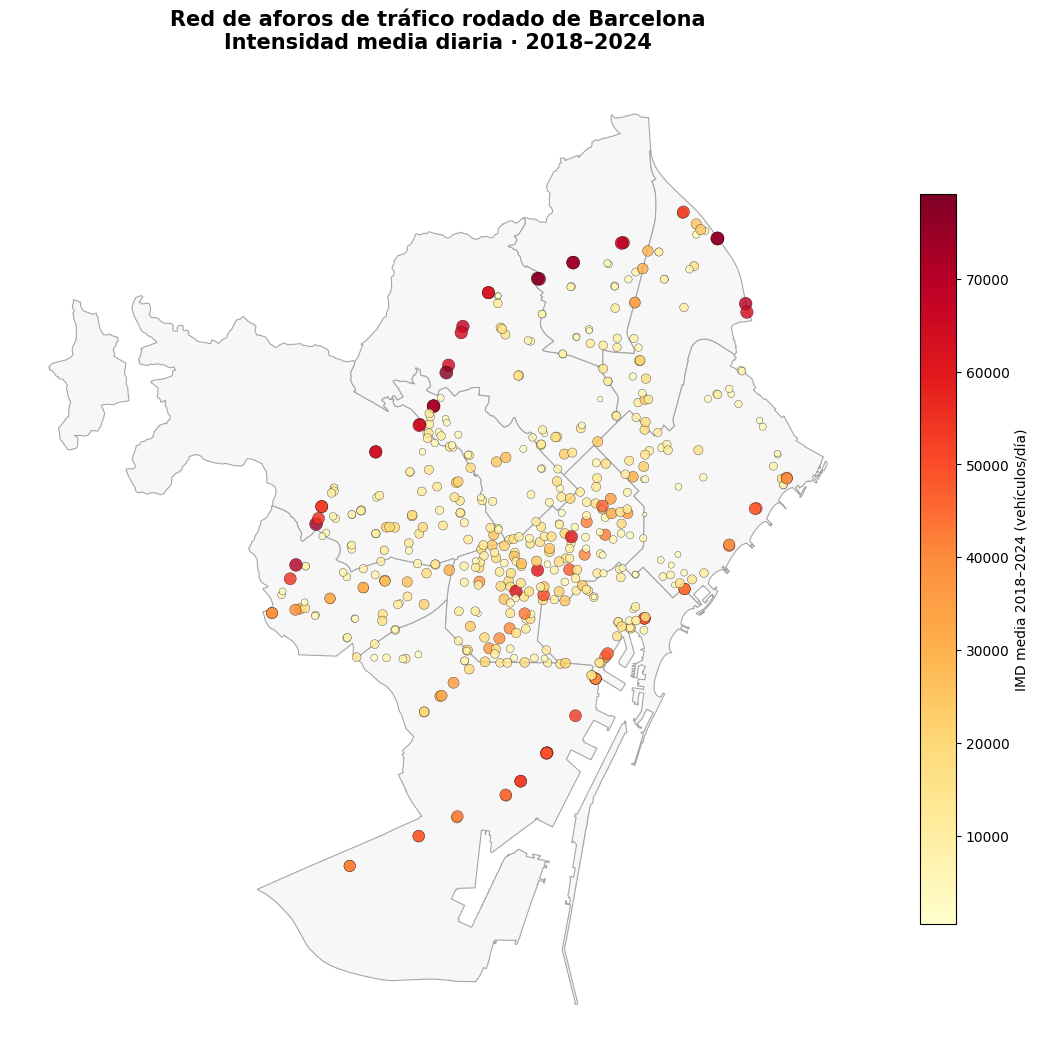


CONTROL DE LA REPRESENTACIÓN


,INDICADOR,VALOR
0,Registros año-aforo de partida,2746
1,Estaciones representadas,487
2,Distritos de referencia,10
3,Años disponibles,7
4,Registros con IMD nula,0
5,Geometrías de aforos nulas,0
6,Geometrías de aforos vacías,0
7,Geometrías de distritos nulas,0
8,Geometrías de distritos inválidas,0
9,CRS aforos,EPSG:25831



✓ Representación espacial generada correctamente.
✓ Se representan los 487 aforos motorizados aptos.
✓ Se incorporan los 10 distritos como referencia territorial.
✓ No existen geometrías nulas ni vacías en los aforos representados.
✓ CRS común confirmado: EPSG:25831.


In [ ]:
# ============================================================
# 4.6. REPRESENTACIÓN ESPACIAL DE LA RED DE AFOROS
# ============================================================

from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


print("=" * 100)
print("REPRESENTACIÓN ESPACIAL DE LA RED DE AFOROS")
print("=" * 100)


# ------------------------------------------------------------
# 1. COMPROBAR CAPA DE PARTIDA
# ------------------------------------------------------------

print(f"\nRegistros año-aforo : {len(gdf_aforos_anual_apto):,}")

print(
    f"Aforos únicos       : "
    f"{gdf_aforos_anual_apto['Id_aforament'].nunique():,}"
)

print(
    f"Años disponibles    : "
    f"{gdf_aforos_anual_apto['Any'].nunique()}"
)

print(
    f"CRS                  : "
    f"{gdf_aforos_anual_apto.crs}"
)


# ------------------------------------------------------------
# 2. GENERAR SÍNTESIS 2018-2024 POR ESTACIÓN
# ------------------------------------------------------------

df_aforos_mapa = (
    gdf_aforos_anual_apto
    .groupby(
        "Id_aforament",
        as_index=False
    )
    .agg(

        IMD_MEDIA_2018_2024=(
            "IMD_MEDIA",
            "mean"
        ),

        IMD_MEDIANA_2018_2024=(
            "IMD_MEDIANA",
            "median"
        ),

        ANIOS_DISPONIBLES=(
            "Any",
            "nunique"
        ),

        X_ETRS89=(
            "X_ETRS89",
            "median"
        ),

        Y_ETRS89=(
            "Y_ETRS89",
            "median"
        )
    )
)


# Redondear variables de síntesis

df_aforos_mapa[
    [
        "IMD_MEDIA_2018_2024",
        "IMD_MEDIANA_2018_2024",
        "X_ETRS89",
        "Y_ETRS89"
    ]
] = (
    df_aforos_mapa[
        [
            "IMD_MEDIA_2018_2024",
            "IMD_MEDIANA_2018_2024",
            "X_ETRS89",
            "Y_ETRS89"
        ]
    ]
    .round(2)
)


print(
    f"\nEstaciones obtenidas en la síntesis : "
    f"{len(df_aforos_mapa):,}"
)


# ------------------------------------------------------------
# 3. CREAR GEODATAFRAME DE REPRESENTACIÓN
# ------------------------------------------------------------

gdf_aforos_mapa = gpd.GeoDataFrame(

    df_aforos_mapa,

    geometry=gpd.points_from_xy(
        df_aforos_mapa["X_ETRS89"],
        df_aforos_mapa["Y_ETRS89"]
    ),

    crs="EPSG:25831"
)


# ------------------------------------------------------------
# 4. RECUPERAR DISTRITOS COMO CONTEXTO ESPACIAL
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("RECUPERACIÓN DE LA CAPA DE DISTRITOS")
print("=" * 100)


# Buscar el GeoPackage en todo el proyecto TFM

coincidencias_gpkg = list(
    Path(
        "/content/drive/MyDrive/TFM"
    ).rglob(
        "unidades_administrativas_barcelona.gpkg"
    )
)


print(
    f"\nGeoPackages encontrados: "
    f"{len(coincidencias_gpkg)}"
)


for i, ruta in enumerate(
    coincidencias_gpkg,
    start=1
):

    print(
        f"{i}. {ruta}"
    )


if len(coincidencias_gpkg) == 0:

    raise FileNotFoundError(
        "No se ha localizado "
        "'unidades_administrativas_barcelona.gpkg' "
        "dentro del proyecto TFM."
    )


# Seleccionar el archivo localizado

RUTA_ADMIN = coincidencias_gpkg[0]


print(
    "\nGeoPackage seleccionado:"
)

print(
    RUTA_ADMIN
)


# ------------------------------------------------------------
# 5. COMPROBAR CAPAS DISPONIBLES EN EL GEOPACKAGE
# ------------------------------------------------------------

capas_disponibles = gpd.list_layers(
    RUTA_ADMIN
)


print(
    "\nCapas disponibles:"
)

display(
    capas_disponibles
)


# ------------------------------------------------------------
# 6. LEER CAPA DE DISTRITOS
# ------------------------------------------------------------

gdf_distritos = gpd.read_file(
    RUTA_ADMIN,
    layer="distritos"
)


print(
    f"\nDistritos cargados : "
    f"{len(gdf_distritos)}"
)

print(
    f"CRS original       : "
    f"{gdf_distritos.crs}"
)


# ------------------------------------------------------------
# 7. HOMOGENEIZAR CRS
# ------------------------------------------------------------

if (
    gdf_distritos.crs
    != gdf_aforos_mapa.crs
):

    print(
        "\nReproyectando distritos al CRS de los aforos..."
    )

    gdf_distritos = (
        gdf_distritos
        .to_crs(
            gdf_aforos_mapa.crs
        )
    )


print(
    f"CRS final distritos: "
    f"{gdf_distritos.crs}"
)


# ------------------------------------------------------------
# 8. ESTADÍSTICAS DE LA IMD REPRESENTADA
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("DISTRIBUCIÓN DE LA IMD MEDIA POR ESTACIÓN")
print("=" * 100)


estadisticas_imd_mapa = (
    gdf_aforos_mapa[
        "IMD_MEDIA_2018_2024"
    ]
    .describe()
    .round(2)
    .to_frame(
        "IMD_MEDIA_2018_2024"
    )
)


display(
    estadisticas_imd_mapa
)


# ------------------------------------------------------------
# 9. ESCALAR EL TAMAÑO DE LOS PUNTOS
# ------------------------------------------------------------

imd = (
    gdf_aforos_mapa[
        "IMD_MEDIA_2018_2024"
    ]
)


imd_min = imd.min()
imd_max = imd.max()


if imd_max > imd_min:

    tamanos = (
        10
        + 80
        * (
            (imd - imd_min)
            / (imd_max - imd_min)
        ) ** 0.5
    )

else:

    tamanos = np.repeat(
        30,
        len(gdf_aforos_mapa)
    )


# ------------------------------------------------------------
# 10. REPRESENTACIÓN ESPACIAL
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("GENERACIÓN DEL MAPA")
print("=" * 100)


fig, ax = plt.subplots(
    figsize=(11, 11)
)


# ------------------------------------------------------------
# Fondo administrativo
# ------------------------------------------------------------

gdf_distritos.plot(

    ax=ax,

    facecolor="0.97",

    edgecolor="0.65",

    linewidth=0.8,

    zorder=1
)


# ------------------------------------------------------------
# Estaciones de aforo
# ------------------------------------------------------------

gdf_aforos_mapa.plot(

    ax=ax,

    column="IMD_MEDIA_2018_2024",

    cmap="YlOrRd",

    markersize=tamanos,

    alpha=0.82,

    legend=True,

    edgecolor="black",

    linewidth=0.25,

    zorder=2,

    legend_kwds={

        "label":
        "IMD media 2018–2024 (vehículos/día)",

        "shrink": 0.70
    }
)


# ------------------------------------------------------------
# Título
# ------------------------------------------------------------

ax.set_title(

    "Red de aforos de tráfico rodado de Barcelona\n"
    "Intensidad media diaria · 2018–2024",

    fontsize=15,

    fontweight="bold",

    pad=15
)


ax.set_axis_off()


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 11. CONTROL DE LA REPRESENTACIÓN
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("CONTROL DE LA REPRESENTACIÓN")
print("=" * 100)


control_mapa_aforos = pd.DataFrame({

    "INDICADOR": [

        "Registros año-aforo de partida",

        "Estaciones representadas",

        "Distritos de referencia",

        "Años disponibles",

        "Registros con IMD nula",

        "Geometrías de aforos nulas",

        "Geometrías de aforos vacías",

        "Geometrías de distritos nulas",

        "Geometrías de distritos inválidas",

        "CRS aforos",

        "CRS distritos"
    ],

    "VALOR": [

        len(
            gdf_aforos_anual_apto
        ),

        len(
            gdf_aforos_mapa
        ),

        len(
            gdf_distritos
        ),

        gdf_aforos_anual_apto[
            "Any"
        ].nunique(),

        int(
            gdf_aforos_mapa[
                "IMD_MEDIA_2018_2024"
            ]
            .isna()
            .sum()
        ),

        int(
            gdf_aforos_mapa
            .geometry
            .isna()
            .sum()
        ),

        int(
            gdf_aforos_mapa
            .geometry
            .is_empty
            .sum()
        ),

        int(
            gdf_distritos
            .geometry
            .isna()
            .sum()
        ),

        int(
            (~gdf_distritos.geometry.is_valid)
            .sum()
        ),

        str(
            gdf_aforos_mapa.crs
        ),

        str(
            gdf_distritos.crs
        )
    ]
})


display(
    control_mapa_aforos
)


# ------------------------------------------------------------
# 12. VALIDACIONES FINALES
# ------------------------------------------------------------

assert (
    len(gdf_aforos_mapa)
    == 487
)


assert (
    len(gdf_distritos)
    == 10
)


assert (
    gdf_aforos_mapa[
        "IMD_MEDIA_2018_2024"
    ]
    .isna()
    .sum()
    == 0
)


assert (
    gdf_aforos_mapa
    .geometry
    .isna()
    .sum()
    == 0
)


assert (
    gdf_aforos_mapa
    .geometry
    .is_empty
    .sum()
    == 0
)


assert (
    gdf_aforos_mapa
    .crs
    .to_epsg()
    == 25831
)


assert (
    gdf_distritos
    .crs
    .to_epsg()
    == 25831
)


print("\n✓ Representación espacial generada correctamente.")

print(
    "✓ Se representan los "
    f"{len(gdf_aforos_mapa):,} "
    "aforos motorizados aptos."
)

print(
    "✓ Se incorporan los "
    f"{len(gdf_distritos)} distritos "
    "como referencia territorial."
)

print(
    "✓ No existen geometrías nulas "
    "ni vacías en los aforos representados."
)

print(
    "✓ CRS común confirmado: EPSG:25831."
)

### Resultados de la representación espacial de la red de aforos

La representación espacial confirma una amplia cobertura territorial de la red de aforos motorizados utilizada en el estudio. Se representan las **487 estaciones aptas**, sintetizando para cada localización la intensidad media diaria observada durante el periodo 2018–2024.

La incorporación de los límites administrativos de los distritos permite contextualizar territorialmente la red y comprobar la distribución de las estaciones dentro del municipio. Se observa una mayor concentración de puntos de medida en el tejido urbano consolidado y en los principales ámbitos de movilidad, junto con una cobertura más dispersa en las zonas periféricas.

La intensidad del tráfico presenta una marcada heterogeneidad espacial. La representación conjunta mediante color y tamaño permite identificar estaciones con intensidades medias considerablemente superiores al conjunto de la red, especialmente asociadas a determinados corredores y accesos urbanos.

La figura constituye asimismo un control visual de la georreferenciación realizada, sin apreciarse localizaciones manifiestamente incoherentes con la estructura territorial del municipio.

Los aforos se mantienen como geometrías puntuales en esta fase, respetando la localización espacial disponible en los datos preparados. La posible asociación de las estaciones a tramos concretos de la red viaria se reserva para una fase posterior de ingeniería de variables, en caso de resultar necesaria para la construcción de indicadores de exposición al tráfico.

La síntesis cartográfica 2018–2024 se utiliza exclusivamente con fines exploratorios y de control. La estructura anual completa de los datos se conserva para la posterior integración temporal y geoespacial.

## 4.7. Exportación y validación de las capas de aforos procesadas

Una vez completada la integración temporal y espacial de los aforos, así como la agregación anual y el control de su cobertura temporal, se generan los productos definitivos del bloque de tráfico rodado para su utilización en las posteriores fases de integración y modelización.

Se conservan dos versiones de la información anual:

- **Capa anual maestra:** mantiene todas las combinaciones año–punto de aforo obtenidas durante la agregación, incluyendo los indicadores de cobertura y la variable de control `APTO_ANALISIS_ANUAL`. Esta capa permite conservar la trazabilidad completa de los datos procesados.
- **Capa anual validada:** contiene exclusivamente las combinaciones año–punto de aforo que alcanzan una cobertura temporal mínima del **75 %** y disponen de una estimación válida de IMD. Esta versión constituye la capa de referencia para los análisis anuales posteriores.

Los resultados se exportan tanto en formato **CSV**, adecuado para el tratamiento tabular y la integración con otras variables del modelo, como en formato **GeoPackage (GPKG)**, que conserva explícitamente la geometría y el sistema de referencia espacial.

Todos los productos geoespaciales se mantienen en **ETRS89 / UTM zona 31N (EPSG:25831)**, sistema de referencia utilizado como estándar durante la fase de preintegración geoespacial.

Finalmente, los archivos exportados se vuelven a cargar y se comprueba el número de registros, el número de aforos, la cobertura temporal y el sistema de referencia, garantizando que el proceso de escritura no haya introducido pérdidas o alteraciones en los datos.

In [ ]:
# ============================================================
# 4.7. EXPORTACIÓN Y VALIDACIÓN DE LAS CAPAS DE AFOROS
# ============================================================

from pathlib import Path
import pandas as pd
import geopandas as gpd

print("=" * 100)
print("EXPORTACIÓN Y VALIDACIÓN DE LAS CAPAS DE AFOROS")
print("=" * 100)

# ------------------------------------------------------------
# 1. DIRECTORIO DE SALIDA
# ------------------------------------------------------------

SALIDA = Path(
    "/content/drive/MyDrive/TFM/"
    "10_Machine_Learning_Geoespacial/"
    "PREINTEGRACION/"
    "02_Trafico_Rodado_y_Aforos"
)


SALIDA.mkdir(
    parents=True,
    exist_ok=True
)

print("\nDirectorio de salida:")
print(SALIDA)


# ------------------------------------------------------------
# 2. DEFINICIÓN DE ARCHIVOS
# ------------------------------------------------------------

ruta_csv_maestro = (
    SALIDA /
    "df_aforos_anual_maestro.csv"
)

ruta_csv_apto = (
    SALIDA /
    "df_aforos_anual_apto.csv"
)

ruta_gpkg = (
    SALIDA /
    "aforos_anuales_barcelona.gpkg"
)

ruta_control = (
    SALIDA /
    "control_aforos_anuales.csv"
)


# ------------------------------------------------------------
# 3. PREPARAR VERSIONES TABULARES
# ------------------------------------------------------------

df_aforos_anual_maestro_csv = pd.DataFrame(
    gdf_aforos_anual.drop(
        columns="geometry"
    )
)

df_aforos_anual_apto_csv = pd.DataFrame(
    gdf_aforos_anual_apto.drop(
        columns="geometry"
    )
)


# ------------------------------------------------------------
# 4. EXPORTACIÓN CSV
# ------------------------------------------------------------

df_aforos_anual_maestro_csv.to_csv(
    ruta_csv_maestro,
    index=False
)

df_aforos_anual_apto_csv.to_csv(
    ruta_csv_apto,
    index=False
)

print("\n✓ CSV maestro exportado")
print("✓ CSV validado exportado")


# ------------------------------------------------------------
# 5. EXPORTACIÓN GEOPACKAGE
# ------------------------------------------------------------

# Eliminar una versión anterior para garantizar
# una escritura limpia del GeoPackage

if ruta_gpkg.exists():
    ruta_gpkg.unlink()


# Capa maestra

gdf_aforos_anual.to_file(
    ruta_gpkg,
    layer="aforos_anual_maestro",
    driver="GPKG"
)


# Capa validada

gdf_aforos_anual_apto.to_file(
    ruta_gpkg,
    layer="aforos_anual_apto",
    driver="GPKG"
)

print("✓ GeoPackage exportado")


# ------------------------------------------------------------
# 6. RELECTURA DE LOS PRODUCTOS EXPORTADOS
# ------------------------------------------------------------

gdf_check_maestro = gpd.read_file(
    ruta_gpkg,
    layer="aforos_anual_maestro"
)

gdf_check_apto = gpd.read_file(
    ruta_gpkg,
    layer="aforos_anual_apto"
)

df_check_maestro = pd.read_csv(
    ruta_csv_maestro,
    low_memory=False
)

df_check_apto = pd.read_csv(
    ruta_csv_apto,
    low_memory=False
)


# ------------------------------------------------------------
# 7. CONTROL DE EXPORTACIÓN
# ------------------------------------------------------------

control_exportacion = pd.DataFrame({

    "CAPA": [
        "aforos_anual_maestro",
        "aforos_anual_apto"
    ],

    "REGISTROS_ORIGEN": [
        len(gdf_aforos_anual),
        len(gdf_aforos_anual_apto)
    ],

    "REGISTROS_GPKG": [
        len(gdf_check_maestro),
        len(gdf_check_apto)
    ],

    "REGISTROS_CSV": [
        len(df_check_maestro),
        len(df_check_apto)
    ],

    "AFOROS_UNICOS": [
        gdf_check_maestro[
            "Id_aforament"
        ].nunique(),

        gdf_check_apto[
            "Id_aforament"
        ].nunique()
    ],

    "ANIOS": [
        gdf_check_maestro[
            "Any"
        ].nunique(),

        gdf_check_apto[
            "Any"
        ].nunique()
    ],

    "CRS": [
        str(gdf_check_maestro.crs),
        str(gdf_check_apto.crs)
    ],

    "GEOMETRIAS_NULAS": [
        int(
            gdf_check_maestro
            .geometry
            .isna()
            .sum()
        ),

        int(
            gdf_check_apto
            .geometry
            .isna()
            .sum()
        )
    ]
})


# ------------------------------------------------------------
# 8. COMPROBAR INTEGRIDAD
# ------------------------------------------------------------

control_exportacion["CSV_CORRECTO"] = (
    control_exportacion["REGISTROS_ORIGEN"]
    ==
    control_exportacion["REGISTROS_CSV"]
)

control_exportacion["GPKG_CORRECTO"] = (
    control_exportacion["REGISTROS_ORIGEN"]
    ==
    control_exportacion["REGISTROS_GPKG"]
)

control_exportacion["CRS_CORRECTO"] = (
    control_exportacion["CRS"]
    ==
    "EPSG:25831"
)

control_exportacion["GEOMETRIA_CORRECTA"] = (
    control_exportacion["GEOMETRIAS_NULAS"]
    ==
    0
)

control_exportacion["VALIDACION_FINAL"] = (
    control_exportacion[
        [
            "CSV_CORRECTO",
            "GPKG_CORRECTO",
            "CRS_CORRECTO",
            "GEOMETRIA_CORRECTA"
        ]
    ]
    .all(axis=1)
)


print("\nVerificación de los productos exportados:")

display(control_exportacion)


# ------------------------------------------------------------
# 9. GUARDAR INFORME DE CONTROL
# ------------------------------------------------------------

control_exportacion.to_csv(
    ruta_control,
    index=False
)

print("\n✓ Informe de control exportado")


# ------------------------------------------------------------
# 10. VALIDACIONES AUTOMÁTICAS
# ------------------------------------------------------------

assert control_exportacion[
    "VALIDACION_FINAL"
].all(), (
    "Error en la validación de los archivos exportados."
)

assert (
    len(gdf_check_maestro)
    ==
    len(gdf_aforos_anual)
)

assert (
    len(gdf_check_apto)
    ==
    len(gdf_aforos_anual_apto)
)

assert (
    gdf_check_maestro[
        "Any"
    ].nunique()
    == 7
)

assert (
    gdf_check_apto[
        "Any"
    ].nunique()
    == 7
)


# ------------------------------------------------------------
# 11. RESUMEN FINAL DEL BLOQUE
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("RESUMEN FINAL DEL BLOQUE DE AFOROS")
print("=" * 100)

print(
    "\nCapa maestra:"
)

print(
    f"  Registros año-aforo : "
    f"{len(gdf_check_maestro):,}"
)

print(
    f"  Aforos únicos       : "
    f"{gdf_check_maestro['Id_aforament'].nunique():,}"
)

print(
    f"  Años                : "
    f"{gdf_check_maestro['Any'].nunique()}"
)


print(
    "\nCapa validada:"
)

print(
    f"  Registros año-aforo : "
    f"{len(gdf_check_apto):,}"
)

print(
    f"  Aforos únicos       : "
    f"{gdf_check_apto['Id_aforament'].nunique():,}"
)

print(
    f"  Años                : "
    f"{gdf_check_apto['Any'].nunique()}"
)


print("\nArchivos generados:")

print(
    "✓ df_aforos_anual_maestro.csv"
)

print(
    "✓ df_aforos_anual_apto.csv"
)

print(
    "✓ aforos_anuales_barcelona.gpkg"
)

print(
    "✓ control_aforos_anuales.csv"
)

print(
    "\n✓ Exportación completada y "
    "validada correctamente."
)

EXPORTACIÓN Y VALIDACIÓN DE LAS CAPAS DE AFOROS

Directorio de salida:
/content/drive/MyDrive/TFM/10_Machine_Learning_Geoespacial/PREINTEGRACION/02_Trafico_Rodado_y_Aforos

✓ CSV maestro exportado
✓ CSV validado exportado
✓ GeoPackage exportado

Verificación de los productos exportados:


,CAPA,REGISTROS_ORIGEN,REGISTROS_GPKG,REGISTROS_CSV,AFOROS_UNICOS,ANIOS,CRS,GEOMETRIAS_NULAS,CSV_CORRECTO,GPKG_CORRECTO,CRS_CORRECTO,GEOMETRIA_CORRECTA,VALIDACION_FINAL
0,aforos_anual_maestro,3220,3220,3220,507,7,EPSG:25831,0,True,True,True,True,True
1,aforos_anual_apto,2746,2746,2746,487,7,EPSG:25831,0,True,True,True,True,True



✓ Informe de control exportado

RESUMEN FINAL DEL BLOQUE DE AFOROS

Capa maestra:
  Registros año-aforo : 3,220
  Aforos únicos       : 507
  Años                : 7

Capa validada:
  Registros año-aforo : 2,746
  Aforos únicos       : 487
  Años                : 7

Archivos generados:
✓ df_aforos_anual_maestro.csv
✓ df_aforos_anual_apto.csv
✓ aforos_anuales_barcelona.gpkg
✓ control_aforos_anuales.csv

✓ Exportación completada y validada correctamente.


### Resultado de la exportación

La exportación de los productos derivados del tratamiento de los aforos se completa correctamente, sin detectarse pérdidas de registros ni alteraciones en la componente espacial.

La **capa anual maestra** conserva **3.220 combinaciones año–aforo**, correspondientes a **507 puntos de medida** y a los **7 años** del periodo de estudio. Esta versión mantiene la totalidad de las estimaciones anuales junto con sus indicadores de cobertura y calidad.

La **capa anual validada** contiene **2.746 combinaciones año–aforo**, correspondientes a **487 puntos de medida**, manteniendo igualmente representación durante los **7 años** analizados. Esta capa constituye el producto de referencia para aquellos análisis que requieran estimaciones anuales con una cobertura temporal mínima del 75 %.

La relectura independiente de los archivos CSV y GeoPackage confirma la correspondencia exacta entre el número de registros originales y exportados. Asimismo, las dos capas geoespaciales mantienen el sistema de referencia **ETRS89 / UTM zona 31N (EPSG:25831)** y no presentan geometrías nulas.

Como productos finales del bloque se generan:

- `df_aforos_anual_maestro.csv`
- `df_aforos_anual_apto.csv`
- `aforos_anuales_barcelona.gpkg`
- `control_aforos_anuales.csv`

Los datos de tráfico rodado quedan así preparados, documentados y validados para su posterior incorporación al proceso de integración temporal y geoespacial del modelo.

# 5 . USOS DEL SUELO

La caracterización del entorno urbano se complementa mediante la incorporación de la **cartografía de usos del suelo de la ciudad de Barcelona**, procedente del portal Open Data BCN del Ayuntamiento de Barcelona.

Esta información permite representar la **estructura funcional del territorio** y diferenciar espacialmente áreas con distintos tipos de ocupación y actividad urbana. Su incorporación resulta relevante para el análisis de la calidad del aire, ya que los usos del entorno pueden estar relacionados con diferencias en la intensidad del tráfico, la presencia de actividades potencialmente emisoras, la configuración urbana y las condiciones de exposición de la población.

## Fuente de información

- **Fuente:** Open Data BCN — Ayuntamiento de Barcelona.
- **Dataset:** Usos del suelo de la ciudad de Barcelona.
- **Recurso cartográfico:** `2016_Usos_sol.shp`.
- **Año de referencia:** 2016.
- **Formato:** Shapefile.
- **Sistema de referencia de descarga:** ETRS89.
- **Enlace de la fuente:**  
  https://opendata-ajuntament.barcelona.cat/data/es/dataset/mapa-usos-sol-wms/resource/af0670fc-0969-4677-be5d-e39191bb9ae0
- **Ruta de los datos originales:**  
  `/content/drive/MyDrive/TFM/09_Indicadores_Socioeconomicos/BCN_UsosSòl_ETRS89_SHP/`
- **Tratamiento temporal:** **covariable espacial estática durante todo el periodo 2018–2024**.

## Consideración temporal de la variable

La cartografía disponible corresponde al **año 2016** y no se dispone de una serie cartográfica homogénea y comparable para cada uno de los años incluidos en el periodo de estudio (2018–2024). Por este motivo, los usos del suelo se incorporarán al modelo como una **variable espacial estática**.

Esto implica que la información asignada a cada localización **se mantendrá constante para todos los años del periodo analizado**. La variable permitirá, por tanto, caracterizar las diferencias espaciales existentes entre distintas zonas de Barcelona, pero **no se utilizará para representar cambios temporales en los usos del suelo**.

Esta decisión evita introducir una evolución temporal artificial no respaldada por los datos disponibles y permite conservar la información sobre la estructura funcional del territorio como una característica del contexto urbano.

El tratamiento de esta fuente comprenderá la **auditoría de la cartografía y de sus atributos**, el análisis y, cuando resulte necesario, la **reclasificación de las categorías de uso**, el control de la calidad geométrica y la preparación de una capa geoespacial normalizada.

Posteriormente, durante la fase de integración geoespacial, esta información permitirá generar variables destinadas a caracterizar el entorno de las unidades de análisis, considerando la presencia, predominio o composición espacial de los diferentes usos del suelo.

La cartografía original se conservará sin modificaciones y los productos procesados necesarios para las posteriores fases de integración y modelización se almacenarán en el directorio correspondiente de **PREINTEGRACION**, manteniendo la trazabilidad entre los datos originales y las variables finalmente incorporadas al modelo.

## 5.1. Localización, lectura e inspección inicial de la cartografía

La cartografía de usos del suelo se encuentra almacenada junto con el resto de variables espaciales estáticas del proyecto. Antes de realizar cualquier transformación se efectúa una lectura y auditoría inicial del recurso con el objetivo de comprobar su estructura, sistema de referencia, geometrías y atributos disponibles.

Esta primera inspección permitirá identificar las variables que contienen la clasificación de los usos del suelo y determinar posteriormente qué categorías y características derivadas resultan adecuadas para representar el entorno urbano dentro del modelo.

En esta fase no se modifica la información original. El objetivo es verificar la integridad del recurso y conocer su estructura antes de iniciar las operaciones de limpieza, reclasificación y preparación geoespacial.

In [ ]:
# ============================================================
# 5.1. LOCALIZACIÓN, LECTURA E INSPECCIÓN INICIAL
#      DE LA CARTOGRAFÍA DE USOS DEL SUELO
# ============================================================

from pathlib import Path
import geopandas as gpd
import pandas as pd

print("=" * 100)
print("LOCALIZACIÓN Y LECTURA DE LA CARTOGRAFÍA DE USOS DEL SUELO")
print("=" * 100)


# ------------------------------------------------------------
# 1. RUTA BASE
# ------------------------------------------------------------

RUTA_BASE = Path(
    "/content/drive/MyDrive/TFM/"
    "09_Indicadores_Socioeconomicos"
)

RUTA_USOS = (
    RUTA_BASE /
    "BCN_UsosSòl_ETRS89_SHP"
)

print("\nDirectorio de usos del suelo:")
print(RUTA_USOS)

if not RUTA_USOS.exists():
    raise FileNotFoundError(
        f"No se encuentra el directorio:\n{RUTA_USOS}"
    )


# ------------------------------------------------------------
# 2. INVENTARIO DE ARCHIVOS
# ------------------------------------------------------------

archivos = sorted(
    [
        archivo
        for archivo in RUTA_USOS.iterdir()
        if archivo.is_file()
    ]
)

inventario_usos = pd.DataFrame({
    "ARCHIVO": [
        archivo.name
        for archivo in archivos
    ],
    "EXTENSION": [
        archivo.suffix.lower()
        for archivo in archivos
    ],
    "TAMANO_MB": [
        round(
            archivo.stat().st_size / (1024 ** 2),
            3
        )
        for archivo in archivos
    ]
})

print("\nArchivos disponibles:")

display(inventario_usos)


# ------------------------------------------------------------
# 3. LOCALIZAR SHAPEFILE
# ------------------------------------------------------------

shapefiles = sorted(
    RUTA_USOS.glob("*.shp")
)

print(
    "\nShapefiles encontrados:",
    len(shapefiles)
)

for shp in shapefiles:
    print("✓", shp.name)

if len(shapefiles) == 0:
    raise FileNotFoundError(
        "No se ha encontrado ningún archivo .shp."
    )

if len(shapefiles) > 1:
    print(
        "\nADVERTENCIA: existe más de un shapefile. "
        "Se seleccionará el correspondiente a usos del suelo."
    )


# Selección del recurso
RUTA_SHP_USOS = (
    RUTA_USOS /
    "BCN_UsosSòl_ETRS89_SHP.shp"
)

if not RUTA_SHP_USOS.exists():

    # Alternativa robusta por si Google Drive
    # modifica ligeramente el nombre
    candidatos = [
        shp
        for shp in shapefiles
        if "Usos" in shp.name
    ]

    if len(candidatos) != 1:
        raise FileNotFoundError(
            "No ha sido posible identificar de forma "
            "inequívoca el shapefile de usos del suelo."
        )

    RUTA_SHP_USOS = candidatos[0]


print("\nShapefile seleccionado:")
print(RUTA_SHP_USOS)


# ------------------------------------------------------------
# 4. LECTURA
# ------------------------------------------------------------

gdf_usos = gpd.read_file(
    RUTA_SHP_USOS
)

print("\n✓ Cartografía cargada correctamente.")


# ------------------------------------------------------------
# 5. INFORMACIÓN GENERAL
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("ESTRUCTURA GENERAL")
print("=" * 100)

print(
    f"\nRegistros        : {len(gdf_usos):,}"
)

print(
    f"Columnas         : {len(gdf_usos.columns)}"
)

print(
    f"CRS              : {gdf_usos.crs}"
)

print(
    f"Geometría        : "
    f"{gdf_usos.geometry.name}"
)

print(
    f"Tipos geométricos: "
    f"{gdf_usos.geom_type.unique().tolist()}"
)


# ------------------------------------------------------------
# 6. COLUMNAS DISPONIBLES
# ------------------------------------------------------------

estructura_usos = pd.DataFrame({

    "VARIABLE":
        gdf_usos.columns,

    "TIPO":
        [
            str(gdf_usos[col].dtype)
            for col in gdf_usos.columns
        ],

    "NULOS":
        [
            int(gdf_usos[col].isna().sum())
            for col in gdf_usos.columns
        ],

    "VALORES_UNICOS":
        [
            (
                gdf_usos[col].nunique(
                    dropna=True
                )
                if col != "geometry"
                else pd.NA
            )
            for col in gdf_usos.columns
        ]
})

print("\nEstructura de variables:")

display(estructura_usos)


# ------------------------------------------------------------
# 7. CONTROL GEOMÉTRICO
# ------------------------------------------------------------

geometrias_nulas = int(
    gdf_usos.geometry.isna().sum()
)

geometrias_vacias = int(
    gdf_usos.geometry.is_empty.sum()
)

geometrias_invalidas = int(
    (~gdf_usos.geometry.is_valid).sum()
)

resumen_usos = pd.DataFrame({

    "INDICADOR": [
        "Registros",
        "Columnas",
        "Geometrías nulas",
        "Geometrías vacías",
        "Geometrías inválidas",
        "CRS"
    ],

    "VALOR": [
        len(gdf_usos),
        len(gdf_usos.columns),
        geometrias_nulas,
        geometrias_vacias,
        geometrias_invalidas,
        str(gdf_usos.crs)
    ]
})

print("\n" + "=" * 100)
print("CONTROL INICIAL")
print("=" * 100)

display(resumen_usos)


# ------------------------------------------------------------
# 8. EXTENSIÓN ESPACIAL
# ------------------------------------------------------------

print("\nExtensión espacial [xmin, ymin, xmax, ymax]:")

print(
    gdf_usos.total_bounds
)


# ------------------------------------------------------------
# 9. PRIMEROS REGISTROS
# ------------------------------------------------------------

print("\nPrimeros registros:")

display(
    gdf_usos.head()
)


# ------------------------------------------------------------
# 10. INSPECCIÓN DE LOS ATRIBUTOS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("VALORES DE LOS ATRIBUTOS")
print("=" * 100)

for columna in gdf_usos.columns:

    if columna == "geometry":
        continue

    print("\n" + "-" * 100)
    print(columna)
    print("-" * 100)

    print(
        f"Valores únicos: "
        f"{gdf_usos[columna].nunique(dropna=True):,}"
    )

    display(
        gdf_usos[columna]
        .value_counts(
            dropna=False
        )
        .head(20)
        .rename_axis(columna)
        .reset_index(
            name="REGISTROS"
        )
    )


print(
    "\n✓ Inspección inicial de los usos "
    "del suelo completada."
)

LOCALIZACIÓN Y LECTURA DE LA CARTOGRAFÍA DE USOS DEL SUELO

Directorio de usos del suelo:
/content/drive/MyDrive/TFM/09_Indicadores_Socioeconomicos/BCN_UsosSòl_ETRS89_SHP

Archivos disponibles:


,ARCHIVO,EXTENSION,TAMANO_MB
0,BCN_UsosSòl_ETRS89_SHP.dbf,.dbf,5.149
1,BCN_UsosSòl_ETRS89_SHP.prj,.prj,0.000
2,BCN_UsosSòl_ETRS89_SHP.sbn,.sbn,0.129
3,BCN_UsosSòl_ETRS89_SHP.sbx,.sbx,0.006
4,BCN_UsosSòl_ETRS89_SHP.shp,.shp,9.303
5,BCN_UsosSòl_ETRS89_SHP.shx,.shx,0.109



Shapefiles encontrados: 1
✓ BCN_UsosSòl_ETRS89_SHP.shp

Shapefile seleccionado:
/content/drive/MyDrive/TFM/09_Indicadores_Socioeconomicos/BCN_UsosSòl_ETRS89_SHP/BCN_UsosSòl_ETRS89_SHP.shp

✓ Cartografía cargada correctamente.

ESTRUCTURA GENERAL

Registros        : 14,320
Columnas         : 14
CRS              : EPSG:25831
Geometría        : geometry
Tipos geométricos: ['Polygon', 'MultiPolygon']

Estructura de variables:


,VARIABLE,TIPO,NULOS,VALORES_UNICOS
0,FAMILIA,object,0,21
1,CLAU,object,0,1003
2,District,object,0,10
3,NDistric,object,0,10
4,CBarri,object,0,73
5,NBarri,object,0,73
6,C_AEB,object,0,233
7,CSecCens,object,0,181
8,Area,float64,0,13898
9,Perimetre,float64,0,13898



CONTROL INICIAL


...


----------------------------------------------------------------------------------------------------
Coord_Y
----------------------------------------------------------------------------------------------------
Valores únicos: 13,898


,Coord_Y,REGISTROS
0,4.587626e+06,3
1,4.583951e+06,2
2,4.588076e+06,2
3,4.576723e+06,2
4,4.586257e+06,2
5,4.586961e+06,2
6,4.576279e+06,2
7,4.575843e+06,2
8,4.587379e+06,2
9,4.587336e+06,2



----------------------------------------------------------------------------------------------------
Descripcio
----------------------------------------------------------------------------------------------------
Valores únicos: 1,047


,Descripcio,REGISTROS
0,6b - Parcs i Jardins Urbans,1084
1,7a - Equipaments Comunitaris i Dotacions,1071
2,13b - DensificaciÃ³ Urbana,966
3,18 - OrdenaciÃ³ VolumÃ¨trica EspecÃ­fica,856
4,13E - DensificaciÃ³ Urbana,739
5,13a - DensificaciÃ³ Urbana,718
6,6a - Parcs i Jardins Urbans,709
7,12 - Casc Antic,667
8,7b - Equipaments Comunitaris i Dotacions,484
9,12b - Casc Antic,273



✓ Inspección inicial de los usos del suelo completada.


### Consideración temporal de los usos del suelo

La cartografía de usos del suelo se incorpora al análisis como una **covariable espacial estática**.

El recurso utilizado corresponde a una cartografía de referencia de **2016** y no constituye una serie temporal con información diferenciada para cada año del periodo de estudio (2018–2024). En consecuencia, no se analizará la evolución temporal de los usos del suelo ni se introducirán variaciones interanuales artificiales.

Su función dentro del modelo será exclusivamente caracterizar el **contexto espacial y funcional del entorno urbano**, manteniendo constante la información de usos del suelo durante todo el periodo 2018–2024.

Por tanto:

- **Año de referencia cartográfica:** 2016.
- **Periodo del modelo:** 2018–2024.
- **Tratamiento:** variable espacial estática.
- **Variación temporal:** no se considera.
- **Interpretación:** las variables derivadas representan diferencias espaciales en la estructura urbana, no cambios temporales en los usos del suelo.

La cartografía contiene **14.320 polígonos** clasificados inicialmente en **21 familias de usos**, además de una clasificación más detallada mediante los campos `CLAU` y `Descripcio`. Para su incorporación al modelo se analizará la conveniencia de reducir esta clasificación a un conjunto de categorías funcionales más manejable y relevante para el estudio de la calidad del aire.

## 5.2. Análisis de las categorías de usos del suelo

Una vez comprobada la estructura e integridad general de la cartografía, se analiza la clasificación temática contenida en el campo `FAMILIA`, que constituye el nivel de agregación más adecuado para caracterizar inicialmente los principales usos del suelo.

La cartografía presenta **21 familias de uso**, mientras que los campos `CLAU` y `Descripcio` contienen una clasificación considerablemente más detallada. Para evitar una dimensionalidad excesiva y facilitar la interpretación posterior de las variables incorporadas al modelo, se utilizará `FAMILIA` como punto de partida para construir una clasificación funcional simplificada.

La importancia de cada categoría no se evaluará únicamente mediante el número de polígonos, ya que las geometrías presentan superficies muy diferentes. Se calculará también la **superficie ocupada por cada familia y su porcentaje respecto a la superficie total cartografiada**.

Este análisis permitirá determinar qué categorías pueden mantenerse individualmente y cuáles pueden agruparse posteriormente en clases funcionales más amplias y relevantes para el estudio de la calidad del aire.

Los usos del suelo se mantendrán durante todo el análisis como una **covariable espacial estática**, utilizando la misma caracterización territorial para todos los años del periodo 2018–2024.

In [ ]:
# ============================================================
# 5.2. ANÁLISIS DE LAS CATEGORÍAS DE USOS DEL SUELO
# ============================================================

import pandas as pd
import numpy as np

print("=" * 100)
print("ANÁLISIS DE LAS CATEGORÍAS DE USOS DEL SUELO")
print("=" * 100)


# ------------------------------------------------------------
# 1. COPIA DE TRABAJO
# ------------------------------------------------------------

gdf_usos_trabajo = gdf_usos.copy()


# ------------------------------------------------------------
# 2. COMPROBAR VARIABLE DE CLASIFICACIÓN
# ------------------------------------------------------------

if "FAMILIA" not in gdf_usos_trabajo.columns:
    raise KeyError(
        "No se encuentra la variable 'FAMILIA' "
        "en la cartografía de usos del suelo."
    )

gdf_usos_trabajo["FAMILIA"] = (
    gdf_usos_trabajo["FAMILIA"]
    .astype("string")
    .str.strip()
)


# ------------------------------------------------------------
# 3. REPARACIÓN CONTROLADA DE GEOMETRÍAS
# ------------------------------------------------------------

invalidas_antes = int(
    (~gdf_usos_trabajo.geometry.is_valid).sum()
)

print(
    f"\nGeometrías inválidas antes de la reparación: "
    f"{invalidas_antes:,}"
)

if invalidas_antes > 0:

    try:
        gdf_usos_trabajo["geometry"] = (
            gdf_usos_trabajo.geometry.make_valid()
        )

        metodo_reparacion = "make_valid()"

    except Exception:

        gdf_usos_trabajo["geometry"] = (
            gdf_usos_trabajo.geometry.buffer(0)
        )

        metodo_reparacion = "buffer(0)"

else:
    metodo_reparacion = "No necesaria"


invalidas_despues = int(
    (~gdf_usos_trabajo.geometry.is_valid).sum()
)

print(
    f"Geometrías inválidas después de la reparación: "
    f"{invalidas_despues:,}"
)

print(
    f"Método utilizado: {metodo_reparacion}"
)


# ------------------------------------------------------------
# 4. CALCULAR SUPERFICIE GEOMÉTRICA
# ------------------------------------------------------------

# EPSG:25831 trabaja en metros, por lo que el área
# geométrica se obtiene en m².

gdf_usos_trabajo["AREA_CALCULADA_M2"] = (
    gdf_usos_trabajo.geometry.area
)

gdf_usos_trabajo["AREA_CALCULADA_HA"] = (
    gdf_usos_trabajo["AREA_CALCULADA_M2"]
    / 10_000
)


# ------------------------------------------------------------
# 5. CONTROL DE SUPERFICIES
# ------------------------------------------------------------

control_superficie = pd.DataFrame({

    "INDICADOR": [
        "Polígonos totales",
        "Familias de uso",
        "Área nula",
        "Área igual o inferior a 0",
        "Geometrías inválidas",
        "Superficie cartografiada (ha)"
    ],

    "VALOR": [
        len(gdf_usos_trabajo),

        gdf_usos_trabajo[
            "FAMILIA"
        ].nunique(dropna=True),

        int(
            gdf_usos_trabajo[
                "AREA_CALCULADA_M2"
            ].isna().sum()
        ),

        int(
            (
                gdf_usos_trabajo[
                    "AREA_CALCULADA_M2"
                ] <= 0
            ).sum()
        ),

        invalidas_despues,

        round(
            gdf_usos_trabajo[
                "AREA_CALCULADA_HA"
            ].sum(),
            2
        )
    ]
})

print("\nControl de superficies:")

display(control_superficie)


# ------------------------------------------------------------
# 6. DISTRIBUCIÓN POR FAMILIA
# ------------------------------------------------------------

resumen_familias = (
    gdf_usos_trabajo
    .groupby(
        "FAMILIA",
        dropna=False
    )
    .agg(
        POLIGONOS=(
            "FAMILIA",
            "size"
        ),
        SUPERFICIE_M2=(
            "AREA_CALCULADA_M2",
            "sum"
        ),
        SUPERFICIE_HA=(
            "AREA_CALCULADA_HA",
            "sum"
        ),
        SUPERFICIE_MEDIA_M2=(
            "AREA_CALCULADA_M2",
            "mean"
        ),
        SUPERFICIE_MEDIANA_M2=(
            "AREA_CALCULADA_M2",
            "median"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 7. PORCENTAJES
# ------------------------------------------------------------

superficie_total = (
    resumen_familias[
        "SUPERFICIE_M2"
    ].sum()
)

poligonos_totales = (
    resumen_familias[
        "POLIGONOS"
    ].sum()
)

resumen_familias["PCT_POLIGONOS"] = (
    resumen_familias["POLIGONOS"]
    / poligonos_totales
    * 100
)

resumen_familias["PCT_SUPERFICIE"] = (
    resumen_familias["SUPERFICIE_M2"]
    / superficie_total
    * 100
)


# ------------------------------------------------------------
# 8. REDONDEO
# ------------------------------------------------------------

columnas_redondeo = [
    "SUPERFICIE_M2",
    "SUPERFICIE_HA",
    "SUPERFICIE_MEDIA_M2",
    "SUPERFICIE_MEDIANA_M2",
    "PCT_POLIGONOS",
    "PCT_SUPERFICIE"
]

resumen_familias[columnas_redondeo] = (
    resumen_familias[columnas_redondeo]
    .round(2)
)


# ------------------------------------------------------------
# 9. ORDENAR POR SUPERFICIE
# ------------------------------------------------------------

resumen_familias = (
    resumen_familias
    .sort_values(
        "SUPERFICIE_M2",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("DISTRIBUCIÓN DE LOS USOS POR SUPERFICIE")
print("=" * 100)

display(resumen_familias)


# ------------------------------------------------------------
# 10. COMPARACIÓN:
#     FRECUENCIA DE POLÍGONOS VS SUPERFICIE
# ------------------------------------------------------------

ranking_poligonos = (
    resumen_familias[
        [
            "FAMILIA",
            "POLIGONOS",
            "PCT_POLIGONOS"
        ]
    ]
    .sort_values(
        "POLIGONOS",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_superficie = (
    resumen_familias[
        [
            "FAMILIA",
            "SUPERFICIE_HA",
            "PCT_SUPERFICIE"
        ]
    ]
    .sort_values(
        "SUPERFICIE_HA",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nRanking por número de polígonos:")

display(ranking_poligonos)


print("\nRanking por superficie ocupada:")

display(ranking_superficie)


# ------------------------------------------------------------
# 11. CONTROL FINAL
# ------------------------------------------------------------

assert len(gdf_usos_trabajo) == len(gdf_usos)

assert (
    gdf_usos_trabajo["FAMILIA"]
    .nunique(dropna=True)
    == 21
)

assert (
    gdf_usos_trabajo[
        "AREA_CALCULADA_M2"
    ].isna().sum()
    == 0
)

assert (
    invalidas_despues
    == 0
)

print("\n✓ Análisis de las categorías completado.")
print(
    "✓ Se mantienen los 14.320 polígonos originales."
)
print(
    "✓ Las 21 familias quedan cuantificadas "
    "por frecuencia y superficie."
)
print(
    "✓ La variable se mantiene como "
    "covariable espacial estática para 2018–2024."
)

ANÁLISIS DE LAS CATEGORÍAS DE USOS DEL SUELO

Geometrías inválidas antes de la reparación: 6
Geometrías inválidas después de la reparación: 0
Método utilizado: make_valid()

Control de superficies:


,INDICADOR,VALOR
0,Polígonos totales,14320.00
1,Familias de uso,21.00
2,Área nula,0.00
3,Área igual o inferior a 0,0.00
4,Geometrías inválidas,0.00
5,Superficie cartografiada (ha),8092.71



DISTRIBUCIÓN DE LOS USOS POR SUPERFICIE


,FAMILIA,POLIGONOS,SUPERFICIE_M2,SUPERFICIE_HA,SUPERFICIE_MEDIA_M2,SUPERFICIE_MEDIANA_M2,PCT_POLIGONOS,PCT_SUPERFICIE
0,Parc Forestal,290,16310850.51,1631.09,56244.31,4277.53,2.03,20.15
1,Parcs i Jardins Urbans,2347,13190105.78,1319.01,5619.99,1417.79,16.39,16.30
2,DensificaciÃ³ Urbana,2906,11266516.39,1126.65,3876.98,2897.31,20.29,13.92
3,Equipaments Comunitaris i Dotacions,2175,10149308.77,1014.93,4666.35,1707.47,15.19,12.54
4,Sistema relatiu al port,93,5877487.73,587.75,63198.79,2573.69,0.65,7.26
5,OrdenaciÃ³ VolumÃ¨trica EspecÃ­fica,1408,5578010.07,557.80,3961.65,1962.38,9.83,6.89
6,Industrial,112,5105759.59,510.58,45587.14,22214.47,0.78,6.31
7,Casc Antic,1984,3715277.91,371.53,1872.62,997.87,13.85,4.59
8,EdificaciÃ³ aÃ¯llada subzones unifamiliars,588,2541503.20,254.15,4322.28,3004.40,4.11,3.14
9,EdificaciÃ³ aÃ¯llada subzones plurifamiliars,366,1776712.19,177.67,4854.40,3807.48,2.56,2.20



Ranking por número de polígonos:


,FAMILIA,POLIGONOS,PCT_POLIGONOS
0,DensificaciÃ³ Urbana,2906,20.29
1,Parcs i Jardins Urbans,2347,16.39
2,Equipaments Comunitaris i Dotacions,2175,15.19
3,Casc Antic,1984,13.85
4,OrdenaciÃ³ VolumÃ¨trica EspecÃ­fica,1408,9.83
5,ProtecciÃ³ de Sistemes Generals i Vials,594,4.15
6,EdificaciÃ³ aÃ¯llada subzones unifamiliars,588,4.11
7,22@,403,2.81
8,EdificaciÃ³ aÃ¯llada subzones plurifamiliars,366,2.56
9,ConservaciÃ³ de l'Estructura Urbana i Edificat...,364,2.54



Ranking por superficie ocupada:


,FAMILIA,SUPERFICIE_HA,PCT_SUPERFICIE
0,Parc Forestal,1631.09,20.15
1,Parcs i Jardins Urbans,1319.01,16.30
2,DensificaciÃ³ Urbana,1126.65,13.92
3,Equipaments Comunitaris i Dotacions,1014.93,12.54
4,Sistema relatiu al port,587.75,7.26
5,OrdenaciÃ³ VolumÃ¨trica EspecÃ­fica,557.80,6.89
6,Industrial,510.58,6.31
7,Casc Antic,371.53,4.59
8,EdificaciÃ³ aÃ¯llada subzones unifamiliars,254.15,3.14
9,EdificaciÃ³ aÃ¯llada subzones plurifamiliars,177.67,2.20



✓ Análisis de las categorías completado.
✓ Se mantienen los 14.320 polígonos originales.
✓ Las 21 familias quedan cuantificadas por frecuencia y superficie.
✓ La variable se mantiene como covariable espacial estática para 2018–2024.


### Resultados del análisis de las categorías

La cartografía de usos del suelo presenta una estructura adecuada para su utilización posterior como covariable geoespacial. Tras el control y reparación geométrica se conservan los **14.320 polígonos originales**, pasando de **6 geometrías inválidas a ninguna geometría inválida**, sin detectarse superficies nulas o iguales a cero. La superficie total cartografiada asciende a **8.092,71 ha**.

La clasificación original contiene **21 familias de usos del suelo**, cuya importancia territorial resulta muy diferente cuando se compara el número de polígonos con la superficie realmente ocupada. Esta diferencia confirma que la superficie constituye una medida más representativa para caracterizar la composición funcional del territorio.

Los usos con mayor extensión corresponden a **Parc Forestal (20,15 %)**, **Parcs i Jardins Urbans (16,30 %)**, **Densificació Urbana (13,92 %)** y **Equipaments Comunitaris i Dotacions (12,54 %)**. También presentan una presencia territorial relevante el **sistema portuario (7,26 %)**, la **Ordenació Volumètrica Específica (6,89 %)** y el **uso industrial (6,31 %)**.

Los resultados muestran, por tanto, una importante heterogeneidad funcional dentro del ámbito urbano y permiten identificar categorías potencialmente relevantes para el estudio de la calidad del aire, entre ellas los espacios verdes, los tejidos urbanos, las áreas industriales, el puerto y las infraestructuras de transporte.

Dado que mantener directamente las **21 familias originales** generaría una clasificación excesivamente fragmentada para los objetivos del modelo, en la siguiente fase se realizará una **reclasificación funcional**, agrupando categorías con características urbanas y ambientales similares. Se conservará simultáneamente la clasificación original para garantizar la trazabilidad del proceso.

La información de usos del suelo continuará tratándose como una **covariable espacial estática**, manteniendo la caracterización territorial de referencia constante durante todo el periodo de análisis **2018–2024**. En consecuencia, las variables derivadas de esta capa representarán diferencias espaciales en el contexto urbano y no variaciones temporales de los usos del suelo.

## 5.3. Normalización y reclasificación funcional de los usos del suelo

La cartografía original presenta **21 familias de usos del suelo**, con un nivel de detalle superior al necesario para su incorporación directa al modelo. Además, durante la inspección de los atributos se detectaron problemas de codificación en algunos caracteres especiales, por lo que previamente se normalizan los campos textuales para recuperar correctamente las denominaciones originales.

Una vez corregida la codificación, las familias se agrupan en un conjunto reducido de **categorías funcionales**, atendiendo a su función urbana y a su potencial relación con los procesos de generación, dispersión y exposición a la contaminación atmosférica.

La reclasificación diferencia los siguientes grupos:

- **VERDE**
- **RESIDENCIAL_URBANO**
- **EQUIPAMIENTOS**
- **INDUSTRIAL_PRODUCTIVO**
- **PORTUARIO**
- **TRANSPORTE_INFRAESTRUCTURAS**

La variable original `FAMILIA` se conserva para garantizar la trazabilidad del proceso, mientras que `USO_FUNCIONAL` constituye la nueva clasificación simplificada destinada a la posterior generación de variables geoespaciales.

La reclasificación no modifica las geometrías ni introduce variabilidad temporal. Los usos del suelo continúan tratándose como una **covariable espacial estática**, manteniendo la misma caracterización territorial durante todo el periodo 2018–2024.

In [ ]:
# ============================================================
# 5.3. NORMALIZACIÓN Y RECLASIFICACIÓN FUNCIONAL
#      DE LOS USOS DEL SUELO
# ============================================================

import pandas as pd

print("=" * 100)
print("NORMALIZACIÓN Y RECLASIFICACIÓN FUNCIONAL DE LOS USOS DEL SUELO")
print("=" * 100)


# ------------------------------------------------------------
# 1. COPIA DE TRABAJO
# ------------------------------------------------------------

gdf_usos_reclasificado = gdf_usos_trabajo.copy()


# ------------------------------------------------------------
# 2. FUNCIÓN PARA CORREGIR PROBLEMAS DE CODIFICACIÓN
# ------------------------------------------------------------

def corregir_mojibake(valor):

    if pd.isna(valor):
        return valor

    valor = str(valor)

    # Solo intentar reparar cadenas con signos típicos
    # de una decodificación UTF-8 incorrecta
    if "Ã" in valor or "Â" in valor:

        try:
            return valor.encode("latin1").decode("utf-8")
        except (UnicodeEncodeError, UnicodeDecodeError):
            return valor

    return valor


# ------------------------------------------------------------
# 3. NORMALIZAR CAMPOS TEXTUALES
# ------------------------------------------------------------

columnas_texto = [
    col
    for col in [
        "FAMILIA",
        "CLAU",
        "Descripcio"
    ]
    if col in gdf_usos_reclasificado.columns
]

for columna in columnas_texto:

    gdf_usos_reclasificado[columna] = (
        gdf_usos_reclasificado[columna]
        .apply(corregir_mojibake)
        .astype("string")
        .str.strip()
    )


# ------------------------------------------------------------
# 4. COMPROBAR LAS FAMILIAS TRAS LA NORMALIZACIÓN
# ------------------------------------------------------------

familias_normalizadas = sorted(
    gdf_usos_reclasificado["FAMILIA"]
    .dropna()
    .unique()
)

print(
    f"\nFamilias después de normalizar: "
    f"{len(familias_normalizadas)}"
)

for familia in familias_normalizadas:
    print("•", familia)


# ------------------------------------------------------------
# 5. DICCIONARIO DE RECLASIFICACIÓN
# ------------------------------------------------------------

mapa_usos = {

    # ========================================================
    # VERDE / NATURAL
    # ========================================================

    "Parc Forestal":
        "VERDE",

    "Parcs i Jardins Urbans":
        "VERDE",

    "Sistema Hidrogràfic":
        "VERDE",

    "Verd privat":
        "VERDE",

    "Transformació de l'ús existent (PARC)":
        "VERDE",


    # ========================================================
    # RESIDENCIAL / URBANO
    # ========================================================

    "Casc Antic":
        "RESIDENCIAL_URBANO",

    "Conservació de l'Estructura Urbana i Edificatòria":
        "RESIDENCIAL_URBANO",

    "Densificació Urbana":
        "RESIDENCIAL_URBANO",

    "Edificació aïllada subzones plurifamiliars":
        "RESIDENCIAL_URBANO",

    "Edificació aïllada subzones unifamiliars":
        "RESIDENCIAL_URBANO",

    "Habitatge dotacional i de protecció":
        "RESIDENCIAL_URBANO",

    "Ordenació Volumètrica Específica":
        "RESIDENCIAL_URBANO",

    "Renovació Urbana: Rehabilitació":
        "RESIDENCIAL_URBANO",


    # ========================================================
    # INDUSTRIAL / PRODUCTIVO
    # ========================================================

    "Industrial":
        "INDUSTRIAL_PRODUCTIVO",

    "22@":
        "INDUSTRIAL_PRODUCTIVO",

    "Remodelació Física":
        "INDUSTRIAL_PRODUCTIVO",


    # ========================================================
    # PORTUARIO
    # ========================================================

    "Sistema relatiu al port":
        "PORTUARIO",


    # ========================================================
    # TRANSPORTE / INFRAESTRUCTURAS
    # ========================================================

    "Sistema Viari":
        "TRANSPORTE_INFRAESTRUCTURAS",

    "Sistema ferroviari":
        "TRANSPORTE_INFRAESTRUCTURAS",

    "Sistema de serveis tècnics":
        "TRANSPORTE_INFRAESTRUCTURAS",

    "Protecció de Sistemes Generals i Vials":
        "TRANSPORTE_INFRAESTRUCTURAS",


    # ========================================================
    # EQUIPAMIENTOS
    # ========================================================

    "Equipaments Comunitaris i Dotacions":
        "EQUIPAMIENTOS",

    "Transformació de l'ús existent (EQUIPAMENT)":
        "EQUIPAMIENTOS"
}


# ------------------------------------------------------------
# 6. APLICAR LA RECLASIFICACIÓN
# ------------------------------------------------------------

gdf_usos_reclasificado["USO_FUNCIONAL"] = (
    gdf_usos_reclasificado["FAMILIA"]
    .map(mapa_usos)
)


# ------------------------------------------------------------
# 7. DETECTAR CUALQUIER FAMILIA NO RECLASIFICADA
# ------------------------------------------------------------

sin_clasificar = (
    gdf_usos_reclasificado[
        gdf_usos_reclasificado["USO_FUNCIONAL"].isna()
    ]
    .groupby(
        "FAMILIA",
        dropna=False
    )
    .agg(
        POLIGONOS=("FAMILIA", "size"),
        SUPERFICIE_HA=("AREA_CALCULADA_HA", "sum")
    )
    .reset_index()
)

print("\n" + "=" * 100)
print("CONTROL DE CATEGORÍAS NO RECLASIFICADAS")
print("=" * 100)

if len(sin_clasificar) == 0:

    print("\n✓ Todas las familias han sido reclasificadas.")

else:

    print(
        "\n⚠ Existen familias pendientes de reclasificación:"
    )

    display(sin_clasificar)


# ------------------------------------------------------------
# 8. RESUMEN POR CATEGORÍA FUNCIONAL
# ------------------------------------------------------------

resumen_usos_funcionales = (
    gdf_usos_reclasificado
    .groupby(
        "USO_FUNCIONAL",
        dropna=False
    )
    .agg(
        POLIGONOS=(
            "USO_FUNCIONAL",
            "size"
        ),

        SUPERFICIE_M2=(
            "AREA_CALCULADA_M2",
            "sum"
        ),

        SUPERFICIE_HA=(
            "AREA_CALCULADA_HA",
            "sum"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 9. PORCENTAJES
# ------------------------------------------------------------

resumen_usos_funcionales["PCT_POLIGONOS"] = (
    resumen_usos_funcionales["POLIGONOS"]
    / len(gdf_usos_reclasificado)
    * 100
)

resumen_usos_funcionales["PCT_SUPERFICIE"] = (
    resumen_usos_funcionales["SUPERFICIE_M2"]
    / gdf_usos_reclasificado["AREA_CALCULADA_M2"].sum()
    * 100
)


columnas_redondeo = [
    "SUPERFICIE_M2",
    "SUPERFICIE_HA",
    "PCT_POLIGONOS",
    "PCT_SUPERFICIE"
]

resumen_usos_funcionales[columnas_redondeo] = (
    resumen_usos_funcionales[columnas_redondeo]
    .round(2)
)


resumen_usos_funcionales = (
    resumen_usos_funcionales
    .sort_values(
        "SUPERFICIE_HA",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("DISTRIBUCIÓN DE LOS USOS FUNCIONALES")
print("=" * 100)

display(resumen_usos_funcionales)


# ------------------------------------------------------------
# 10. TABLA COMPLETA DE TRAZABILIDAD
# ------------------------------------------------------------

tabla_reclasificacion = (
    gdf_usos_reclasificado[
        [
            "FAMILIA",
            "USO_FUNCIONAL"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "USO_FUNCIONAL",
            "FAMILIA"
        ]
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("TRAZABILIDAD DE LA RECLASIFICACIÓN")
print("=" * 100)

display(tabla_reclasificacion)


# ------------------------------------------------------------
# 11. VALIDACIÓN
# ------------------------------------------------------------

n_poligonos = len(
    gdf_usos_reclasificado
)

n_familias = (
    gdf_usos_reclasificado[
        "FAMILIA"
    ]
    .nunique(dropna=True)
)

n_funcionales = (
    gdf_usos_reclasificado[
        "USO_FUNCIONAL"
    ]
    .nunique(dropna=True)
)

n_sin_clasificar = int(
    gdf_usos_reclasificado[
        "USO_FUNCIONAL"
    ]
    .isna()
    .sum()
)

n_invalidas = int(
    (~gdf_usos_reclasificado.geometry.is_valid)
    .sum()
)


control_reclasificacion = pd.DataFrame({

    "INDICADOR": [
        "Polígonos",
        "Familias originales",
        "Categorías funcionales",
        "Polígonos sin clasificar",
        "Geometrías inválidas"
    ],

    "VALOR": [
        n_poligonos,
        n_familias,
        n_funcionales,
        n_sin_clasificar,
        n_invalidas
    ]
})


print("\n" + "=" * 100)
print("CONTROL FINAL")
print("=" * 100)

display(control_reclasificacion)


# ------------------------------------------------------------
# 12. ASSERTS
# ------------------------------------------------------------

assert n_poligonos == 14320, (
    "Se ha modificado el número de polígonos."
)

assert n_familias == 21, (
    "El número de familias originales no es 21."
)

assert n_sin_clasificar == 0, (
    "Existen polígonos sin categoría funcional."
)

assert n_invalidas == 0, (
    "Existen geometrías inválidas."
)


print("\n✓ Reclasificación funcional completada correctamente.")

print(
    f"✓ {n_familias} familias originales → "
    f"{n_funcionales} categorías funcionales."
)

print(
    "✓ Se conservan los 14.320 polígonos."
)

print(
    "✓ No existen categorías sin clasificar."
)

print(
    "✓ Se conserva FAMILIA como variable original "
    "para garantizar la trazabilidad."
)

print(
    "✓ USO_FUNCIONAL se mantiene como covariable "
    "espacial estática para 2018–2024."
)

NORMALIZACIÓN Y RECLASIFICACIÓN FUNCIONAL DE LOS USOS DEL SUELO

Familias después de normalizar: 21
• 22@
• Casc Antic
• Conservació de l'Estructura Urbana i Edificatòria
• Densificació Urbana
• Edificació aïllada subzones plurifamiliars
• Edificació aïllada subzones unifamiliars
• Equipaments Comunitaris i Dotacions
• Habitatge dotacional i de protecció
• Industrial
• Ordenació Volumètrica Específica
• Parc Forestal
• Parcs i Jardins Urbans
• Protecció de Sistemes Generals i Vials
• Remodelació Física
• Renovació Urbana: Rehabilitació
• Sistema de serveis tècnics
• Sistema ferroviari
• Sistema relatiu al port
• Transformació de l'ús existent (EQUIPAMENT)
• Transformació de l'ús existent (PARC)
• Verd privat

CONTROL DE CATEGORÍAS NO RECLASIFICADAS

✓ Todas las familias han sido reclasificadas.

DISTRIBUCIÓN DE LOS USOS FUNCIONALES


,USO_FUNCIONAL,POLIGONOS,SUPERFICIE_M2,SUPERFICIE_HA,PCT_POLIGONOS,PCT_SUPERFICIE
0,VERDE,2796,29866804.46,2986.68,19.53,36.91
1,RESIDENCIAL_URBANO,7882,25680366.97,2568.04,55.04,31.73
2,EQUIPAMIENTOS,2231,10281180.56,1028.12,15.58,12.70
3,INDUSTRIAL_PRODUCTIVO,580,6258102.84,625.81,4.05,7.73
4,PORTUARIO,93,5877487.73,587.75,0.65,7.26
5,TRANSPORTE_INFRAESTRUCTURAS,738,2963153.78,296.32,5.15,3.66



TRAZABILIDAD DE LA RECLASIFICACIÓN


,FAMILIA,USO_FUNCIONAL
0,Equipaments Comunitaris i Dotacions,EQUIPAMIENTOS
1,Transformació de l'ús existent (EQUIPAMENT),EQUIPAMIENTOS
2,22@,INDUSTRIAL_PRODUCTIVO
3,Industrial,INDUSTRIAL_PRODUCTIVO
4,Remodelació Física,INDUSTRIAL_PRODUCTIVO
5,Sistema relatiu al port,PORTUARIO
6,Casc Antic,RESIDENCIAL_URBANO
7,Conservació de l'Estructura Urbana i Edificatòria,RESIDENCIAL_URBANO
8,Densificació Urbana,RESIDENCIAL_URBANO
9,Edificació aïllada subzones plurifamiliars,RESIDENCIAL_URBANO



CONTROL FINAL


,INDICADOR,VALOR
0,Polígonos,14320
1,Familias originales,21
2,Categorías funcionales,6
3,Polígonos sin clasificar,0
4,Geometrías inválidas,0



✓ Reclasificación funcional completada correctamente.
✓ 21 familias originales → 6 categorías funcionales.
✓ Se conservan los 14.320 polígonos.
✓ No existen categorías sin clasificar.
✓ Se conserva FAMILIA como variable original para garantizar la trazabilidad.
✓ USO_FUNCIONAL se mantiene como covariable espacial estática para 2018–2024.


### Resultados de la reclasificación funcional

La normalización de los atributos permite recuperar correctamente las denominaciones de las **21 familias originales** y realizar su reclasificación completa sin pérdida de información.

Las 21 categorías originales se reducen a **6 grupos funcionales**, conservándose los **14.320 polígonos** de la cartografía. No quedan polígonos sin clasificar y el control final confirma igualmente la ausencia de geometrías inválidas.

La distribución territorial resultante muestra que las categorías con mayor superficie son **VERDE**, con aproximadamente el **36,91 %** de la superficie cartografiada, y **RESIDENCIAL_URBANO**, con el **31,73 %**. Les siguen **EQUIPAMIENTOS (12,70 %)**, **INDUSTRIAL_PRODUCTIVO (7,73 %)**, **PORTUARIO (7,26 %)** y **TRANSPORTE_INFRAESTRUCTURAS (3,66 %)**.

La comparación entre número de polígonos y superficie confirma nuevamente la conveniencia de utilizar medidas de ocupación territorial. El grupo `RESIDENCIAL_URBANO` concentra el **55,04 % de los polígonos**, pero representa el **31,73 % de la superficie**, mientras que determinadas categorías, como `PORTUARIO`, presentan un número reducido de polígonos pero una extensión territorial considerable.

La reclasificación permite disponer de una representación más compacta e interpretable de la estructura funcional de Barcelona, manteniendo simultáneamente la variable `FAMILIA` original para garantizar la trazabilidad entre la cartografía de partida y las categorías derivadas.

La nueva variable `USO_FUNCIONAL` se utilizará posteriormente para construir características geoespaciales relacionadas con la composición del entorno de las unidades de análisis. Al proceder de una cartografía de referencia sin evolución anual homogénea, estas características se mantendrán como **covariables espaciales estáticas durante todo el periodo 2018–2024**.

**Control final de la reclasificación:**

- Polígonos conservados: **14.320**
- Familias originales: **21**
- Categorías funcionales: **6**
- Polígonos sin clasificar: **0**
- Geometrías inválidas: **0**

La reclasificación funcional queda, por tanto, **completada y validada**, pudiendo continuarse con la preparación de la capa para su posterior integración geoespacial.

## 5.4. Visualización y control espacial de los usos funcionales

Una vez completada la reclasificación temática, se realiza una comprobación cartográfica de la distribución de las categorías funcionales resultantes.

El objetivo de esta fase es verificar que la simplificación de las 21 familias originales mantiene una representación espacial coherente de la estructura urbana de Barcelona y detectar posibles anomalías territoriales que no puedan identificarse únicamente mediante controles tabulares.

Se representa la variable `USO_FUNCIONAL` mediante un mapa categórico y se comprueba la distribución espacial de las seis clases definidas:

- `VERDE`
- `RESIDENCIAL_URBANO`
- `EQUIPAMIENTOS`
- `INDUSTRIAL_PRODUCTIVO`
- `PORTUARIO`
- `TRANSPORTE_INFRAESTRUCTURAS`

Esta visualización constituye un control previo a la generación de variables espaciales derivadas y a la posterior integración de la cartografía de usos del suelo con el resto de bloques del modelo.

La cartografía continúa tratándose como una **covariable espacial estática**, por lo que la distribución observada se mantendrá constante durante el periodo de análisis 2018–2024.

VISUALIZACIÓN Y CONTROL ESPACIAL DE LOS USOS FUNCIONALES

Polígonos: 14,320
CRS: EPSG:25831
Categorías funcionales: 6

Distribución territorial:


,USO_FUNCIONAL,POLIGONOS,SUPERFICIE_HA,PCT_SUPERFICIE
0,VERDE,2796,2986.68,36.91
1,RESIDENCIAL_URBANO,7882,2568.04,31.73
2,EQUIPAMIENTOS,2231,1028.12,12.70
3,INDUSTRIAL_PRODUCTIVO,580,625.81,7.73
4,PORTUARIO,93,587.75,7.26
5,TRANSPORTE_INFRAESTRUCTURAS,738,296.32,3.66


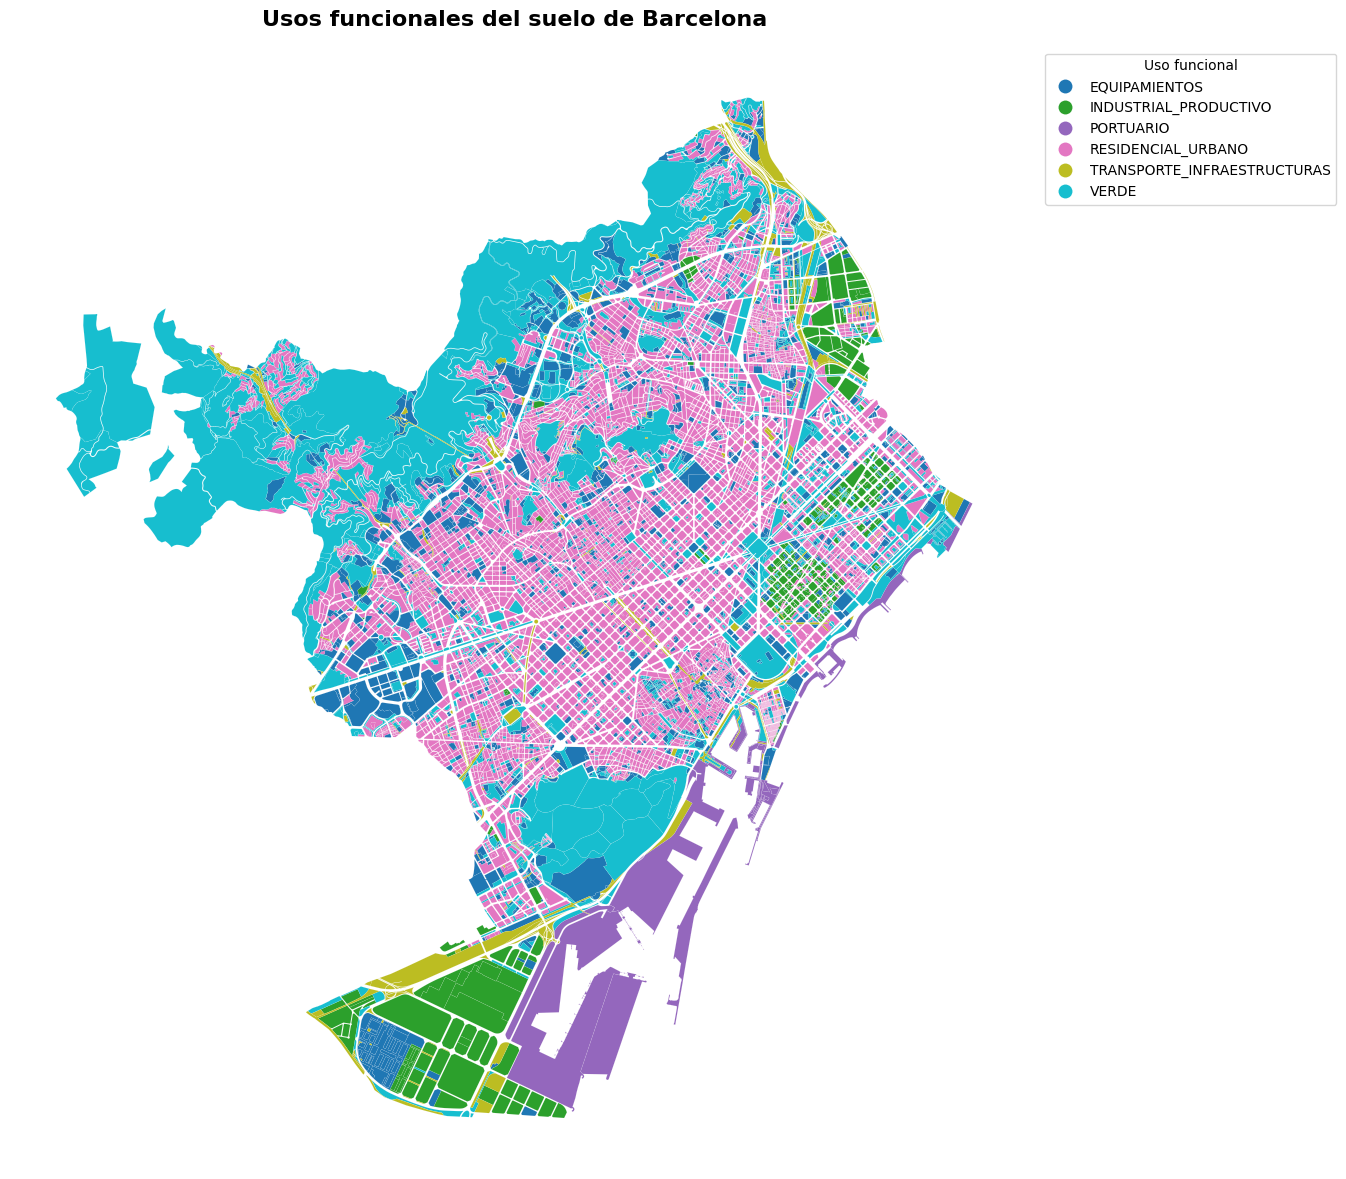

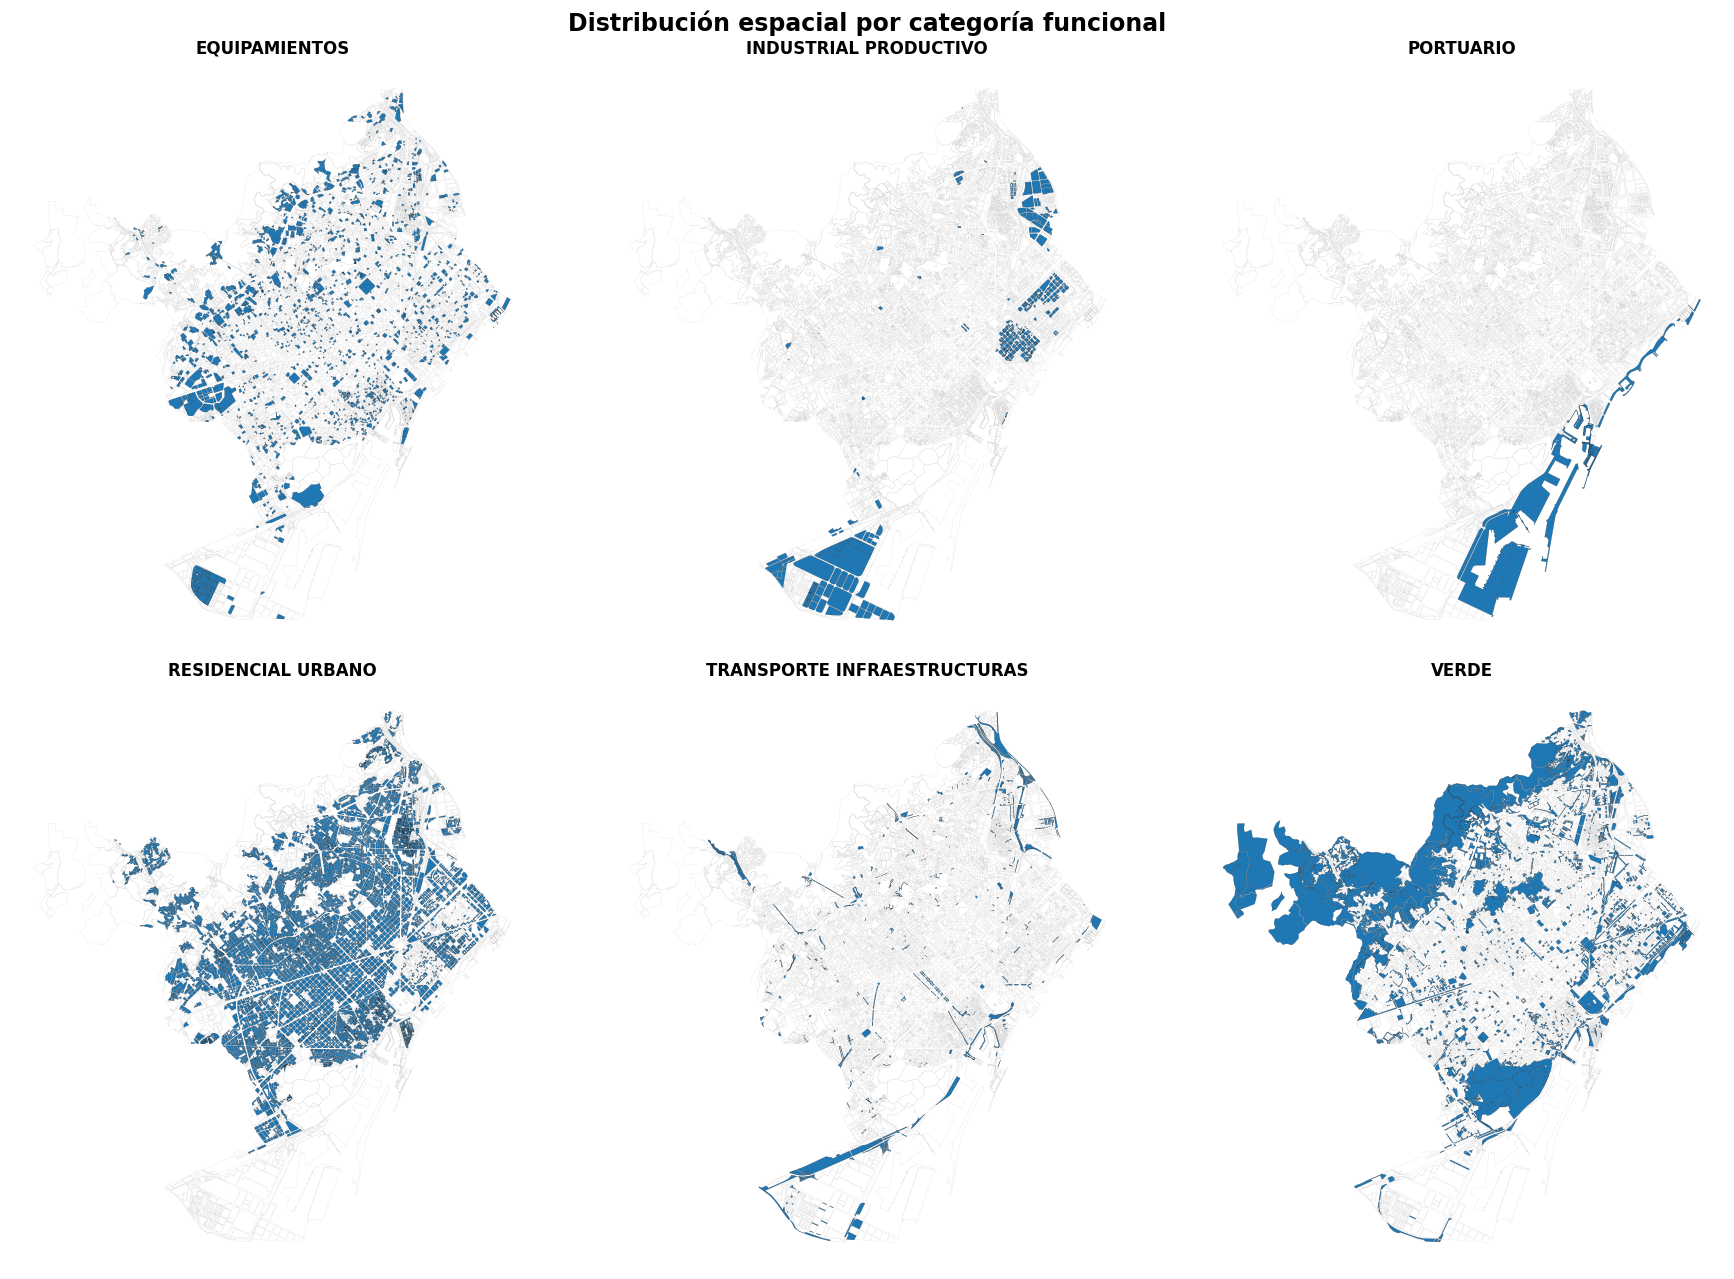


Extensión espacial de la capa:


,COORDENADA,VALOR
0,X mínima,420822.20
1,Y mínima,4574795.28
2,X máxima,435435.07
3,Y máxima,4591060.80



CONTROL FINAL DE LA CAPA


,INDICADOR,VALOR
0,Polígonos,14320
1,Categorías funcionales,6
2,Categorías nulas,0
3,Geometrías nulas,0
4,Geometrías vacías,0
5,Geometrías inválidas,0
6,CRS,EPSG:25831



✓ Control espacial completado correctamente.
✓ Se conservan los 14.320 polígonos.
✓ Las 6 categorías funcionales presentan geometría válida.
✓ No existen categorías funcionales nulas.
✓ CRS confirmado: EPSG:25831.
✓ La capa queda preparada para la generación de variables espaciales derivadas.


In [ ]:
# ============================================================
# 5.4. VISUALIZACIÓN Y CONTROL ESPACIAL
#      DE LOS USOS FUNCIONALES
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("=" * 100)
print("VISUALIZACIÓN Y CONTROL ESPACIAL DE LOS USOS FUNCIONALES")
print("=" * 100)


# ------------------------------------------------------------
# 1. COMPROBACIONES PREVIAS
# ------------------------------------------------------------

if "USO_FUNCIONAL" not in gdf_usos_reclasificado.columns:
    raise KeyError(
        "No se encuentra la variable 'USO_FUNCIONAL'. "
        "Debe ejecutarse previamente el apartado 5.3."
    )

if gdf_usos_reclasificado.crs is None:
    raise ValueError(
        "La capa no dispone de sistema de referencia espacial."
    )


print(f"\nPolígonos: {len(gdf_usos_reclasificado):,}")
print(f"CRS: {gdf_usos_reclasificado.crs}")

print(
    "Categorías funcionales:",
    gdf_usos_reclasificado["USO_FUNCIONAL"].nunique()
)


# ------------------------------------------------------------
# 2. DISTRIBUCIÓN ESPACIAL POR CATEGORÍA
# ------------------------------------------------------------

control_espacial = (
    gdf_usos_reclasificado
    .groupby("USO_FUNCIONAL")
    .agg(
        POLIGONOS=("USO_FUNCIONAL", "size"),
        SUPERFICIE_HA=("AREA_CALCULADA_HA", "sum")
    )
    .reset_index()
)

control_espacial["PCT_SUPERFICIE"] = (
    control_espacial["SUPERFICIE_HA"]
    / control_espacial["SUPERFICIE_HA"].sum()
    * 100
)

control_espacial["SUPERFICIE_HA"] = (
    control_espacial["SUPERFICIE_HA"]
    .round(2)
)

control_espacial["PCT_SUPERFICIE"] = (
    control_espacial["PCT_SUPERFICIE"]
    .round(2)
)

control_espacial = (
    control_espacial
    .sort_values(
        "SUPERFICIE_HA",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nDistribución territorial:")

display(control_espacial)


# ------------------------------------------------------------
# 3. MAPA GENERAL DE USOS FUNCIONALES
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13, 13)
)

gdf_usos_reclasificado.plot(
    ax=ax,
    column="USO_FUNCIONAL",
    categorical=True,
    legend=True,
    linewidth=0.05,
    edgecolor="white"
)

ax.set_title(
    "Usos funcionales del suelo de Barcelona",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_axis_off()

# Mejorar posición de la leyenda
leg = ax.get_legend()

if leg is not None:
    leg.set_title("Uso funcional")
    leg.set_bbox_to_anchor((1.02, 1))
    leg._loc = 2

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 4. MAPAS INDIVIDUALES POR CATEGORÍA
# ------------------------------------------------------------

categorias = sorted(
    gdf_usos_reclasificado[
        "USO_FUNCIONAL"
    ]
    .dropna()
    .unique()
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 13)
)

axes = axes.ravel()

for ax, categoria in zip(axes, categorias):

    # Contexto general de Barcelona
    gdf_usos_reclasificado.plot(
        ax=ax,
        facecolor="none",
        edgecolor="lightgrey",
        linewidth=0.15
    )

    # Categoría seleccionada
    gdf_categoria = (
        gdf_usos_reclasificado[
            gdf_usos_reclasificado[
                "USO_FUNCIONAL"
            ] == categoria
        ]
    )

    gdf_categoria.plot(
        ax=ax,
        edgecolor="black",
        linewidth=0.10
    )

    ax.set_title(
        categoria.replace("_", " "),
        fontsize=12,
        fontweight="bold"
    )

    ax.set_axis_off()


plt.suptitle(
    "Distribución espacial por categoría funcional",
    fontsize=17,
    fontweight="bold",
    y=0.98
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 5. CONTROL DE EXTENSIÓN ESPACIAL
# ------------------------------------------------------------

bounds = gdf_usos_reclasificado.total_bounds

control_extension = pd.DataFrame({
    "COORDENADA": [
        "X mínima",
        "Y mínima",
        "X máxima",
        "Y máxima"
    ],
    "VALOR": [
        bounds[0],
        bounds[1],
        bounds[2],
        bounds[3]
    ]
})

control_extension["VALOR"] = (
    control_extension["VALOR"]
    .round(2)
)

print("\nExtensión espacial de la capa:")

display(control_extension)


# ------------------------------------------------------------
# 6. CONTROL FINAL
# ------------------------------------------------------------

control_final_54 = pd.DataFrame({

    "INDICADOR": [
        "Polígonos",
        "Categorías funcionales",
        "Categorías nulas",
        "Geometrías nulas",
        "Geometrías vacías",
        "Geometrías inválidas",
        "CRS"
    ],

    "VALOR": [
        len(gdf_usos_reclasificado),

        gdf_usos_reclasificado[
            "USO_FUNCIONAL"
        ].nunique(dropna=True),

        int(
            gdf_usos_reclasificado[
                "USO_FUNCIONAL"
            ].isna().sum()
        ),

        int(
            gdf_usos_reclasificado.geometry
            .isna()
            .sum()
        ),

        int(
            gdf_usos_reclasificado.geometry
            .is_empty
            .sum()
        ),

        int(
            (~gdf_usos_reclasificado.geometry.is_valid)
            .sum()
        ),

        str(gdf_usos_reclasificado.crs)
    ]
})


print("\n" + "=" * 100)
print("CONTROL FINAL DE LA CAPA")
print("=" * 100)

display(control_final_54)


# ------------------------------------------------------------
# 7. VALIDACIONES
# ------------------------------------------------------------

assert len(gdf_usos_reclasificado) == 14320

assert (
    gdf_usos_reclasificado[
        "USO_FUNCIONAL"
    ].nunique(dropna=True)
    == 6
)

assert (
    gdf_usos_reclasificado[
        "USO_FUNCIONAL"
    ].isna().sum()
    == 0
)

assert (
    gdf_usos_reclasificado.geometry
    .isna()
    .sum()
    == 0
)

assert (
    gdf_usos_reclasificado.geometry
    .is_empty
    .sum()
    == 0
)

assert (
    (~gdf_usos_reclasificado.geometry.is_valid)
    .sum()
    == 0
)

assert (
    gdf_usos_reclasificado.crs.to_epsg()
    == 25831
)


print("\n✓ Control espacial completado correctamente.")
print("✓ Se conservan los 14.320 polígonos.")
print("✓ Las 6 categorías funcionales presentan geometría válida.")
print("✓ No existen categorías funcionales nulas.")
print("✓ CRS confirmado: EPSG:25831.")
print(
    "✓ La capa queda preparada para la generación "
    "de variables espaciales derivadas."
)

### Resultados del control espacial

La representación conjunta y los mapas individuales de las seis categorías funcionales muestran una distribución territorial coherente con la estructura urbana de Barcelona, confirmando la consistencia espacial de la reclasificación realizada.

El tejido `RESIDENCIAL_URBANO` configura principalmente el continuo edificado de la ciudad, mientras que `VERDE` presenta una marcada concentración en las grandes superficies naturales y espacios libres. `INDUSTRIAL_PRODUCTIVO` se localiza en ámbitos productivos específicos y `PORTUARIO` queda claramente diferenciado en el frente portuario. Por su parte, `TRANSPORTE_INFRAESTRUCTURAS` presenta el patrón predominantemente lineal asociado a los principales corredores y sistemas de movilidad, mientras que `EQUIPAMIENTOS` muestra una distribución más fragmentada e integrada en el tejido urbano.

Los mapas desagregados permiten comprobar que la simplificación temática mantiene patrones territoriales diferenciados e interpretables y no evidencia anomalías espaciales derivadas del proceso de reclasificación.

El control geométrico confirma la conservación de los **14.320 polígonos**, distribuidos entre **6 categorías funcionales**, sin categorías nulas ni geometrías nulas, vacías o inválidas. La capa mantiene el sistema de referencia **ETRS89 / UTM zona 31N (EPSG:25831)**.

La cartografía queda así validada para la posterior construcción de variables espaciales derivadas destinadas a caracterizar la composición funcional del entorno de las unidades de análisis.

Dado que la cartografía utilizada constituye una referencia espacial sin una serie anual homogénea para 2018–2024, las variables derivadas de esta capa se incorporarán al modelo como **covariables espaciales estáticas** durante todo el periodo de estudio.

## 5.5. Preparación, exportación y validación de la capa de usos del suelo

Una vez completadas la normalización temática, la reclasificación funcional y la validación espacial, se genera el producto definitivo de usos del suelo destinado a la fase de integración geoespacial.

La capa conserva la información necesaria para mantener la trazabilidad con la fuente original, incluyendo la variable `FAMILIA`, junto con la clasificación simplificada `USO_FUNCIONAL` obtenida durante el preprocesamiento. Asimismo, se mantienen las variables geométricas y de superficie necesarias para posteriores operaciones espaciales.

La información se exporta en formato **GeoPackage**, manteniendo el sistema de referencia **ETRS89 / UTM zona 31N (EPSG:25831)**. Se genera adicionalmente una versión tabular en formato CSV, sin geometría, destinada a facilitar controles, consultas y análisis complementarios.

Los productos se almacenan en el directorio de **PREINTEGRACION**, junto con los restantes bloques preparados para la construcción posterior del dataset geoespacial.

Tras la exportación se realiza una relectura independiente de los archivos generados para comprobar la conservación del número de registros, las categorías funcionales, el sistema de referencia y la integridad de las geometrías.

La capa resultante constituye una **covariable espacial estática**, por lo que su caracterización territorial se mantendrá constante durante el periodo de estudio 2018–2024.

In [ ]:
# ============================================================
# 5.5. PREPARACIÓN, EXPORTACIÓN Y VALIDACIÓN
#      DE LA CAPA DE USOS DEL SUELO
# ============================================================

from pathlib import Path
import geopandas as gpd
import pandas as pd

print("=" * 100)
print("EXPORTACIÓN DE LA CAPA DE USOS DEL SUELO")
print("=" * 100)


# ------------------------------------------------------------
# 1. DIRECTORIO DE SALIDA
# ------------------------------------------------------------

RUTA_PREINTEGRACION = Path(
    "/content/drive/MyDrive/TFM/"
    "10_Machine_Learning_Geoespacial/"
    "PREINTEGRACION"
)

SALIDA_USOS = (
    RUTA_PREINTEGRACION
    / "03_Usos_del_Suelo"
)

SALIDA_USOS.mkdir(
    parents=True,
    exist_ok=True
)

print("\nDirectorio de salida:")
print(SALIDA_USOS)


# ------------------------------------------------------------
# 2. PREPARAR CAPA DEFINITIVA
# ------------------------------------------------------------

gdf_usos_final = (
    gdf_usos_reclasificado
    .copy()
)


# ------------------------------------------------------------
# 3. COMPROBAR VARIABLES DISPONIBLES
# ------------------------------------------------------------

print("\nVariables disponibles:")

for columna in gdf_usos_final.columns:
    print("•", columna)


# ------------------------------------------------------------
# 4. SELECCIONAR VARIABLES PARA EL PRODUCTO FINAL
# ------------------------------------------------------------

columnas_deseadas = [
    "CLAU",
    "Descripcio",
    "FAMILIA",
    "USO_FUNCIONAL",
    "AREA_CALCULADA_M2",
    "AREA_CALCULADA_HA",
    "geometry"
]

columnas_finales = [
    columna
    for columna in columnas_deseadas
    if columna in gdf_usos_final.columns
]

gdf_usos_final = (
    gdf_usos_final[
        columnas_finales
    ]
    .copy()
)


print("\nVariables conservadas:")

for columna in gdf_usos_final.columns:
    print("•", columna)


# ------------------------------------------------------------
# 5. VALIDACIÓN PREVIA A LA EXPORTACIÓN
# ------------------------------------------------------------

n_registros_origen = len(
    gdf_usos_final
)

n_familias_origen = (
    gdf_usos_final[
        "FAMILIA"
    ]
    .nunique(dropna=True)
)

n_categorias_origen = (
    gdf_usos_final[
        "USO_FUNCIONAL"
    ]
    .nunique(dropna=True)
)

n_usos_nulos = int(
    gdf_usos_final[
        "USO_FUNCIONAL"
    ]
    .isna()
    .sum()
)

n_geometrias_nulas = int(
    gdf_usos_final.geometry
    .isna()
    .sum()
)

n_geometrias_vacias = int(
    gdf_usos_final.geometry
    .is_empty
    .sum()
)

n_geometrias_invalidas = int(
    (~gdf_usos_final.geometry.is_valid)
    .sum()
)


control_previo = pd.DataFrame({

    "INDICADOR": [
        "Registros",
        "Familias originales",
        "Categorías funcionales",
        "Usos funcionales nulos",
        "Geometrías nulas",
        "Geometrías vacías",
        "Geometrías inválidas",
        "CRS"
    ],

    "VALOR": [
        n_registros_origen,
        n_familias_origen,
        n_categorias_origen,
        n_usos_nulos,
        n_geometrias_nulas,
        n_geometrias_vacias,
        n_geometrias_invalidas,
        str(gdf_usos_final.crs)
    ]
})


print("\n" + "=" * 100)
print("CONTROL PREVIO A LA EXPORTACIÓN")
print("=" * 100)

display(control_previo)


# ------------------------------------------------------------
# 6. VALIDACIONES PREVIAS
# ------------------------------------------------------------

assert n_registros_origen == 14320

assert n_familias_origen == 21

assert n_categorias_origen == 6

assert n_usos_nulos == 0

assert n_geometrias_nulas == 0

assert n_geometrias_vacias == 0

assert n_geometrias_invalidas == 0

assert gdf_usos_final.crs.to_epsg() == 25831


print("\n✓ Control previo superado.")


# ------------------------------------------------------------
# 7. DEFINIR ARCHIVOS DE SALIDA
# ------------------------------------------------------------

ruta_gpkg = (
    SALIDA_USOS
    / "usos_suelo_barcelona.gpkg"
)

ruta_csv = (
    SALIDA_USOS
    / "df_usos_suelo_barcelona.csv"
)

ruta_control = (
    SALIDA_USOS
    / "control_usos_suelo.csv"
)


# ------------------------------------------------------------
# 8. ELIMINAR GEOPACKAGE PREVIO SI EXISTE
# ------------------------------------------------------------

if ruta_gpkg.exists():
    ruta_gpkg.unlink()


# ------------------------------------------------------------
# 9. EXPORTAR GEOPACKAGE
# ------------------------------------------------------------

gdf_usos_final.to_file(
    ruta_gpkg,
    layer="usos_suelo",
    driver="GPKG"
)

print("\n✓ GeoPackage exportado")


# ------------------------------------------------------------
# 10. EXPORTAR CSV TABULAR
# ------------------------------------------------------------

df_usos_csv = (
    gdf_usos_final
    .drop(columns="geometry")
    .copy()
)

df_usos_csv.to_csv(
    ruta_csv,
    index=False,
    encoding="utf-8-sig"
)

print("✓ CSV tabular exportado")


# ------------------------------------------------------------
# 11. RELECTURA DE LOS PRODUCTOS EXPORTADOS
# ------------------------------------------------------------

gdf_control = gpd.read_file(
    ruta_gpkg,
    layer="usos_suelo"
)

df_control_csv = pd.read_csv(
    ruta_csv,
    low_memory=False
)


# ------------------------------------------------------------
# 12. CONTROL DEL GEOPACKAGE RELEÍDO
# ------------------------------------------------------------

registros_gpkg = len(
    gdf_control
)

familias_gpkg = (
    gdf_control[
        "FAMILIA"
    ]
    .nunique(dropna=True)
)

categorias_gpkg = (
    gdf_control[
        "USO_FUNCIONAL"
    ]
    .nunique(dropna=True)
)

geometrias_nulas_gpkg = int(
    gdf_control.geometry
    .isna()
    .sum()
)

geometrias_vacias_gpkg = int(
    gdf_control.geometry
    .is_empty
    .sum()
)

geometrias_invalidas_gpkg = int(
    (~gdf_control.geometry.is_valid)
    .sum()
)


# ------------------------------------------------------------
# 13. CONTROL DEL CSV RELEÍDO
# ------------------------------------------------------------

registros_csv = len(
    df_control_csv
)

familias_csv = (
    df_control_csv[
        "FAMILIA"
    ]
    .nunique(dropna=True)
)

categorias_csv = (
    df_control_csv[
        "USO_FUNCIONAL"
    ]
    .nunique(dropna=True)
)


# ------------------------------------------------------------
# 14. COMPARACIONES
# ------------------------------------------------------------

csv_correcto = (
    registros_csv
    == n_registros_origen
)

gpkg_correcto = (
    registros_gpkg
    == n_registros_origen
)

familias_correctas = (
    familias_gpkg
    == n_familias_origen
    == familias_csv
)

categorias_correctas = (
    categorias_gpkg
    == n_categorias_origen
    == categorias_csv
)

crs_correcto = (
    gdf_control.crs is not None
    and gdf_control.crs.to_epsg() == 25831
)

geometria_correcta = (
    geometrias_nulas_gpkg == 0
    and geometrias_vacias_gpkg == 0
    and geometrias_invalidas_gpkg == 0
)


# ------------------------------------------------------------
# 15. TABLA DE CONTROL DE EXPORTACIÓN
# ------------------------------------------------------------

control_exportacion = pd.DataFrame({

    "PRODUCTO": [
        "usos_suelo"
    ],

    "REGISTROS_ORIGEN": [
        n_registros_origen
    ],

    "REGISTROS_GPKG": [
        registros_gpkg
    ],

    "REGISTROS_CSV": [
        registros_csv
    ],

    "FAMILIAS": [
        familias_gpkg
    ],

    "CATEGORIAS_FUNCIONALES": [
        categorias_gpkg
    ],

    "CRS": [
        str(gdf_control.crs)
    ],

    "GEOMETRIAS_NULAS": [
        geometrias_nulas_gpkg
    ],

    "GEOMETRIAS_VACIAS": [
        geometrias_vacias_gpkg
    ],

    "GEOMETRIAS_INVALIDAS": [
        geometrias_invalidas_gpkg
    ],

    "CSV_CORRECTO": [
        csv_correcto
    ],

    "GPKG_CORRECTO": [
        gpkg_correcto
    ],

    "FAMILIAS_CORRECTAS": [
        familias_correctas
    ],

    "CATEGORIAS_CORRECTAS": [
        categorias_correctas
    ],

    "CRS_CORRECTO": [
        crs_correcto
    ],

    "GEOMETRIA_CORRECTA": [
        geometria_correcta
    ]
})


control_exportacion[
    "VALIDACION_FINAL"
] = (
    control_exportacion[
        [
            "CSV_CORRECTO",
            "GPKG_CORRECTO",
            "FAMILIAS_CORRECTAS",
            "CATEGORIAS_CORRECTAS",
            "CRS_CORRECTO",
            "GEOMETRIA_CORRECTA"
        ]
    ]
    .all(axis=1)
)


print("\n" + "=" * 100)
print("VERIFICACIÓN DE LOS PRODUCTOS EXPORTADOS")
print("=" * 100)

display(control_exportacion)


# ------------------------------------------------------------
# 16. EXPORTAR INFORME DE CONTROL
# ------------------------------------------------------------

control_exportacion.to_csv(
    ruta_control,
    index=False,
    encoding="utf-8-sig"
)

print("\n✓ Informe de control exportado")


# ------------------------------------------------------------
# 17. VALIDACIÓN FINAL
# ------------------------------------------------------------

assert control_exportacion[
    "VALIDACION_FINAL"
].all(), (
    "La validación final de los productos "
    "exportados no ha sido superada."
)


# ------------------------------------------------------------
# 18. RESUMEN FINAL
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("RESUMEN FINAL")
print("=" * 100)

print(
    f"\nRegistros       : "
    f"{n_registros_origen:,}"
)

print(
    f"Familias        : "
    f"{n_familias_origen}"
)

print(
    f"Usos funcionales: "
    f"{n_categorias_origen}"
)

print(
    f"CRS             : "
    f"{gdf_control.crs}"
)

print("\nArchivos generados:")

print(
    "✓ usos_suelo_barcelona.gpkg"
)

print(
    "✓ df_usos_suelo_barcelona.csv"
)

print(
    "✓ control_usos_suelo.csv"
)

print(
    "\n✓ Exportación completada "
    "y validada correctamente."
)

print(
    "✓ La capa queda disponible "
    "en PREINTEGRACION."
)

EXPORTACIÓN DE LA CAPA DE USOS DEL SUELO

Directorio de salida:
/content/drive/MyDrive/TFM/10_Machine_Learning_Geoespacial/PREINTEGRACION/03_Usos_del_Suelo

Variables disponibles:
• FAMILIA
• CLAU
• District
• NDistric
• CBarri
• NBarri
• C_AEB
• CSecCens
• Area
• Perimetre
• Coord_X
• Coord_Y
• Descripcio
• geometry
• AREA_CALCULADA_M2
• AREA_CALCULADA_HA
• USO_FUNCIONAL

Variables conservadas:
• CLAU
• Descripcio
• FAMILIA
• USO_FUNCIONAL
• AREA_CALCULADA_M2
• AREA_CALCULADA_HA
• geometry

CONTROL PREVIO A LA EXPORTACIÓN


,INDICADOR,VALOR
0,Registros,14320
1,Familias originales,21
2,Categorías funcionales,6
3,Usos funcionales nulos,0
4,Geometrías nulas,0
5,Geometrías vacías,0
6,Geometrías inválidas,0
7,CRS,EPSG:25831



✓ Control previo superado.

✓ GeoPackage exportado
✓ CSV tabular exportado

VERIFICACIÓN DE LOS PRODUCTOS EXPORTADOS


,PRODUCTO,REGISTROS_ORIGEN,REGISTROS_GPKG,REGISTROS_CSV,FAMILIAS,CATEGORIAS_FUNCIONALES,CRS,GEOMETRIAS_NULAS,GEOMETRIAS_VACIAS,GEOMETRIAS_INVALIDAS,CSV_CORRECTO,GPKG_CORRECTO,FAMILIAS_CORRECTAS,CATEGORIAS_CORRECTAS,CRS_CORRECTO,GEOMETRIA_CORRECTA,VALIDACION_FINAL
0,usos_suelo,14320,14320,14320,21,6,EPSG:25831,0,0,0,True,True,True,True,True,True,True



✓ Informe de control exportado

RESUMEN FINAL

Registros       : 14,320
Familias        : 21
Usos funcionales: 6
CRS             : EPSG:25831

Archivos generados:
✓ usos_suelo_barcelona.gpkg
✓ df_usos_suelo_barcelona.csv
✓ control_usos_suelo.csv

✓ Exportación completada y validada correctamente.
✓ La capa queda disponible en PREINTEGRACION.


### Resultados de la exportación y validación

La capa definitiva de usos del suelo se exportó correctamente al directorio de `PREINTEGRACION`, generándose productos en formatos geoespacial y tabular junto con un archivo específico de control.

La capa final conserva los **14.320 polígonos** de la cartografía original, las **21 familias de usos del suelo** y las **6 categorías funcionales** obtenidas mediante la reclasificación. Se mantiene el sistema de referencia **ETRS89 / UTM zona 31N (EPSG:25831)**.

La relectura independiente de los productos exportados confirma la correspondencia completa entre los datos de origen y los archivos generados. Tanto el GeoPackage como el CSV contienen **14.320 registros**, conservándose íntegramente las familias originales y las categorías funcionales.

El control geométrico del GeoPackage confirma asimismo la ausencia de geometrías nulas, vacías o inválidas. Todas las comprobaciones de integridad de registros, clasificación temática, sistema de referencia y geometría resultan satisfactorias.

Se generan los siguientes productos:

- `usos_suelo_barcelona.gpkg`: capa geoespacial definitiva destinada a las posteriores operaciones de integración.
- `df_usos_suelo_barcelona.csv`: versión tabular para controles y análisis complementarios.
- `control_usos_suelo.csv`: informe de validación de los productos exportados.

La capa de usos del suelo queda, por tanto, **preparada y validada para la fase de integración geoespacial**.

La información se incorporará posteriormente como **covariable espacial estática durante 2018–2024**, generándose durante la integración los indicadores derivados necesarios para caracterizar la composición funcional del entorno de las unidades de análisis.

# 6 . Elevación y caracterización topográfica

La caracterización topográfica del área de estudio se incorpora mediante el **Modelo Digital del Terreno MDT200 – 1.ª cobertura**, distribuido por el Centro Nacional de Información Geográfica (CNIG) del Instituto Geográfico Nacional (IGN).

El producto proporciona información de elevación del terreno mediante una malla regular con paso de **200 metros**. Para el ámbito de estudio se utiliza el fichero correspondiente a **Barcelona, huso UTM 31**, compatible con el sistema de referencia empleado en las restantes capas geoespaciales del proyecto.

La elevación se considera una **covariable espacial estática** durante todo el periodo de estudio (2018–2024). Su incorporación no pretende analizar cambios temporales de la topografía, sino caracterizar las condiciones físicas del territorio que pueden intervenir en los procesos de dispersión y acumulación de contaminantes atmosféricos.

Durante este bloque se realizará:

- localización y lectura del modelo digital del terreno;
- comprobación de resolución, extensión, sistema de referencia y valores `NoData`;
- delimitación del MDT al ámbito territorial de Barcelona;
- análisis exploratorio de la distribución altimétrica;
- representación cartográfica de la elevación;
- preparación y validación del producto destinado a la posterior integración geoespacial.

En la fase de integración, el MDT permitirá derivar indicadores topográficos asociados a las unidades espaciales de análisis, manteniendo separada la información raster original de las variables finalmente incorporadas al modelo.

## 6.1. Configuración de rutas y localización del MDT

En primer lugar se definen las rutas de trabajo y se comprueba la disponibilidad del Modelo Digital del Terreno original.

Se mantiene una separación explícita entre los datos fuente y los productos derivados: el raster original permanece en su directorio de adquisición, mientras que las salidas generadas durante el procesamiento se dirigen al directorio específico de **preintegración geoespacial**.

Esta organización permite preservar los datos originales y mantener un flujo de trabajo reproducible y trazable antes de la integración con el resto de variables espaciales.

In [ ]:
# ============================================================
# 1. MONTAJE DE GOOGLE DRIVE Y DEFINICIÓN DE RUTAS
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")


# ------------------------------------------------------------
# 1. RUTA DEL DATO ORIGINAL
# ------------------------------------------------------------

RUTA_BASE_MDT = Path(
    "/content/drive/MyDrive/TFM/"
    "01_Modelo_Digital_del_Terreno"
)

RUTA_MDT = (
    RUTA_BASE_MDT
    / "mdt_200_barcelona_unificado.tif"
)


# ------------------------------------------------------------
# 2. RUTA DE PREINTEGRACIÓN GEOESPACIAL
# ------------------------------------------------------------

RUTA_PREINTEGRACION = Path(
    "/content/drive/MyDrive/TFM/"
    "10_Machine_Learning_Geoespacial/"
    "PREINTEGRACION"
)

RUTA_SALIDA_MDT = (
    RUTA_PREINTEGRACION
    / "05_Elevacion"
)

RUTA_SALIDA_MDT.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 3. CONTROL DE RUTAS
# ------------------------------------------------------------

print("=" * 100)
print("RUTAS DEL BLOQUE DE ELEVACIÓN")
print("=" * 100)

print("\nDato original:")
print(RUTA_MDT)

print("\nDirectorio de salida:")
print(RUTA_SALIDA_MDT)

print("\nComprobaciones:")
print(
    "MDT original existe :",
    RUTA_MDT.exists()
)

print(
    "Salida preparada    :",
    RUTA_SALIDA_MDT.exists()
)


# ------------------------------------------------------------
# 4. VALIDACIÓN
# ------------------------------------------------------------

if not RUTA_MDT.exists():
    raise FileNotFoundError(
        f"No se encuentra el MDT original:\n{RUTA_MDT}"
    )

assert RUTA_SALIDA_MDT.exists()

print(
    "\n✓ Rutas configuradas correctamente."
)

print(
    "✓ Todos los productos finales del bloque "
    "se guardarán en 10_Machine_Learning_Geoespacial/"
    "PREINTEGRACION/05_Elevacion."
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RUTAS DEL BLOQUE DE ELEVACIÓN

Dato original:
/content/drive/MyDrive/TFM/01_Modelo_Digital_del_Terreno/mdt_200_barcelona_unificado.tif

Directorio de salida:
/content/drive/MyDrive/TFM/10_Machine_Learning_Geoespacial/PREINTEGRACION/05_Elevacion

Comprobaciones:
MDT original existe : True
Salida preparada    : True

✓ Rutas configuradas correctamente.
✓ Todos los productos finales del bloque se guardarán en 10_Machine_Learning_Geoespacial/PREINTEGRACION/05_Elevacion.


### Resultados de la configuración de rutas

El Modelo Digital del Terreno utilizado como fuente se localiza correctamente en el directorio de datos originales del proyecto:

`01_Modelo_Digital_del_Terreno/mdt_200_barcelona_unificado.tif`

Se ha definido como directorio único de salida del bloque:

`10_Machine_Learning_Geoespacial/PREINTEGRACION/05_Elevacion`

La comprobación automática confirma tanto la existencia del raster original como la correcta creación del directorio de preintegración.

De este modo, se mantiene separada la **fuente cartográfica original** de los **productos derivados y preparados para la integración geoespacial**, evitando modificar los datos de partida y garantizando una estructura reproducible del flujo de procesamiento.

Todos los productos definitivos generados durante el tratamiento de la elevación se almacenarán exclusivamente en el directorio de preintegración geoespacial.

## 6.2. Lectura y auditoría inicial del Modelo Digital del Terreno

Una vez localizado el archivo fuente, se realiza la lectura del Modelo Digital del Terreno y una auditoría inicial de sus principales características técnicas y estadísticas.

Se comprueban las dimensiones del raster, el sistema de referencia espacial, la resolución, la extensión territorial y la presencia de celdas sin información (`NoData`). Asimismo, se calculan los principales estadísticos descriptivos de las elevaciones válidas.

Esta revisión permite verificar la integridad del MDT antes de proceder a su recorte al término municipal de Barcelona y proporciona una primera caracterización de la información altimétrica disponible.

In [ ]:
# ============================================================
# 6.2. LECTURA Y AUDITORÍA INICIAL DEL MDT
# ============================================================

import rasterio
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


print("=" * 100)
print("LECTURA Y AUDITORÍA INICIAL DEL MDT")
print("=" * 100)


# ------------------------------------------------------------
# 1. LECTURA DEL RASTER
# ------------------------------------------------------------

with rasterio.open(RUTA_MDT) as src:

    mdt = src.read(
        1,
        masked=True
    )

    perfil = src.profile.copy()

    transform = src.transform

    bounds = src.bounds

    crs = src.crs

    resolucion = src.res

    nodata = src.nodata

    dtype = src.dtypes[0]

    numero_bandas = src.count


print("\n✓ MDT leído correctamente.")


# ------------------------------------------------------------
# 2. EXTRAER VALORES VÁLIDOS
# ------------------------------------------------------------

valores_mdt = mdt.compressed()

if valores_mdt.size == 0:

    raise ValueError(
        "El MDT no contiene celdas válidas."
    )


# ------------------------------------------------------------
# 3. CONTROL GENERAL
# ------------------------------------------------------------

n_filas = mdt.shape[0]

n_columnas = mdt.shape[1]

n_celdas = mdt.size

n_validas = valores_mdt.size

n_nodata = np.ma.count_masked(mdt)

pct_validas = (
    n_validas
    / n_celdas
    * 100
)

pct_nodata = (
    n_nodata
    / n_celdas
    * 100
)


# ------------------------------------------------------------
# 4. RESUMEN TÉCNICO Y ESTADÍSTICO
# ------------------------------------------------------------

resumen_mdt = pd.DataFrame({

    "INDICADOR": [

        "Número de bandas",

        "Filas",

        "Columnas",

        "Número total de celdas",

        "Celdas válidas",

        "Celdas NoData",

        "Celdas válidas (%)",

        "Celdas NoData (%)",

        "Tipo de dato",

        "Valor NoData",

        "Resolución X (m)",

        "Resolución Y (m)",

        "CRS",

        "Elevación mínima (m)",

        "Elevación máxima (m)",

        "Elevación media (m)",

        "Elevación mediana (m)",

        "Desviación estándar (m)"
    ],

    "VALOR": [

        numero_bandas,

        n_filas,

        n_columnas,

        n_celdas,

        n_validas,

        n_nodata,

        round(
            pct_validas,
            2
        ),

        round(
            pct_nodata,
            2
        ),

        dtype,

        nodata,

        round(
            abs(resolucion[0]),
            2
        ),

        round(
            abs(resolucion[1]),
            2
        ),

        str(crs),

        round(
            float(valores_mdt.min()),
            2
        ),

        round(
            float(valores_mdt.max()),
            2
        ),

        round(
            float(valores_mdt.mean()),
            2
        ),

        round(
            float(np.median(valores_mdt)),
            2
        ),

        round(
            float(valores_mdt.std()),
            2
        )
    ]
})


display(
    resumen_mdt
)


# ------------------------------------------------------------
# 5. EXTENSIÓN ESPACIAL
# ------------------------------------------------------------

resumen_extension = pd.DataFrame({

    "LÍMITE": [
        "X mínima",
        "Y mínima",
        "X máxima",
        "Y máxima"
    ],

    "VALOR": [
        round(bounds.left, 2),
        round(bounds.bottom, 2),
        round(bounds.right, 2),
        round(bounds.top, 2)
    ]
})


print("\n" + "=" * 100)
print("EXTENSIÓN ESPACIAL DEL MDT")
print("=" * 100)

display(
    resumen_extension
)


# ------------------------------------------------------------
# 6. VALIDACIONES BÁSICAS
# ------------------------------------------------------------

assert numero_bandas == 1

assert (
    n_validas > 0
)

assert (
    resolucion[0] > 0
)

assert (
    abs(resolucion[1]) > 0
)

assert (
    crs is not None
)

assert (
    np.isfinite(
        valores_mdt
    ).all()
)


print(
    "\n✓ El raster contiene una única banda."
)

print(
    "✓ Existen valores altimétricos válidos."
)

print(
    "✓ El sistema de referencia espacial está definido."
)

print(
    "✓ La resolución espacial ha sido identificada."
)

print(
    "✓ No existen valores infinitos entre las celdas válidas."
)

print(
    "\n✓ Auditoría inicial del MDT completada correctamente."
)

LECTURA Y AUDITORÍA INICIAL DEL MDT

✓ MDT leído correctamente.


,INDICADOR,VALOR
0,Número de bandas,1
1,Filas,141
2,Columnas,142
3,Número total de celdas,20022
4,Celdas válidas,16474
5,Celdas NoData,3548
6,Celdas válidas (%),82.28
7,Celdas NoData (%),17.72
8,Tipo de dato,float32
9,Valor NoData,-32767.0



EXTENSIÓN ESPACIAL DEL MDT


,LÍMITE,VALOR
0,X mínima,414419.0
1,Y mínima,4566619.0
2,X máxima,442819.0
3,Y máxima,4594819.0



✓ El raster contiene una única banda.
✓ Existen valores altimétricos válidos.
✓ El sistema de referencia espacial está definido.
✓ La resolución espacial ha sido identificada.
✓ No existen valores infinitos entre las celdas válidas.

✓ Auditoría inicial del MDT completada correctamente.


### Resultados de la auditoría inicial

La auditoría confirma que el Modelo Digital del Terreno presenta una estructura raster válida y adecuada para continuar con el procesamiento geoespacial.

El MDT está formado por una única banda de tipo `float32`, con **141 filas y 142 columnas**, lo que supone un total de **20.022 celdas**. De ellas, **16.474 (82,28 %)** contienen información altimétrica válida, mientras que **3.548 (17,72 %)** corresponden a valores `NoData`, codificados mediante el valor `-32767`.

La resolución espacial comprobada es de **200 × 200 m**, coherente con las características del producto MDT200 utilizado. El raster se encuentra definido en el sistema de referencia **EPSG:3043** y presenta una extensión comprendida entre las coordenadas X 414.419–442.819 m e Y 4.566.619–4.594.819 m.

Las elevaciones válidas oscilan entre **-5,51 m y 486,62 m**, con una media de **68,79 m**, una mediana de **22,81 m** y una desviación estándar de **89,17 m**. La diferencia entre media y mediana anticipa una distribución altimétrica asimétrica, asociada a la coexistencia de extensas áreas de baja elevación y sectores topográficamente más elevados.

La presencia de valores ligeramente negativos se conservará inicialmente como parte de los datos originales y se comprobará espacialmente durante el recorte y la caracterización del ámbito municipal, evitando realizar correcciones no justificadas antes de conocer su localización.

La auditoría no detecta valores infinitos entre las celdas válidas y confirma la existencia de sistema de referencia, resolución y cobertura espacial correctamente definidos. El raster queda, por tanto, validado para proceder a su delimitación al término municipal de Barcelona.

## 6.3. Recorte del MDT al término municipal de Barcelona

Una vez comprobadas las características técnicas y estadísticas del Modelo Digital del Terreno, se procede a delimitar espacialmente el raster al ámbito estricto del término municipal de Barcelona.

Para ello se utiliza la geometría municipal previamente preparada en el bloque de unidades administrativas. Dado que el MDT se encuentra en `EPSG:3043`, el límite municipal se reproyecta temporalmente al sistema de referencia del raster antes de realizar la operación de recorte. De este modo se evita modificar el raster original durante esta fase del procesamiento.

El recorte permite eliminar las celdas exteriores al área de estudio y conservar únicamente la información altimétrica relevante para el análisis. Tras la operación se comprueban las dimensiones resultantes, el número de celdas válidas y `NoData`, así como los principales estadísticos de elevación.

El producto obtenido constituye la base raster municipal sobre la que se realizará posteriormente la caracterización topográfica y la preparación de las variables de elevación destinadas a la integración geoespacial.

In [ ]:

# ============================================================
# 6.3. RECORTE DEL MDT AL TÉRMINO MUNICIPAL DE BARCELONA
# ============================================================

from pathlib import Path

import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd

from rasterio.mask import mask
from shapely.geometry import mapping


print("=" * 100)
print("RECORTE DEL MDT AL TÉRMINO MUNICIPAL DE BARCELONA")
print("=" * 100)


# ------------------------------------------------------------
# 1. LOCALIZAR EL GEOPACKAGE DE UNIDADES ADMINISTRATIVAS
# ------------------------------------------------------------

RUTA_ADMIN = Path(
    "/content/drive/MyDrive/TFM/"
    "10_Machine_Learning_Geoespacial/"
    "PREINTEGRACION/"
    "unidades_administrativas_barcelona.gpkg"
)

if not RUTA_ADMIN.exists():
    raise FileNotFoundError(
        "No se encuentra el GeoPackage de unidades administrativas:\n"
        f"{RUTA_ADMIN}"
    )

print("\nGeoPackage administrativo:")
print(RUTA_ADMIN)


# ------------------------------------------------------------
# 2. LEER LOS DISTRITOS
# ------------------------------------------------------------

distritos = gpd.read_file(
    RUTA_ADMIN,
    layer="distritos"
)

print("\nCapa de distritos cargada correctamente.")

print(
    f"Distritos           : "
    f"{len(distritos):,}"
)

print(
    f"CRS administrativo  : "
    f"{distritos.crs}"
)


# ------------------------------------------------------------
# 3. GENERAR EL TÉRMINO MUNICIPAL
# ------------------------------------------------------------

# El GeoPackage administrativo contiene las capas:
# distritos, barrios, aeb y secciones_censales.
#
# El término municipal se reconstruye a partir de la
# disolución de todas las geometrías de los distritos.

municipio = (
    distritos
    .dissolve()
    .reset_index(drop=True)
)

print("\nTérmino municipal generado mediante disolución.")

print(
    f"Geometrías municipales : "
    f"{len(municipio):,}"
)


# ------------------------------------------------------------
# 4. CONTROL DE LA GEOMETRÍA MUNICIPAL
# ------------------------------------------------------------

geometrias_nulas_municipio = int(
    municipio.geometry
    .isna()
    .sum()
)

geometrias_vacias_municipio = int(
    municipio.geometry
    .is_empty
    .sum()
)

geometrias_invalidas_municipio = int(
    (
        ~municipio.geometry.is_valid
    )
    .sum()
)

print("\nControl geométrico:")

print(
    f"Geometrías nulas     : "
    f"{geometrias_nulas_municipio}"
)

print(
    f"Geometrías vacías    : "
    f"{geometrias_vacias_municipio}"
)

print(
    f"Geometrías inválidas : "
    f"{geometrias_invalidas_municipio}"
)


# ------------------------------------------------------------
# 5. VALIDACIÓN PREVIA DEL LÍMITE MUNICIPAL
# ------------------------------------------------------------

assert len(distritos) > 0, (
    "La capa de distritos está vacía."
)

assert len(municipio) == 1, (
    "La disolución no ha generado una única "
    "geometría municipal."
)

assert geometrias_nulas_municipio == 0, (
    "Existen geometrías municipales nulas."
)

assert geometrias_vacias_municipio == 0, (
    "Existen geometrías municipales vacías."
)

assert geometrias_invalidas_municipio == 0, (
    "La geometría municipal resultante no es válida."
)

assert municipio.crs is not None, (
    "La geometría municipal no tiene CRS definido."
)

print(
    "\n✓ Límite municipal generado y validado correctamente."
)


# ------------------------------------------------------------
# 6. ABRIR MDT Y HOMOGENEIZAR CRS
# ------------------------------------------------------------

with rasterio.open(RUTA_MDT) as src:

    print("\n" + "=" * 100)
    print("CONTROL DE SISTEMAS DE REFERENCIA")
    print("=" * 100)

    print(
        f"CRS del MDT             : "
        f"{src.crs}"
    )

    print(
        f"CRS administrativo      : "
        f"{municipio.crs}"
    )

    print(
        f"Resolución MDT           : "
        f"{src.res}"
    )

    # --------------------------------------------------------
    # 7. REPROYECTAR EL MUNICIPIO AL CRS NATIVO DEL MDT
    # --------------------------------------------------------

    municipio_mdt = municipio.to_crs(
        src.crs
    )

    print(
        f"CRS municipio para corte: "
        f"{municipio_mdt.crs}"
    )

    # Comprobar que la reproyección mantiene
    # una geometría válida

    assert municipio_mdt.crs == src.crs, (
        "El municipio no ha sido reproyectado "
        "correctamente al CRS del MDT."
    )

    assert municipio_mdt.geometry.is_valid.all(), (
        "La geometría municipal presenta problemas "
        "después de la reproyección."
    )

    # --------------------------------------------------------
    # 8. PREPARAR GEOMETRÍA PARA RASTERIO
    # --------------------------------------------------------

    geometrias = [
        mapping(geom)
        for geom in municipio_mdt.geometry
    ]

    # --------------------------------------------------------
    # 9. RECORTAR EL MDT
    # --------------------------------------------------------

    mdt_recortado_3d, transform_recortado = mask(
        src,
        geometrias,
        crop=True,
        filled=False
    )

    perfil_recortado = (
        src.profile.copy()
    )


# ------------------------------------------------------------
# 10. ELIMINAR DIMENSIÓN DE BANDA
# ------------------------------------------------------------

mdt_recortado = (
    mdt_recortado_3d[0]
)


# ------------------------------------------------------------
# 11. ACTUALIZAR PERFIL DEL RASTER
# ------------------------------------------------------------

perfil_recortado.update(
    {
        "height":
            mdt_recortado.shape[0],

        "width":
            mdt_recortado.shape[1],

        "transform":
            transform_recortado,

        "count":
            1
    }
)


# ------------------------------------------------------------
# 12. EXTRAER VALORES VÁLIDOS
# ------------------------------------------------------------

valores_recortados = (
    mdt_recortado
    .compressed()
)

if valores_recortados.size == 0:
    raise ValueError(
        "El MDT recortado no contiene valores válidos."
    )


# ------------------------------------------------------------
# 13. CALCULAR INDICADORES
# ------------------------------------------------------------

n_celdas_recorte = (
    mdt_recortado.size
)

n_validas_recorte = (
    valores_recortados.size
)

n_nodata_recorte = int(
    np.ma.count_masked(
        mdt_recortado
    )
)

pct_validas_recorte = (
    n_validas_recorte
    / n_celdas_recorte
    * 100
)

pct_nodata_recorte = (
    n_nodata_recorte
    / n_celdas_recorte
    * 100
)

resolucion_x_recorte = float(
    abs(
        transform_recortado.a
    )
)

resolucion_y_recorte = float(
    abs(
        transform_recortado.e
    )
)


# ------------------------------------------------------------
# 14. RESUMEN DEL RECORTE
# ------------------------------------------------------------

resumen_recorte = pd.DataFrame(
    {
        "INDICADOR": [

            "Filas originales",
            "Columnas originales",

            "Filas recortadas",
            "Columnas recortadas",

            "Celdas totales recorte",
            "Celdas válidas",
            "Celdas NoData",

            "Celdas válidas (%)",
            "Celdas NoData (%)",

            "Resolución X (m)",
            "Resolución Y (m)",

            "CRS",

            "Elevación mínima (m)",
            "Elevación máxima (m)",
            "Elevación media (m)",
            "Elevación mediana (m)",
            "Desviación estándar (m)"
        ],

        "VALOR": [

            mdt.shape[0],
            mdt.shape[1],

            mdt_recortado.shape[0],
            mdt_recortado.shape[1],

            n_celdas_recorte,
            n_validas_recorte,
            n_nodata_recorte,

            round(
                pct_validas_recorte,
                2
            ),

            round(
                pct_nodata_recorte,
                2
            ),

            resolucion_x_recorte,
            resolucion_y_recorte,

            str(
                perfil_recortado["crs"]
            ),

            round(
                float(
                    valores_recortados.min()
                ),
                2
            ),

            round(
                float(
                    valores_recortados.max()
                ),
                2
            ),

            round(
                float(
                    valores_recortados.mean()
                ),
                2
            ),

            round(
                float(
                    np.median(
                        valores_recortados
                    )
                ),
                2
            ),

            round(
                float(
                    valores_recortados.std()
                ),
                2
            )
        ]
    }
)


print("\n" + "=" * 100)
print("RESULTADOS DEL RECORTE")
print("=" * 100)

display(
    resumen_recorte
)


# ------------------------------------------------------------
# 15. VALIDACIONES DEL RASTER RECORTADO
# ------------------------------------------------------------

assert (
    mdt_recortado.ndim == 2
), (
    "El MDT recortado no tiene dos dimensiones."
)

assert (
    mdt_recortado.shape[0]
    <= mdt.shape[0]
), (
    "El número de filas del recorte supera "
    "al raster original."
)

assert (
    mdt_recortado.shape[1]
    <= mdt.shape[1]
), (
    "El número de columnas del recorte supera "
    "al raster original."
)

assert (
    valores_recortados.size > 0
), (
    "El MDT recortado no contiene celdas válidas."
)

assert (
    np.isfinite(
        valores_recortados
    ).all()
), (
    "Existen valores infinitos o no finitos "
    "en el MDT recortado."
)

assert (
    n_validas_recorte
    + n_nodata_recorte
    == n_celdas_recorte
), (
    "El balance entre celdas válidas y NoData "
    "no coincide con el total."
)

assert (
    resolucion_x_recorte == 200.0
), (
    "La resolución X del MDT ha cambiado."
)

assert (
    resolucion_y_recorte == 200.0
), (
    "La resolución Y del MDT ha cambiado."
)


# ------------------------------------------------------------
# 16. RESULTADO FINAL
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("VALIDACIÓN FINAL")
print("=" * 100)

print(
    "\n✓ Distritos administrativos cargados correctamente."
)

print(
    "✓ Término municipal reconstruido mediante "
    "disolución de los distritos."
)

print(
    "✓ Límite municipal validado correctamente."
)

print(
    "✓ Municipio reproyectado temporalmente "
    "al CRS nativo del MDT."
)

print(
    "✓ MDT recortado al término municipal de Barcelona."
)

print(
    "✓ Resolución espacial original conservada."
)

print(
    "✓ El raster original permanece sin modificaciones."
)

print(
    "✓ Recorte preparado para la caracterización altimétrica."
)


RECORTE DEL MDT AL TÉRMINO MUNICIPAL DE BARCELONA

GeoPackage administrativo:
/content/drive/MyDrive/TFM/10_Machine_Learning_Geoespacial/PREINTEGRACION/unidades_administrativas_barcelona.gpkg

Capa de distritos cargada correctamente.
Distritos           : 10
CRS administrativo  : EPSG:25831

Término municipal generado mediante disolución.
Geometrías municipales : 1

Control geométrico:
Geometrías nulas     : 0
Geometrías vacías    : 0
Geometrías inválidas : 0

✓ Límite municipal generado y validado correctamente.

CONTROL DE SISTEMAS DE REFERENCIA
CRS del MDT             : EPSG:3043
CRS administrativo      : EPSG:25831
Resolución MDT           : (200.0, 200.0)
CRS municipio para corte: PROJCS["ETRS89 / UTM zone 31N (N-E)",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],A

,INDICADOR,VALOR
0,Filas originales,141
1,Columnas originales,142
2,Filas recortadas,85
3,Columnas recortadas,75
4,Celdas totales recorte,6375
5,Celdas válidas,2519
6,Celdas NoData,3856
7,Celdas válidas (%),39.51
8,Celdas NoData (%),60.49
9,Resolución X (m),200.0



VALIDACIÓN FINAL

✓ Distritos administrativos cargados correctamente.
✓ Término municipal reconstruido mediante disolución de los distritos.
✓ Límite municipal validado correctamente.
✓ Municipio reproyectado temporalmente al CRS nativo del MDT.
✓ MDT recortado al término municipal de Barcelona.
✓ Resolución espacial original conservada.
✓ El raster original permanece sin modificaciones.
✓ Recorte preparado para la caracterización altimétrica.



### Resultados del recorte del MDT al término municipal de Barcelona

El límite municipal de Barcelona se reconstruyó mediante la disolución de los **10 distritos administrativos**, obteniéndose una única geometría municipal válida, sin geometrías nulas, vacías o inválidas. Para realizar el recorte, esta geometría se reproyectó temporalmente desde **EPSG:25831** al sistema de referencia nativo del MDT (**EPSG:3043**), manteniéndose el raster original sin modificaciones.

El recorte redujo el MDT original de **141 × 142 celdas** a una matriz de **85 × 75 celdas**, con **6.375 celdas totales**, de las cuales **2.519 (39,51 %)** contienen información altimétrica válida. La resolución espacial original de **200 × 200 m** se conservó durante todo el proceso.

Dentro del término municipal se obtiene un rango altimétrico comprendido entre **−5,51 m y 486,62 m**, con una elevación media de **94,33 m**, una mediana de **45,94 m** y una desviación estándar de **110,69 m**. La diferencia entre media y mediana refleja una distribución altimétrica asimétrica, asociada a la coexistencia de las zonas urbanas bajas y litorales con sectores de mayor elevación del municipio.


## 6.4. Representación espacial del Modelo Digital del Terreno

Una vez recortado y validado el MDT al término municipal de Barcelona, se realiza su representación cartográfica con el objetivo de comprobar visualmente la distribución espacial de la elevación y la coherencia del recorte efectuado.

La visualización mantiene el **CRS nativo del MDT (EPSG:3043)** y su resolución espacial original de **200 × 200 m**, incorporando el límite municipal como referencia cartográfica. La escala cromática representa la elevación del terreno en metros.

VISUALIZACIÓN DEL MDT RECORTADO DE BARCELONA


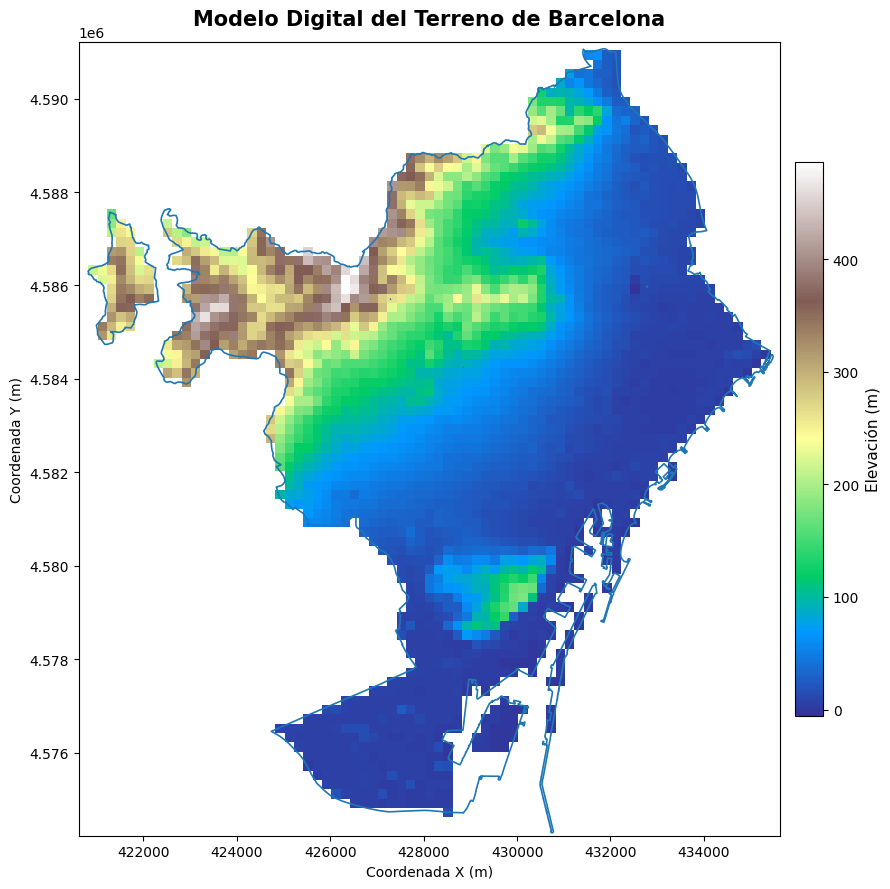


Resumen de la representación:
Resolución espacial : 200 × 200 m
Celdas válidas     : 2,519
Elevación mínima   : -5.51 m
Elevación máxima   : 486.62 m
Elevación media    : 94.33 m

✓ MDT municipal representado correctamente.
✓ El límite administrativo se utiliza únicamente como referencia cartográfica.
✓ El raster mantiene su resolución y CRS nativos.


In [ ]:

# ============================================================
# 6.4. VISUALIZACIÓN DEL MDT RECORTADO DE BARCELONA
# ============================================================

import matplotlib.pyplot as plt
from rasterio.plot import plotting_extent

print("=" * 100)
print("VISUALIZACIÓN DEL MDT RECORTADO DE BARCELONA")
print("=" * 100)

# ------------------------------------------------------------
# 1. DEFINIR EXTENSIÓN ESPACIAL DEL RASTER RECORTADO
# ------------------------------------------------------------

extension_mdt_recortado = plotting_extent(
    mdt_recortado,
    transform_recortado
)

# ------------------------------------------------------------
# 2. PREPARAR LÍMITE MUNICIPAL EN EL CRS DEL MDT
# ------------------------------------------------------------

municipio_visualizacion = municipio.to_crs(
    perfil_recortado["crs"]
)

# ------------------------------------------------------------
# 3. CREAR FIGURA
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 9)
)

imagen = ax.imshow(
    mdt_recortado,
    extent=extension_mdt_recortado,
    cmap="terrain",
    interpolation="nearest"
)

# ------------------------------------------------------------
# 4. REPRESENTAR LÍMITE MUNICIPAL
# ------------------------------------------------------------

municipio_visualizacion.boundary.plot(
    ax=ax,
    linewidth=1.2
)

# ------------------------------------------------------------
# 5. BARRA DE COLOR
# ------------------------------------------------------------

barra = fig.colorbar(
    imagen,
    ax=ax,
    fraction=0.035,
    pad=0.02
)

barra.set_label(
    "Elevación (m)",
    fontsize=11
)

# ------------------------------------------------------------
# 6. FORMATO DEL MAPA
# ------------------------------------------------------------

ax.set_title(
    "Modelo Digital del Terreno de Barcelona",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel(
    "Coordenada X (m)"
)

ax.set_ylabel(
    "Coordenada Y (m)"
)

ax.set_aspect(
    "equal"
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 7. RESUMEN DE LA REPRESENTACIÓN
# ------------------------------------------------------------

print("\nResumen de la representación:")

print(
    f"Resolución espacial : "
    f"{resolucion_x_recorte:.0f} × "
    f"{resolucion_y_recorte:.0f} m"
)

print(
    f"Celdas válidas     : "
    f"{n_validas_recorte:,}"
)

print(
    f"Elevación mínima   : "
    f"{valores_recortados.min():.2f} m"
)

print(
    f"Elevación máxima   : "
    f"{valores_recortados.max():.2f} m"
)

print(
    f"Elevación media    : "
    f"{valores_recortados.mean():.2f} m"
)

print(
    "\n✓ MDT municipal representado correctamente."
)

print(
    "✓ El límite administrativo se utiliza únicamente "
    "como referencia cartográfica."
)

print(
    "✓ El raster mantiene su resolución y CRS nativos."
)




#### Resultados

La representación del Modelo Digital del Terreno permite identificar con claridad el patrón altimétrico de Barcelona. Las cotas más bajas se concentran principalmente en la franja litoral y en buena parte de la trama urbana, mientras que la elevación aumenta progresivamente hacia los sectores interiores y occidentales del municipio.

El rango altimétrico obtenido se sitúa entre **−5,51 m y 486,62 m**, con una elevación media de **94,33 m** y una mediana de **45,94 m**. La diferencia entre media y mediana evidencia una distribución asimétrica, condicionada por la presencia de sectores de elevada altitud frente al predominio de superficies urbanas situadas a cotas relativamente bajas.

La representación confirma asimismo la correcta correspondencia espacial entre el MDT recortado y el límite municipal. Se conserva la resolución original de **200 × 200 m** y el **CRS nativo EPSG:3043**, quedando el raster preparado para la posterior generación de variables altimétricas e integración con el resto de información geoespacial.




## 6.5. Caracterización altimétrica del término municipal de Barcelona

Una vez recortado y validado el Modelo Digital del Terreno (MDT) al ámbito municipal, se analiza la **distribución altimétrica de Barcelona** con el objetivo de caracterizar la variabilidad topográfica antes de incorporar la elevación al conjunto de variables geoespaciales.

Para ello se calculan los principales **estadísticos descriptivos y percentiles de elevación**, así como la distribución de las celdas válidas en diferentes rangos altitudinales. Esta caracterización permite evaluar tanto la tendencia central como la dispersión y asimetría de las cotas presentes en el municipio.

La elevación se considera una **variable geoespacial estática** durante todo el periodo de estudio (2018–2024), al representar una característica física del territorio independiente de la evolución temporal de las restantes variables analizadas.



CARACTERIZACIÓN ALTIMÉTRICA DE BARCELONA


,INDICADOR,VALOR
0,Celdas válidas,2519.00
1,Elevación mínima (m),-5.51
2,Percentil 25 (m),9.45
3,Mediana (m),45.94
4,Elevación media (m),94.33
5,Percentil 75 (m),139.43
6,Percentil 90 (m),285.89
7,Percentil 95 (m),342.08
8,Elevación máxima (m),486.62
9,Desviación estándar (m),110.69



DISTRIBUCIÓN POR RANGOS ALTITUDINALES


,RANGO_ALTITUD,CELDAS,PORCENTAJE
0,< 25 m,965,38.31
1,25–50 m,343,13.62
2,50–100 m,381,15.13
3,100–200 m,396,15.72
4,200–300 m,221,8.77
5,> 300 m,213,8.46


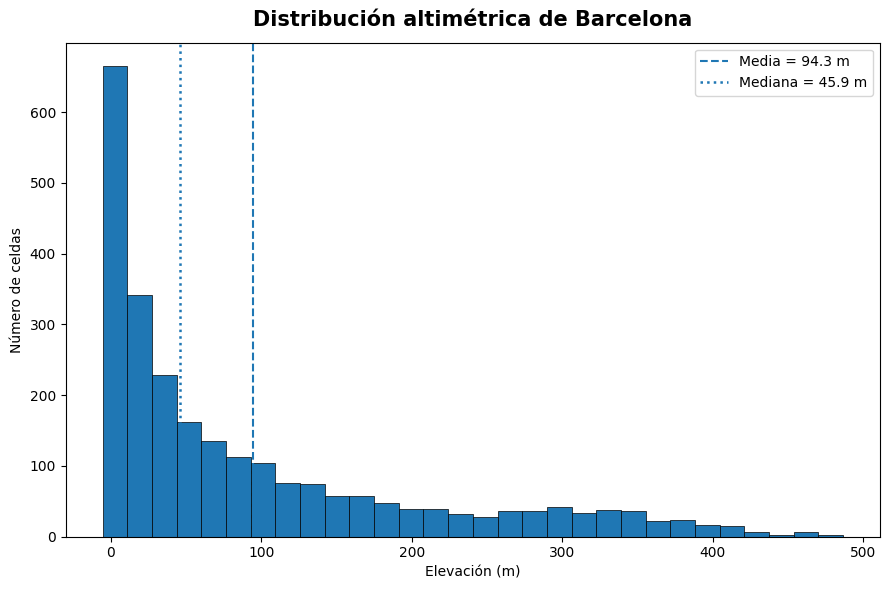


✓ Caracterización altimétrica completada.
✓ Todas las celdas válidas han sido clasificadas por rango de elevación.
✓ La distribución queda preparada para su interpretación y posterior integración.


In [ ]:

# ============================================================
# 6.5. CARACTERIZACIÓN ALTIMÉTRICA DEL TÉRMINO MUNICIPAL
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 100)
print("CARACTERIZACIÓN ALTIMÉTRICA DE BARCELONA")
print("=" * 100)


# ------------------------------------------------------------
# 1. VALORES VÁLIDOS DEL MDT MUNICIPAL
# ------------------------------------------------------------

elevaciones_validas = (
    mdt_recortado
    .compressed()
    .astype(float)
)

if elevaciones_validas.size == 0:
    raise ValueError(
        "El MDT recortado no contiene valores válidos."
    )


# ------------------------------------------------------------
# 2. ESTADÍSTICOS DESCRIPTIVOS
# ------------------------------------------------------------

q25 = np.percentile(
    elevaciones_validas,
    25
)

q50 = np.percentile(
    elevaciones_validas,
    50
)

q75 = np.percentile(
    elevaciones_validas,
    75
)

q90 = np.percentile(
    elevaciones_validas,
    90
)

q95 = np.percentile(
    elevaciones_validas,
    95
)

iqr = q75 - q25


resumen_altimetrico = pd.DataFrame(
    {
        "INDICADOR": [
            "Celdas válidas",
            "Elevación mínima (m)",
            "Percentil 25 (m)",
            "Mediana (m)",
            "Elevación media (m)",
            "Percentil 75 (m)",
            "Percentil 90 (m)",
            "Percentil 95 (m)",
            "Elevación máxima (m)",
            "Desviación estándar (m)",
            "Rango intercuartílico (m)"
        ],

        "VALOR": [
            len(elevaciones_validas),

            round(
                elevaciones_validas.min(),
                2
            ),

            round(
                q25,
                2
            ),

            round(
                q50,
                2
            ),

            round(
                elevaciones_validas.mean(),
                2
            ),

            round(
                q75,
                2
            ),

            round(
                q90,
                2
            ),

            round(
                q95,
                2
            ),

            round(
                elevaciones_validas.max(),
                2
            ),

            round(
                elevaciones_validas.std(),
                2
            ),

            round(
                iqr,
                2
            )
        ]
    }
)

display(
    resumen_altimetrico
)


# ------------------------------------------------------------
# 3. DISTRIBUCIÓN POR INTERVALOS ALTITUDINALES
# ------------------------------------------------------------

bins_altitud = [
    -np.inf,
    25,
    50,
    100,
    200,
    300,
    np.inf
]

etiquetas_altitud = [
    "< 25 m",
    "25–50 m",
    "50–100 m",
    "100–200 m",
    "200–300 m",
    "> 300 m"
]

clases_altitud = pd.cut(
    elevaciones_validas,
    bins=bins_altitud,
    labels=etiquetas_altitud,
    right=False
)

distribucion_altitud = (
    pd.Series(
        clases_altitud
    )
    .value_counts(
        sort=False
    )
    .rename_axis(
        "RANGO_ALTITUD"
    )
    .reset_index(
        name="CELDAS"
    )
)

distribucion_altitud[
    "PORCENTAJE"
] = (
    distribucion_altitud[
        "CELDAS"
    ]
    / len(elevaciones_validas)
    * 100
).round(2)


print("\n" + "=" * 100)
print("DISTRIBUCIÓN POR RANGOS ALTITUDINALES")
print("=" * 100)

display(
    distribucion_altitud
)


# ------------------------------------------------------------
# 4. HISTOGRAMA DE ELEVACIONES
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.hist(
    elevaciones_validas,
    bins=30,
    edgecolor="black",
    linewidth=0.5
)

ax.axvline(
    elevaciones_validas.mean(),
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Media = "
        f"{elevaciones_validas.mean():.1f} m"
    )
)

ax.axvline(
    np.median(
        elevaciones_validas
    ),
    linestyle=":",
    linewidth=1.8,
    label=(
        f"Mediana = "
        f"{np.median(elevaciones_validas):.1f} m"
    )
)

ax.set_title(
    "Distribución altimétrica de Barcelona",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel(
    "Elevación (m)"
)

ax.set_ylabel(
    "Número de celdas"
)

ax.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. VALIDACIONES
# ------------------------------------------------------------

assert (
    len(elevaciones_validas)
    == n_validas_recorte
), (
    "El número de celdas válidas no coincide "
    "con el obtenido durante el recorte."
)

assert (
    distribucion_altitud[
        "CELDAS"
    ].sum()
    == len(elevaciones_validas)
), (
    "La clasificación altimétrica no contiene "
    "todas las celdas válidas."
)

assert np.isclose(
    distribucion_altitud[
        "PORCENTAJE"
    ].sum(),
    100,
    atol=0.1
), (
    "Los porcentajes de distribución "
    "altimétrica no suman aproximadamente 100 %."
)

assert (
    np.isfinite(
        elevaciones_validas
    ).all()
), (
    "Existen valores no finitos "
    "entre las elevaciones válidas."
)


# ------------------------------------------------------------
# 6. RESULTADO FINAL
# ------------------------------------------------------------

print(
    "\n✓ Caracterización altimétrica completada."
)

print(
    "✓ Todas las celdas válidas han sido "
    "clasificadas por rango de elevación."
)

print(
    "✓ La distribución queda preparada "
    "para su interpretación y posterior integración."
)




#### Resultados

La caracterización altimétrica confirma una **marcada heterogeneidad topográfica** dentro del término municipal de Barcelona. Las **2.519 celdas válidas** presentan elevaciones comprendidas entre **−5,51 m y 486,62 m**, con una media de **94,33 m** y una mediana de **45,94 m**. La diferencia entre ambos estadísticos evidencia una distribución claramente asimétrica hacia las cotas elevadas.

El **38,31 %** de las celdas se sitúa por debajo de los **25 m**, porcentaje que alcanza el **51,93 %** por debajo de los **50 m** y el **67,06 %** por debajo de los **100 m**. En contraste, las cotas superiores a **200 m** representan el **17,23 %** de las celdas, de las cuales un **8,46 %** supera los **300 m**.

Los percentiles refuerzan esta estructura: el **75 % de las celdas presenta elevaciones inferiores a 139,43 m**, mientras que únicamente el 10 % supera aproximadamente los **285,89 m**. La elevada desviación estándar (**110,69 m**) y el rango intercuartílico (**129,98 m**) reflejan igualmente la importante variabilidad altimétrica existente dentro del municipio.

Estos resultados justifican la incorporación de la **elevación como variable geoespacial explicativa estática**, ya que permite representar diferencias territoriales potencialmente relevantes para el análisis espacial de la contaminación atmosférica. La información altimétrica queda preparada para su transformación en una variable espacial integrable con el resto de predictores del modelo.




## 6.6. Generación de la variable de elevación para la integración geoespacial

Una vez caracterizada la distribución altimétrica del término municipal, se transforma la información raster del MDT en una estructura geoespacial preparada para su posterior integración con el resto de variables del modelo.

Para ello, se identifican todas las **celdas válidas del MDT recortado** y se obtiene la coordenada correspondiente al centro de cada una. Cada celda se representa mediante un punto al que se asocia su valor de elevación como variable continua **`ELEVACION_M`**, conservando además los índices de fila y columna del raster para garantizar su trazabilidad.

En esta fase se mantiene el **CRS nativo del MDT (EPSG:3043)**, evitando reproyecciones innecesarias antes de la preparación definitiva de los productos de integración. La elevación continúa considerándose una **variable geoespacial estática**, común a todo el periodo temporal analizado.

El objetivo de este procedimiento es disponer de una capa altimétrica estructurada, trazable y validable que permita incorporar posteriormente la elevación como predictor en la integración y modelización geoespacial.



In [ ]:
# ============================================================
# 6.6. GENERACIÓN DE LA VARIABLE DE ELEVACIÓN
# PARA LA INTEGRACIÓN GEOESPACIAL
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd

from shapely.geometry import Point
from rasterio.transform import xy

print("=" * 100)
print("GENERACIÓN DE LA VARIABLE DE ELEVACIÓN")
print("=" * 100)


# ------------------------------------------------------------
# 1. IDENTIFICAR CELDAS VÁLIDAS DEL MDT RECORTADO
# ------------------------------------------------------------

mascara_valida = ~np.ma.getmaskarray(
    mdt_recortado
)

filas, columnas = np.where(
    mascara_valida
)

elevaciones = np.asarray(
    mdt_recortado.data[
        filas,
        columnas
    ],
    dtype="float64"
)

print(
    f"\nCeldas válidas identificadas : "
    f"{len(elevaciones):,}"
)


# ------------------------------------------------------------
# 2. OBTENER COORDENADAS DEL CENTRO DE CADA CELDA
# ------------------------------------------------------------

coordenadas = [
    xy(
        transform_recortado,
        fila,
        columna,
        offset="center"
    )
    for fila, columna
    in zip(filas, columnas)
]

coord_x = [
    coordenada[0]
    for coordenada in coordenadas
]

coord_y = [
    coordenada[1]
    for coordenada in coordenadas
]


# ------------------------------------------------------------
# 3. CREAR TABLA DE ELEVACIÓN
# ------------------------------------------------------------

df_elevacion = pd.DataFrame(
    {
        "ID_CELDA_MDT": np.arange(
            1,
            len(elevaciones) + 1
        ),

        "FILA_RASTER": filas,

        "COLUMNA_RASTER": columnas,

        "X_MDT": coord_x,

        "Y_MDT": coord_y,

        "ELEVACION_M": elevaciones
    }
)


# ------------------------------------------------------------
# 4. CREAR CAPA GEOESPACIAL
# ------------------------------------------------------------

gdf_elevacion = gpd.GeoDataFrame(
    df_elevacion,
    geometry=[
        Point(x, y)
        for x, y
        in zip(
            df_elevacion["X_MDT"],
            df_elevacion["Y_MDT"]
        )
    ],
    crs=perfil_recortado["crs"]
)


# ------------------------------------------------------------
# 5. CONTROL DE LA CAPA GENERADA
# ------------------------------------------------------------

n_puntos = len(
    gdf_elevacion
)

n_elevaciones_nulas = int(
    gdf_elevacion[
        "ELEVACION_M"
    ]
    .isna()
    .sum()
)

n_geometrias_nulas = int(
    gdf_elevacion.geometry
    .isna()
    .sum()
)

n_geometrias_vacias = int(
    gdf_elevacion.geometry
    .is_empty
    .sum()
)

n_geometrias_invalidas = int(
    (
        ~gdf_elevacion.geometry.is_valid
    )
    .sum()
)


# ------------------------------------------------------------
# 6. RESUMEN DE LA VARIABLE GENERADA
# ------------------------------------------------------------

resumen_elevacion = pd.DataFrame(
    {
        "INDICADOR": [
            "Celdas válidas del MDT",
            "Puntos generados",
            "Elevaciones nulas",
            "Geometrías nulas",
            "Geometrías vacías",
            "Geometrías inválidas",
            "Elevación mínima (m)",
            "Elevación máxima (m)",
            "Elevación media (m)",
            "Elevación mediana (m)",
            "Desviación estándar (m)",
            "CRS"
        ],

        "VALOR": [
            n_validas_recorte,
            n_puntos,
            n_elevaciones_nulas,
            n_geometrias_nulas,
            n_geometrias_vacias,
            n_geometrias_invalidas,

            round(
                gdf_elevacion[
                    "ELEVACION_M"
                ].min(),
                2
            ),

            round(
                gdf_elevacion[
                    "ELEVACION_M"
                ].max(),
                2
            ),

            round(
                gdf_elevacion[
                    "ELEVACION_M"
                ].mean(),
                2
            ),

            round(
                gdf_elevacion[
                    "ELEVACION_M"
                ].median(),
                2
            ),

            round(
                gdf_elevacion[
                    "ELEVACION_M"
                ].std(),
                2
            ),

            str(
                gdf_elevacion.crs
            )
        ]
    }
)

print("\n" + "=" * 100)
print("CONTROL DE LA VARIABLE DE ELEVACIÓN")
print("=" * 100)

display(
    resumen_elevacion
)


# ------------------------------------------------------------
# 7. VISTA PREVIA DE LA TABLA
# ------------------------------------------------------------

print("\nPrimeros registros:")

display(
    gdf_elevacion[
        [
            "ID_CELDA_MDT",
            "FILA_RASTER",
            "COLUMNA_RASTER",
            "X_MDT",
            "Y_MDT",
            "ELEVACION_M"
        ]
    ]
    .head(10)
)


# ------------------------------------------------------------
# 8. VALIDACIONES
# ------------------------------------------------------------

assert (
    n_puntos
    == n_validas_recorte
), (
    "El número de puntos generados no coincide "
    "con el número de celdas válidas del MDT."
)

assert (
    n_elevaciones_nulas == 0
), (
    "Existen valores nulos de elevación."
)

assert (
    n_geometrias_nulas == 0
), (
    "Existen geometrías nulas."
)

assert (
    n_geometrias_vacias == 0
), (
    "Existen geometrías vacías."
)

assert (
    n_geometrias_invalidas == 0
), (
    "Existen geometrías inválidas."
)

assert (
    np.isfinite(
        gdf_elevacion[
            "ELEVACION_M"
        ]
    ).all()
), (
    "Existen valores de elevación no finitos."
)

assert (
    np.isclose(
        gdf_elevacion[
            "ELEVACION_M"
        ].min(),
        valores_recortados.min()
    )
), (
    "La elevación mínima no coincide "
    "con la del MDT recortado."
)

assert (
    np.isclose(
        gdf_elevacion[
            "ELEVACION_M"
        ].max(),
        valores_recortados.max()
    )
), (
    "La elevación máxima no coincide "
    "con la del MDT recortado."
)


# ------------------------------------------------------------
# 9. RESULTADO FINAL
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("RESULTADO FINAL")
print("=" * 100)

print(
    f"\n✓ Se han generado "
    f"{n_puntos:,} puntos altimétricos."
)

print(
    "✓ Cada punto representa el centro de una "
    "celda válida del MDT."
)

print(
    "✓ La elevación se conserva como variable "
    "continua ELEVACION_M."
)

print(
    f"✓ CRS actual de la capa: "
    f"{gdf_elevacion.crs}."
)

print(
    "✓ La información queda preparada para "
    "su posterior integración geoespacial."
)

GENERACIÓN DE LA VARIABLE DE ELEVACIÓN

Celdas válidas identificadas : 2,519

CONTROL DE LA VARIABLE DE ELEVACIÓN


,INDICADOR,VALOR
0,Celdas válidas del MDT,2519
1,Puntos generados,2519
2,Elevaciones nulas,0
3,Geometrías nulas,0
4,Geometrías vacías,0
5,Geometrías inválidas,0
6,Elevación mínima (m),-5.51
7,Elevación máxima (m),486.62
8,Elevación media (m),94.33
9,Elevación mediana (m),45.94



Primeros registros:


,ID_CELDA_MDT,FILA_RASTER,COLUMNA_RASTER,X_MDT,Y_MDT,ELEVACION_M
0,1,1,54,431519.0,4.590919e+06,59.091145
1,2,1,55,431719.0,4.590919e+06,62.918308
2,3,1,56,431919.0,4.590919e+06,26.157963
3,4,1,57,432119.0,4.590919e+06,23.142347
4,5,2,55,431719.0,4.590719e+06,42.496418
5,6,2,56,431919.0,4.590719e+06,26.922764
6,7,2,57,432119.0,4.590719e+06,19.558054
7,8,3,52,431119.0,4.590519e+06,75.894859
8,9,3,53,431319.0,4.590519e+06,39.260532
9,10,3,54,431519.0,4.590519e+06,43.392761



RESULTADO FINAL

✓ Se han generado 2,519 puntos altimétricos.
✓ Cada punto representa el centro de una celda válida del MDT.
✓ La elevación se conserva como variable continua ELEVACION_M.
✓ CRS actual de la capa: PROJCS["ETRS89 / UTM zone 31N (N-E)",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Northing",NORTH],AXIS["Easting",EAST],AUTHORITY["EPSG","3043"]].
✓ La información queda preparada para su posterior integración geoespacial.



#### Resultados

La transformación del MDT recortado ha generado correctamente una capa geoespacial formada por **2.519 puntos altimétricos**, coincidente con el número total de celdas válidas identificadas en el raster municipal. Cada punto representa el **centro de una celda de 200 × 200 m** y conserva su posición original mediante los índices de fila y columna, garantizando la trazabilidad respecto al MDT de origen.

La variable continua **`ELEVACION_M`** mantiene íntegramente la información altimétrica del raster, con valores comprendidos entre **−5,51 m y 486,62 m**, una elevación media de **94,33 m** y una mediana de **45,94 m**. No se han detectado valores de elevación nulos ni geometrías nulas, vacías o inválidas.

La capa conserva en esta fase el **CRS nativo del MDT (EPSG:3043)**, evitando transformaciones innecesarias durante el procesamiento de la información raster. La posterior armonización espacial permitirá su integración con las restantes capas del proyecto.

Por tanto, la información altimétrica queda convertida en una estructura geoespacial **completa, validada y trazable**, preparada para incorporar la elevación como variable explicativa estática en la fase de integración y posterior modelización.




## 6.7. Exportación y validación de los productos de elevación

Una vez generado y validado el conjunto de variables altimétricas, se preparan los productos definitivos destinados a la fase de integración geoespacial.

Se exportan dos representaciones complementarias de la información de elevación: el **MDT recortado al término municipal**, que conserva su estructura raster y su sistema de referencia nativo, y una **capa vectorial de puntos altimétricos**, obtenida a partir de los centros de las celdas válidas del raster.

Para facilitar su integración con el resto de capas geoespaciales del proyecto, la capa vectorial se reproyecta a **EPSG:25831**, mientras que el raster mantiene el **CRS nativo EPSG:3043** y la resolución espacial de **200 × 200 m**.

Además, se genera una versión tabular en formato CSV y un informe de control que permite verificar la integridad de los productos exportados, comprobando el número de registros, la conservación de los valores altimétricos, la ausencia de geometrías problemáticas y la correcta definición de los sistemas de referencia.

Todos los productos finales se almacenan en:

`10_Machine_Learning_Geoespacial/PREINTEGRACION/05_Elevacion`

De este modo, el bloque de elevación queda preparado para su incorporación a la fase posterior de integración y modelización geoespacial.


In [ ]:

# ============================================================
# 6.7. EXPORTACIÓN Y VALIDACIÓN DE LOS PRODUCTOS DE ELEVACIÓN
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

print("=" * 100)
print("EXPORTACIÓN Y VALIDACIÓN DE LOS PRODUCTOS DE ELEVACIÓN")
print("=" * 100)


# ------------------------------------------------------------
# 1. DIRECTORIO DE SALIDA
# ------------------------------------------------------------

SALIDA_ELEVACION = Path(
    "/content/drive/MyDrive/TFM/"
    "10_Machine_Learning_Geoespacial/"
    "PREINTEGRACION/"
    "05_Elevacion"
)

SALIDA_ELEVACION.mkdir(
    parents=True,
    exist_ok=True
)

print("\nDirectorio de salida:")
print(SALIDA_ELEVACION)


# ------------------------------------------------------------
# 2. DEFINICIÓN DE ARCHIVOS
# ------------------------------------------------------------

ruta_tif = (
    SALIDA_ELEVACION
    / "mdt200_barcelona_recortado.tif"
)

ruta_gpkg = (
    SALIDA_ELEVACION
    / "elevacion_barcelona.gpkg"
)

ruta_csv = (
    SALIDA_ELEVACION
    / "df_elevacion_barcelona.csv"
)

ruta_control = (
    SALIDA_ELEVACION
    / "control_elevacion.csv"
)


# ------------------------------------------------------------
# 3. PREPARAR PERFIL DEL RASTER
# ------------------------------------------------------------

perfil_salida = perfil_recortado.copy()

# Eliminar parámetros heredados de bloques/teselado
# que pueden ser incompatibles con el raster recortado

for clave in [
    "blockxsize",
    "blockysize",
    "tiled",
    "interleave"
]:
    perfil_salida.pop(
        clave,
        None
    )

perfil_salida.update(
    {
        "driver": "GTiff",
        "height": mdt_recortado.shape[0],
        "width": mdt_recortado.shape[1],
        "count": 1,
        "transform": transform_recortado,
        "compress": "lzw"
    }
)


# ------------------------------------------------------------
# 4. EXPORTAR RASTER RECORTADO
# ------------------------------------------------------------

if ruta_tif.exists():
    ruta_tif.unlink()

nodata_salida = perfil_salida.get(
    "nodata",
    -32767.0
)

perfil_salida["nodata"] = nodata_salida

with rasterio.open(
    ruta_tif,
    "w",
    **perfil_salida
) as dst:

    dst.write(
        mdt_recortado.filled(
            nodata_salida
        ),
        1
    )

print("\n✓ Raster MDT recortado exportado")


# ------------------------------------------------------------
# 5. PREPARAR CAPA VECTORIAL PARA INTEGRACIÓN
# ------------------------------------------------------------

# El resto de capas geoespaciales del proyecto utiliza
# EPSG:25831, por lo que la capa puntual de elevación
# se armoniza a dicho CRS.

gdf_elevacion_25831 = (
    gdf_elevacion
    .to_crs(
        epsg=25831
    )
    .copy()
)

gdf_elevacion_25831[
    "X_ETRS89"
] = (
    gdf_elevacion_25831
    .geometry
    .x
)

gdf_elevacion_25831[
    "Y_ETRS89"
] = (
    gdf_elevacion_25831
    .geometry
    .y
)

print(
    "✓ Capa vectorial reproyectada a EPSG:25831"
)


# ------------------------------------------------------------
# 6. EXPORTAR GEOPACKAGE
# ------------------------------------------------------------

if ruta_gpkg.exists():
    ruta_gpkg.unlink()

gdf_elevacion_25831.to_file(
    ruta_gpkg,
    layer="elevacion_mdt200",
    driver="GPKG"
)

print(
    "✓ GeoPackage de elevación exportado"
)


# ------------------------------------------------------------
# 7. EXPORTAR CSV TABULAR
# ------------------------------------------------------------

df_elevacion_csv = (
    gdf_elevacion_25831
    .drop(
        columns="geometry"
    )
    .copy()
)

df_elevacion_csv.to_csv(
    ruta_csv,
    index=False,
    encoding="utf-8-sig"
)

print(
    "✓ CSV de elevación exportado"
)


# ------------------------------------------------------------
# 8. RELECTURA DEL RASTER EXPORTADO
# ------------------------------------------------------------

with rasterio.open(
    ruta_tif
) as src_check:

    mdt_check = src_check.read(
        1,
        masked=True
    )

    crs_raster_check = (
        src_check.crs
    )

    resolucion_check = (
        src_check.res
    )

    shape_check = (
        src_check.shape
    )

    valores_raster_check = (
        mdt_check
        .compressed()
    )


# ------------------------------------------------------------
# 9. RELECTURA DEL GEOPACKAGE
# ------------------------------------------------------------

gdf_check = gpd.read_file(
    ruta_gpkg,
    layer="elevacion_mdt200"
)


# ------------------------------------------------------------
# 10. RELECTURA DEL CSV
# ------------------------------------------------------------

df_check = pd.read_csv(
    ruta_csv,
    low_memory=False
)


# ------------------------------------------------------------
# 11. CONTROLES GEOMÉTRICOS
# ------------------------------------------------------------

elevaciones_nulas = int(
    gdf_check[
        "ELEVACION_M"
    ]
    .isna()
    .sum()
)

geometrias_nulas = int(
    gdf_check
    .geometry
    .isna()
    .sum()
)

geometrias_vacias = int(
    gdf_check
    .geometry
    .is_empty
    .sum()
)

geometrias_invalidas = int(
    (
        ~gdf_check
        .geometry
        .is_valid
    )
    .sum()
)


# ------------------------------------------------------------
# 12. TABLA DE CONTROL
# ------------------------------------------------------------

control_exportacion = pd.DataFrame(
    {
        "INDICADOR": [
            "Celdas válidas raster origen",
            "Celdas válidas raster exportado",
            "Puntos origen",
            "Puntos GeoPackage",
            "Registros CSV",
            "CRS raster",
            "CRS GeoPackage",
            "Resolución X raster (m)",
            "Resolución Y raster (m)",
            "Filas raster",
            "Columnas raster",
            "Elevación mínima raster (m)",
            "Elevación máxima raster (m)",
            "Elevaciones nulas GeoPackage",
            "Geometrías nulas GeoPackage",
            "Geometrías vacías GeoPackage",
            "Geometrías inválidas GeoPackage"
        ],

        "VALOR": [
            n_validas_recorte,

            len(
                valores_raster_check
            ),

            len(
                gdf_elevacion
            ),

            len(
                gdf_check
            ),

            len(
                df_check
            ),

            str(
                crs_raster_check
            ),

            str(
                gdf_check.crs
            ),

            float(
                abs(
                    resolucion_check[0]
                )
            ),

            float(
                abs(
                    resolucion_check[1]
                )
            ),

            shape_check[0],

            shape_check[1],

            round(
                float(
                    valores_raster_check.min()
                ),
                2
            ),

            round(
                float(
                    valores_raster_check.max()
                ),
                2
            ),

            elevaciones_nulas,

            geometrias_nulas,

            geometrias_vacias,

            geometrias_invalidas
        ]
    }
)

print("\n" + "=" * 100)
print("CONTROL DE LOS PRODUCTOS EXPORTADOS")
print("=" * 100)

display(
    control_exportacion
)


# ------------------------------------------------------------
# 13. VALIDACIONES AUTOMÁTICAS
# ------------------------------------------------------------

assert (
    len(
        valores_raster_check
    )
    == n_validas_recorte
), (
    "El raster exportado no conserva "
    "todas las celdas válidas."
)

assert (
    len(
        gdf_check
    )
    == len(
        gdf_elevacion
    )
), (
    "El GeoPackage no conserva "
    "todos los puntos de elevación."
)

assert (
    len(
        df_check
    )
    == len(
        gdf_elevacion
    )
), (
    "El CSV no conserva todos "
    "los registros de elevación."
)

assert (
    crs_raster_check
    == perfil_recortado["crs"]
), (
    "El CRS del raster exportado "
    "no coincide con el MDT recortado."
)

assert (
    gdf_check.crs is not None
), (
    "El GeoPackage no tiene CRS definido."
)

assert (
    gdf_check.crs.to_epsg()
    == 25831
), (
    "La capa vectorial no está "
    "en EPSG:25831."
)

assert np.isclose(
    abs(
        resolucion_check[0]
    ),
    200.0
), (
    "La resolución X del raster "
    "no es 200 m."
)

assert np.isclose(
    abs(
        resolucion_check[1]
    ),
    200.0
), (
    "La resolución Y del raster "
    "no es 200 m."
)

assert (
    elevaciones_nulas
    == 0
), (
    "Existen elevaciones nulas "
    "en el GeoPackage."
)

assert (
    geometrias_nulas
    == 0
), (
    "Existen geometrías nulas."
)

assert (
    geometrias_vacias
    == 0
), (
    "Existen geometrías vacías."
)

assert (
    geometrias_invalidas
    == 0
), (
    "Existen geometrías inválidas."
)

assert np.isclose(
    valores_raster_check.min(),
    valores_recortados.min()
), (
    "La elevación mínima ha cambiado "
    "durante la exportación."
)

assert np.isclose(
    valores_raster_check.max(),
    valores_recortados.max()
), (
    "La elevación máxima ha cambiado "
    "durante la exportación."
)

assert np.isclose(
    gdf_check[
        "ELEVACION_M"
    ].min(),
    gdf_elevacion[
        "ELEVACION_M"
    ].min()
), (
    "La elevación mínima de la capa "
    "vectorial ha cambiado."
)

assert np.isclose(
    gdf_check[
        "ELEVACION_M"
    ].max(),
    gdf_elevacion[
        "ELEVACION_M"
    ].max()
), (
    "La elevación máxima de la capa "
    "vectorial ha cambiado."
)


# ------------------------------------------------------------
# 14. EXPORTAR INFORME DE CONTROL
# ------------------------------------------------------------

control_exportacion.to_csv(
    ruta_control,
    index=False,
    encoding="utf-8-sig"
)

print(
    "\n✓ Informe de control exportado"
)


# ------------------------------------------------------------
# 15. VERIFICACIÓN FÍSICA DE LOS ARCHIVOS
# ------------------------------------------------------------

assert ruta_tif.exists()
assert ruta_gpkg.exists()
assert ruta_csv.exists()
assert ruta_control.exists()

print(
    "✓ Existencia física de los "
    "cuatro productos verificada"
)


# ------------------------------------------------------------
# 16. RESUMEN FINAL DEL BLOQUE
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("RESUMEN FINAL DEL BLOQUE DE ELEVACIÓN")
print("=" * 100)

print(
    f"\nCeldas válidas MDT  : "
    f"{len(valores_raster_check):,}"
)

print(
    f"Puntos altimétricos : "
    f"{len(gdf_check):,}"
)

print(
    f"Resolución raster    : "
    f"{abs(resolucion_check[0]):.0f} × "
    f"{abs(resolucion_check[1]):.0f} m"
)

print(
    f"CRS raster           : "
    f"{crs_raster_check}"
)

print(
    f"CRS vectorial        : "
    f"{gdf_check.crs}"
)

print(
    f"Elevación mínima     : "
    f"{valores_raster_check.min():.2f} m"
)

print(
    f"Elevación máxima     : "
    f"{valores_raster_check.max():.2f} m"
)

print("\nArchivos generados:")

print(
    f"✓ {ruta_tif.name}"
)

print(
    f"✓ {ruta_gpkg.name}"
)

print(
    f"✓ {ruta_csv.name}"
)

print(
    f"✓ {ruta_control.name}"
)

print(
    "\n✓ Exportación completada "
    "y validada correctamente."
)

print(
    "✓ Raster conservado en su CRS nativo."
)

print(
    "✓ Capa vectorial armonizada a EPSG:25831 "
    "para la integración geoespacial."
)

print(
    "✓ Productos disponibles en "
    "10_Machine_Learning_Geoespacial/"
    "PREINTEGRACION/05_Elevacion."
)



EXPORTACIÓN Y VALIDACIÓN DE LOS PRODUCTOS DE ELEVACIÓN

Directorio de salida:
/content/drive/MyDrive/TFM/10_Machine_Learning_Geoespacial/PREINTEGRACION/05_Elevacion

✓ Raster MDT recortado exportado
✓ Capa vectorial reproyectada a EPSG:25831
✓ GeoPackage de elevación exportado
✓ CSV de elevación exportado

CONTROL DE LOS PRODUCTOS EXPORTADOS


,INDICADOR,VALOR
0,Celdas válidas raster origen,2519
1,Celdas válidas raster exportado,2519
2,Puntos origen,2519
3,Puntos GeoPackage,2519
4,Registros CSV,2519
5,CRS raster,EPSG:3043
6,CRS GeoPackage,EPSG:25831
7,Resolución X raster (m),200.0
8,Resolución Y raster (m),200.0
9,Filas raster,85



✓ Informe de control exportado
✓ Existencia física de los cuatro productos verificada

RESUMEN FINAL DEL BLOQUE DE ELEVACIÓN

Celdas válidas MDT  : 2,519
Puntos altimétricos : 2,519
Resolución raster    : 200 × 200 m
CRS raster           : EPSG:3043
CRS vectorial        : EPSG:25831
Elevación mínima     : -5.51 m
Elevación máxima     : 486.62 m

Archivos generados:
✓ mdt200_barcelona_recortado.tif
✓ elevacion_barcelona.gpkg
✓ df_elevacion_barcelona.csv
✓ control_elevacion.csv

✓ Exportación completada y validada correctamente.
✓ Raster conservado en su CRS nativo.
✓ Capa vectorial armonizada a EPSG:25831 para la integración geoespacial.
✓ Productos disponibles en 10_Machine_Learning_Geoespacial/PREINTEGRACION/05_Elevacion.



#### Resultados

La exportación de los productos de elevación se ha completado correctamente y todas las comprobaciones de integridad han sido superadas.

El raster recortado conserva las **2.519 celdas válidas** del MDT municipal, manteniendo su resolución original de **200 × 200 m** y su sistema de referencia nativo **EPSG:3043**. El rango altimétrico se mantiene sin alteraciones, con valores comprendidos entre **−5,51 m y 486,62 m**.

La representación vectorial contiene igualmente **2.519 puntos altimétricos**, uno por cada celda válida del raster, y ha sido armonizada a **EPSG:25831** para facilitar su integración con el resto de capas geoespaciales del proyecto. No se detectan elevaciones nulas ni geometrías nulas, vacías o inválidas.

La relectura de los productos exportados confirma la correspondencia completa entre los datos de origen y las salidas generadas, tanto en número de registros como en valores altimétricos y propiedades espaciales.

Se han generado y validado los siguientes productos:

- `mdt200_barcelona_recortado.tif`
- `elevacion_barcelona.gpkg`
- `df_elevacion_barcelona.csv`
- `control_elevacion.csv`

Todos los archivos quedan almacenados en:

`10_Machine_Learning_Geoespacial/PREINTEGRACION/05_Elevacion`

Con esta exportación, el bloque de elevación queda **cerrado, validado y preparado para su incorporación a la fase de integración y modelización geoespacial**.

